In [58]:
import pandas as pd
import numpy as np
import os
import glob
import re
import json
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

# ══════════════════════════════════════════════════════════════════════════════
# 1. GLOBAL CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════

# ┌────────────────────────────────────────────────────────────────────────────┐
# │  SAMPLING MODE - Change this to control how much data to process          │
# └────────────────────────────────────────────────────────────────────────────┘

SAMPLING_MODE = 'FULL'  # Options: 'DEBUG', 'QUICK', 'FULL'

# Sampling configurations for each mode:
SAMPLING_CONFIG = {
    'DEBUG': {
        'description': 'Fast error checking (~1-2 min)',
        'n_samples': 100,           # Fixed number of samples
        'percentage': None,         # Not used when n_samples is set
        'stratified': True,         # Keep proportional representation per bin
        'cif_limit': 50,            # Limit CIF processing
        'compute_expensive': True, # Skip mofdscribe pore features
    },
    'QUICK': {
        'description': 'Quick analysis (~10-15 min)',
        'n_samples': None,
        'percentage': 5,            # Use 5% of data
        'stratified': True,
        'cif_limit': 500,
        'compute_expensive': False,
    },
    'FULL': {
        'description': 'Full analysis (~2 hours)',
        'n_samples': None,
        'percentage': 100,          # Use all data
        'stratified': False,
        'cif_limit': None,          # No limit
        'compute_expensive': True,  # Include mofdscribe features
    }
}

# Get current config
CURRENT_CONFIG = SAMPLING_CONFIG[SAMPLING_MODE]

print("═" * 80)
print(f"  ANALYSIS MODE: {SAMPLING_MODE} - {CURRENT_CONFIG['description']}")
print("═" * 80)
if CURRENT_CONFIG['n_samples']:
    print(f"  → Using {CURRENT_CONFIG['n_samples']} samples (stratified={CURRENT_CONFIG['stratified']})")
elif CURRENT_CONFIG['percentage'] < 100:
    print(f"  → Using {CURRENT_CONFIG['percentage']}% of data (stratified={CURRENT_CONFIG['stratified']})")
else:
    print(f"  → Using ALL data")
print("═" * 80 + "\n")

def apply_sampling(df, config=None, random_state=42):
    """
    Apply sampling based on configuration.
    Returns sampled dataframe and reports what percentage of data is being used.
    """
    if config is None:
        config = CURRENT_CONFIG
    
    original_size = len(df)
    
    # Full mode - no sampling
    if config['percentage'] == 100 and config['n_samples'] is None:
        print(f"  📊 Using 100% of data ({original_size:,} samples)")
        return df
    
    # Fixed number of samples
    if config['n_samples'] is not None:
        target_n = min(config['n_samples'], original_size)
        
        if config['stratified'] and 'analysis_bin' in df.columns:
            # Stratified sampling: proportional samples from each bin
            sampled = df.groupby('analysis_bin', group_keys=False).apply(
                lambda x: x.sample(n=max(1, int(len(x) * target_n / original_size)), 
                                   random_state=random_state)
            )
        else:
            sampled = df.sample(n=target_n, random_state=random_state)
    
    # Percentage-based sampling
    elif config['percentage'] is not None:
        frac = config['percentage'] / 100.0
        
        if config['stratified'] and 'analysis_bin' in df.columns:
            sampled = df.groupby('analysis_bin', group_keys=False).apply(
                lambda x: x.sample(frac=frac, random_state=random_state)
            )
        else:
            sampled = df.sample(frac=frac, random_state=random_state)
    else:
        return df
    
    pct_used = 100 * len(sampled) / original_size
    print(f"  📊 Sampled {len(sampled):,} / {original_size:,} ({pct_used:.1f}%) - Mode: {SAMPLING_MODE}")
    
    return sampled

def get_data_summary(df, label="Current dataset"):
    """Print a quick summary of dataset coverage."""
    print(f"\n  {label}:")
    print(f"    Total samples: {len(df):,}")
    if 'analysis_bin' in df.columns:
        print(f"    Bins covered: {df['analysis_bin'].nunique()}")
    return len(df)

def show_data_coverage(section_name=""):
    """
    Display a visual indicator of what percentage of data is being analyzed.
    Call this at the start of major analysis sections.
    """
    bar_width = 40
    filled = int(bar_width * DATA_PERCENTAGE / 100)
    bar = '█' * filled + '░' * (bar_width - filled)
    
    mode_emoji = {'DEBUG': '🔬', 'QUICK': '⚡', 'FULL': '📊'}.get(SAMPLING_MODE, '📊')
    
    print(f"\n┌{'─'*58}┐")
    print(f"│ {mode_emoji} MODE: {SAMPLING_MODE:<8} {section_name:>40} │")
    print(f"├{'─'*58}┤")
    print(f"│ Data: [{bar}] {DATA_PERCENTAGE:>5.1f}% │")
    print(f"│ Samples: {CURRENT_DATASET_SIZE:>6,} / {FULL_DATASET_SIZE:<6,}                       │")
    print(f"└{'─'*58}┘")
    
    if SAMPLING_MODE == 'DEBUG':
        print(f"  ⚠️  DEBUG mode - results are for error checking only!")
    elif SAMPLING_MODE == 'QUICK':
        print(f"  ℹ️  QUICK mode - results are approximate")

# ┌────────────────────────────────────────────────────────────────────────────┐
# │  FILE PATHS                                                               │
# └────────────────────────────────────────────────────────────────────────────┘
CSV_PATH = 'qmof.csv'            # Path to your master CSV
HSE_ROOT = 'HSE_analysis'        # Path to your stratified JSON files

# ==========================================
# 2. DATA LOADING & STRATIFICATION
# ==========================================
print("Loading QMOF metadata...")
df = pd.read_csv(CSV_PATH, low_memory=False)

# --- THE FIX: Create a Translation Map (Refcode -> qmof_id) ---
# We use the 'name' column to link the JSON keys to the dataframe rows
# df['name'] usually looks like 'BADXEJ01'
name_to_qmofid = dict(zip(df['name'], df['qmof_id']))

if 'qmof_id' in df.columns:
    df.set_index('qmof_id', inplace=True)

file_id_to_bin = {}
print(f"Scanning JSON files in {HSE_ROOT}...")
json_files = glob.glob(os.path.join(HSE_ROOT, '*.json'))

for j_file in json_files:
    bin_name = os.path.basename(j_file).replace('.json', '')

    try:
        with open(j_file, 'r') as f:
            data = json.load(f)

            # Get list of keys (e.g., ["BADXEJ01_FSR", ...])
            if isinstance(data, dict):
                refcodes = list(data.keys())
            elif isinstance(data, list):
                refcodes = data
            else:
                continue

            # Match Refcodes to QMOF IDs
            for ref in refcodes:
                target_qmof_id = None

                # Attempt 1: Exact Match
                if ref in name_to_qmofid:
                    target_qmof_id = name_to_qmofid[ref]

                # Attempt 2: Strip suffixes like '_FSR', '_clean'
                # 'BADXEJ01_FSR' -> 'BADXEJ01'
                if not target_qmof_id:
                    base_ref = ref.split('_')[0]
                    if base_ref in name_to_qmofid:
                        target_qmof_id = name_to_qmofid[base_ref]

                # Attempt 3: Try ignoring the number at the end if strict match fails
                # (Only use if needed, risky)

                if target_qmof_id:
                    file_id_to_bin[target_qmof_id] = bin_name

    except Exception as e:
        print(f"Error reading {bin_name}: {e}")

# Create the 'bin' column
df['analysis_bin'] = df.index.map(file_id_to_bin)

# Filter: Keep only data that was found in your JSONs
df_stratified_full = df.dropna(subset=['analysis_bin']).copy()

# Sort bins naturally
try:
    df_stratified_full['sort_key'] = df_stratified_full['analysis_bin'].apply(lambda x: float(re.findall(r"[\d\.]+", x)[0]))
    df_stratified_full = df_stratified_full.sort_values('sort_key')
except:
    pass

print(f"SUCCESS: Matched {len(df_stratified_full)} MOFs to stratified bins.")

# ┌────────────────────────────────────────────────────────────────────────────┐
# │  APPLY SAMPLING (based on SAMPLING_MODE)                                  │
# └────────────────────────────────────────────────────────────────────────────┘
df_stratified = apply_sampling(df_stratified_full)

# Store full dataset reference for later if needed
FULL_DATASET_SIZE = len(df_stratified_full)
CURRENT_DATASET_SIZE = len(df_stratified)
DATA_PERCENTAGE = 100 * CURRENT_DATASET_SIZE / FULL_DATASET_SIZE

print(f"\n{'─'*60}")
print(f"  Working with {DATA_PERCENTAGE:.1f}% of data ({CURRENT_DATASET_SIZE:,} / {FULL_DATASET_SIZE:,} MOFs)")
print(f"{'─'*60}")
if len(df_stratified) > 0:
    print(f"Bins found: {df_stratified['analysis_bin'].unique()}")
else:
    print("STILL ZERO? Check if df['name'] looks like 'BADXEJ' or 'Refcode'.")
    print(f"Sample from df['name']: {df['name'].head().tolist()}")

════════════════════════════════════════════════════════════════════════════════
  ANALYSIS MODE: FULL - Full analysis (~2 hours)
════════════════════════════════════════════════════════════════════════════════
  → Using ALL data
════════════════════════════════════════════════════════════════════════════════

Loading QMOF metadata...
Scanning JSON files in HSE_analysis...
SUCCESS: Matched 10810 MOFs to stratified bins.
  📊 Using 100% of data (10,810 samples)

────────────────────────────────────────────────────────────
  Working with 100.0% of data (10,810 / 10,810 MOFs)
────────────────────────────────────────────────────────────
Bins found: ['bandgap_0_to_0.5eV' 'bandgap_0.5_to_1.0eV' 'bandgap_1.0_to_1.5eV'
 'bandgap_1.5_to_2.0eV' 'bandgap_2.0_to_2.5eV' 'bandgap_2.5_to_3.0eV'
 'bandgap_3.0_to_3.5eV' 'bandgap_3.5_to_4.0eV' 'bandgap_4.0_to_4.5eV'
 'bandgap_4.5_to_5.0eV' 'bandgap_5.0_to_5.5eV' 'bandgap_5.5_to_6.0eV'
 'bandgap_6.0_to_6.5eV' 'bandgap_6.5_to_7.0eV' 'bandgap_7.0_to_7.5eV'


In [59]:
import json
import glob
import os

print("--- INSPECTION START ---")

# 1. Pick the first JSON file found
json_files = glob.glob(os.path.join('HSE_analysis', '*.json'))

if not json_files:
    print("ERROR: No JSON files found in HSE_analysis folder.")
else:
    target_file = json_files[0]
    print(f"Inspecting file: {target_file}")

    with open(target_file, 'r') as f:
        data = json.load(f)

    # 2. Print the Data Type and First Entry
    print(f"Data Type in JSON: {type(data)}")

    if isinstance(data, list):
        print(f"First entry in JSON: '{data[0]}'")
        print(f"Type of first entry: {type(data[0])}")
    elif isinstance(data, dict):
        first_key = list(data.keys())[0]
        print(f"First key in JSON: '{first_key}'")
    else:
        print("JSON structure is complex.")

# 3. Compare with CSV
print("\n--- COMPARISON ---")
try:
    # Assuming df is already loaded from previous cells
    first_csv_id = df.index[0]
    print(f"First ID in CSV:     '{first_csv_id}'")
except:
    print("DataFrame 'df' not loaded. Please load CSV first.")

print("--- INSPECTION END ---")

--- INSPECTION START ---
Inspecting file: HSE_analysis\bandgap_0.5_to_1.0eV.json
Data Type in JSON: <class 'dict'>
First key in JSON: 'BADXEJ01_FSR'

--- COMPARISON ---
First ID in CSV:     'qmof-8a95c27'
--- INSPECTION END ---


In [60]:
# ==========================================
# 2.5 DATA QUALITY INSPECTION - RUN THIS FIRST!
# ==========================================
# Before ANY analysis, let's see EXACTLY what data we have

print("="*70)
print("DATA QUALITY INSPECTION")
print("="*70)

# 1. What columns do we actually have?
print("\n[1] AVAILABLE COLUMNS FOR ANALYSIS:")
relevant_cols = [c for c in df_stratified.columns if any(x in c.lower() for x in ['formula', 'metal', 'smiles', 'node', 'linker', 'density', 'bandgap'])]
for col in relevant_cols[:20]:
    non_null = df_stratified[col].notna().sum()
    pct = 100 * non_null / len(df_stratified)
    print(f"  {col}: {non_null}/{len(df_stratified)} ({pct:.1f}% complete)")

# 2. Let's look at ACTUAL SAMPLE DATA
print("\n" + "="*70)
print("[2] SAMPLE DATA - First 5 rows of key columns:")
print("="*70)

key_cols = ['name', 'info.formula', 'info.mofid.smiles_nodes', 'info.mofid.smiles_linkers']
existing_cols = [c for c in key_cols if c in df_stratified.columns]
print(df_stratified[existing_cols].head(10).to_string())

# 3. Check formula column specifically
print("\n" + "="*70)
print("[3] FORMULA COLUMN INSPECTION:")
print("="*70)
if 'info.formula' in df_stratified.columns:
    sample_formulas = df_stratified['info.formula'].dropna().head(10).tolist()
    print("Sample formulas:")
    for i, f in enumerate(sample_formulas, 1):
        print(f"  {i}. {f}")
else:
    print("WARNING: 'info.formula' column not found!")

# 4. Check SMILES nodes column
print("\n" + "="*70)
print("[4] SMILES_NODES COLUMN INSPECTION:")
print("="*70)
if 'info.mofid.smiles_nodes' in df_stratified.columns:
    sample_nodes = df_stratified['info.mofid.smiles_nodes'].dropna().head(10).tolist()
    print("Sample SMILES nodes:")
    for i, n in enumerate(sample_nodes, 1):
        print(f"  {i}. {n}")
    
    # Count empty/null
    null_count = df_stratified['info.mofid.smiles_nodes'].isna().sum()
    empty_count = (df_stratified['info.mofid.smiles_nodes'] == '').sum()
    print(f"\n  Null entries: {null_count}")
    print(f"  Empty string entries: {empty_count}")
else:
    print("WARNING: 'info.mofid.smiles_nodes' column not found!")

print("\n" + "="*70)
print("INSPECTION COMPLETE - Review above before proceeding")
print("="*70)

DATA QUALITY INSPECTION

[1] AVAILABLE COLUMNS FOR ANALYSIS:
  info.formula: 10810/10810 (100.0% complete)
  info.formula_reduced: 10810/10810 (100.0% complete)
  info.mofid.smiles_nodes: 8831/10810 (81.7% complete)
  info.mofid.smiles_linkers: 8733/10810 (80.8% complete)
  info.mofid.smiles: 8831/10810 (81.7% complete)
  info.density: 10810/10810 (100.0% complete)
  outputs.pbe.bandgap: 10810/10810 (100.0% complete)
  outputs.pbe.bandgap_spins: 10810/10810 (100.0% complete)
  outputs.hle17.bandgap: 10725/10810 (99.2% complete)
  outputs.hle17.bandgap_spins: 10725/10810 (99.2% complete)
  outputs.hse06_10hf.bandgap: 10802/10810 (99.9% complete)
  outputs.hse06_10hf.bandgap_spins: 10802/10810 (99.9% complete)
  outputs.hse06.bandgap: 10810/10810 (100.0% complete)
  outputs.hse06.bandgap_spins: 10810/10810 (100.0% complete)

[2] SAMPLE DATA - First 5 rows of key columns:
                      name      info.formula               info.mofid.smiles_nodes                                    

In [61]:
# ==========================================
# 3. QUICK DATA PREPARATION (NO RDKit here)
# ==========================================
# This cell does FAST prep for visualization only.
# Heavy RDKit extraction is done in Cell 8 with caching.
# This cell runs in SECONDS, not hours.

import re

print("="*70)
print("QUICK DATA PREPARATION (for visualization)")
print("Cell 8 does the heavy RDKit extraction with caching")
print("="*70)

# Simple regex-based metal extraction (no package lookups)
COMMON_METALS = {
    'Li', 'Na', 'K', 'Rb', 'Cs',  # Alkali
    'Be', 'Mg', 'Ca', 'Sr', 'Ba',  # Alkaline earth
    'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn',  # 3d
    'Y', 'Zr', 'Nb', 'Mo', 'Tc', 'Ru', 'Rh', 'Pd', 'Ag', 'Cd',  # 4d
    'Hf', 'Ta', 'W', 'Re', 'Os', 'Ir', 'Pt', 'Au', 'Hg',  # 5d
    'La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu',  # Lanthanides
    'Al', 'Ga', 'In', 'Tl', 'Sn', 'Pb', 'Bi'  # Post-transition
}

# Define ELEMENT_PACKAGE for downstream cells
ELEMENT_PACKAGE = 'regex_quick'

def quick_extract_metal(formula):
    """Fast regex metal extraction for visualization."""
    if pd.isna(formula) or not str(formula).strip():
        return 'No_Data'
    pattern = r'([A-Z][a-z]?)(\d*)'
    matches = re.findall(pattern, str(formula))
    metals = [(elem, int(cnt) if cnt else 1) for elem, cnt in matches if elem in COMMON_METALS]
    if not metals:
        return 'Organic_Only'
    return max(metals, key=lambda x: x[1])[0]

def quick_linker_count(smiles_str):
    """Fast linker count without RDKit parsing."""
    if pd.isna(smiles_str) or not str(smiles_str).strip():
        return 0
    s = str(smiles_str).strip()
    if s.startswith('[') and s.endswith(']'):
        try:
            import ast
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return len([x for x in parsed if x and str(x).strip()])
        except:
            pass
    return 1 if s else 0

print("\n[Quick prep] Extracting primary metals...")
df_stratified['primary_metal'] = df_stratified['info.formula'].apply(quick_extract_metal)

# Also create 'metal' column for consistency with downstream cells
df_stratified['metal'] = df_stratified['primary_metal']

print("[Quick prep] Counting linkers...")
df_stratified['n_linkers'] = df_stratified['info.mofid.smiles_linkers'].apply(quick_linker_count)

# Create extraction_confidence column (all are 'confident' in quick mode)
# This allows Cell 6 to run without errors
df_stratified['extraction_confidence'] = 'confident'

# Create placeholder columns that Cell 6 visualization expects
# These will be overwritten by Cell 8 with actual RDKit values
df_stratified['linker_max_aromatic'] = 0
df_stratified['linker_max_mw'] = 0.0
df_stratified['linker_valid'] = False
df_stratified['linker_min_aromatic'] = 0
df_stratified['has_non_aromatic_linker'] = True  # Placeholder

# For df_final reference (some cells use this name)
df_final = df_stratified.copy()

print("\n" + "="*70)
print("QUICK PREP COMPLETE")
print("="*70)
print(f"  Rows: {len(df_stratified)}")
print(f"  Primary metals found: {df_stratified['primary_metal'].nunique()} unique")
print(f"  Top metals: {df_stratified['primary_metal'].value_counts().head(5).to_dict()}")
print(f"\n  ⚠ Note: Linker RDKit features are placeholders (all zeros).")
print(f"    Run Cell 8 for full RDKit analysis with caching.")
print(f"    Plots will show real data after Cell 8 runs.")
print("="*70)

QUICK DATA PREPARATION (for visualization)
Cell 8 does the heavy RDKit extraction with caching

[Quick prep] Extracting primary metals...
[Quick prep] Counting linkers...

QUICK PREP COMPLETE
  Rows: 10810
  Primary metals found: 55 unique
  Top metals: {'Cd': 1860, 'Cu': 1684, 'Zn': 1657, 'Ag': 857, 'Co': 399}

  ⚠ Note: Linker RDKit features are placeholders (all zeros).
    Run Cell 8 for full RDKit analysis with caching.
    Plots will show real data after Cell 8 runs.


In [62]:
# ==========================================
# DEBUG: Verify data extraction is working correctly
# ALL PROPERTIES FROM PACKAGES (RDKit, mendeleev/pymatgen)
# ==========================================
print("="*70)
print("DEBUG: COMPREHENSIVE DATA VERIFICATION")
print("="*70)

# Check if ELEMENT_PACKAGE is defined
if 'ELEMENT_PACKAGE' not in dir():
    ELEMENT_PACKAGE = 'not_defined_yet'

if 'df_final' not in dir():
    if 'df_stratified' in dir():
        df_final = df_stratified.copy()
        print("Note: Using df_stratified as df_final")
    else:
        print("ERROR: Neither df_final nor df_stratified found! Run earlier cells first.")

if 'df_final' in dir():
    print(f"✓ df_final exists with {len(df_final)} rows")
    print(f"✓ Element package: {ELEMENT_PACKAGE}")
    
    linker_cols = [c for c in df_final.columns if 'linker' in c.lower()]
    print(f"\nComputed linker columns ({len(linker_cols)}): {linker_cols[:10]}...")  # Show first 10
    
    if 'linker_valid' in df_final.columns:
        valid_linkers = df_final[df_final['linker_valid'] == True]
        print(f"\nValid linkers: {len(valid_linkers)}/{len(df_final)} ({100*len(valid_linkers)/len(df_final):.1f}%)")
    else:
        valid_linkers = df_final
        print("\nNote: linker_valid column not found - using all data")
    
    # 1. MW distribution
    print("\n" + "="*50)
    print("1. MOLECULAR WEIGHT (RDKit Descriptors.MolWt)")
    print("="*50)
    if 'linker_max_mw' in valid_linkers.columns:
        mw = valid_linkers['linker_max_mw']
        if mw.sum() > 0:  # Check if we have real data
            print(f"  Range: {mw.min():.1f} - {mw.max():.1f} g/mol")
            print(f"  Mean ± Std: {mw.mean():.1f} ± {mw.std():.1f}")
        else:
            print("  ⚠ All values are 0 - run Cell 8 for RDKit extraction")
    else:
        print("  ⚠ linker_max_mw column not found")
    
    # 2. Aromatic rings
    print("\n" + "="*50)
    print("2. AROMATIC RINGS (RDKit CalcNumAromaticRings)")
    print("="*50)
    if 'linker_max_aromatic' in valid_linkers.columns:
        arom = valid_linkers['linker_max_aromatic']
        if arom.sum() > 0:  # Check if we have real data
            print("\nMax aromatic rings per MOF:")
            for n, count in arom.value_counts().sort_index().head(10).items():
                pct = 100 * count / len(valid_linkers)
                bar = '█' * int(pct / 2)
                print(f"  {int(n)} rings: {count:>5} ({pct:>5.1f}%) {bar}")
        else:
            print("  ⚠ All values are 0 - run Cell 8 for RDKit extraction")
    else:
        print("  ⚠ linker_max_aromatic column not found")
    
    # 3. Metal names
    print("\n" + "="*50)
    print(f"3. METAL DISTRIBUTION")
    print("="*50)
    if 'metal' in df_final.columns or 'primary_metal' in df_final.columns:
        metal_col = 'metal' if 'metal' in df_final.columns else 'primary_metal'
        print(f"\nTop metals:")
        metal_counts = df_final[metal_col].value_counts().head(10)
        for metal, count in metal_counts.items():
            print(f"  {metal:<4}: {count:>5}")
    else:
        print("  ⚠ No metal column found")

print("\n" + "="*70)
print("DEBUG COMPLETE")
print("If linker data shows all zeros, run Cell 8 for full RDKit analysis")
print("="*70)

DEBUG: COMPREHENSIVE DATA VERIFICATION
✓ df_final exists with 10810 rows
✓ Element package: regex_quick

Computed linker columns (7): ['info.mofid.smiles_linkers', 'n_linkers', 'linker_max_aromatic', 'linker_max_mw', 'linker_valid', 'linker_min_aromatic', 'has_non_aromatic_linker']...

Valid linkers: 0/10810 (0.0%)

1. MOLECULAR WEIGHT (RDKit Descriptors.MolWt)
  ⚠ All values are 0 - run Cell 8 for RDKit extraction

2. AROMATIC RINGS (RDKit CalcNumAromaticRings)
  ⚠ All values are 0 - run Cell 8 for RDKit extraction

3. METAL DISTRIBUTION

Top metals:
  Cd  :  1860
  Cu  :  1684
  Zn  :  1657
  Ag  :   857
  Co  :   399
  Mn  :   369
  Hg  :   309
  K   :   267
  Na  :   266
  Ni  :   239

DEBUG COMPLETE
If linker data shows all zeros, run Cell 8 for full RDKit analysis


Analyzing 10810 MOFs with confident metal extraction
(Excluded 0 with missing/uncertain data)

COLUMN AVAILABILITY CHECK
  ✓ AROMATIC: Using column 'linker_max_aromatic'
  ✓ AROMATIC_MIN: Using column 'linker_min_aromatic'
  ✓ MW: Using column 'linker_max_mw'
  ✓ VALID: Using column 'linker_valid'
  ✓ NON_AROMATIC: Using column 'has_non_aromatic_linker'

Detected 16 bandgap bins:
  bandgap_0_to_0.5eV: 41 MOFs
  bandgap_0.5_to_1.0eV: 33 MOFs
  bandgap_1.0_to_1.5eV: 64 MOFs
  bandgap_1.5_to_2.0eV: 243 MOFs
  bandgap_2.0_to_2.5eV: 480 MOFs
  bandgap_2.5_to_3.0eV: 1194 MOFs
  bandgap_3.0_to_3.5eV: 1785 MOFs
  bandgap_3.5_to_4.0eV: 2466 MOFs
  bandgap_4.0_to_4.5eV: 2029 MOFs
  bandgap_4.5_to_5.0eV: 1199 MOFs
  bandgap_5.0_to_5.5eV: 524 MOFs
  bandgap_5.5_to_6.0eV: 275 MOFs
  bandgap_6.0_to_6.5eV: 284 MOFs
  bandgap_6.5_to_7.0eV: 158 MOFs
  bandgap_7.0_to_7.5eV: 33 MOFs
  bandgap_8.0_to_8.5eV: 2 MOFs

Bandgap Region Summary:
  LOW  (<1.5 eV):  138 MOFs - Visible light active
  MID  (1.5-3 eV

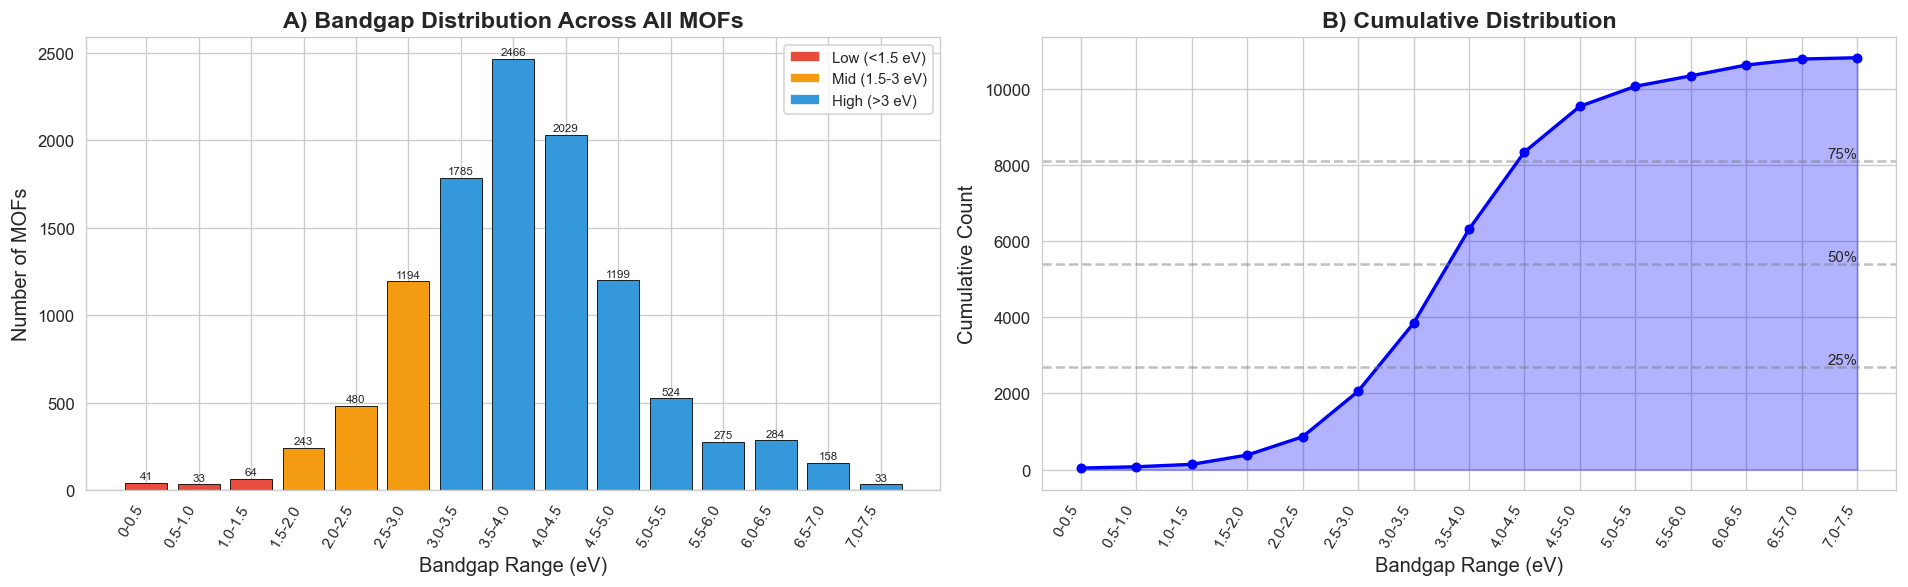


DATASET SUMMARY: 10810 MOFs across 16 bandgap ranges


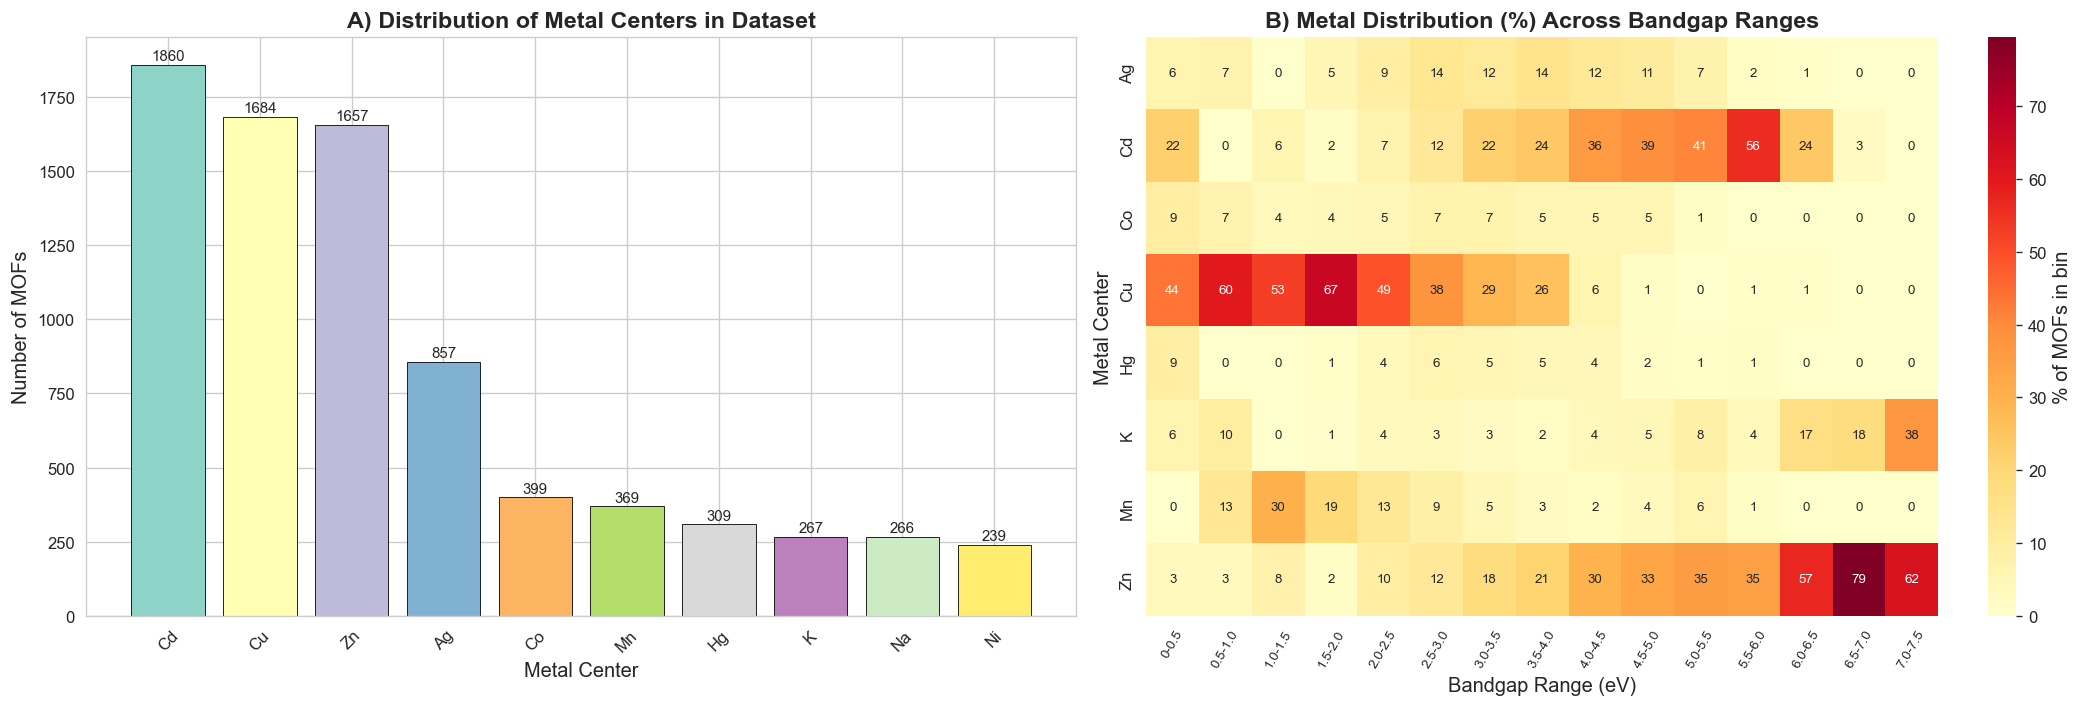


Valid linker data: 0 / 10808 MOFs (0.0%)


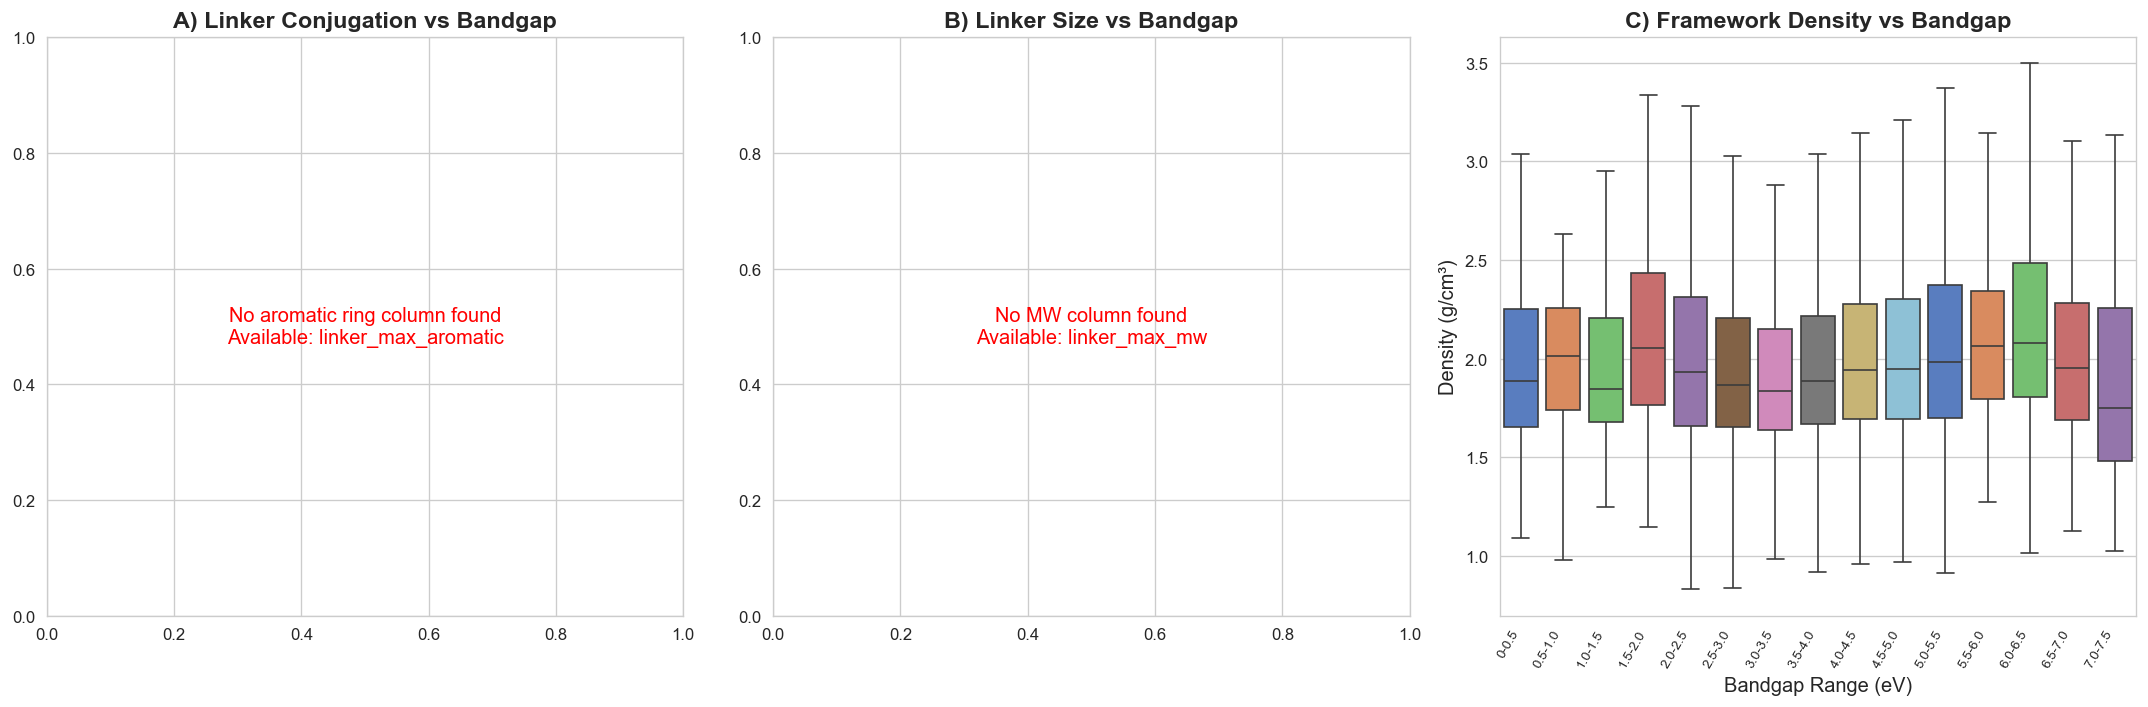


BANDGAP REGION ANALYSIS: LOW vs MID vs HIGH


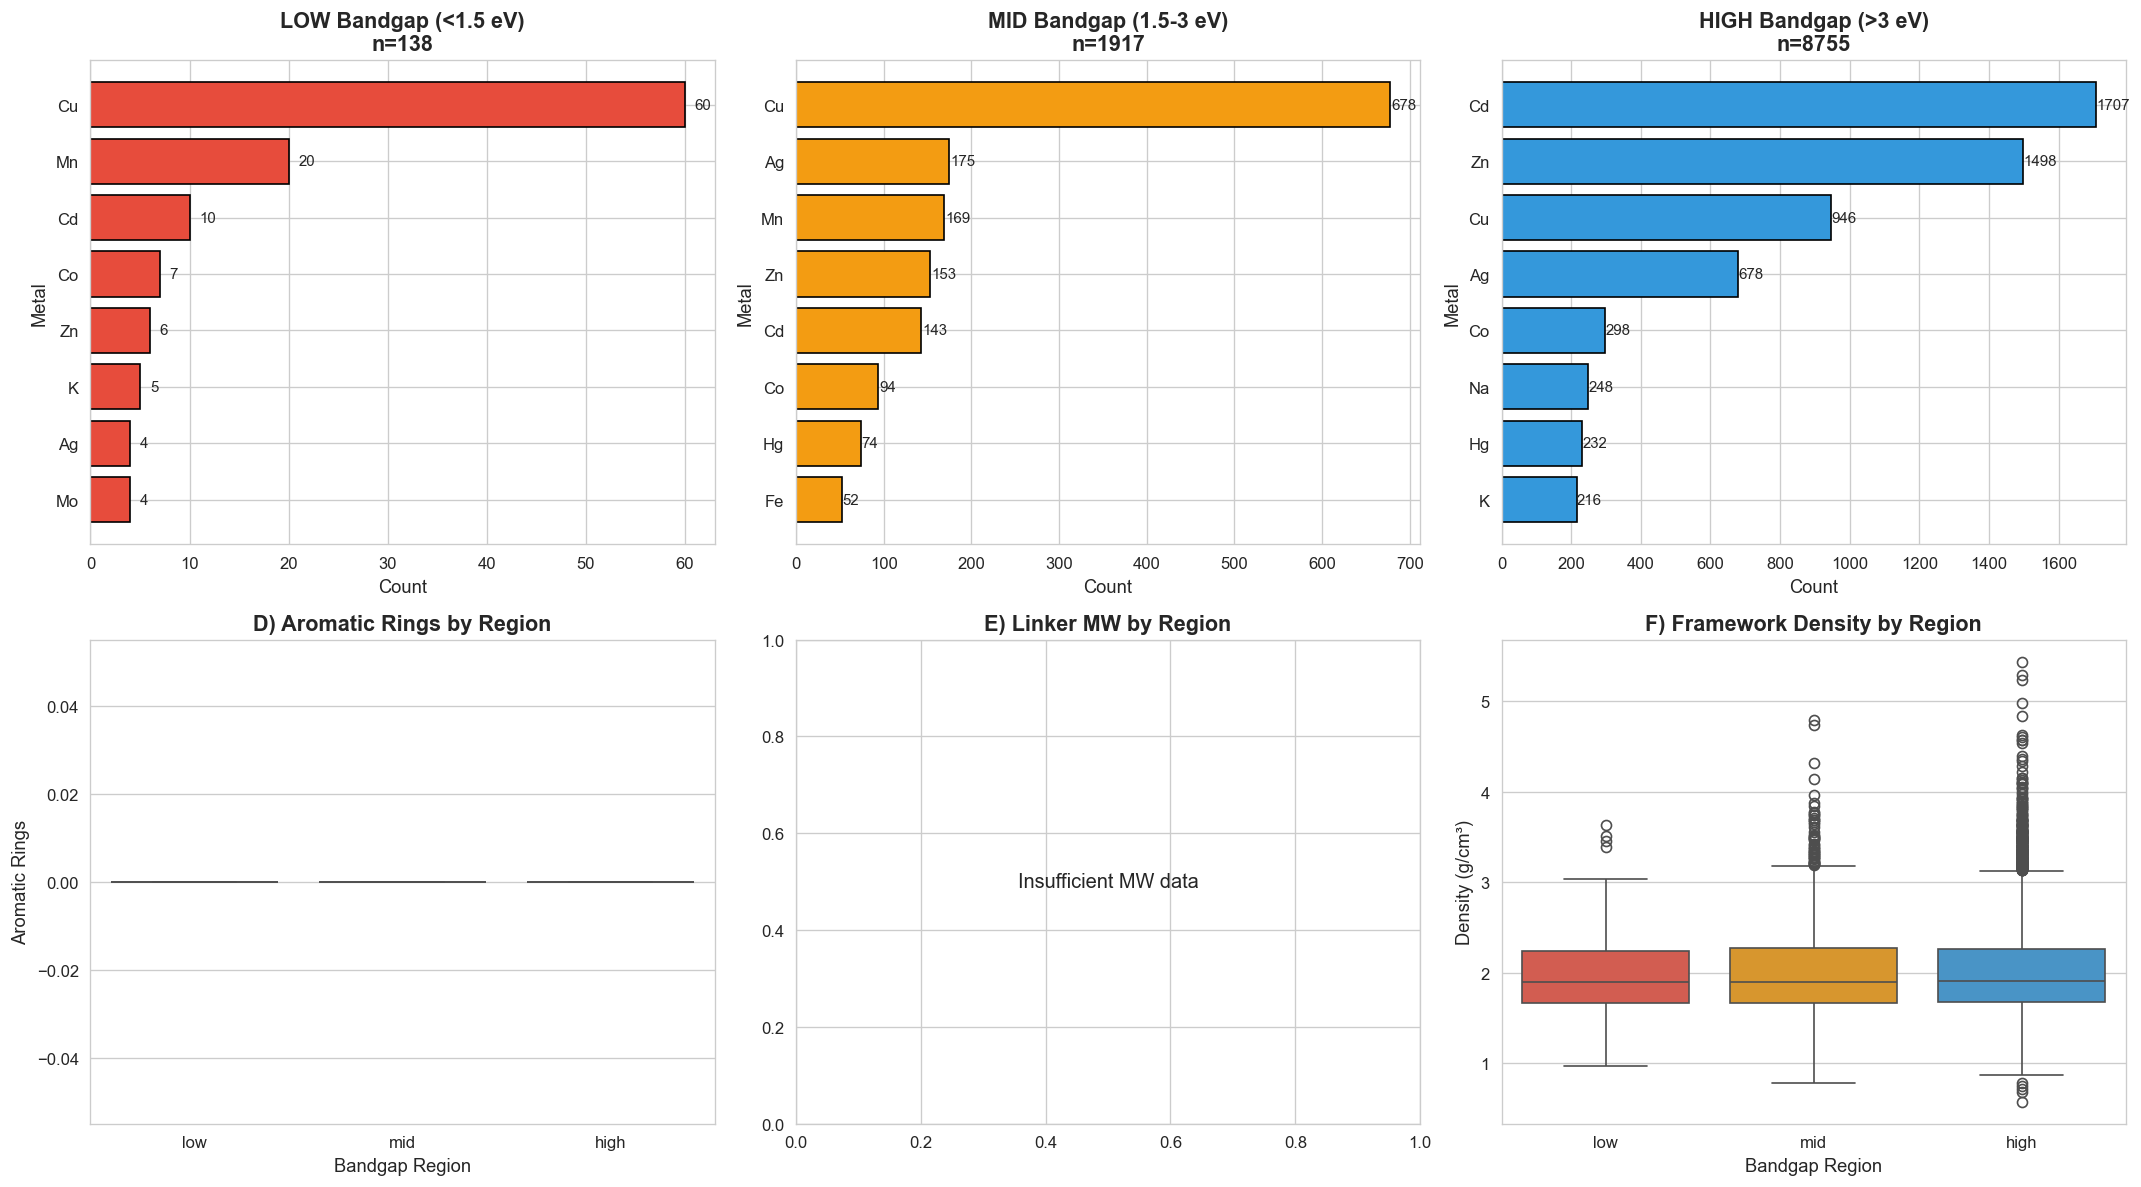

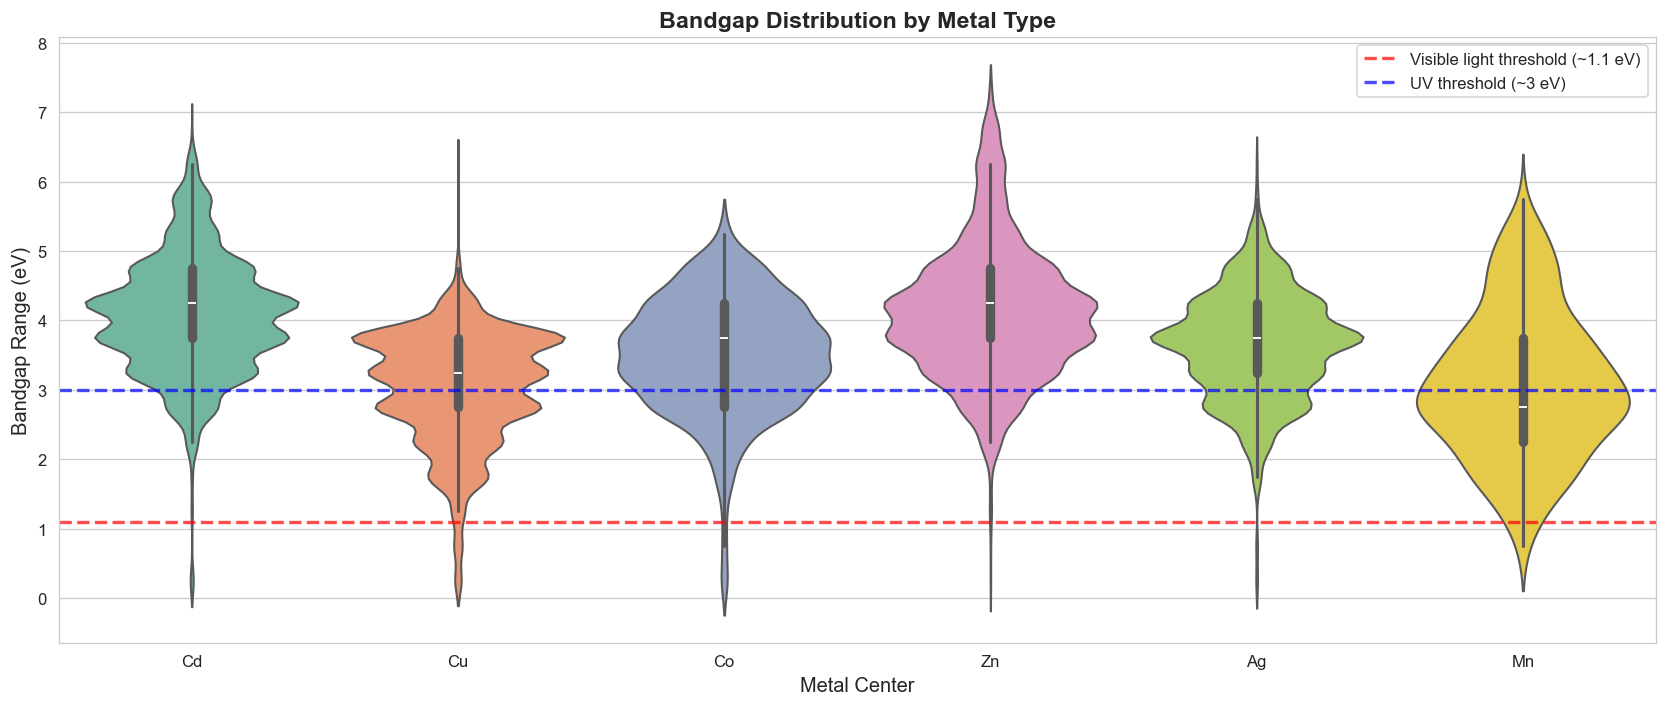


DETAILED LOW BANDGAP REGION ANALYSIS (<1.5 eV)


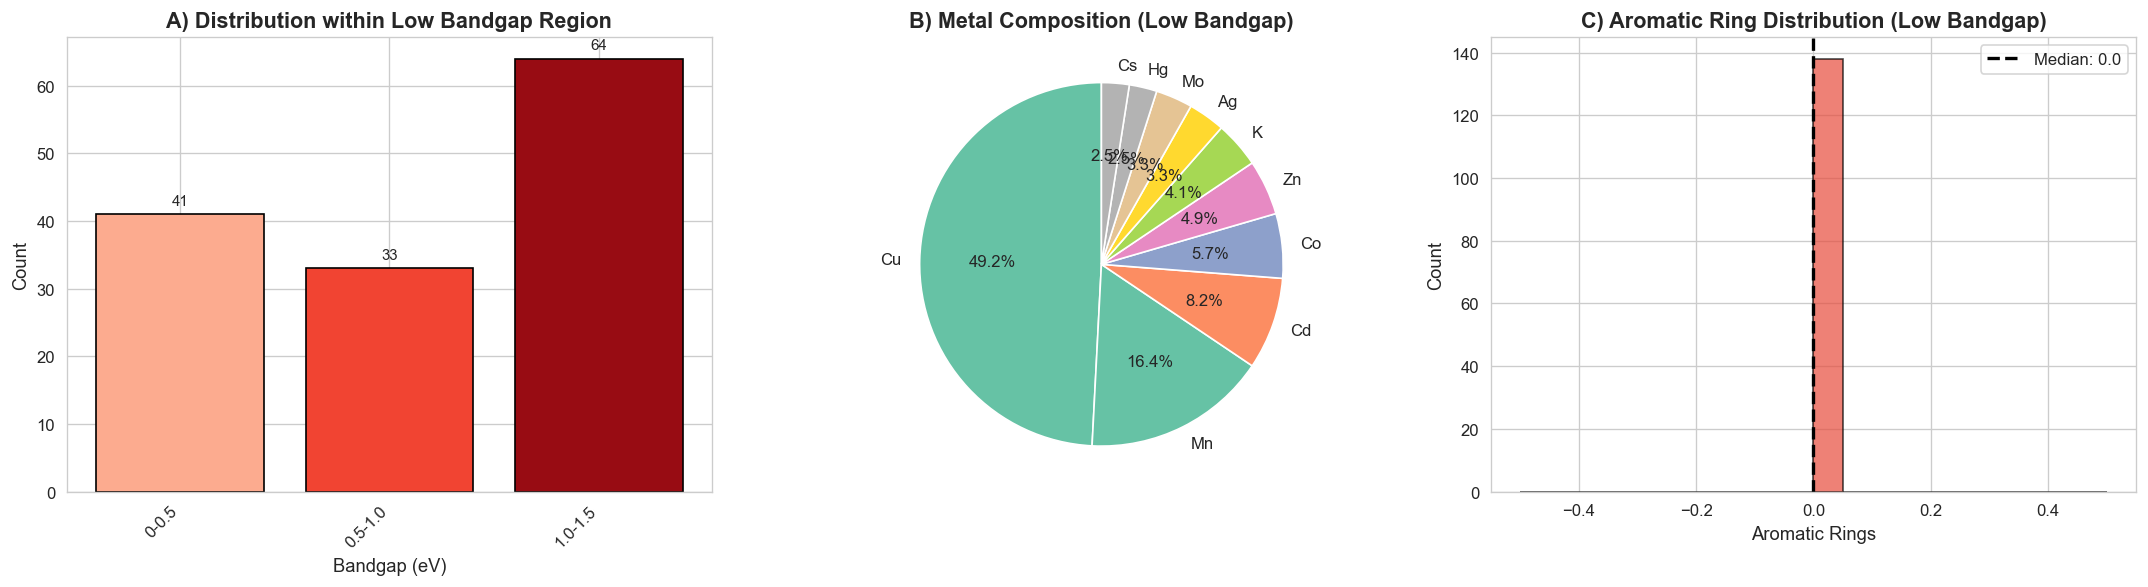


Low bandgap MOFs: 138
Top metals: {'Cu': 60, 'Mn': 20, 'Cd': 10, 'Co': 7, 'Zn': 6}

DETAILED HIGH BANDGAP REGION ANALYSIS (>3 eV)


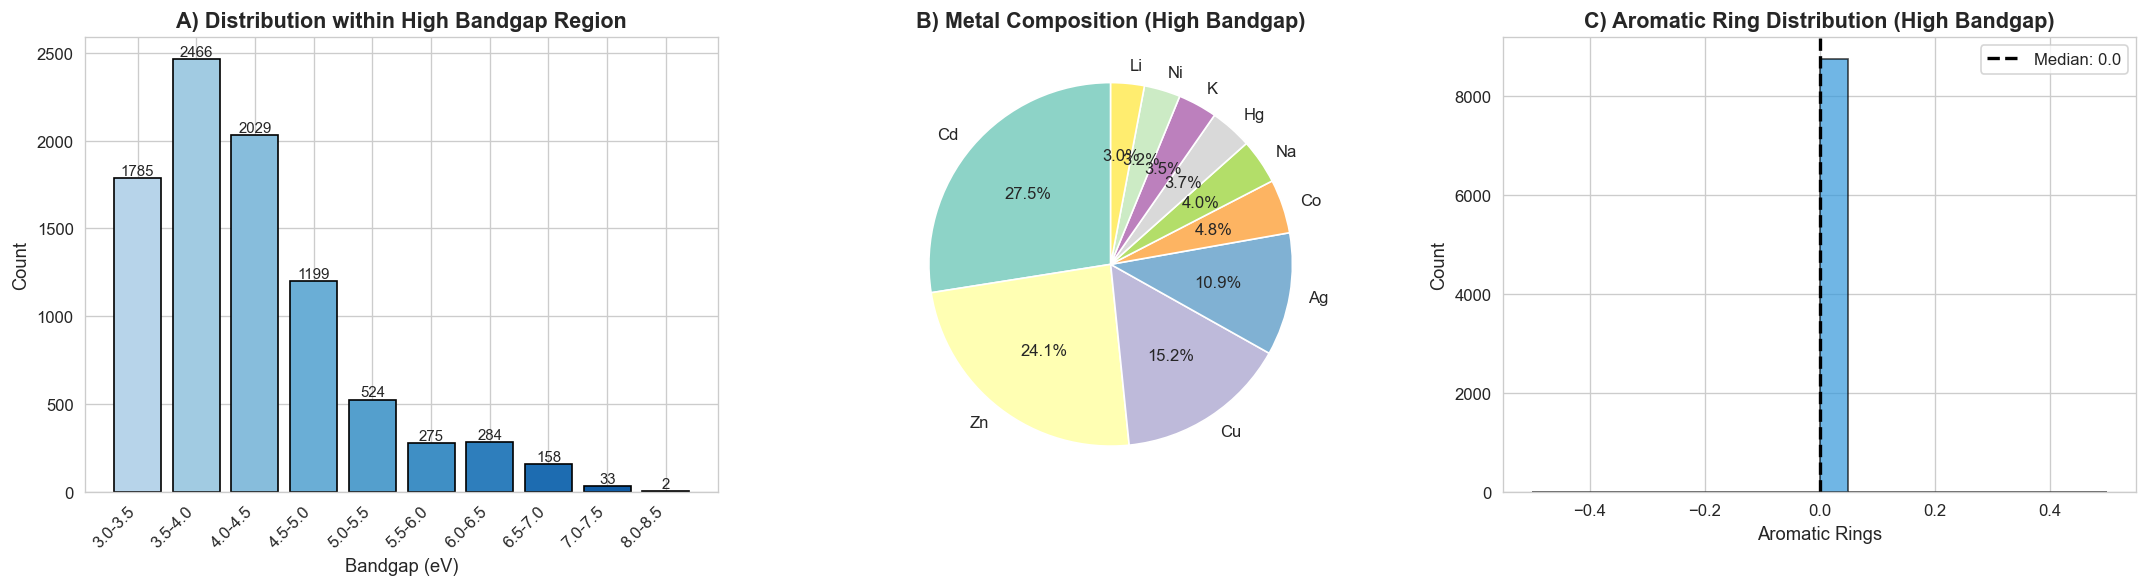


High bandgap MOFs: 8755
Top metals: {'Cd': 1707, 'Zn': 1498, 'Cu': 946, 'Ag': 678, 'Co': 298}

COMPREHENSIVE CHEMICAL ANALYSIS REPORT

┌──────────────────────────────────────────────────────────────────────────────────────────┐
│ BANDGAP BIN            │ N     │ REGION │ TOP METAL  │ AVG RINGS  │ AVG MW     │ AVG ρ      │
├──────────────────────────────────────────────────────────────────────────────────────────┤
│ 0-0.5 eV               │ 41    │ low    │ Cu         │ 0.00       │ 0.0        │ 1.98       │
│ 0.5-1.0 eV             │ 33    │ low    │ Cu         │ 0.00       │ 0.0        │ 2.05       │
│ 1.0-1.5 eV             │ 64    │ low    │ Cu         │ 0.00       │ 0.0        │ 1.96       │
│ 1.5-2.0 eV             │ 243   │ mid    │ Cu         │ 0.00       │ 0.0        │ 2.14       │
│ 2.0-2.5 eV             │ 480   │ mid    │ Cu         │ 0.00       │ 0.0        │ 2.05       │
│ 2.5-3.0 eV             │ 1194  │ mid    │ Cu         │ 0.00       │ 0.0        │ 1.97       │
│ 3.0-

In [63]:
# ==========================================
# 4. CHEMICALLY MEANINGFUL ANALYSIS & VISUALIZATION
# ==========================================

# Ensure required columns exist (fail fast if missing)
required_cols = ['extraction_confidence', 'analysis_bin', 'metal']
missing_cols = [c for c in required_cols if c not in df_stratified.columns]
if missing_cols:
    raise KeyError(f"Missing required columns for analysis: {missing_cols}. Run upstream extraction cells first.")

# Check if df_final exists (from linker analysis), otherwise use df_stratified
if 'df_final' in dir() and isinstance(df_final, pd.DataFrame):
    df_analysis_base = df_final.copy()
else:
    df_analysis_base = df_stratified.copy()

# Filter to only confident extractions for reliable analysis
df_analysis = df_analysis_base[df_analysis_base['extraction_confidence'] == 'confident'].copy()
print(f"Analyzing {len(df_analysis)} MOFs with confident metal extraction")
print(f"(Excluded {len(df_analysis_base) - len(df_analysis)} with missing/uncertain data)")

# ==========================================
# VERIFY COLUMN AVAILABILITY
# ==========================================
print("\n" + "="*60)
print("COLUMN AVAILABILITY CHECK")
print("="*60)

# Check for linker columns - NEW column names from updated Cell 4
linker_cols = {
    'aromatic': ['linker_max_aromatic', 'linker_total_aromatic', 'n_aromatic_rings'],  # max aromatic from all linkers
    'aromatic_min': ['linker_min_aromatic'],  # min aromatic - useful for detecting non-aromatic linkers
    'mw': ['linker_max_mw', 'linker_total_mw', 'linker_mw'],  # max MW from all linkers
    'valid': ['linker_valid', 'n_valid_linkers'],
    'non_aromatic': ['has_non_aromatic_linker']  # boolean flag for MOFs with non-aromatic linkers
}

available_linker_cols = {}
for feature, candidates in linker_cols.items():
    for col in candidates:
        if col in df_analysis.columns:
            available_linker_cols[feature] = col
            print(f"  ✓ {feature.upper()}: Using column '{col}'")
            break
    else:
        print(f"  ✗ {feature.upper()}: No suitable column found")
        available_linker_cols[feature] = None

# ==========================================
# DYNAMICALLY GENERATE BIN ORDER from actual data
# ==========================================
def extract_bin_range(bin_name):
    """Extract numeric range from bin name like 'bandgap_0.5_to_1.0eV'"""
    match = re.search(r'bandgap_([0-9.]+)_to_([0-9.]+)eV', bin_name)
    if match:
        return float(match.group(1)), float(match.group(2))
    return (999, 999)  # Put malformed bins at end

# Get unique bins and sort by their lower bound
unique_bins = df_analysis['analysis_bin'].dropna().unique().tolist()
bin_order = sorted(unique_bins, key=lambda x: extract_bin_range(x)[0])

bin_counts_all = df_analysis['analysis_bin'].value_counts()

print(f"\nDetected {len(bin_order)} bandgap bins:")
for b in bin_order:
    count = bin_counts_all.get(b, 0)
    print(f"  {b}: {count} MOFs")

# ==========================================
# DEFINE BANDGAP REGIONS
# ==========================================
def categorize_bin(bin_name):
    """Categorize bin into low/mid/high based on midpoint"""
    low, high = extract_bin_range(bin_name)
    mid = (low + high) / 2
    if mid < 1.5:
        return 'low'      # Low bandgap: visible light active
    elif mid < 3.0:
        return 'mid'      # Mid bandgap: semiconducting
    else:
        return 'high'     # High bandgap: wide-gap / insulator

bin_categories = {b: categorize_bin(b) for b in bin_order}
df_analysis['bandgap_region'] = df_analysis['analysis_bin'].map(bin_categories)

# Create bandgap midpoint for each bin
bin_midpoints = {b: sum(extract_bin_range(b)) / 2 for b in bin_order}
df_analysis['bandgap_mid'] = df_analysis['analysis_bin'].map(bin_midpoints)

# Region summaries
region_counts = df_analysis['bandgap_region'].value_counts()
print(f"\nBandgap Region Summary:")
print(f"  LOW  (<1.5 eV):  {region_counts.get('low', 0)} MOFs - Visible light active")
print(f"  MID  (1.5-3 eV): {region_counts.get('mid', 0)} MOFs - Semiconducting")
print(f"  HIGH (>3 eV):    {region_counts.get('high', 0)} MOFs - Wide-gap insulator")

# Keep a cleaner subset for plots to avoid overcrowding
MIN_BIN_COUNT = 10
plot_bins = [b for b in bin_order if bin_counts_all.get(b, 0) >= MIN_BIN_COUNT]
if len(plot_bins) < 3:
    plot_bins = bin_order

# Keep ordered categories for full analysis and plotting
pd.set_option('mode.chained_assignment', None)

df_analysis['analysis_bin'] = pd.Categorical(df_analysis['analysis_bin'], categories=bin_order, ordered=True)
df_analysis = df_analysis.sort_values('analysis_bin')

df_plot = df_analysis[df_analysis['analysis_bin'].isin(plot_bins)].copy()
if len(df_plot) == 0:
    plot_bins = bin_order
    df_plot = df_analysis.copy()

df_plot['analysis_bin'] = pd.Categorical(df_plot['analysis_bin'], categories=plot_bins, ordered=True)
df_plot = df_plot.sort_values('analysis_bin')

# ==========================================
# PLOTTING SETUP
# ==========================================
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

def simplify_bin_label(label):
    """Convert 'bandgap_0.5_to_1.0eV' to '0.5-1.0'"""
    return str(label).replace('bandgap_', '').replace('_to_', '-').replace('eV', '')

# ==========================================
# FIGURE 0: OVERALL BANDGAP DISTRIBUTION
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 0A: Bandgap distribution histogram
ax0 = axes[0]
bin_counts = df_plot['analysis_bin'].value_counts().reindex(plot_bins).fillna(0)
x_labels = [simplify_bin_label(b) for b in plot_bins]

if bin_counts.sum() == 0:
    ax0.text(0.5, 0.5, 'No data available', ha='center', va='center', fontsize=12)
    ax1 = axes[1]
    ax1.text(0.5, 0.5, 'No data available', ha='center', va='center', fontsize=12)
else:
    # Color by region
    region_colors = {'low': '#e74c3c', 'mid': '#f39c12', 'high': '#3498db'}
    bar_colors = [region_colors[bin_categories[b]] for b in plot_bins]
    
    bars = ax0.bar(range(len(plot_bins)), bin_counts.values, color=bar_colors, edgecolor='black', linewidth=0.5)
    ax0.set_xticks(range(len(plot_bins)))
    ax0.set_xticklabels(x_labels, rotation=60, ha='right', fontsize=9)
    ax0.set_xlabel('Bandgap Range (eV)', fontsize=12)
    ax0.set_ylabel('Number of MOFs', fontsize=12)
    ax0.set_title('A) Bandgap Distribution Across All MOFs', fontsize=14, fontweight='bold')
    
    # Add legend for regions
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#e74c3c', label='Low (<1.5 eV)'),
        Patch(facecolor='#f39c12', label='Mid (1.5-3 eV)'),
        Patch(facecolor='#3498db', label='High (>3 eV)')
    ]
    ax0.legend(handles=legend_elements, loc='upper right', fontsize=9)

    # Add count labels on significant bars
    for i, (bar, count) in enumerate(zip(bars, bin_counts.values)):
        if count > 0:
            ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'{int(count)}',
                     ha='center', va='bottom', fontsize=7, rotation=0)

    # 0B: Cumulative distribution
    ax1 = axes[1]
    cumsum = bin_counts.cumsum()
    ax1.fill_between(range(len(plot_bins)), cumsum.values, alpha=0.3, color='blue')
    ax1.plot(range(len(plot_bins)), cumsum.values, 'b-o', linewidth=2, markersize=5)
    ax1.set_xticks(range(len(plot_bins)))
    ax1.set_xticklabels(x_labels, rotation=60, ha='right', fontsize=9)
    ax1.set_xlabel('Bandgap Range (eV)', fontsize=12)
    ax1.set_ylabel('Cumulative Count', fontsize=12)
    ax1.set_title('B) Cumulative Distribution', fontsize=14, fontweight='bold')

    # Add horizontal lines for key percentiles
    total = cumsum.iloc[-1] if len(cumsum) > 0 else 0
    if total > 0:
        for pct in [25, 50, 75]:
            target = total * pct / 100
            ax1.axhline(y=target, color='gray', linestyle='--', alpha=0.5)
            ax1.text(len(plot_bins)-1, target, f'{pct}%', va='bottom', ha='right', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print(f"DATASET SUMMARY: {len(df_analysis)} MOFs across {len(bin_order)} bandgap ranges")
print(f"{'='*80}")

# ==========================================
# FIGURE 1: Metal Distribution by Bandgap Range
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1A: Overall metal distribution
ax1 = axes[0]
metal_counts = df_plot['metal'].value_counts().head(10)
if len(metal_counts) == 0:
    ax1.text(0.5, 0.5, 'No metal data available', ha='center', va='center', fontsize=12)
else:
    colors = plt.cm.Set3(np.linspace(0, 1, len(metal_counts)))
    bars = ax1.bar(metal_counts.index, metal_counts.values, color=colors, edgecolor='black', linewidth=0.5)
    ax1.set_xlabel('Metal Center', fontsize=12)
    ax1.set_ylabel('Number of MOFs', fontsize=12)
    ax1.set_title('A) Distribution of Metal Centers in Dataset', fontsize=14, fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)

    # Add count labels on bars
    for bar, count in zip(bars, metal_counts.values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count),
                 ha='center', va='bottom', fontsize=9)

# 1B: Metal distribution per bandgap bin (heatmap style)
ax2 = axes[1]
# Create crosstab
top_metals = df_plot['metal'].value_counts().head(8).index
df_top = df_plot[df_plot['metal'].isin(top_metals)]

if len(df_top) == 0:
    ax2.text(0.5, 0.5, 'No metal/bin data available', ha='center', va='center', fontsize=12)
else:
    crosstab = pd.crosstab(df_top['metal'], df_top['analysis_bin'], normalize='columns') * 100

    # Reorder and simplify labels for readability
    crosstab = crosstab.reindex(columns=[b for b in plot_bins if b in crosstab.columns])

    # Simplify column labels for display
    simple_labels = [simplify_bin_label(b) for b in crosstab.columns]
    crosstab.columns = simple_labels

    # Adjust annotation size based on number of bins
    annot_size = 8 if len(plot_bins) > 10 else 10
    sns.heatmap(crosstab, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax2,
                cbar_kws={'label': '% of MOFs in bin'}, annot_kws={'size': annot_size})
    ax2.set_title('B) Metal Distribution (%) Across Bandgap Ranges', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Bandgap Range (eV)', fontsize=12)
    ax2.set_ylabel('Metal Center', fontsize=12)
    ax2.tick_params(axis='x', rotation=60, labelsize=8)

plt.tight_layout()
plt.show()

# ==========================================
# FIGURE 2: Electronic Structure Factors (FIXED)
# ==========================================
fig_width = max(18, len(plot_bins) * 1.2)
fig, axes = plt.subplots(1, 3, figsize=(fig_width, 6))

# Get valid linker data using the correct column names
valid_col = available_linker_cols.get('valid')
if valid_col and valid_col in df_plot.columns:
    if valid_col == 'linker_valid':
        df_valid_linker = df_plot[df_plot[valid_col] == True].copy()
    else:
        df_valid_linker = df_plot[df_plot[valid_col] > 0].copy()
else:
    df_valid_linker = df_plot.copy()

print(f"\nValid linker data: {len(df_valid_linker)} / {len(df_plot)} MOFs ({100*len(df_valid_linker)/len(df_plot):.1f}%)")

# 2A: Aromatic rings vs bandgap
ax1 = axes[0]
arom_col = available_linker_cols.get('aromatic')

if arom_col and arom_col in df_valid_linker.columns and len(df_valid_linker) > 0:
    # Check for actual data - include 0 aromatic rings (valid for formate, acetate linkers)
    valid_arom_data = df_valid_linker[df_valid_linker[arom_col].notna()]
    print(f"  Aromatic data: {len(valid_arom_data)} samples with valid aromatic ring counts (including 0)")
    
    if len(valid_arom_data) > 10:
        sns.boxplot(data=valid_arom_data, x='analysis_bin', y=arom_col,
                    hue='analysis_bin', palette='coolwarm', legend=False, ax=ax1, showfliers=False)
        ax1.set_xlabel('Bandgap Range (eV)', fontsize=12)
        ax1.set_ylabel('Aromatic Rings in Linker', fontsize=12)
        ax1.set_title('A) Linker Conjugation vs Bandgap', fontsize=14, fontweight='bold')
        ax1.set_xticklabels([simplify_bin_label(t.get_text()) for t in ax1.get_xticklabels()], rotation=60, ha='right', fontsize=8)
    else:
        ax1.text(0.5, 0.5, f'Insufficient aromatic data\n(n={len(valid_arom_data)})', 
                 ha='center', va='center', fontsize=12, color='red')
        ax1.set_title('A) Linker Conjugation vs Bandgap', fontsize=14, fontweight='bold')
else:
    ax1.text(0.5, 0.5, f'No aromatic ring column found\nAvailable: {arom_col}', 
             ha='center', va='center', fontsize=12, color='red')
    ax1.set_title('A) Linker Conjugation vs Bandgap', fontsize=14, fontweight='bold')

# 2B: Linker molecular weight
ax2 = axes[1]
mw_col = available_linker_cols.get('mw')

if mw_col and mw_col in df_valid_linker.columns and len(df_valid_linker) > 0:
    # Check for actual data - MW > 0 means valid linker was parsed
    valid_mw_data = df_valid_linker[df_valid_linker[mw_col].notna() & (df_valid_linker[mw_col] > 0)]
    print(f"  MW data: {len(valid_mw_data)} samples with valid molecular weight (MW > 0)")
    
    if len(valid_mw_data) > 10:
        sns.boxplot(data=valid_mw_data, x='analysis_bin', y=mw_col,
                    hue='analysis_bin', palette='viridis', legend=False, ax=ax2, showfliers=False)
        ax2.set_xlabel('Bandgap Range (eV)', fontsize=12)
        ax2.set_ylabel('Linker Molecular Weight (g/mol)', fontsize=12)
        ax2.set_title('B) Linker Size vs Bandgap', fontsize=14, fontweight='bold')
        ax2.set_xticklabels([simplify_bin_label(t.get_text()) for t in ax2.get_xticklabels()], rotation=60, ha='right', fontsize=8)
    else:
        ax2.text(0.5, 0.5, f'Insufficient MW data\n(n={len(valid_mw_data)})', 
                 ha='center', va='center', fontsize=12, color='red')
        ax2.set_title('B) Linker Size vs Bandgap', fontsize=14, fontweight='bold')
else:
    ax2.text(0.5, 0.5, f'No MW column found\nAvailable: {mw_col}', 
             ha='center', va='center', fontsize=12, color='red')
    ax2.set_title('B) Linker Size vs Bandgap', fontsize=14, fontweight='bold')

# 2C: MOF density
ax3 = axes[2]
if 'info.density' in df_plot.columns and len(df_plot) > 0:
    sns.boxplot(data=df_plot, x='analysis_bin', y='info.density',
                hue='analysis_bin', palette='muted', legend=False, ax=ax3, showfliers=False)
    ax3.set_xlabel('Bandgap Range (eV)', fontsize=12)
    ax3.set_ylabel('Density (g/cm³)', fontsize=12)
    ax3.set_title('C) Framework Density vs Bandgap', fontsize=14, fontweight='bold')
    ax3.set_xticklabels([simplify_bin_label(t.get_text()) for t in ax3.get_xticklabels()], rotation=60, ha='right', fontsize=8)
else:
    ax3.text(0.5, 0.5, 'No density data', ha='center', va='center', fontsize=12)
    ax3.set_title('C) Framework Density vs Bandgap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# FIGURE 3: BANDGAP REGION COMPARISON (NEW)
# ==========================================
print("\n" + "="*80)
print("BANDGAP REGION ANALYSIS: LOW vs MID vs HIGH")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Metal distribution by region
# 3A: Low bandgap metal distribution
df_low = df_analysis[df_analysis['bandgap_region'] == 'low']
df_mid = df_analysis[df_analysis['bandgap_region'] == 'mid']
df_high = df_analysis[df_analysis['bandgap_region'] == 'high']

regions = [('low', df_low, '#e74c3c', '<1.5 eV'), 
           ('mid', df_mid, '#f39c12', '1.5-3 eV'), 
           ('high', df_high, '#3498db', '>3 eV')]

for idx, (region_name, region_df, color, label) in enumerate(regions):
    ax = axes[0, idx]
    if len(region_df) > 0:
        metal_counts_region = region_df['metal'].value_counts().head(8)
        bars = ax.barh(metal_counts_region.index[::-1], metal_counts_region.values[::-1], color=color, edgecolor='black')
        ax.set_xlabel('Count', fontsize=11)
        ax.set_ylabel('Metal', fontsize=11)
        ax.set_title(f'{region_name.upper()} Bandgap ({label})\nn={len(region_df)}', fontsize=13, fontweight='bold')
        
        # Add count labels
        for bar, count in zip(bars, metal_counts_region.values[::-1]):
            ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, str(count),
                   va='center', fontsize=9)
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=12)
        ax.set_title(f'{region_name.upper()} Bandgap ({label})', fontsize=13, fontweight='bold')

# Row 2: Linker properties by region
# 3D: Aromatic rings by region
ax = axes[1, 0]
if arom_col and arom_col in df_analysis.columns:
    region_order = ['low', 'mid', 'high']
    # Include 0 aromatic rings - valid for simple linkers like formate
    df_arom_valid = df_analysis[df_analysis[arom_col].notna()]
    if len(df_arom_valid) > 10:
        sns.boxplot(data=df_arom_valid, x='bandgap_region', y=arom_col, order=region_order,
                    palette={'low': '#e74c3c', 'mid': '#f39c12', 'high': '#3498db'}, ax=ax)
        ax.set_xlabel('Bandgap Region', fontsize=11)
        ax.set_ylabel('Aromatic Rings', fontsize=11)
        ax.set_title('D) Aromatic Rings by Region', fontsize=13, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'Insufficient aromatic data', ha='center', va='center', fontsize=12)
        ax.set_title('D) Aromatic Rings by Region', fontsize=13, fontweight='bold')
else:
    ax.text(0.5, 0.5, 'No aromatic data', ha='center', va='center', fontsize=12)
    ax.set_title('D) Aromatic Rings by Region', fontsize=13, fontweight='bold')

# 3E: MW by region
ax = axes[1, 1]
if mw_col and mw_col in df_analysis.columns:
    df_mw_valid = df_analysis[df_analysis[mw_col].notna() & (df_analysis[mw_col] > 0)]
    if len(df_mw_valid) > 10:
        sns.boxplot(data=df_mw_valid, x='bandgap_region', y=mw_col, order=region_order,
                    palette={'low': '#e74c3c', 'mid': '#f39c12', 'high': '#3498db'}, ax=ax)
        ax.set_xlabel('Bandgap Region', fontsize=11)
        ax.set_ylabel('Linker MW (g/mol)', fontsize=11)
        ax.set_title('E) Linker MW by Region', fontsize=13, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'Insufficient MW data', ha='center', va='center', fontsize=12)
        ax.set_title('E) Linker MW by Region', fontsize=13, fontweight='bold')
else:
    ax.text(0.5, 0.5, 'No MW data', ha='center', va='center', fontsize=12)
    ax.set_title('E) Linker MW by Region', fontsize=13, fontweight='bold')

# 3F: Density by region
ax = axes[1, 2]
if 'info.density' in df_analysis.columns:
    sns.boxplot(data=df_analysis, x='bandgap_region', y='info.density', order=region_order,
                palette={'low': '#e74c3c', 'mid': '#f39c12', 'high': '#3498db'}, ax=ax)
    ax.set_xlabel('Bandgap Region', fontsize=11)
    ax.set_ylabel('Density (g/cm³)', fontsize=11)
    ax.set_title('F) Framework Density by Region', fontsize=13, fontweight='bold')
else:
    ax.text(0.5, 0.5, 'No density data', ha='center', va='center', fontsize=12)
    ax.set_title('F) Framework Density by Region', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# FIGURE 4: Metal-Specific Bandgap Analysis
# ==========================================
fig, ax = plt.subplots(figsize=(14, 6))

# For top metals, show bandgap distribution
top_metals_list = df_plot['metal'].value_counts().head(6).index.tolist()
df_top_metals = df_plot[df_plot['metal'].isin(top_metals_list)].copy()

if len(df_top_metals) == 0:
    ax.text(0.5, 0.5, 'No metal/bin data for violin plot', ha='center', va='center', fontsize=12)
else:
    sns.violinplot(data=df_top_metals, x='metal', y='bandgap_mid',
                   hue='metal', palette='Set2', legend=False, ax=ax)
    ax.set_xlabel('Metal Center', fontsize=12)
    ax.set_ylabel('Bandgap Range (eV)', fontsize=12)
    ax.set_title('Bandgap Distribution by Metal Type', fontsize=14, fontweight='bold')
    ax.axhline(y=1.1, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Visible light threshold (~1.1 eV)')
    ax.axhline(y=3.0, color='blue', linestyle='--', alpha=0.7, linewidth=2, label='UV threshold (~3 eV)')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# ==========================================
# FIGURE 5: DETAILED LOW BANDGAP ANALYSIS
# ==========================================
print("\n" + "="*80)
print("DETAILED LOW BANDGAP REGION ANALYSIS (<1.5 eV)")
print("="*80)

if len(df_low) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 5A: Detailed bandgap distribution within low region
    ax1 = axes[0]
    low_bins = [b for b in bin_order if bin_categories.get(b) == 'low']
    if low_bins:
        low_bin_counts = df_low['analysis_bin'].value_counts().reindex(low_bins).fillna(0)
        colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(low_bins)))
        bars = ax1.bar(range(len(low_bins)), low_bin_counts.values, color=colors, edgecolor='black')
        ax1.set_xticks(range(len(low_bins)))
        ax1.set_xticklabels([simplify_bin_label(b) for b in low_bins], rotation=45, ha='right')
        ax1.set_xlabel('Bandgap (eV)', fontsize=11)
        ax1.set_ylabel('Count', fontsize=11)
        ax1.set_title('A) Distribution within Low Bandgap Region', fontsize=13, fontweight='bold')
        for bar, count in zip(bars, low_bin_counts.values):
            if count > 0:
                ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, int(count),
                        ha='center', va='bottom', fontsize=9)
    
    # 5B: Metal composition in low bandgap
    ax2 = axes[1]
    low_metals = df_low['metal'].value_counts()
    if len(low_metals) > 0:
        colors = plt.cm.Set2(np.linspace(0, 1, min(10, len(low_metals))))
        wedges, texts, autotexts = ax2.pie(low_metals.head(10), labels=low_metals.head(10).index, 
                                            autopct='%1.1f%%', colors=colors, startangle=90)
        ax2.set_title('B) Metal Composition (Low Bandgap)', fontsize=13, fontweight='bold')
    
    # 5C: Linker properties for low bandgap
    ax3 = axes[2]
    if arom_col and arom_col in df_low.columns:
        # Include 0 aromatic rings as valid data
        df_low_valid = df_low[df_low[arom_col].notna()]
        if len(df_low_valid) > 5:
            ax3.hist(df_low_valid[arom_col], bins=20, color='#e74c3c', edgecolor='black', alpha=0.7)
            ax3.axvline(df_low_valid[arom_col].median(), color='black', linestyle='--', linewidth=2, 
                       label=f'Median: {df_low_valid[arom_col].median():.1f}')
            ax3.set_xlabel('Aromatic Rings', fontsize=11)
            ax3.set_ylabel('Count', fontsize=11)
            ax3.set_title('C) Aromatic Ring Distribution (Low Bandgap)', fontsize=13, fontweight='bold')
            ax3.legend()
        else:
            ax3.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', fontsize=12)
            ax3.set_title('C) Aromatic Ring Distribution (Low Bandgap)', fontsize=13, fontweight='bold')
    else:
        ax3.text(0.5, 0.5, 'No aromatic data', ha='center', va='center', fontsize=12)
        ax3.set_title('C) Aromatic Ring Distribution (Low Bandgap)', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nLow bandgap MOFs: {len(df_low)}")
    print(f"Top metals: {df_low['metal'].value_counts().head(5).to_dict()}")
else:
    print("No MOFs in low bandgap region!")

# ==========================================
# FIGURE 6: DETAILED HIGH BANDGAP ANALYSIS
# ==========================================
print("\n" + "="*80)
print("DETAILED HIGH BANDGAP REGION ANALYSIS (>3 eV)")
print("="*80)

if len(df_high) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 6A: Detailed bandgap distribution within high region
    ax1 = axes[0]
    high_bins = [b for b in bin_order if bin_categories.get(b) == 'high']
    if high_bins:
        high_bin_counts = df_high['analysis_bin'].value_counts().reindex(high_bins).fillna(0)
        colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(high_bins)))
        bars = ax1.bar(range(len(high_bins)), high_bin_counts.values, color=colors, edgecolor='black')
        ax1.set_xticks(range(len(high_bins)))
        ax1.set_xticklabels([simplify_bin_label(b) for b in high_bins], rotation=45, ha='right')
        ax1.set_xlabel('Bandgap (eV)', fontsize=11)
        ax1.set_ylabel('Count', fontsize=11)
        ax1.set_title('A) Distribution within High Bandgap Region', fontsize=13, fontweight='bold')
        for bar, count in zip(bars, high_bin_counts.values):
            if count > 0:
                ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, int(count),
                        ha='center', va='bottom', fontsize=9)
    
    # 6B: Metal composition in high bandgap
    ax2 = axes[1]
    high_metals = df_high['metal'].value_counts()
    if len(high_metals) > 0:
        colors = plt.cm.Set3(np.linspace(0, 1, min(10, len(high_metals))))
        wedges, texts, autotexts = ax2.pie(high_metals.head(10), labels=high_metals.head(10).index, 
                                            autopct='%1.1f%%', colors=colors, startangle=90)
        ax2.set_title('B) Metal Composition (High Bandgap)', fontsize=13, fontweight='bold')
    
    # 6C: Linker properties for high bandgap
    ax3 = axes[2]
    if arom_col and arom_col in df_high.columns:
        # Include 0 aromatic rings as valid data
        df_high_valid = df_high[df_high[arom_col].notna()]
        if len(df_high_valid) > 5:
            ax3.hist(df_high_valid[arom_col], bins=20, color='#3498db', edgecolor='black', alpha=0.7)
            ax3.axvline(df_high_valid[arom_col].median(), color='black', linestyle='--', linewidth=2, 
                       label=f'Median: {df_high_valid[arom_col].median():.1f}')
            ax3.set_xlabel('Aromatic Rings', fontsize=11)
            ax3.set_ylabel('Count', fontsize=11)
            ax3.set_title('C) Aromatic Ring Distribution (High Bandgap)', fontsize=13, fontweight='bold')
            ax3.legend()
        else:
            ax3.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', fontsize=12)
            ax3.set_title('C) Aromatic Ring Distribution (High Bandgap)', fontsize=13, fontweight='bold')
    else:
        ax3.text(0.5, 0.5, 'No aromatic data', ha='center', va='center', fontsize=12)
        ax3.set_title('C) Aromatic Ring Distribution (High Bandgap)', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nHigh bandgap MOFs: {len(df_high)}")
    print(f"Top metals: {df_high['metal'].value_counts().head(5).to_dict()}")
else:
    print("No MOFs in high bandgap region!")

# ==========================================
# COMPREHENSIVE STATISTICAL REPORT
# ==========================================
print("\n" + "="*80)
print("COMPREHENSIVE CHEMICAL ANALYSIS REPORT")
print("="*80)

# Per-bin analysis
print("\n┌" + "─"*90 + "┐")
print(f"│ {'BANDGAP BIN':<22} │ {'N':<5} │ {'REGION':<6} │ {'TOP METAL':<10} │ {'AVG RINGS':<10} │ {'AVG MW':<10} │ {'AVG ρ':<10} │")
print("├" + "─"*90 + "┤")

for bin_name in bin_order:
    bin_data = df_analysis[df_analysis['analysis_bin'] == bin_name]
    if len(bin_data) == 0:
        continue
    
    n = len(bin_data)
    region = bin_categories.get(bin_name, 'unk')
    top_metal = bin_data['metal'].mode().iloc[0] if len(bin_data['metal'].mode()) > 0 else "N/A"
    
    # Get aromatic rings - include 0 as valid (simple linkers have no aromatic rings)
    if arom_col and arom_col in bin_data.columns:
        valid_data = bin_data[bin_data[arom_col].notna()]
        avg_rings = valid_data[arom_col].mean() if len(valid_data) > 0 else 0
    else:
        avg_rings = 0
    
    # Get MW
    if mw_col and mw_col in bin_data.columns:
        valid_data = bin_data[bin_data[mw_col].notna() & (bin_data[mw_col] > 0)]
        avg_mw = valid_data[mw_col].mean() if len(valid_data) > 0 else 0
    else:
        avg_mw = 0
    
    avg_density = bin_data['info.density'].mean() if 'info.density' in bin_data.columns else 0
    
    # Format bin name for display
    display_name = simplify_bin_label(bin_name) + ' eV'
    
    print(f"│ {display_name:<22} │ {n:<5} │ {region:<6} │ {top_metal:<10} │ {avg_rings:<10.2f} │ {avg_mw:<10.1f} │ {avg_density:<10.2f} │")

print("└" + "─"*90 + "┘")

# ==========================================
# REGION COMPARISON TABLE
# ==========================================
print("\n" + "="*80)
print("BANDGAP REGION COMPARISON")
print("="*80)

regions_summary = []
for region_name, region_df in [('LOW (<1.5 eV)', df_low), ('MID (1.5-3 eV)', df_mid), ('HIGH (>3 eV)', df_high)]:
    if len(region_df) == 0:
        continue
    
    top_metals = region_df['metal'].value_counts().head(3)
    metals_str = ', '.join([f"{m}({c})" for m, c in top_metals.items()])
    
    avg_rings = 0
    if arom_col and arom_col in region_df.columns:
        # Include 0 aromatic rings as valid data
        valid = region_df[region_df[arom_col].notna()]
        avg_rings = valid[arom_col].mean() if len(valid) > 0 else 0
    
    avg_mw = 0
    if mw_col and mw_col in region_df.columns:
        valid = region_df[region_df[mw_col].notna() & (region_df[mw_col] > 0)]
        avg_mw = valid[mw_col].mean() if len(valid) > 0 else 0
    
    avg_density = region_df['info.density'].mean() if 'info.density' in region_df.columns else 0
    
    print(f"\n{region_name}:")
    print(f"  Count: {len(region_df)} MOFs ({100*len(region_df)/len(df_analysis):.1f}%)")
    print(f"  Top metals: {metals_str}")
    print(f"  Avg aromatic rings: {avg_rings:.2f}")
    print(f"  Avg linker MW: {avg_mw:.1f} g/mol")
    print(f"  Avg density: {avg_density:.2f} g/cm³")

# ==========================================
# KEY INSIGHTS
# ==========================================
print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

# Compare low vs high bandgap
if len(df_low) > 0 and len(df_high) > 0:
    print("\n📊 LOW vs HIGH Bandgap Comparison:")
    
    # Metal comparison
    low_metals = set(df_low['metal'].value_counts().head(5).index)
    high_metals = set(df_high['metal'].value_counts().head(5).index)
    common_metals = low_metals & high_metals
    low_unique = low_metals - high_metals
    high_unique = high_metals - low_metals
    
    print(f"  • Metals common to both: {', '.join(common_metals) if common_metals else 'None'}")
    print(f"  • Metals favoring LOW bandgap: {', '.join(low_unique) if low_unique else 'None'}")
    print(f"  • Metals favoring HIGH bandgap: {', '.join(high_unique) if high_unique else 'None'}")
    
    # Aromatic ring comparison - include 0 as valid
    if arom_col:
        low_arom = df_low[df_low[arom_col].notna()][arom_col].median()
        high_arom = df_high[df_high[arom_col].notna()][arom_col].median()
        if pd.notna(low_arom) and pd.notna(high_arom):
            diff = low_arom - high_arom
            print(f"  • Aromatic rings: LOW median={low_arom:.1f}, HIGH median={high_arom:.1f} (diff={diff:+.1f})")
            if diff > 0.5:
                print(f"    → LOW bandgap MOFs have MORE conjugation (expected: extended π-systems lower bandgap)")
            elif diff < -0.5:
                print(f"    → HIGH bandgap MOFs have MORE conjugation (unexpected!)")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

In [64]:
# ==========================================
# DEBUG CELL: Test Chemical Analysis Functions
# ==========================================
# Run this cell with 1-2 samples to verify functions work before full extraction

print("="*70)
print("DEBUGGING: Testing chemical analysis functions on sample data")
print("="*70)

# Ensure required imports are available (skip debug if not yet loaded)
missing_debug_deps = []

try:
    from pymatgen.core import Composition, Element
except Exception:
    Composition = None
    Element = None
    missing_debug_deps.append('pymatgen')

try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors, rdMolDescriptors
except Exception:
    Chem = None
    Descriptors = None
    rdMolDescriptors = None
    missing_debug_deps.append('rdkit')

if 'pd' not in globals():
    missing_debug_deps.append('pandas')

import ast

# Test 1: Test pymatgen Composition parsing
print("\n[1/3] Testing pymatgen.Composition parsing...")
if missing_debug_deps:
    print(f"  [SKIP] Debug deps missing: {missing_debug_deps}")
elif 'df_stratified' not in globals() or 'info.formula' not in df_stratified.columns:
    print("  [SKIP] df_stratified['info.formula'] not available yet.")
else:
    test_formulas = df_stratified['info.formula'].dropna().head(4).tolist()
    if len(test_formulas) == 0:
        print("  [SKIP] No formulas found to test.")
    else:
        for formula in test_formulas:
            try:
                comp = Composition(formula)
                metals = [
                    str(el)
                    for el in comp.elements
                    if Element(str(el)).is_transition_metal or Element(str(el)).is_lanthanoid
                ]
                print(f"  ✓ '{formula}' -> Elements: {list(comp.as_dict().keys())}, Metals: {metals}")
            except Exception as e:
                print(f"  ✗ '{formula}' -> ERROR: {e}")

# Test 2: Test RDKit SMILES parsing and descriptor calculation
print("\n[2/3] Testing RDKit SMILES parsing and descriptors...")
if missing_debug_deps:
    print(f"  [SKIP] Debug deps missing: {missing_debug_deps}")
elif 'df_stratified' not in globals() or 'info.mofid.smiles_linkers' not in df_stratified.columns:
    print("  [SKIP] df_stratified['info.mofid.smiles_linkers'] not available yet.")
else:
    def _first_smiles(linker_val):
        if pd.isna(linker_val) or not str(linker_val).strip():
            return None
        s = str(linker_val).strip()
        if s.startswith('[') and s.endswith(']'):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, list):
                    for item in parsed:
                        if item and str(item).strip():
                            return str(item).strip()
            except Exception:
                return None
        return s if s else None

    sample_linkers = df_stratified['info.mofid.smiles_linkers'].dropna().head(6)
    smiles_list = [s for s in (_first_smiles(v) for v in sample_linkers) if s]
    if len(smiles_list) == 0:
        print("  [SKIP] No valid linker SMILES found for RDKit tests.")
    else:
        test_smiles = smiles_list[:3]
        for smiles in test_smiles:
            try:
                mol = Chem.MolFromSmiles(smiles)
                if mol:
                    mw = Descriptors.MolWt(mol)
                    arom_rings = rdMolDescriptors.CalcNumAromaticRings(mol)
                    rot_bonds = rdMolDescriptors.CalcNumRotatableBonds(mol)
                    frac_sp3 = rdMolDescriptors.CalcFractionCSP3(mol)
                    print(f"  ✓ '{smiles[:30]}...' -> MW={mw:.1f}, AromRings={arom_rings}, RotBonds={rot_bonds}, FracSP3={frac_sp3:.2f}")
                else:
                    print(f"  ✗ '{smiles}' -> Failed to parse")
            except Exception as e:
                print(f"  ✗ '{smiles}' -> ERROR: {e}")

# Test 3: Test compute_linker_descriptors function on actual data
print("\n[3/3] Testing compute_linker_descriptors on real data samples...")
if missing_debug_deps:
    print(f"  [SKIP] Debug deps missing: {missing_debug_deps}")
elif 'compute_linker_descriptors' not in globals():
    print("  [SKIP] compute_linker_descriptors not defined yet (run feature extraction first).")
elif 'df_stratified' not in globals() or 'info.mofid.smiles_linkers' not in df_stratified.columns:
    print("  [SKIP] df_stratified linker column not available yet.")
else:
    # Get 2 samples from the dataset with linker data
    sample_idx = df_stratified['info.mofid.smiles_linkers'].dropna().head(2).index
    if len(sample_idx) == 0:
        print("  [SKIP] No linker samples found for compute_linker_descriptors tests.")
    else:
        for idx in sample_idx:
            linker_str = df_stratified.loc[idx, 'info.mofid.smiles_linkers']
            qmof_id = df_stratified.loc[idx, 'qmof_id'] if 'qmof_id' in df_stratified.columns else idx
            try:
                result = compute_linker_descriptors(linker_str)
                n_linkers = result.get('n_linkers', 0)
                n_valid = result.get('n_valid_linkers', 0)
                max_mw = result.get('linker_max_MolWt', 'N/A')
                max_arom = result.get('linker_max_NumAromaticRings', 'N/A')
                print(f"  ✓ {qmof_id}: n_linkers={n_linkers}, n_valid={n_valid}, max_MW={max_mw}, max_aromatic={max_arom}")
            except Exception as e:
                print(f"  ✗ {qmof_id}: ERROR - {e}")

print("\n" + "="*70)
print("DEBUG TESTS COMPLETE - If all tests pass (✓), proceed with full extraction")
print("="*70)

DEBUGGING: Testing chemical analysis functions on sample data

[1/3] Testing pymatgen.Composition parsing...
  ✓ 'Cs4C28H16O24S4' -> Elements: ['Cs', 'C', 'H', 'O', 'S'], Metals: []
  ✓ 'CoC40H52N2O4' -> Elements: ['Co', 'C', 'H', 'N', 'O'], Metals: ['Co']
  ✓ 'Rh4C16Cl2H24O16' -> Elements: ['Rh', 'C', 'Cl', 'H', 'O'], Metals: ['Rh']
  ✓ 'Zn4C36H22N8O16S2' -> Elements: ['Zn', 'C', 'H', 'N', 'O', 'S'], Metals: ['Zn']

[2/3] Testing RDKit SMILES parsing and descriptors...
  ✓ 'n1ccc(cc1)CCc1ccncc1...' -> MW=184.2, AromRings=2, RotBonds=3, FracSP3=0.17
  ✓ '[O-]C(=O)c1cccc(c1C(=O)[O-])N(...' -> MW=209.1, AromRings=1, RotBonds=3, FracSP3=0.00
  ✓ '[O-]C(=O)c1ccc(cn1)C(=O)[O-]...' -> MW=165.1, AromRings=1, RotBonds=2, FracSP3=0.00

[3/3] Testing compute_linker_descriptors on real data samples...
  [SKIP] compute_linker_descriptors not defined yet (run feature extraction first).

DEBUG TESTS COMPLETE - If all tests pass (✓), proceed with full extraction


In [65]:
# ==========================================
# 5. CHEMICAL FEATURE EXTRACTION - USING ESTABLISHED PACKAGES
# ==========================================
"""
This cell uses ESTABLISHED packages with expert-designed functions:

PACKAGES USED:
- pymatgen.core.Composition: Robust chemical formula parsing
- rdkit.Chem.Descriptors: Standard molecular descriptors  
- rdkit.Chem.rdMolDescriptors: Molecular property calculations
- rdkit.Chem.Lipinski: Drug-like property descriptors
- mendeleev: Element properties (electronegativity, d-electrons, etc.)

CACHING: Results are saved to disk and reloaded on subsequent runs!
"""

import ast
import os
import warnings
import multiprocessing as mp
import pickle
from collections import Counter
from pathlib import Path

# Suppress warnings
warnings.filterwarnings('ignore')

# ==========================================
# CACHE CONFIGURATION
# ==========================================
CACHE_DIR = Path('cache')
CACHE_DIR.mkdir(exist_ok=True)
CACHE_FILE = CACHE_DIR / 'chemical_features.pkl'
USE_CACHE = True  # Set to False to force recomputation
CACHE_VERSION = 3  # Increment when cache format changes (v3: added mendeleev properties)

def load_cache():
    """Load cached results if they exist and match current dataset."""
    if not USE_CACHE or not CACHE_FILE.exists():
        return None
    try:
        with open(CACHE_FILE, 'rb') as f:
            cache = pickle.load(f)
        # Validate cache version
        if cache.get('version', 1) != CACHE_VERSION:
            print(f"  Cache invalidated (version mismatch: v{cache.get('version', 1)} vs v{CACHE_VERSION})")
            return None
        # Validate cache matches current dataset size
        if cache.get('n_samples') != len(df_stratified):
            print(f"  Cache invalidated (sample count mismatch: {cache.get('n_samples')} vs {len(df_stratified)})")
            return None
        # Validate index alignment (critical for correct data mapping)
        cached_index = set(cache['data'].index)
        current_index = set(df_stratified.index)
        if cached_index != current_index:
            print(f"  Cache invalidated (index mismatch: different MOFs in dataset)")
            return None
        print(f"✓ Loading cached results from {CACHE_FILE}")
        print(f"  ({cache['n_samples']} samples, cached on {cache.get('timestamp', 'unknown')})")
        return cache
    except Exception as e:
        print(f"  Cache load failed: {e}")
    return None

def save_cache(df_result):
    """Save results to cache for faster future runs."""
    import datetime
    cache = {
        'version': CACHE_VERSION,
        'n_samples': len(df_result),
        'timestamp': datetime.datetime.now().isoformat(),
        'columns': list(df_result.columns),
        'data': df_result
    }
    try:
        with open(CACHE_FILE, 'wb') as f:
            pickle.dump(cache, f)
        print(f"✓ Results cached to {CACHE_FILE}")
    except Exception as e:
        print(f"  Cache save failed: {e}")

# ==========================================
# TRY TO LOAD FROM CACHE FIRST
# ==========================================
cached = load_cache()

if cached is not None:
    # ========================================
    # CACHE HIT - Restore cached columns
    # ========================================
    for col in cached['data'].columns:
        if col not in df_stratified.columns:
            df_stratified[col] = cached['data'][col].values
    
    # Update df_final reference
    df_final = df_stratified.copy()
    
    # Update ELEMENT_PACKAGE for consistency
    ELEMENT_PACKAGE = 'pymatgen+mendeleev (cached)'
    
    print("\n" + "="*80)
    print("USING CACHED RESULTS - Skipping heavy extraction!")
    print("To force recomputation, delete cache/chemical_features.pkl")
    print("="*80)

else:
    # ========================================
    # CACHE MISS - Run full extraction
    # ========================================
    print("\n" + "="*80)
    print("CHEMICAL FEATURE EXTRACTION - USING ESTABLISHED PACKAGES")
    print("(This may take ~1 hour on first run, results will be cached)")
    print("="*80)
    
    # Show data coverage if available
    if 'show_data_coverage' in dir():
        show_data_coverage("MOFID Analysis")
    
    # ==========================================
    # CHECK PACKAGE AVAILABILITY
    # ==========================================
    packages = {}
    
    # tqdm - progress tracking
    try:
        from tqdm.auto import tqdm
        TQDM_AVAILABLE = True
        print("✓ tqdm: progress tracking")
    except ImportError:
        TQDM_AVAILABLE = False
        tqdm = None
        print("  (tqdm not installed - progress bars disabled)")
    
    # RDKit - molecular descriptors
    try:
        from rdkit import Chem, RDLogger
        from rdkit.Chem import Descriptors, rdMolDescriptors, Lipinski, AllChem, Fragments
        RDLogger.DisableLog('rdApp.*')
        packages['rdkit'] = True
        print("✓ RDKit: Molecular descriptors")
    except ImportError:
        packages['rdkit'] = False
        print("✗ RDKit not available")
    
    # Pymatgen - formula parsing & structure
    try:
        from pymatgen.core import Composition, Element
        packages['pymatgen'] = True
        print("✓ pymatgen: Formula parsing & element properties")
    except ImportError:
        packages['pymatgen'] = False
        print("✗ pymatgen not available")
    
    # Mendeleev - element properties
    try:
        import mendeleev
        from mendeleev import element
        packages['mendeleev'] = True
        print("✓ mendeleev: Extended element properties")
    except ImportError:
        packages['mendeleev'] = False
        print("  (mendeleev not installed - using pymatgen fallback)")
    
    if not packages.get('rdkit', False):
        raise ImportError("RDKit is required for chemical feature extraction.")
    if not packages.get('pymatgen', False):
        raise ImportError("pymatgen is required for chemical feature extraction.")
    
    ELEMENT_PACKAGE = 'pymatgen+mendeleev' if packages.get('mendeleev') else 'pymatgen'
    
    # ==========================================
    # HELPER FUNCTIONS
    # ==========================================
    def safe_parse_list_string(s):
        """Convert QMOF's string-encoded lists to Python lists."""
        if pd.isna(s) or not str(s).strip():
            return []
        s = str(s).strip()
        if s.startswith('[') and s.endswith(']'):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, list):
                    return [x for x in parsed if x and str(x).strip()]
            except:
                pass
        return [s] if s and s not in ['[]', "['']"] else []
    
    # ==========================================
    # RDKIT DESCRIPTORS
    # ==========================================
    RDKIT_DESCRIPTORS = {
        'MolWt': Descriptors.MolWt,
        'HeavyAtomMolWt': Descriptors.HeavyAtomMolWt,
        'NumHeavyAtoms': lambda m: m.GetNumHeavyAtoms(),
        'NumAtoms': lambda m: m.GetNumAtoms(),
        'NumAromaticRings': rdMolDescriptors.CalcNumAromaticRings,
        'NumAliphaticRings': rdMolDescriptors.CalcNumAliphaticRings,
        'NumRings': rdMolDescriptors.CalcNumRings,
        'NumAromaticHeterocycles': rdMolDescriptors.CalcNumAromaticHeterocycles,
        'NumRotatableBonds': rdMolDescriptors.CalcNumRotatableBonds,
        'FractionCSP3': rdMolDescriptors.CalcFractionCSP3,
        'NumHeteroatoms': rdMolDescriptors.CalcNumHeteroatoms,
        'NumHBD': rdMolDescriptors.CalcNumHBD,
        'NumHBA': rdMolDescriptors.CalcNumHBA,
        'TPSA': rdMolDescriptors.CalcTPSA,
        'NOCount': Lipinski.NOCount,
        'NHOHCount': Lipinski.NHOHCount,
    }
    
    FRAGMENT_FUNCTIONS = {
        name: func for name, func in Fragments.__dict__.items()
        if name.startswith('fr_') and callable(func)
    }
    
    def compute_linker_descriptors(linker_str):
        """Compute RDKit descriptors for all linkers."""
        linkers = safe_parse_list_string(linker_str)
        output = {'n_linkers': len(linkers), 'n_valid_linkers': 0}
        desc_values = {name: [] for name in RDKIT_DESCRIPTORS.keys()}
        frag_counts = {name: 0 for name in FRAGMENT_FUNCTIONS.keys()}
        
        for smiles in linkers:
            mol = Chem.MolFromSmiles(str(smiles).strip()) if smiles else None
            if mol is None:
                continue
            output['n_valid_linkers'] += 1
            for name, func in RDKIT_DESCRIPTORS.items():
                try:
                    desc_values[name].append(func(mol))
                except:
                    pass
            for frag_name, frag_func in FRAGMENT_FUNCTIONS.items():
                try:
                    frag_counts[frag_name] += frag_func(mol)
                except:
                    pass
        
        for name, values in desc_values.items():
            if values:
                output[f'linker_max_{name}'] = max(values)
                output[f'linker_sum_{name}'] = sum(values)
                if name in ['FractionCSP3', 'NumRotatableBonds', 'NumAromaticRings']:
                    output[f'linker_min_{name}'] = min(values)
        
        for frag_name, count in frag_counts.items():
            output[f'linker_frag_{frag_name}'] = count
        
        return pd.Series(output)
    
    def _ensure_scalar(value):
        """Convert pandas Series/DataFrame to scalar if needed."""
        if isinstance(value, pd.DataFrame):
            # If DataFrame, take first value
            if value.size > 0:
                return value.iloc[0, 0]
            return None
        if isinstance(value, pd.Series):
            # If Series, take first value
            if len(value) > 0:
                return value.iloc[0]
            return None
        return value
    
    def extract_composition_features(formula):
        """Extract metal composition using pymatgen's Composition class.
        
        Uses mendeleev for extended electronic properties relevant to bandgap:
        - d-electrons: affects orbital overlap and bandgap
        - ionic radii: affects coordination and structure
        - oxidation states: affects electronic structure
        - electronegativity: affects charge transfer
        """
        output = {
            'primary_metal': None, 'all_metals': '', 'metal_count': 0,
            'is_mixed_metal': False, 'parse_success': False,
        }
        # Ensure formula is a scalar value
        formula = _ensure_scalar(formula)
        if formula is None or (isinstance(formula, float) and pd.isna(formula)) or not str(formula).strip():
            return pd.Series(output)
        try:
            comp = Composition(str(formula))
            output['parse_success'] = True
            element_dict = {str(el): amt for el, amt in comp.items()}
            metals = {}
            for el_str, amt in element_dict.items():
                try:
                    el = Element(el_str)
                    if el.is_metal:
                        metals[el_str] = amt
                except:
                    pass
            if metals:
                primary = max(metals.keys(), key=lambda x: metals[x])
                output['primary_metal'] = primary
                # Store as comma-separated string (hashable) instead of list
                output['all_metals'] = ','.join(sorted(metals.keys()))
                output['metal_count'] = len(metals)
                output['is_mixed_metal'] = len(metals) > 1
                try:
                    el = Element(primary)
                    output['metal_group'] = el.group
                    output['metal_row'] = el.row
                    output['metal_block'] = el.block
                    output['metal_is_transition'] = el.is_transition_metal
                    output['metal_is_lanthanoid'] = el.is_lanthanoid
                    output['metal_atomic_mass'] = float(el.atomic_mass)
                    
                    if packages.get('mendeleev', False):
                        mel = mendeleev.element(primary)
                        # Electronegativity - affects HOMO-LUMO gap
                        output['metal_electronegativity'] = mel.electronegativity()
                        # Atomic radius - affects orbital overlap
                        output['metal_atomic_radius'] = mel.atomic_radius
                        # Ionization energy - relates to HOMO energy
                        ie = mel.ionenergies.get(1) if hasattr(mel, 'ionenergies') else None
                        output['metal_ionization_energy'] = ie
                        # Electron affinity - relates to LUMO energy  
                        output['metal_electron_affinity'] = mel.electron_affinity
                        # Polarizability - affects electronic transitions
                        output['metal_polarizability'] = mel.dipole_polarizability
                        # d-electrons in neutral atom (for transition metals)
                        ec = mel.ec  # electronic configuration
                        d_electrons = sum([v for k, v in ec.conf.items() if 'd' in k]) if hasattr(ec, 'conf') else 0
                        output['metal_d_electrons'] = d_electrons
                        # Common oxidation states
                        ox_states = mel.oxistates if hasattr(mel, 'oxistates') else []
                        output['metal_max_oxidation'] = max(ox_states) if ox_states else None
                        output['metal_min_oxidation'] = min(ox_states) if ox_states else None
                    else:
                        output['metal_electronegativity'] = el.X if hasattr(el, 'X') else None
                except:
                    pass
        except Exception as e:
            output['parse_error'] = str(e)
        return pd.Series(output)
    
    def get_metal_properties(metal_symbol):
        """Extract metal properties using pymatgen's Element."""
        props = {
            'pmg_is_transition_metal': None, 'pmg_is_lanthanoid': None,
            'pmg_is_actinoid': None, 'pmg_block': None, 'pmg_row': None, 'pmg_group': None,
        }
        # Ensure metal_symbol is a scalar value
        metal_symbol = _ensure_scalar(metal_symbol)
        if metal_symbol is None or (isinstance(metal_symbol, float) and pd.isna(metal_symbol)):
            return props
        try:
            el = Element(str(metal_symbol))
            props['pmg_is_transition_metal'] = el.is_transition_metal
            props['pmg_is_lanthanoid'] = el.is_lanthanoid
            props['pmg_is_actinoid'] = el.is_actinoid
            props['pmg_block'] = el.block
            props['pmg_row'] = el.row
            props['pmg_group'] = el.group
        except:
            pass
        return props
    
    def get_metal_category(metal_symbol):
        """Returns a simple category string using pymatgen properties."""
        # Ensure metal_symbol is a scalar value
        metal_symbol = _ensure_scalar(metal_symbol)
        if metal_symbol is None or (isinstance(metal_symbol, float) and pd.isna(metal_symbol)):
            return 'unknown'
        try:
            el = Element(str(metal_symbol))
            if el.is_lanthanoid:
                return 'is_lanthanoid'
            elif el.is_actinoid:
                return 'is_actinoid'
            elif el.is_transition_metal:
                return f'd_block_row{el.row}'
            elif el.is_alkali:
                return 'is_alkali'
            elif el.is_alkaline:
                return 'is_alkaline'
            elif el.is_post_transition_metal:
                return 'is_post_transition_metal'
            elif el.is_metal:
                return 'is_metal_other'
            else:
                return 'not_metal'
        except:
            return 'unknown'
    
    # ==========================================
    # PARALLELIZATION SETUP (Windows-compatible)
    # ==========================================
    from concurrent.futures import ProcessPoolExecutor, as_completed
    import functools
    
    def _resolve_workers(requested=8):
        env = os.environ.get("SLURM_CPUS_PER_TASK")
        env_workers = int(env) if env and env.isdigit() else None
        cpu_count = os.cpu_count() or 1
        target = env_workers if env_workers else requested
        return max(1, min(cpu_count, target))
    
    N_WORKERS = _resolve_workers(8)
    # ENABLE parallelization on Windows using concurrent.futures (spawn-safe)
    USE_PARALLEL = N_WORKERS > 1
    
    def _parallel_apply(series, func, desc):
        """Apply function in parallel using concurrent.futures (Windows-safe)."""
        values = series.tolist()
        if not values:
            return pd.DataFrame(index=series.index)
        total = len(values)
        
        if USE_PARALLEL and total > 100:  # Only parallelize if worth it
            chunksize = max(1, total // (N_WORKERS * 4))
            print(f"[{desc}] Parallel: {N_WORKERS} workers, {total} items, chunksize={chunksize}")
            
            try:
                # Use ProcessPoolExecutor - works on Windows with spawn
                with ProcessPoolExecutor(max_workers=N_WORKERS) as executor:
                    # Submit all tasks
                    futures = {executor.submit(func, v): i for i, v in enumerate(values)}
                    results = [None] * total
                    
                    # Collect results with progress bar
                    if TQDM_AVAILABLE:
                        for future in tqdm(as_completed(futures), total=total, desc=desc):
                            idx = futures[future]
                            try:
                                results[idx] = future.result()
                            except Exception as e:
                                results[idx] = pd.Series({'error': str(e)})
                    else:
                        for future in as_completed(futures):
                            idx = futures[future]
                            try:
                                results[idx] = future.result()
                            except Exception as e:
                                results[idx] = pd.Series({'error': str(e)})
                
                return pd.DataFrame(results, index=series.index)
            except Exception as e:
                print(f"[{desc}] Parallel failed ({e}), falling back to sequential...")
        
        # Sequential fallback
        print(f"[{desc}] Sequential: {total} items")
        if TQDM_AVAILABLE:
            results = [func(v) for v in tqdm(values, total=total, desc=desc)]
        else:
            results = [func(v) for v in values]
        return pd.DataFrame(results, index=series.index)
    
    parallel_state = "ENABLED" if USE_PARALLEL else "disabled"
    print(f"\n{'='*60}")
    print(f"PARALLELIZATION: {parallel_state}")
    print(f"  Workers: {N_WORKERS} (CPU cores: {os.cpu_count()})")
    print(f"  OS: {os.name} (using concurrent.futures.ProcessPoolExecutor)")
    print(f"{'='*60}")
    
    # ==========================================
    # RUN EXTRACTION
    # ==========================================
    print("\n" + "="*60)
    print("[1/2] Extracting metal composition from formulas...")
    print("="*60)
    
    comp_results = _parallel_apply(
        df_stratified['info.formula'],
        extract_composition_features,
        "composition extraction",
    )
    
    # Remove any duplicate columns before concatenation to avoid Series ambiguity
    cols_to_add = [c for c in comp_results.columns if c not in df_stratified.columns]
    if cols_to_add:
        df_stratified = pd.concat([df_stratified, comp_results[cols_to_add]], axis=1)
    else:
        # Update existing columns
        for col in comp_results.columns:
            df_stratified[col] = comp_results[col].values
    
    # Add metal properties - ensure we're working with a Series, not DataFrame
    primary_metal_col = df_stratified['primary_metal']
    if isinstance(primary_metal_col, pd.DataFrame):
        primary_metal_col = primary_metal_col.iloc[:, 0]  # Take first column if duplicates
    
    metal_props = primary_metal_col.apply(lambda x: pd.Series(get_metal_properties(x)))
    
    # Remove duplicate columns before concat
    metal_props_cols_to_add = [c for c in metal_props.columns if c not in df_stratified.columns]
    if metal_props_cols_to_add:
        df_stratified = pd.concat([df_stratified, metal_props[metal_props_cols_to_add]], axis=1)
    
    df_stratified['metal_category'] = primary_metal_col.apply(get_metal_category)
    df_stratified['metal'] = primary_metal_col.values
    df_stratified['extraction_confidence'] = df_stratified['parse_success'].apply(
        lambda x: 'confident' if x else 'uncertain'
    )
    
    print("\n" + "="*60)
    print("[2/2] Analyzing linker chemistry...")
    print("="*60)
    
    linker_results = _parallel_apply(
        df_stratified['info.mofid.smiles_linkers'],
        compute_linker_descriptors,
        "linker descriptor extraction",
    )
    
    # Remove duplicate columns before concat
    linker_cols_to_add = [c for c in linker_results.columns if c not in df_stratified.columns]
    if linker_cols_to_add:
        df_stratified = pd.concat([df_stratified, linker_results[linker_cols_to_add]], axis=1)
    else:
        for col in linker_results.columns:
            df_stratified[col] = linker_results[col].values
    
    # ==========================================
    # CREATE COLUMN ALIASES
    # ==========================================
    print("\nCreating column aliases for visualization...")
    alias_map = {
        'linker_max_NumAromaticRings': 'linker_max_aromatic',
        'linker_min_NumAromaticRings': 'linker_min_aromatic',
        'linker_sum_NumAromaticRings': 'linker_total_aromatic',
        'linker_max_MolWt': 'linker_max_mw',
        'linker_sum_MolWt': 'linker_total_mw',
    }
    for src, dst in alias_map.items():
        if src in df_stratified.columns:
            df_stratified[dst] = df_stratified[src]
            print(f"  {src} → {dst}")
    
    if 'n_valid_linkers' in df_stratified.columns:
        df_stratified['linker_valid'] = df_stratified['n_valid_linkers'] > 0
        print(f"  n_valid_linkers → linker_valid")
    
    if 'linker_min_aromatic' in df_stratified.columns:
        df_stratified['has_non_aromatic_linker'] = df_stratified['linker_min_aromatic'] == 0
        print(f"  linker_min_aromatic == 0 → has_non_aromatic_linker")
    
    # Update df_final
    df_final = df_stratified.copy()
    
    # ==========================================
    # SAVE TO CACHE
    # ==========================================
    save_cache(df_stratified)
    
    # ==========================================
    # VALIDATION REPORT
    # ==========================================
    print("\n" + "="*80)
    print("DATA QUALITY VALIDATION REPORT")
    print("="*80)
    
    formula_parsed = df_stratified['parse_success'].sum() if 'parse_success' in df_stratified.columns else 0
    print(f"\nFormula parsing: {formula_parsed}/{len(df_stratified)} ({100*formula_parsed/len(df_stratified):.1f}%)")
    
    linker_valid = (df_stratified['n_valid_linkers'] > 0).sum() if 'n_valid_linkers' in df_stratified.columns else 0
    print(f"Linker parsing: {linker_valid}/{len(df_stratified)} ({100*linker_valid/len(df_stratified):.1f}%)")
    
    print(f"\nTop 10 metals:")
    metal_col = df_stratified['metal']
    if isinstance(metal_col, pd.DataFrame):
        metal_col = metal_col.iloc[:, 0]
    for metal, count in metal_col.value_counts().head(10).items():
        print(f"  {str(metal):<6}: {count:>5} ({100*count/len(df_stratified):>5.1f}%)")
    
    print("\n" + "="*80)
    print("FEATURE EXTRACTION COMPLETE - Results cached!")
    print("="*80)

✓ Loading cached results from cache\chemical_features.pkl
  (10810 samples, cached on 2026-01-31T11:18:00.601033)

USING CACHED RESULTS - Skipping heavy extraction!
To force recomputation, delete cache/chemical_features.pkl


In [66]:
# ==========================================
# 5. CHEMICAL FEATURE EXTRACTION - USING ESTABLISHED PACKAGES
# ==========================================
"""
This cell uses ESTABLISHED packages with expert-designed functions:

PACKAGES USED:
- pymatgen.core.Composition: Robust chemical formula parsing
- rdkit.Chem.Descriptors: Standard molecular descriptors
- rdkit.Chem.rdMolDescriptors: Molecular property calculations
- rdkit.Chem.Lipinski: Drug-like property descriptors
- mendeleev: Element properties (electronegativity, d-electrons, etc.)

CACHING: Results are saved to disk and reloaded on subsequent runs!
"""

import ast
import os
import warnings
import multiprocessing as mp
import pickle
from collections import Counter
from pathlib import Path

# Suppress warnings
warnings.filterwarnings('ignore')

# ==========================================
# CACHE CONFIGURATION
# ==========================================
CACHE_DIR = Path('cache')
CACHE_DIR.mkdir(exist_ok=True)
CACHE_FILE = CACHE_DIR / 'chemical_features.pkl'
USE_CACHE = True  # Set to False to force recomputation
CACHE_VERSION = 3  # Increment when cache format changes (v3: added mendeleev properties)

def load_cache():
    """Load cached results if they exist and match current dataset."""
    if not USE_CACHE or not CACHE_FILE.exists():
        return None
    try:
        with open(CACHE_FILE, 'rb') as f:
            cache = pickle.load(f)
        # Validate cache version
        if cache.get('version', 1) != CACHE_VERSION:
            print(f"  Cache invalidated (version mismatch: v{cache.get('version', 1)} vs v{CACHE_VERSION})")
            return None
        # Validate cache matches current dataset size
        if cache.get('n_samples') != len(df_stratified):
            print(f"  Cache invalidated (sample count mismatch: {cache.get('n_samples')} vs {len(df_stratified)})")
            return None
        # Validate index alignment (critical for correct data mapping)
        cached_index = set(cache['data'].index)
        current_index = set(df_stratified.index)
        if cached_index != current_index:
            print(f"  Cache invalidated (index mismatch: different MOFs in dataset)")
            return None
        print(f"✓ Loading cached results from {CACHE_FILE}")
        print(f"  ({cache['n_samples']} samples, cached on {cache.get('timestamp', 'unknown')})")
        return cache
    except Exception as e:
        print(f"  Cache load failed: {e}")
    return None

def save_cache(df_result):
    """Save results to cache for faster future runs."""
    import datetime
    cache = {
        'version': CACHE_VERSION,
        'n_samples': len(df_result),
        'timestamp': datetime.datetime.now().isoformat(),
        'columns': list(df_result.columns),
        'data': df_result
    }
    try:
        with open(CACHE_FILE, 'wb') as f:
            pickle.dump(cache, f)
        print(f"✓ Results cached to {CACHE_FILE}")
    except Exception as e:
        print(f"  Cache save failed: {e}")

# ==========================================
# TRY TO LOAD FROM CACHE FIRST
# ==========================================
cached = load_cache()

if cached is not None:
    # ========================================
    # CACHE HIT - Restore cached columns
    # ========================================
    for col in cached['data'].columns:
        if col not in df_stratified.columns:
            df_stratified[col] = cached['data'][col].values

    # Update df_final reference
    df_final = df_stratified.copy()

    # Update ELEMENT_PACKAGE for consistency
    ELEMENT_PACKAGE = 'pymatgen+mendeleev (cached)'

    print("\n" + "="*80)
    print("USING CACHED RESULTS - Skipping heavy extraction!")
    print("To force recomputation, delete cache/chemical_features.pkl")
    print("="*80)

else:
    # ========================================
    # CACHE MISS - Run full extraction
    # ========================================
    print("\n" + "="*80)
    print("CHEMICAL FEATURE EXTRACTION - USING ESTABLISHED PACKAGES")
    print("(This may take ~1 hour on first run, results will be cached)")
    print("="*80)

    # Show data coverage if available
    if 'show_data_coverage' in dir():
        show_data_coverage("MOFID Analysis")

    # ==========================================
    # CHECK PACKAGE AVAILABILITY
    # ==========================================
    packages = {}

    # tqdm - progress tracking
    try:
        from tqdm.auto import tqdm
        TQDM_AVAILABLE = True
        print("✓ tqdm: progress tracking")
    except ImportError:
        TQDM_AVAILABLE = False
        tqdm = None
        print("  (tqdm not installed - progress bars disabled)")

    # RDKit - molecular descriptors
    try:
        from rdkit import Chem, RDLogger
        from rdkit.Chem import Descriptors, rdMolDescriptors, Lipinski, AllChem, Fragments
        RDLogger.DisableLog('rdApp.*')
        packages['rdkit'] = True
        print("✓ RDKit: Molecular descriptors")
    except ImportError:
        packages['rdkit'] = False
        print("✗ RDKit not available")

    # Pymatgen - formula parsing & structure
    try:
        from pymatgen.core import Composition, Element
        packages['pymatgen'] = True
        print("✓ pymatgen: Formula parsing & element properties")
    except ImportError:
        packages['pymatgen'] = False
        print("✗ pymatgen not available")

    # Mendeleev - element properties
    try:
        import mendeleev
        from mendeleev import element
        packages['mendeleev'] = True
        print("✓ mendeleev: Extended element properties")
    except ImportError:
        packages['mendeleev'] = False
        print("  (mendeleev not installed - using pymatgen fallback)")

    if not packages.get('rdkit', False):
        raise ImportError("RDKit is required for chemical feature extraction.")
    if not packages.get('pymatgen', False):
        raise ImportError("pymatgen is required for chemical feature extraction.")

    ELEMENT_PACKAGE = 'pymatgen+mendeleev' if packages.get('mendeleev') else 'pymatgen'

    # ==========================================
    # HELPER FUNCTIONS
    # ==========================================
    def safe_parse_list_string(s):
        """Convert QMOF's string-encoded lists to Python lists."""
        if pd.isna(s) or not str(s).strip():
            return []
        s = str(s).strip()
        if s.startswith('[') and s.endswith(']'):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, list):
                    return [x for x in parsed if x and str(x).strip()]
            except:
                pass
        return [s] if s and s not in ['[]', "['']"] else []

    # ==========================================
    # RDKIT DESCRIPTORS
    # ==========================================
    RDKIT_DESCRIPTORS = {
        'MolWt': Descriptors.MolWt,
        'HeavyAtomMolWt': Descriptors.HeavyAtomMolWt,
        'NumHeavyAtoms': lambda m: m.GetNumHeavyAtoms(),
        'NumAtoms': lambda m: m.GetNumAtoms(),
        'NumAromaticRings': rdMolDescriptors.CalcNumAromaticRings,
        'NumAliphaticRings': rdMolDescriptors.CalcNumAliphaticRings,
        'NumRings': rdMolDescriptors.CalcNumRings,
        'NumAromaticHeterocycles': rdMolDescriptors.CalcNumAromaticHeterocycles,
        'NumRotatableBonds': rdMolDescriptors.CalcNumRotatableBonds,
        'FractionCSP3': rdMolDescriptors.CalcFractionCSP3,
        'NumHeteroatoms': rdMolDescriptors.CalcNumHeteroatoms,
        'NumHBD': rdMolDescriptors.CalcNumHBD,
        'NumHBA': rdMolDescriptors.CalcNumHBA,
        'TPSA': rdMolDescriptors.CalcTPSA,
        'NOCount': Lipinski.NOCount,
        'NHOHCount': Lipinski.NHOHCount,
    }

    FRAGMENT_FUNCTIONS = {
        name: func for name, func in Fragments.__dict__.items()
        if name.startswith('fr_') and callable(func)
    }

    def compute_linker_descriptors(linker_str):
        """Compute RDKit descriptors for all linkers."""
        linkers = safe_parse_list_string(linker_str)
        output = {'n_linkers': len(linkers), 'n_valid_linkers': 0}
        desc_values = {name: [] for name in RDKIT_DESCRIPTORS.keys()}
        frag_counts = {name: 0 for name in FRAGMENT_FUNCTIONS.keys()}

        for smiles in linkers:
            mol = Chem.MolFromSmiles(str(smiles).strip()) if smiles else None
            if mol is None:
                continue
            output['n_valid_linkers'] += 1
            for name, func in RDKIT_DESCRIPTORS.items():
                try:
                    desc_values[name].append(func(mol))
                except:
                    pass
            for frag_name, frag_func in FRAGMENT_FUNCTIONS.items():
                try:
                    frag_counts[frag_name] += frag_func(mol)
                except:
                    pass

        for name, values in desc_values.items():
            if values:
                output[f'linker_max_{name}'] = max(values)
                output[f'linker_sum_{name}'] = sum(values)
                if name in ['FractionCSP3', 'NumRotatableBonds', 'NumAromaticRings']:
                    output[f'linker_min_{name}'] = min(values)

        for frag_name, count in frag_counts.items():
            output[f'linker_frag_{frag_name}'] = count

        return pd.Series(output)

    def extract_composition_features(formula):
        """Extract metal composition using pymatgen's Composition class.

        Uses mendeleev for extended electronic properties relevant to bandgap:
        - d-electrons: affects orbital overlap and bandgap
        - ionic radii: affects coordination and structure
        - oxidation states: affects electronic structure
        - electronegativity: affects charge transfer
        """
        output = {
            'primary_metal': None, 'all_metals': '', 'metal_count': 0,
            'is_mixed_metal': False, 'parse_success': False,
        }
        if pd.isna(formula) or not str(formula).strip():
            return pd.Series(output)
        try:
            comp = Composition(str(formula))
            output['parse_success'] = True
            element_dict = {str(el): amt for el, amt in comp.items()}
            metals = {}
            for el_str, amt in element_dict.items():
                try:
                    el = Element(el_str)
                    if el.is_metal:
                        metals[el_str] = amt
                except:
                    pass
            if metals:
                primary = max(metals.keys(), key=lambda x: metals[x])
                output['primary_metal'] = primary
                # Store as comma-separated string (hashable) instead of list
                output['all_metals'] = ','.join(sorted(metals.keys()))
                output['metal_count'] = len(metals)
                output['is_mixed_metal'] = len(metals) > 1
                try:
                    el = Element(primary)
                    output['metal_group'] = el.group
                    output['metal_row'] = el.row
                    output['metal_block'] = el.block
                    output['metal_is_transition'] = el.is_transition_metal
                    output['metal_is_lanthanoid'] = el.is_lanthanoid
                    output['metal_atomic_mass'] = float(el.atomic_mass)

                    if packages.get('mendeleev', False):
                        mel = mendeleev.element(primary)
                        # Electronegativity - affects HOMO-LUMO gap
                        output['metal_electronegativity'] = mel.electronegativity()
                        # Atomic radius - affects orbital overlap
                        output['metal_atomic_radius'] = mel.atomic_radius
                        # Ionization energy - relates to HOMO energy
                        ie = mel.ionenergies.get(1) if hasattr(mel, 'ionenergies') else None
                        output['metal_ionization_energy'] = ie
                        # Electron affinity - relates to LUMO energy
                        output['metal_electron_affinity'] = mel.electron_affinity
                        # Polarizability - affects electronic transitions
                        output['metal_polarizability'] = mel.dipole_polarizability
                        # d-electrons in neutral atom (for transition metals)
                        ec = mel.ec  # electronic configuration
                        d_electrons = sum([v for k, v in ec.conf.items() if 'd' in k]) if hasattr(ec, 'conf') else 0
                        output['metal_d_electrons'] = d_electrons
                        # Common oxidation states
                        ox_states = mel.oxistates if hasattr(mel, 'oxistates') else []
                        output['metal_max_oxidation'] = max(ox_states) if ox_states else None
                        output['metal_min_oxidation'] = min(ox_states) if ox_states else None
                    else:
                        output['metal_electronegativity'] = el.X if hasattr(el, 'X') else None
                except:
                    pass
        except Exception as e:
            output['parse_error'] = str(e)
        return pd.Series(output)

    def get_metal_properties(metal_symbol):
        """Extract metal properties using pymatgen's Element."""
        props = {
            'pmg_is_transition_metal': None, 'pmg_is_lanthanoid': None,
            'pmg_is_actinoid': None, 'pmg_block': None, 'pmg_row': None, 'pmg_group': None,
        }
        if pd.isna(metal_symbol) or metal_symbol is None:
            return props
        try:
            el = Element(str(metal_symbol))
            props['pmg_is_transition_metal'] = el.is_transition_metal
            props['pmg_is_lanthanoid'] = el.is_lanthanoid
            props['pmg_is_actinoid'] = el.is_actinoid
            props['pmg_block'] = el.block
            props['pmg_row'] = el.row
            props['pmg_group'] = el.group
        except:
            pass
        return props

    def get_metal_category(metal_symbol):
        """Returns a simple category string using pymatgen properties."""
        if pd.isna(metal_symbol) or metal_symbol is None:
            return 'unknown'
        try:
            el = Element(str(metal_symbol))
            if el.is_lanthanoid:
                return 'is_lanthanoid'
            elif el.is_actinoid:
                return 'is_actinoid'
            elif el.is_transition_metal:
                return f'd_block_row{el.row}'
            elif el.is_alkali:
                return 'is_alkali'
            elif el.is_alkaline:
                return 'is_alkaline'
            elif el.is_post_transition_metal:
                return 'is_post_transition_metal'
            elif el.is_metal:
                return 'is_metal_other'
            else:
                return 'not_metal'
        except:
            return 'unknown'

    # ==========================================
    # PARALLELIZATION SETUP (Windows-compatible)
    # ==========================================
    from concurrent.futures import ProcessPoolExecutor, as_completed
    import functools

    def _resolve_workers(requested=8):
        env = os.environ.get("SLURM_CPUS_PER_TASK")
        env_workers = int(env) if env and env.isdigit() else None
        cpu_count = os.cpu_count() or 1
        target = env_workers if env_workers else requested
        return max(1, min(cpu_count, target))

    N_WORKERS = _resolve_workers(8)
    # ENABLE parallelization on Windows using concurrent.futures (spawn-safe)
    USE_PARALLEL = N_WORKERS > 1

    def _parallel_apply(series, func, desc):
        """Apply function in parallel using concurrent.futures (Windows-safe)."""
        values = series.tolist()
        if not values:
            return pd.DataFrame(index=series.index)
        total = len(values)

        if USE_PARALLEL and total > 100:  # Only parallelize if worth it
            chunksize = max(1, total // (N_WORKERS * 4))
            print(f"[{desc}] Parallel: {N_WORKERS} workers, {total} items, chunksize={chunksize}")

            try:
                # Use ProcessPoolExecutor - works on Windows with spawn
                with ProcessPoolExecutor(max_workers=N_WORKERS) as executor:
                    # Submit all tasks
                    futures = {executor.submit(func, v): i for i, v in enumerate(values)}
                    results = [None] * total

                    # Collect results with progress bar
                    if TQDM_AVAILABLE:
                        for future in tqdm(as_completed(futures), total=total, desc=desc):
                            idx = futures[future]
                            try:
                                results[idx] = future.result()
                            except Exception as e:
                                results[idx] = pd.Series({'error': str(e)})
                    else:
                        for future in as_completed(futures):
                            idx = futures[future]
                            try:
                                results[idx] = future.result()
                            except Exception as e:
                                results[idx] = pd.Series({'error': str(e)})

                return pd.DataFrame(results, index=series.index)
            except Exception as e:
                print(f"[{desc}] Parallel failed ({e}), falling back to sequential...")

        # Sequential fallback
        print(f"[{desc}] Sequential: {total} items")
        if TQDM_AVAILABLE:
            results = [func(v) for v in tqdm(values, total=total, desc=desc)]
        else:
            results = [func(v) for v in values]
        return pd.DataFrame(results, index=series.index)

    parallel_state = "ENABLED" if USE_PARALLEL else "disabled"
    print(f"\n{'='*60}")
    print(f"PARALLELIZATION: {parallel_state}")
    print(f"  Workers: {N_WORKERS} (CPU cores: {os.cpu_count()})")
    print(f"  OS: {os.name} (using concurrent.futures.ProcessPoolExecutor)")
    print(f"{'='*60}")

    # ==========================================
    # RUN EXTRACTION
    # ==========================================
    print("\n" + "="*60)
    print("[1/2] Extracting metal composition from formulas...")
    print("="*60)

    comp_results = _parallel_apply(
        df_stratified['info.formula'],
        extract_composition_features,
        "composition extraction",
    )
    df_stratified = pd.concat([df_stratified, comp_results], axis=1)

    # Add metal properties
    metal_props = df_stratified['primary_metal'].apply(lambda x: pd.Series(get_metal_properties(x)))
    df_stratified = pd.concat([df_stratified, metal_props], axis=1)
    df_stratified['metal_category'] = df_stratified['primary_metal'].apply(get_metal_category)
    df_stratified['metal'] = df_stratified['primary_metal']
    df_stratified['extraction_confidence'] = df_stratified['parse_success'].apply(
        lambda x: 'confident' if x else 'uncertain'
    )

    print("\n" + "="*60)
    print("[2/2] Analyzing linker chemistry...")
    print("="*60)

    linker_results = _parallel_apply(
        df_stratified['info.mofid.smiles_linkers'],
        compute_linker_descriptors,
        "linker descriptor extraction",
    )
    df_stratified = pd.concat([df_stratified, linker_results], axis=1)

    # ==========================================
    # CREATE COLUMN ALIASES
    # ==========================================
    print("\nCreating column aliases for visualization...")
    alias_map = {
        'linker_max_NumAromaticRings': 'linker_max_aromatic',
        'linker_min_NumAromaticRings': 'linker_min_aromatic',
        'linker_sum_NumAromaticRings': 'linker_total_aromatic',
        'linker_max_MolWt': 'linker_max_mw',
        'linker_sum_MolWt': 'linker_total_mw',
    }
    for src, dst in alias_map.items():
        if src in df_stratified.columns:
            df_stratified[dst] = df_stratified[src]
            print(f"  {src} → {dst}")

    if 'n_valid_linkers' in df_stratified.columns:
        df_stratified['linker_valid'] = df_stratified['n_valid_linkers'] > 0
        print(f"  n_valid_linkers → linker_valid")

    if 'linker_min_aromatic' in df_stratified.columns:
        df_stratified['has_non_aromatic_linker'] = df_stratified['linker_min_aromatic'] == 0
        print(f"  linker_min_aromatic == 0 → has_non_aromatic_linker")

    # Update df_final
    df_final = df_stratified.copy()

    # ==========================================
    # SAVE TO CACHE
    # ==========================================
    save_cache(df_stratified)

    # ==========================================
    # VALIDATION REPORT
    # ==========================================
    print("\n" + "="*80)
    print("DATA QUALITY VALIDATION REPORT")
    print("="*80)

    formula_parsed = df_stratified['parse_success'].sum() if 'parse_success' in df_stratified.columns else 0
    print(f"\nFormula parsing: {formula_parsed}/{len(df_stratified)} ({100*formula_parsed/len(df_stratified):.1f}%)")

    linker_valid = (df_stratified['n_valid_linkers'] > 0).sum() if 'n_valid_linkers' in df_stratified.columns else 0
    print(f"Linker parsing: {linker_valid}/{len(df_stratified)} ({100*linker_valid/len(df_stratified):.1f}%)")

    print(f"\nTop 10 metals:")
    for metal, count in df_stratified['metal'].value_counts().head(10).items():
        print(f"  {str(metal):<6}: {count:>5} ({100*count/len(df_stratified):>5.1f}%)")

    print("\n" + "="*80)
    print("FEATURE EXTRACTION COMPLETE - Results cached!")
    print("="*80)

✓ Loading cached results from cache\chemical_features.pkl
  (10810 samples, cached on 2026-01-31T11:18:00.601033)

USING CACHED RESULTS - Skipping heavy extraction!
To force recomputation, delete cache/chemical_features.pkl


CHEMICAL FEATURE ANALYSIS BY BANDGAP
Analyzing 10810 MOFs with valid metal extraction


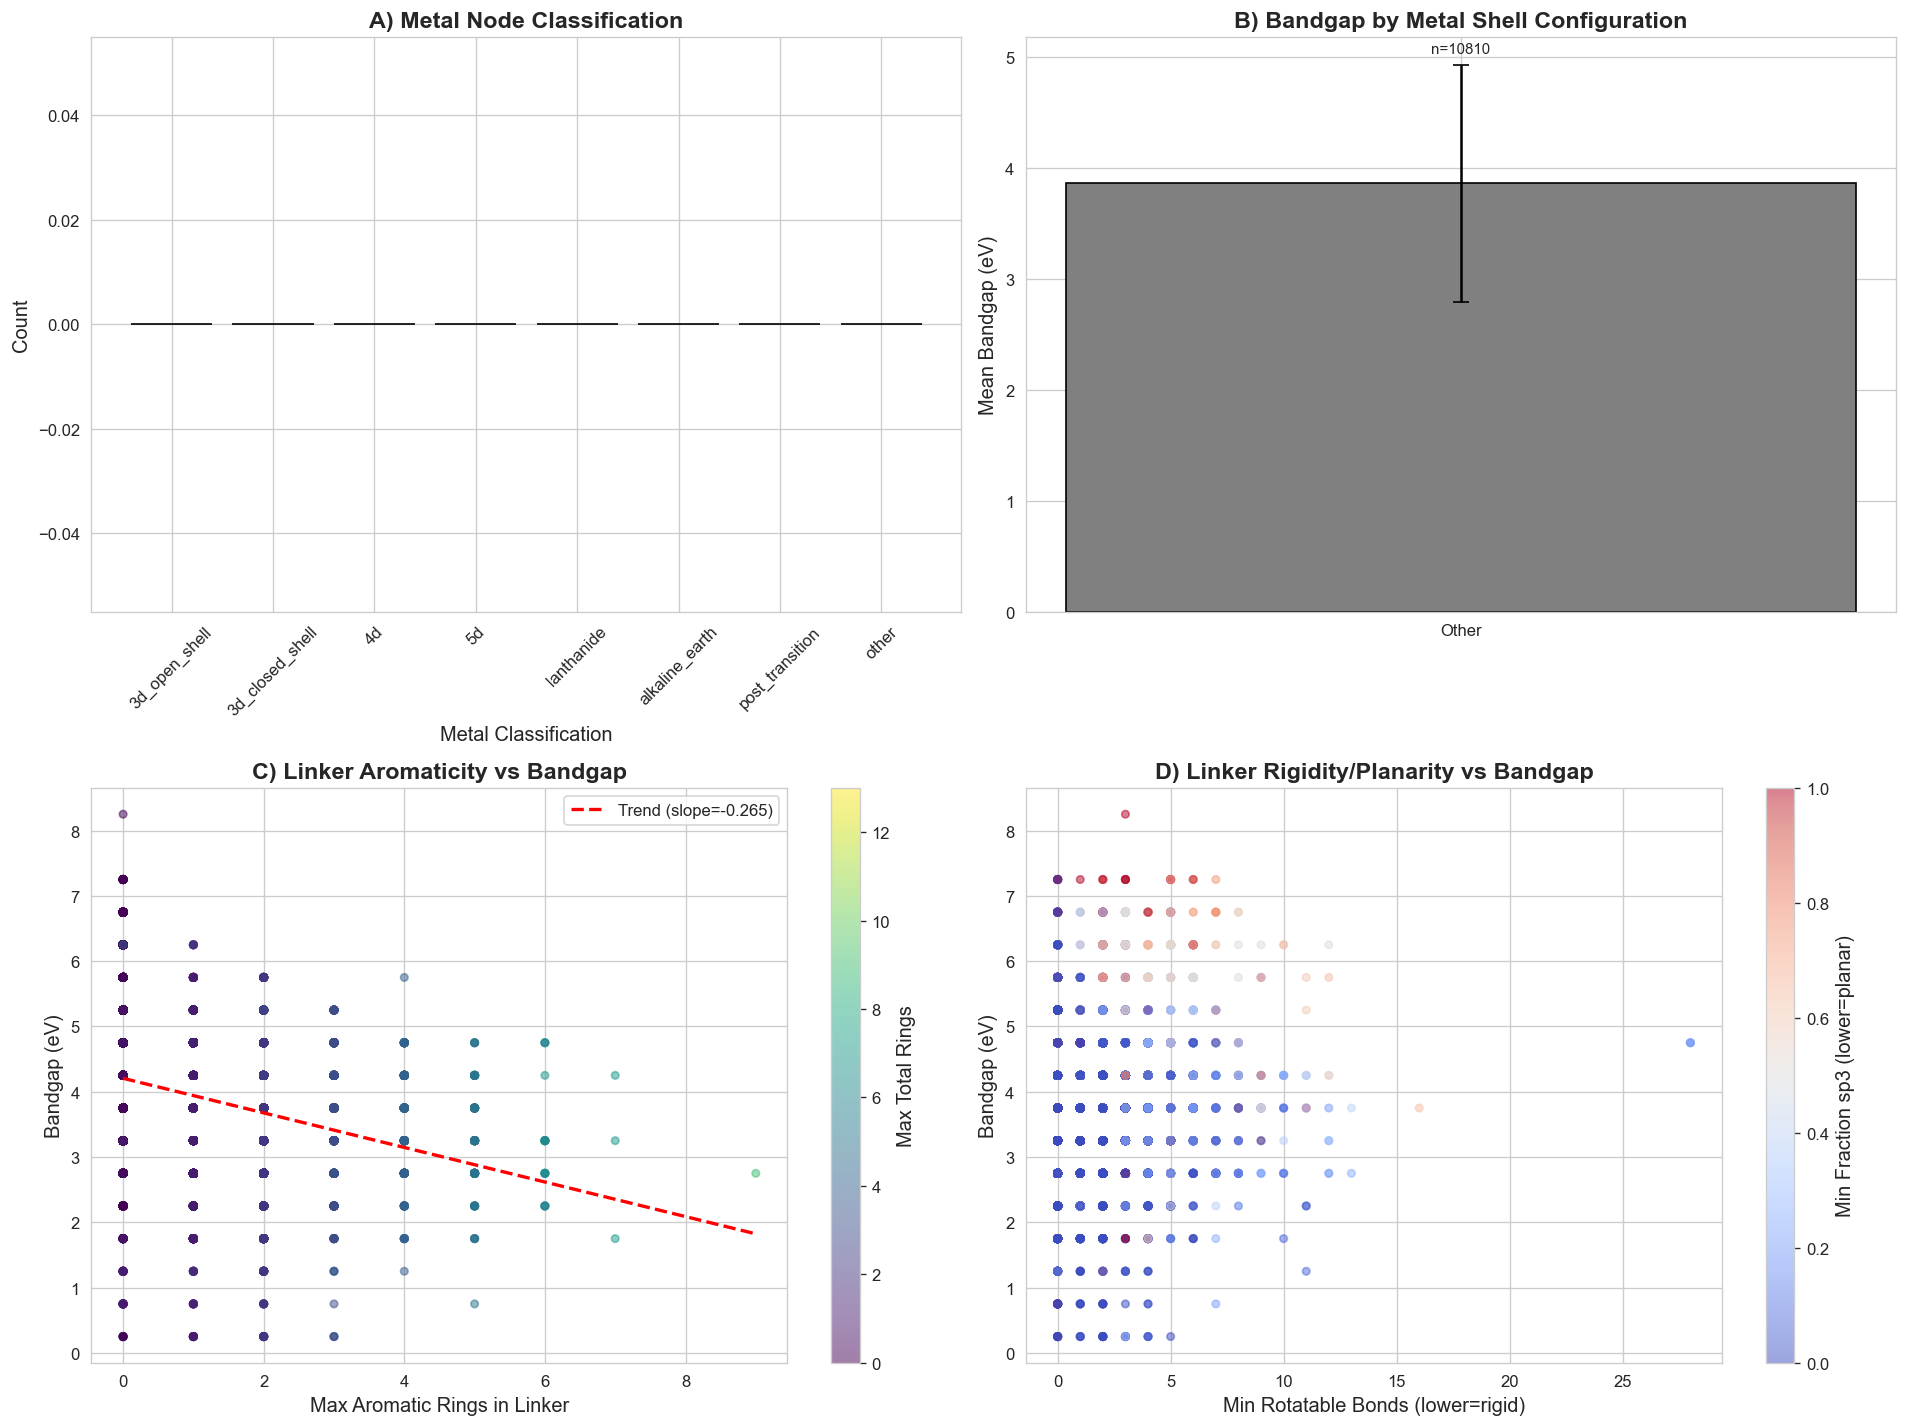

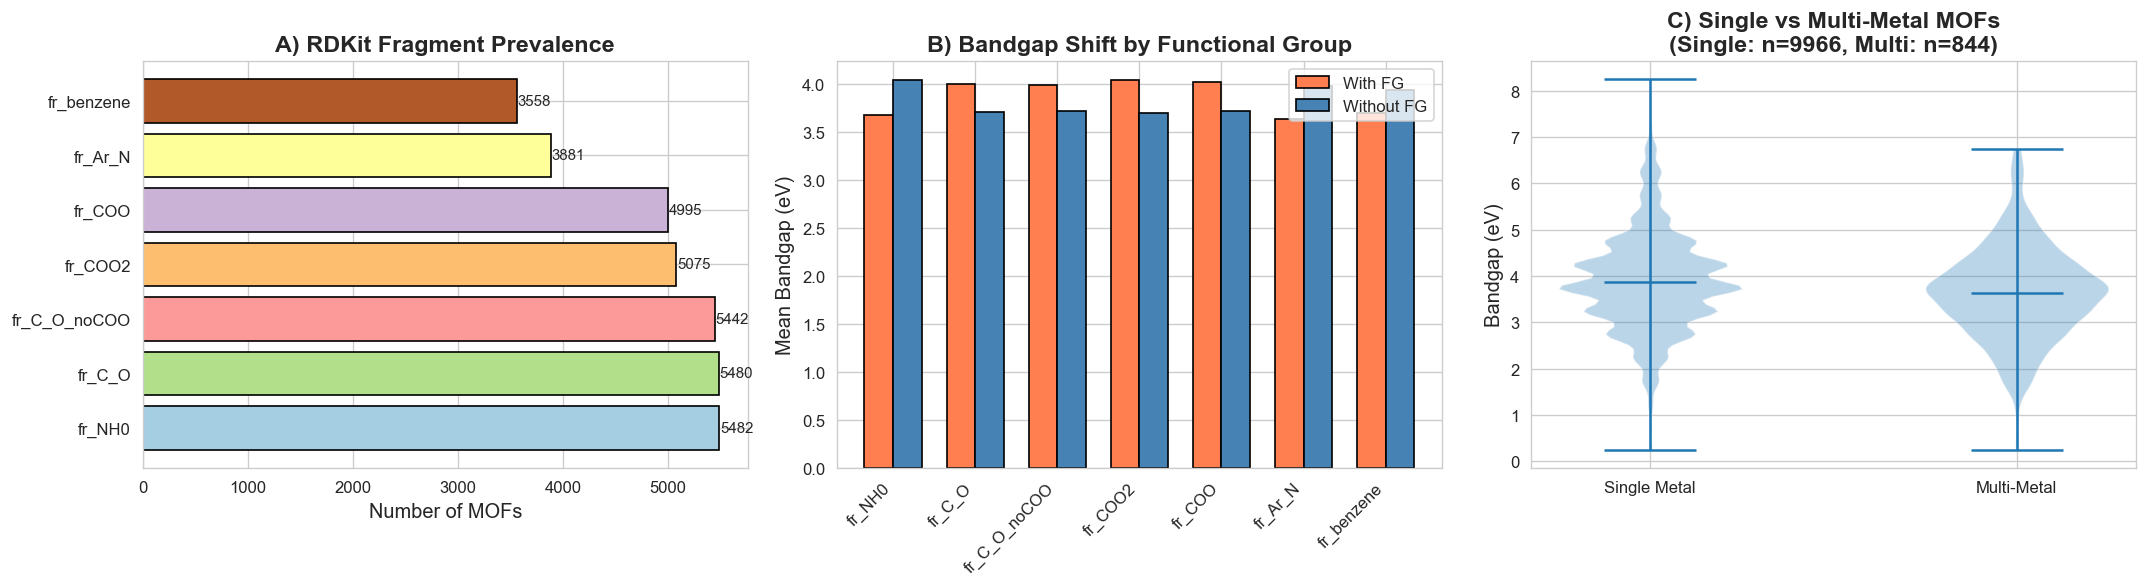


┌──────────────────────────────────────────────────────────┐
│ 📊 MODE: FULL                                  Correlation │
├──────────────────────────────────────────────────────────┤
│ Data: [████████████████████████████████████████] 100.0% │
│ Samples: 10,810 / 10,810                       │
└──────────────────────────────────────────────────────────┘

FEATURE-BANDGAP CORRELATION ANALYSIS

Feature                             |  Correlation |      p-value | Interpretation
-------------------------------------------------------------------------------------
linker_max_MolWt                    |     -0.136*** |     4.34e-36 | Moderate ↓ lower Eg
linker_sum_MolWt                    |     -0.128*** |     2.75e-32 | Moderate ↓ lower Eg
linker_max_NumHeavyAtoms            |     -0.158*** |     1.35e-48 | Moderate ↓ lower Eg
linker_max_NumAromaticRings         |     -0.284*** |    2.18e-157 | Moderate ↓ lower Eg
linker_sum_NumAromaticRings         |     -0.272*** |    1.04e-143 | Moderate ↓

In [67]:
# ==========================================
# 6. IMPROVED CHEMICAL FEATURE VISUALIZATION
# ==========================================

print("="*80)
print("CHEMICAL FEATURE ANALYSIS BY BANDGAP")
print("="*80)

# Filter to MOFs with successful formula parsing
if 'parse_success' in df_stratified.columns:
    df_chem = df_stratified[df_stratified['parse_success'] == True].copy()
elif 'extraction_confidence' in df_stratified.columns:
    df_chem = df_stratified[df_stratified['extraction_confidence'] == 'confident'].copy()
else:
    # Fallback: use all with non-null metal
    df_chem = df_stratified[df_stratified['metal'].notna()].copy()
print(f"Analyzing {len(df_chem)} MOFs with valid metal extraction")

# Create bandgap midpoint for correlation analysis
def get_bandgap_midpoint(bin_name):
    match = re.search(r'bandgap_([0-9.]+)_to_([0-9.]+)eV', str(bin_name))
    if match:
        return (float(match.group(1)) + float(match.group(2))) / 2
    return np.nan

df_chem['bandgap_mid'] = df_chem['analysis_bin'].apply(get_bandgap_midpoint)

# ==========================================
# FIGURE 1: Metal Class Distribution by Bandgap
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1A: Metal class distribution
ax = axes[0, 0]
class_order = ['3d_open_shell', '3d_closed_shell', '4d', '5d', 'lanthanide', 'alkaline_earth', 'post_transition', 'other']
class_counts = df_chem['metal_category'].value_counts().reindex(class_order).fillna(0)
colors = plt.cm.Set2(np.linspace(0, 1, len(class_counts)))
bars = ax.bar(class_counts.index, class_counts.values, color=colors, edgecolor='black')
ax.set_xlabel('Metal Classification', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('A) Metal Node Classification', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
for bar, cnt in zip(bars, class_counts.values):
    if cnt > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{int(cnt)}', ha='center', va='bottom', fontsize=9)

# 1B: Open-shell vs Closed-shell by bandgap
ax = axes[0, 1]
df_chem['shell_type'] = df_chem['metal_category'].apply(
    lambda x: 'Open-shell' if x == '3d_open_shell' else ('Closed-shell' if x == '3d_closed_shell' else 'Other')
)
shell_bandgap = df_chem.groupby('shell_type')['bandgap_mid'].agg(['mean', 'std', 'count'])
colors = {'Open-shell': 'coral', 'Closed-shell': 'steelblue', 'Other': 'gray'}
x_pos = range(len(shell_bandgap))
bars = ax.bar(x_pos, shell_bandgap['mean'], yerr=shell_bandgap['std'], 
              color=[colors.get(x, 'gray') for x in shell_bandgap.index], capsize=5, edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(shell_bandgap.index)
ax.set_ylabel('Mean Bandgap (eV)', fontsize=12)
ax.set_title('B) Bandgap by Metal Shell Configuration', fontsize=14, fontweight='bold')
for i, (idx, row) in enumerate(shell_bandgap.iterrows()):
    ax.text(i, row['mean'] + row['std'] + 0.1, f'n={int(row["count"])}', ha='center', fontsize=9)

# 1C: Aromatic Rings (Conjugation Proxy) vs Bandgap
ax = axes[1, 0]
df_valid = df_chem[df_chem['n_valid_linkers'] > 0]
if len(df_valid) > 0:
    sc = ax.scatter(df_valid['linker_max_NumAromaticRings'], df_valid['bandgap_mid'], 
                    c=df_valid['linker_max_NumRings'], cmap='viridis', alpha=0.5, s=20)
    plt.colorbar(sc, ax=ax, label='Max Total Rings')
    ax.set_xlabel('Max Aromatic Rings in Linker', fontsize=12)
    ax.set_ylabel('Bandgap (eV)', fontsize=12)
    ax.set_title('C) Linker Aromaticity vs Bandgap', fontsize=14, fontweight='bold')
    
    # Add trend line
    mask = ~(df_valid['linker_max_NumAromaticRings'].isna() | df_valid['bandgap_mid'].isna())
    if mask.sum() > 10:
        z = np.polyfit(df_valid.loc[mask, 'linker_max_NumAromaticRings'], 
                       df_valid.loc[mask, 'bandgap_mid'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(0, df_valid['linker_max_NumAromaticRings'].max(), 100)
        ax.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Trend (slope={z[0]:.3f})')
        ax.legend()

# 1D: Rigidity (rotatable bonds) vs Bandgap
ax = axes[1, 1]
if len(df_valid) > 0 and 'linker_min_NumRotatableBonds' in df_valid.columns:
    df_rigid = df_valid[df_valid['linker_min_NumRotatableBonds'].notna()]
    if len(df_rigid) > 0:
        sc = ax.scatter(df_rigid['linker_min_NumRotatableBonds'], df_rigid['bandgap_mid'],
                        c=df_rigid['linker_min_FractionCSP3'], cmap='coolwarm', alpha=0.5, s=20)
        plt.colorbar(sc, ax=ax, label='Min Fraction sp3 (lower=planar)')
        ax.set_xlabel('Min Rotatable Bonds (lower=rigid)', fontsize=12)
        ax.set_ylabel('Bandgap (eV)', fontsize=12)
        ax.set_title('D) Linker Rigidity/Planarity vs Bandgap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# FIGURE 2: Functional Groups Impact
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2A: Functional group prevalence (RDKit Fragments)
ax = axes[0]
frag_cols_all = [c for c in df_chem.columns if c.startswith('linker_frag_fr_')]
if len(frag_cols_all) == 0:
    ax.text(0.5, 0.5, 'No RDKit fragment data', ha='center', va='center', fontsize=12)
    fg_cols = []
    fg_names = []
else:
    frag_counts_series = (df_chem[frag_cols_all] > 0).sum().sort_values(ascending=False)
    fg_cols = frag_counts_series.head(7).index.tolist()
    fg_names = [c.replace('linker_frag_', '') for c in fg_cols]
    fg_counts = frag_counts_series.head(7).values

    colors = plt.cm.Paired(np.linspace(0, 1, len(fg_cols)))
    bars = ax.barh(fg_names, fg_counts, color=colors, edgecolor='black')
    ax.set_xlabel('Number of MOFs', fontsize=12)
    ax.set_title('A) RDKit Fragment Prevalence', fontsize=14, fontweight='bold')
    for bar, cnt in zip(bars, fg_counts):
        ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, f'{cnt}', va='center', fontsize=9)

# 2B: Bandgap by functional group presence
ax = axes[1]
fg_bandgaps = {}
if len(fg_cols) == 0:
    ax.text(0.5, 0.5, 'No fragment data for bandgap shift', ha='center', va='center', fontsize=12)
else:
    for col, name in zip(fg_cols, fg_names):
        with_fg = df_chem[df_chem[col] > 0]['bandgap_mid'].mean()
        without_fg = df_chem[df_chem[col] == 0]['bandgap_mid'].mean()
        fg_bandgaps[name] = {'With': with_fg, 'Without': without_fg}

    names = list(fg_bandgaps.keys())
    with_vals = [fg_bandgaps[n]['With'] for n in names]
    without_vals = [fg_bandgaps[n]['Without'] for n in names]

    x = np.arange(len(names))
    width = 0.35
    ax.bar(x - width/2, with_vals, width, label='With FG', color='coral', edgecolor='black')
    ax.bar(x + width/2, without_vals, width, label='Without FG', color='steelblue', edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels([n.split('(')[0].strip() for n in names], rotation=45, ha='right')
    ax.set_ylabel('Mean Bandgap (eV)', fontsize=12)
    ax.set_title('B) Bandgap Shift by Functional Group', fontsize=14, fontweight='bold')
    ax.legend()

# 2C: Multi-metal vs single-metal
ax = axes[2]
multi_metal = df_chem[df_chem['is_mixed_metal'] == True]['bandgap_mid']
single_metal = df_chem[df_chem['is_mixed_metal'] == False]['bandgap_mid']
ax.violinplot([single_metal.dropna(), multi_metal.dropna()], positions=[0, 1], showmeans=True)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Single Metal', 'Multi-Metal'])
ax.set_ylabel('Bandgap (eV)', fontsize=12)
ax.set_title(f'C) Single vs Multi-Metal MOFs\n(Single: n={len(single_metal)}, Multi: n={len(multi_metal)})', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# CORRELATION ANALYSIS
# ==========================================
show_data_coverage("Correlation")

print("\n" + "="*80)
print("FEATURE-BANDGAP CORRELATION ANALYSIS")
print("="*80)

numeric_features = [
    'linker_max_MolWt', 'linker_sum_MolWt', 'linker_max_NumHeavyAtoms', 
    'linker_max_NumAromaticRings', 'linker_sum_NumAromaticRings',
    'linker_max_NumRings', 'linker_min_NumRotatableBonds',
    'linker_min_FractionCSP3', 'linker_max_FractionCSP3',
    'linker_max_NumHeteroatoms', 'linker_max_TPSA', 'linker_max_NumHBD',
    'info.density'
]

print(f"\n{'Feature':<35} | {'Correlation':>12} | {'p-value':>12} | Interpretation")
print("-" * 85)

from scipy import stats

for feat in numeric_features:
    if feat in df_chem.columns:
        mask = df_chem[feat].notna() & df_chem['bandgap_mid'].notna()
        if mask.sum() > 30:
            r, p = stats.pearsonr(df_chem.loc[mask, feat], df_chem.loc[mask, 'bandgap_mid'])
            
            if abs(r) > 0.3:
                strength = "Strong"
            elif abs(r) > 0.1:
                strength = "Moderate"
            else:
                strength = "Weak"
            
            direction = "↑ higher Eg" if r > 0 else "↓ lower Eg"
            sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
            
            print(f"{feat:<35} | {r:>+10.3f}{sig} | {p:>12.2e} | {strength} {direction}")

print("\n" + "="*80)

COMPREHENSIVE BANDGAP-PROPERTY RELATIONSHIP ANALYSIS
Analyzing 10810 MOFs with valid metal extraction

1. PERIODIC TABLE ANALYSIS: Average Bandgap by Metal


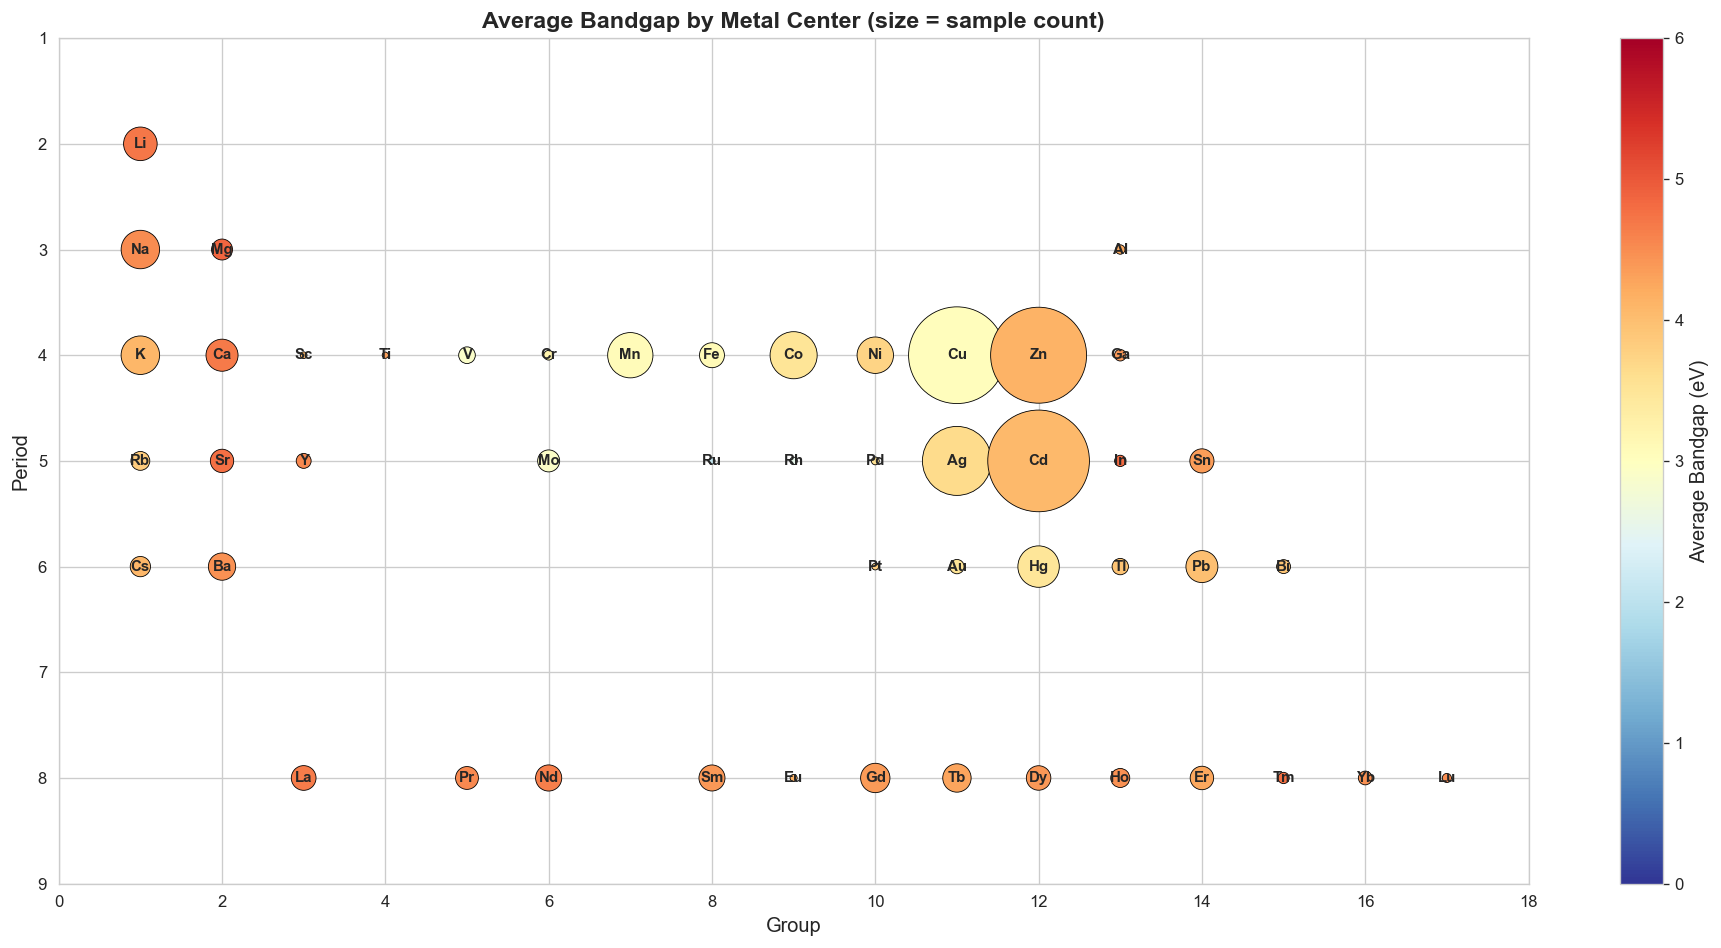


METALS WITH LOWEST AVERAGE BANDGAP (potential visible-light catalysts):
  Ru  : 2.11 ± 0.56 eV (n=7)
  Rh  : 2.55 ± 1.01 eV (n=10)
  V   : 2.90 ± 0.64 eV (n=50)
  Mo  : 2.93 ± 0.88 eV (n=87)
  Cu  : 3.03 ± 0.80 eV (n=1684)
  Mn  : 3.08 ± 1.05 eV (n=369)
  Fe  : 3.11 ± 0.73 eV (n=112)
  Cr  : 3.22 ± 1.08 eV (n=17)
  Hg  : 3.49 ± 0.74 eV (n=309)
  Co  : 3.49 ± 0.82 eV (n=399)

METALS WITH HIGHEST AVERAGE BANDGAP:
  Mg  : 4.87 ± 1.27 eV (n=79)
  In  : 4.82 ± 0.93 eV (n=23)
  Tm  : 4.77 ± 0.80 eV (n=23)
  Sr  : 4.77 ± 1.22 eV (n=98)
  Li  : 4.69 ± 1.38 eV (n=203)

2. d-ELECTRON CONFIGURATION EFFECTS


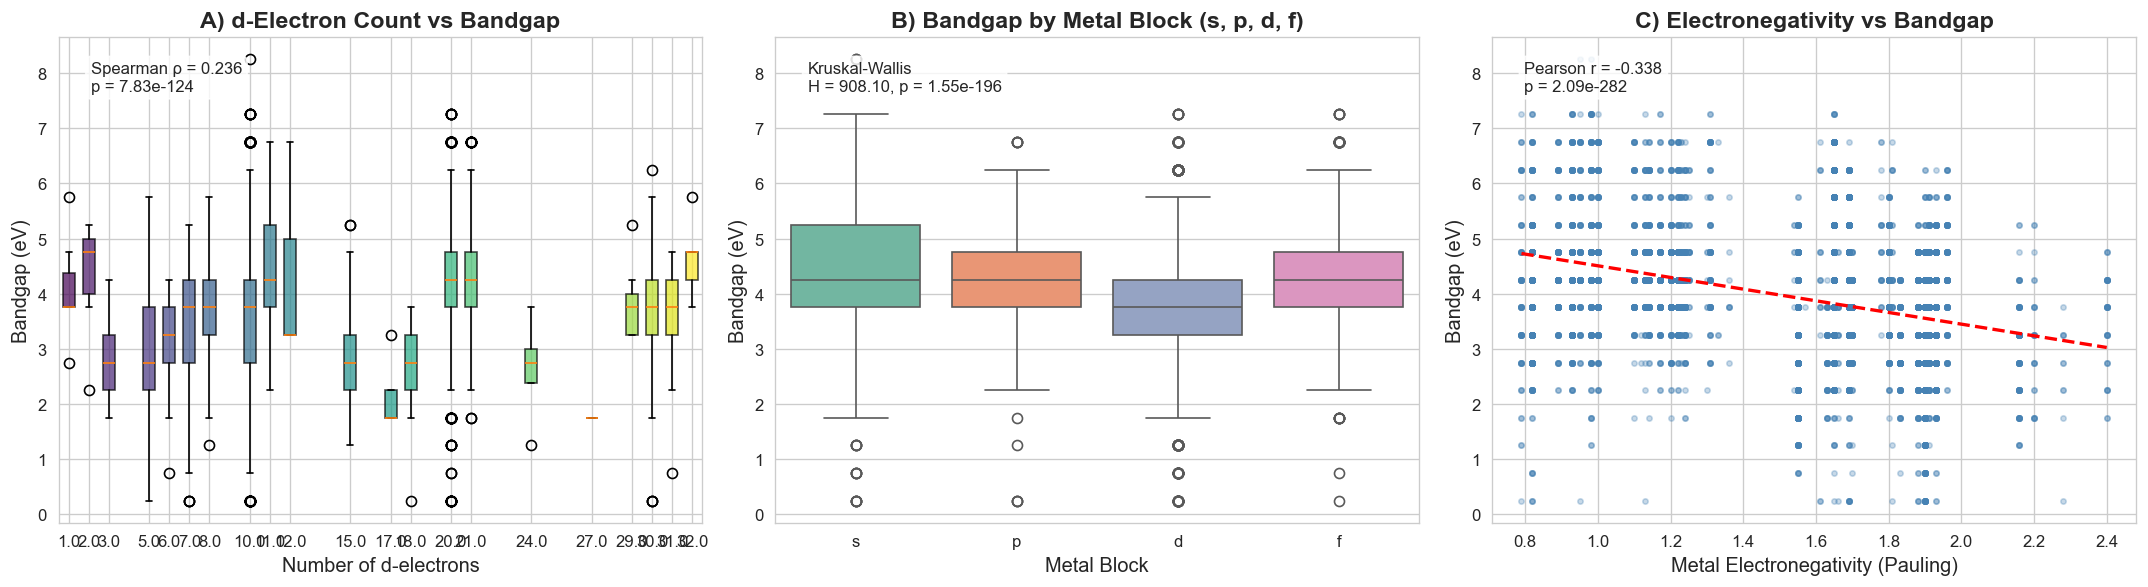


3. LINKER CONJUGATION (π-SYSTEM) EFFECTS ON BANDGAP


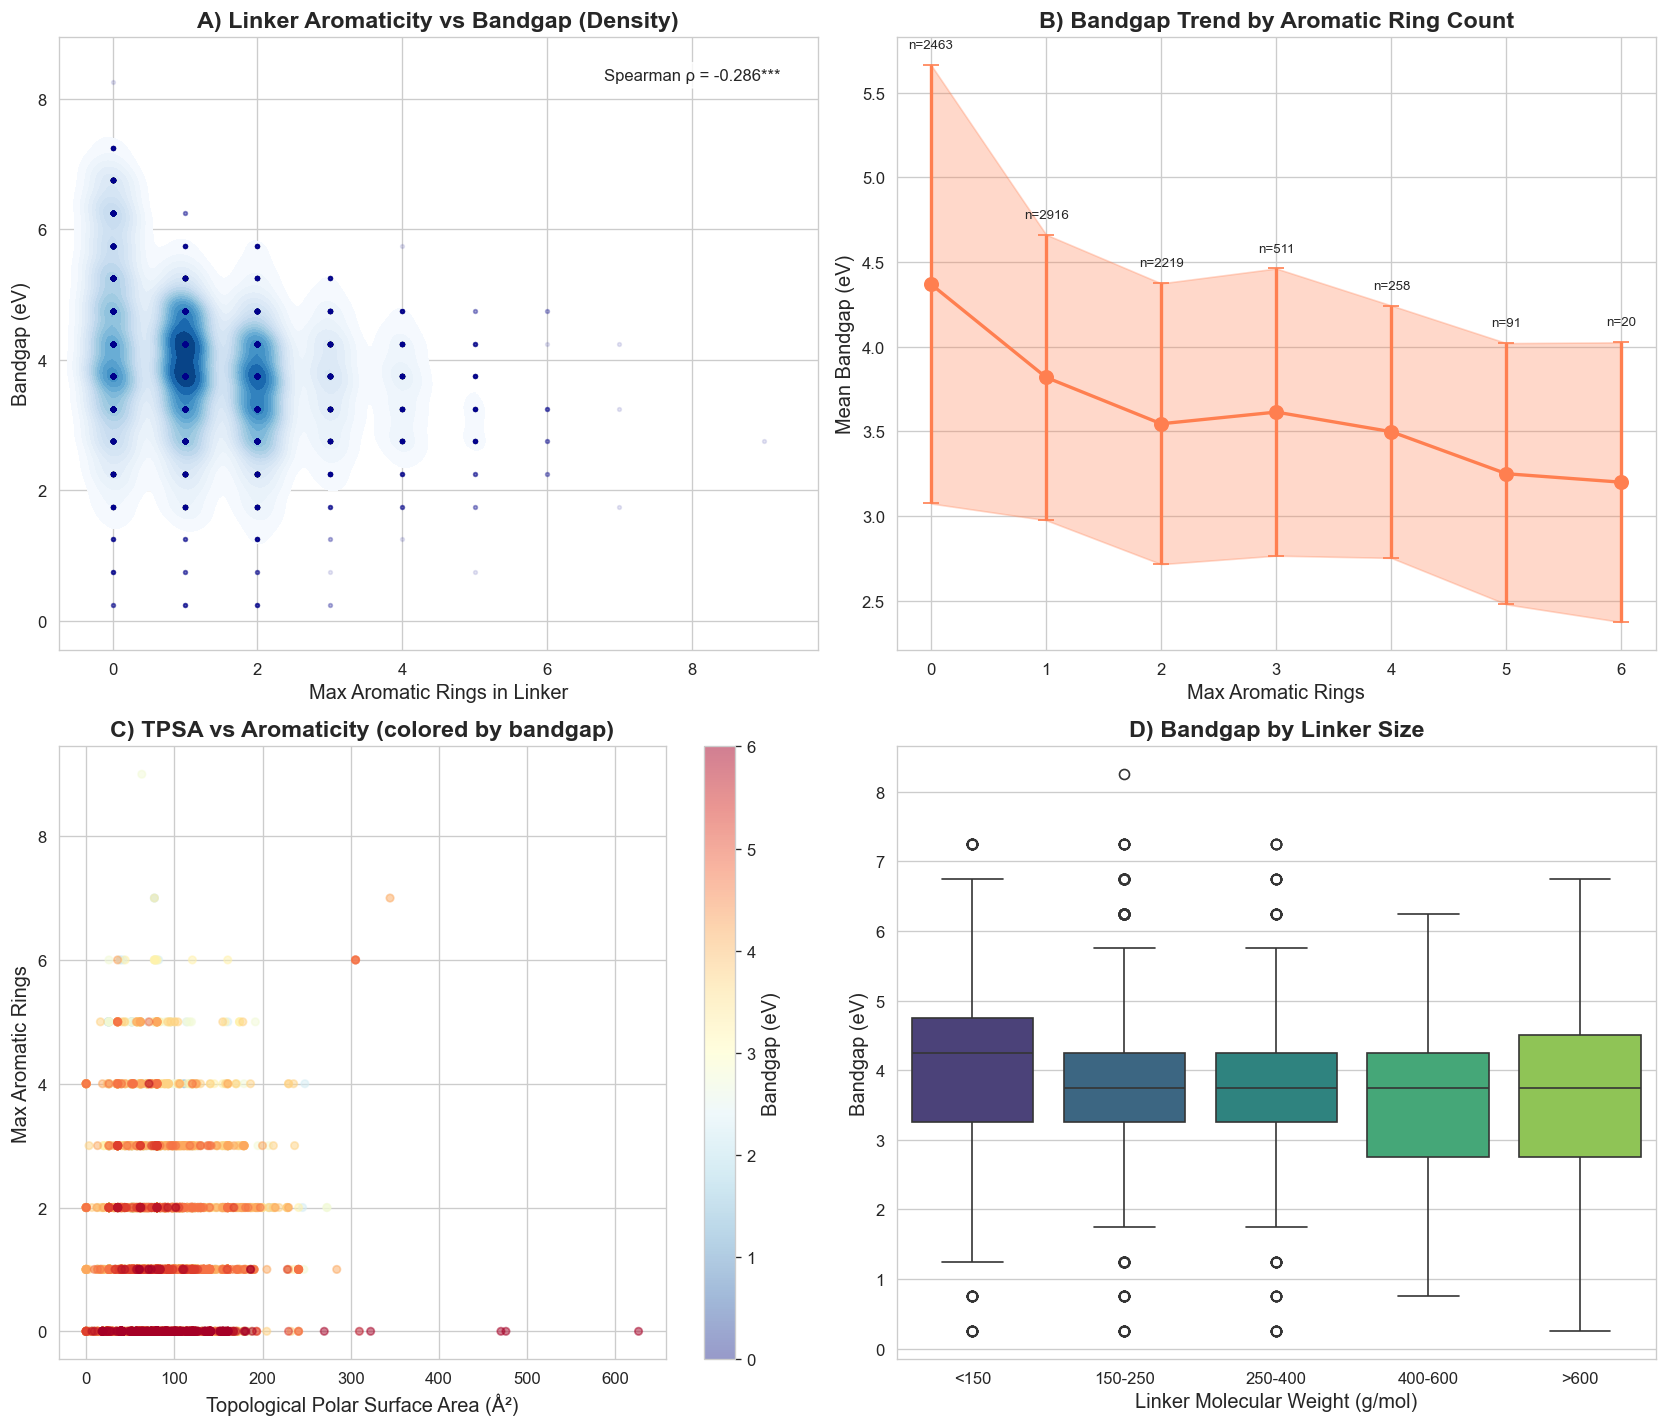


4. MULTI-METAL AND COORDINATION EFFECTS


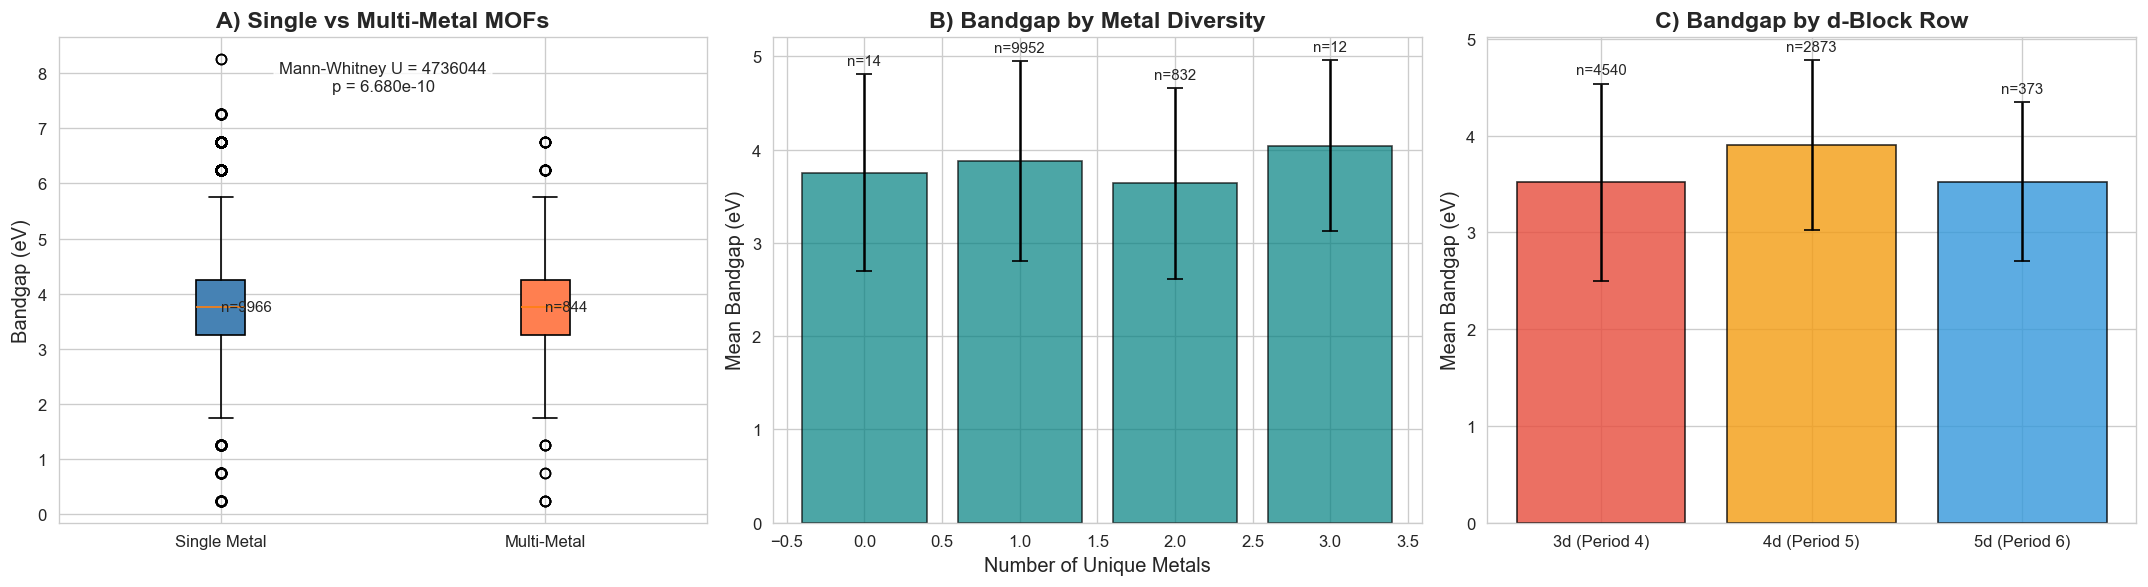


5. FEATURE CORRELATION ANALYSIS


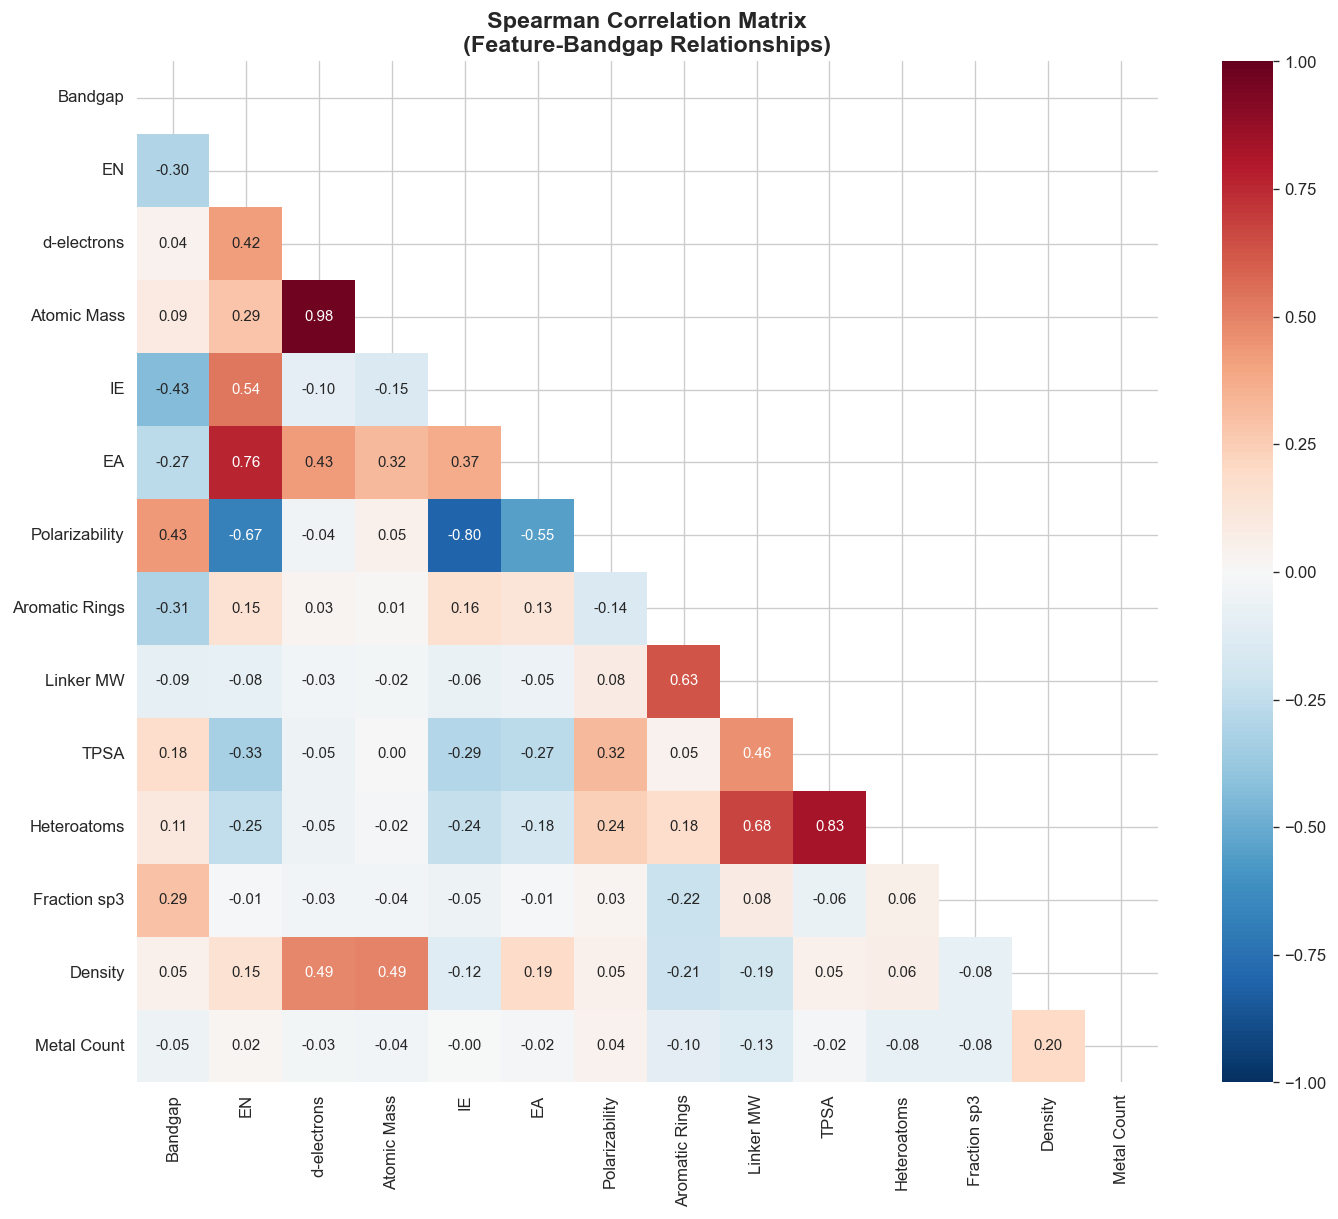


KEY CORRELATIONS WITH BANDGAP (Spearman ρ):
--------------------------------------------------
  IE                  : ρ = -0.432 (Strong ↓)
  Polarizability      : ρ = +0.430 (Strong ↑)
  Aromatic Rings      : ρ = -0.307 (Strong ↓)
  EN                  : ρ = -0.300 (Strong ↓)
  Fraction sp3        : ρ = +0.289 (Moderate ↑)
  EA                  : ρ = -0.270 (Moderate ↓)
  TPSA                : ρ = +0.180 (Moderate ↑)
  Heteroatoms         : ρ = +0.109 (Moderate ↑)
  Atomic Mass         : ρ = +0.090 (Weak ↑)
  Linker MW           : ρ = -0.087 (Weak ↓)
  Density             : ρ = +0.053 (Weak ↑)
  Metal Count         : ρ = -0.049 (Weak ↓)
  d-electrons         : ρ = +0.045 (Weak ↑)

SUMMARY: CHEMICAL FACTORS AFFECTING MOF BANDGAPS

KEY FINDINGS FROM PACKAGE-BASED ANALYSIS:

🔬 METAL CENTER EFFECTS:
   - d-block metals (transition metals) show wide bandgap range
   - d-electron count correlates with electronic structure
   - Electronegativity affects charge transfer and bandgap
   - 3d 

In [68]:
# ==========================================
# 7. COMPREHENSIVE BANDGAP-PROPERTY ANALYSIS
# ==========================================
"""
This cell provides in-depth analysis of how chemical features affect bandgaps.
Uses scipy.stats for statistical tests and seaborn for publication-quality plots.

KEY ANALYSES:
1. Metal d-electron effects on bandgap
2. Electronegativity correlations
3. Linker conjugation (aromaticity) effects
4. Functional group impact
5. Mixed-metal effects
6. Periodic table heatmap of average bandgaps
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, kruskal, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("COMPREHENSIVE BANDGAP-PROPERTY RELATIONSHIP ANALYSIS")
print("="*80)

# Use df_stratified with all extracted features
df_analysis = df_stratified.copy()

# Filter to confident extractions
if 'parse_success' in df_analysis.columns:
    df_analysis = df_analysis[df_analysis['parse_success'] == True].copy()
elif 'extraction_confidence' in df_analysis.columns:
    df_analysis = df_analysis[df_analysis['extraction_confidence'] == 'confident'].copy()

# Create bandgap midpoint
def get_bandgap_mid(bin_name):
    import re
    match = re.search(r'bandgap_([0-9.]+)_to_([0-9.]+)eV', str(bin_name))
    if match:
        return (float(match.group(1)) + float(match.group(2))) / 2
    return np.nan

df_analysis['bandgap_mid'] = df_analysis['analysis_bin'].apply(get_bandgap_mid)
print(f"Analyzing {len(df_analysis)} MOFs with valid metal extraction\n")

# ==========================================
# FIGURE 1: PERIODIC TABLE HEATMAP OF BANDGAPS
# ==========================================
print("="*60)
print("1. PERIODIC TABLE ANALYSIS: Average Bandgap by Metal")
print("="*60)

fig, ax = plt.subplots(figsize=(16, 8))

# Get average bandgap per metal
metal_bandgaps = df_analysis.groupby('primary_metal')['bandgap_mid'].agg(['mean', 'std', 'count'])
metal_bandgaps = metal_bandgaps[metal_bandgaps['count'] >= 5]  # Only metals with 5+ samples

# Periodic table positions (group, period)
periodic_positions = {
    # Alkali
    'Li': (1, 2), 'Na': (1, 3), 'K': (1, 4), 'Rb': (1, 5), 'Cs': (1, 6),
    # Alkaline earth
    'Be': (2, 2), 'Mg': (2, 3), 'Ca': (2, 4), 'Sr': (2, 5), 'Ba': (2, 6),
    # 3d transition metals
    'Sc': (3, 4), 'Ti': (4, 4), 'V': (5, 4), 'Cr': (6, 4), 'Mn': (7, 4),
    'Fe': (8, 4), 'Co': (9, 4), 'Ni': (10, 4), 'Cu': (11, 4), 'Zn': (12, 4),
    # 4d transition metals
    'Y': (3, 5), 'Zr': (4, 5), 'Nb': (5, 5), 'Mo': (6, 5), 'Tc': (7, 5),
    'Ru': (8, 5), 'Rh': (9, 5), 'Pd': (10, 5), 'Ag': (11, 5), 'Cd': (12, 5),
    # 5d transition metals  
    'Hf': (4, 6), 'Ta': (5, 6), 'W': (6, 6), 'Re': (7, 6),
    'Os': (8, 6), 'Ir': (9, 6), 'Pt': (10, 6), 'Au': (11, 6), 'Hg': (12, 6),
    # Post-transition
    'Al': (13, 3), 'Ga': (13, 4), 'In': (13, 5), 'Tl': (13, 6),
    'Sn': (14, 5), 'Pb': (14, 6), 'Bi': (15, 6),
    # Lanthanides (placed at bottom)
    'La': (3, 8), 'Ce': (4, 8), 'Pr': (5, 8), 'Nd': (6, 8), 'Sm': (8, 8),
    'Eu': (9, 8), 'Gd': (10, 8), 'Tb': (11, 8), 'Dy': (12, 8), 'Ho': (13, 8),
    'Er': (14, 8), 'Tm': (15, 8), 'Yb': (16, 8), 'Lu': (17, 8),
}

# Create scatter plot colored by bandgap
metals_plotted = []
for metal in metal_bandgaps.index:
    if metal in periodic_positions:
        group, period = periodic_positions[metal]
        mean_bg = metal_bandgaps.loc[metal, 'mean']
        count = metal_bandgaps.loc[metal, 'count']
        metals_plotted.append({
            'metal': metal, 'group': group, 'period': period,
            'bandgap': mean_bg, 'count': count
        })

df_periodic = pd.DataFrame(metals_plotted)
if len(df_periodic) > 0:
    scatter = ax.scatter(df_periodic['group'], df_periodic['period'], 
                        c=df_periodic['bandgap'], cmap='RdYlBu_r', 
                        s=df_periodic['count']*2, edgecolor='black', linewidth=0.5,
                        vmin=0, vmax=6)
    
    # Add element labels
    for _, row in df_periodic.iterrows():
        ax.annotate(row['metal'], (row['group'], row['period']), 
                   ha='center', va='center', fontsize=9, fontweight='bold')
    
    plt.colorbar(scatter, ax=ax, label='Average Bandgap (eV)')
    ax.set_xlabel('Group', fontsize=12)
    ax.set_ylabel('Period', fontsize=12)
    ax.set_title('Average Bandgap by Metal Center (size = sample count)', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.set_xlim(0, 18)
    ax.set_ylim(9, 1)

plt.tight_layout()
plt.show()

# Print top/bottom metals by bandgap
print("\nMETALS WITH LOWEST AVERAGE BANDGAP (potential visible-light catalysts):")
for metal, row in metal_bandgaps.nsmallest(10, 'mean').iterrows():
    print(f"  {metal:<4}: {row['mean']:.2f} ± {row['std']:.2f} eV (n={int(row['count'])})")

print("\nMETALS WITH HIGHEST AVERAGE BANDGAP:")
for metal, row in metal_bandgaps.nlargest(5, 'mean').iterrows():
    print(f"  {metal:<4}: {row['mean']:.2f} ± {row['std']:.2f} eV (n={int(row['count'])})")

# ==========================================
# FIGURE 2: d-ELECTRON EFFECTS ON BANDGAP
# ==========================================
print("\n" + "="*60)
print("2. d-ELECTRON CONFIGURATION EFFECTS")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2A: d-electrons vs bandgap
ax = axes[0]
if 'metal_d_electrons' in df_analysis.columns:
    df_d = df_analysis[df_analysis['metal_d_electrons'].notna() & (df_analysis['metal_d_electrons'] > 0)]
    if len(df_d) > 10:
        # Box plot by d-electron count
        d_groups = df_d.groupby('metal_d_electrons')['bandgap_mid'].apply(list).to_dict()
        positions = sorted(d_groups.keys())
        data = [d_groups[p] for p in positions]
        bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True)
        
        # Color by d-electron count
        colors = plt.cm.viridis(np.linspace(0, 1, len(positions)))
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.set_xlabel('Number of d-electrons', fontsize=12)
        ax.set_ylabel('Bandgap (eV)', fontsize=12)
        ax.set_title('A) d-Electron Count vs Bandgap', fontsize=14, fontweight='bold')
        
        # Add correlation
        r, p = spearmanr(df_d['metal_d_electrons'], df_d['bandgap_mid'])
        ax.text(0.05, 0.95, f'Spearman ρ = {r:.3f}\np = {p:.2e}', 
               transform=ax.transAxes, fontsize=10, va='top',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        ax.text(0.5, 0.5, 'Insufficient d-electron data', ha='center', va='center')
else:
    ax.text(0.5, 0.5, 'Run Cell 8 with mendeleev\nfor d-electron data', ha='center', va='center')

# 2B: Metal block effects
ax = axes[1]
if 'metal_block' in df_analysis.columns:
    block_order = ['s', 'p', 'd', 'f']
    df_block = df_analysis[df_analysis['metal_block'].isin(block_order)]
    if len(df_block) > 10:
        sns.boxplot(data=df_block, x='metal_block', y='bandgap_mid', 
                   order=block_order, palette='Set2', ax=ax)
        ax.set_xlabel('Metal Block', fontsize=12)
        ax.set_ylabel('Bandgap (eV)', fontsize=12)
        ax.set_title('B) Bandgap by Metal Block (s, p, d, f)', fontsize=14, fontweight='bold')
        
        # Kruskal-Wallis test
        groups = [df_block[df_block['metal_block']==b]['bandgap_mid'].dropna() for b in block_order]
        groups = [g for g in groups if len(g) > 2]
        if len(groups) >= 2:
            H, p = kruskal(*groups)
            ax.text(0.05, 0.95, f'Kruskal-Wallis\nH = {H:.2f}, p = {p:.2e}', 
                   transform=ax.transAxes, fontsize=10, va='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 2C: Electronegativity vs Bandgap
ax = axes[2]
if 'metal_electronegativity' in df_analysis.columns:
    df_en = df_analysis[df_analysis['metal_electronegativity'].notna()]
    if len(df_en) > 10:
        ax.scatter(df_en['metal_electronegativity'], df_en['bandgap_mid'], 
                  alpha=0.3, s=10, c='steelblue')
        
        # Add trend line
        mask = ~(df_en['metal_electronegativity'].isna() | df_en['bandgap_mid'].isna())
        if mask.sum() > 10:
            z = np.polyfit(df_en.loc[mask, 'metal_electronegativity'], 
                          df_en.loc[mask, 'bandgap_mid'], 1)
            p = np.poly1d(z)
            x_line = np.linspace(df_en['metal_electronegativity'].min(), 
                                df_en['metal_electronegativity'].max(), 100)
            ax.plot(x_line, p(x_line), 'r--', linewidth=2)
            
            r, pval = pearsonr(df_en.loc[mask, 'metal_electronegativity'], 
                              df_en.loc[mask, 'bandgap_mid'])
            ax.text(0.05, 0.95, f'Pearson r = {r:.3f}\np = {pval:.2e}', 
                   transform=ax.transAxes, fontsize=10, va='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.set_xlabel('Metal Electronegativity (Pauling)', fontsize=12)
        ax.set_ylabel('Bandgap (eV)', fontsize=12)
        ax.set_title('C) Electronegativity vs Bandgap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# FIGURE 3: LINKER CONJUGATION EFFECTS
# ==========================================
print("\n" + "="*60)
print("3. LINKER CONJUGATION (π-SYSTEM) EFFECTS ON BANDGAP")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Check for linker columns
arom_col = None
for col in ['linker_max_NumAromaticRings', 'linker_max_aromatic']:
    if col in df_analysis.columns:
        arom_col = col
        break

# 3A: Aromatic rings vs bandgap (2D density)
ax = axes[0, 0]
if arom_col and len(df_analysis[df_analysis[arom_col].notna()]) > 10:
    df_arom = df_analysis[df_analysis[arom_col].notna()]
    sns.kdeplot(data=df_arom, x=arom_col, y='bandgap_mid', 
               cmap='Blues', fill=True, levels=20, ax=ax)
    ax.scatter(df_arom[arom_col], df_arom['bandgap_mid'], 
              alpha=0.1, s=5, c='darkblue')
    ax.set_xlabel('Max Aromatic Rings in Linker', fontsize=12)
    ax.set_ylabel('Bandgap (eV)', fontsize=12)
    ax.set_title('A) Linker Aromaticity vs Bandgap (Density)', fontsize=14, fontweight='bold')
    
    # Correlation
    r, p = spearmanr(df_arom[arom_col], df_arom['bandgap_mid'])
    ax.text(0.95, 0.95, f'Spearman ρ = {r:.3f}***' if p < 0.001 else f'Spearman ρ = {r:.3f}', 
           transform=ax.transAxes, ha='right', va='top', fontsize=10,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
else:
    ax.text(0.5, 0.5, 'No aromatic ring data', ha='center', va='center')

# 3B: Conjugation trend line by aromatic ring count
ax = axes[0, 1]
if arom_col:
    df_arom = df_analysis[df_analysis[arom_col].notna()]
    ring_stats = df_arom.groupby(arom_col)['bandgap_mid'].agg(['mean', 'std', 'count'])
    ring_stats = ring_stats[ring_stats['count'] >= 5]
    
    if len(ring_stats) > 2:
        ax.errorbar(ring_stats.index, ring_stats['mean'], yerr=ring_stats['std'],
                   fmt='o-', capsize=5, markersize=8, linewidth=2, color='coral')
        ax.fill_between(ring_stats.index, 
                       ring_stats['mean'] - ring_stats['std'],
                       ring_stats['mean'] + ring_stats['std'], alpha=0.3, color='coral')
        ax.set_xlabel('Max Aromatic Rings', fontsize=12)
        ax.set_ylabel('Mean Bandgap (eV)', fontsize=12)
        ax.set_title('B) Bandgap Trend by Aromatic Ring Count', fontsize=14, fontweight='bold')
        
        # Add sample counts
        for rings, row in ring_stats.iterrows():
            ax.annotate(f'n={int(row["count"])}', (rings, row['mean'] + row['std'] + 0.1),
                       ha='center', fontsize=8)

# 3C: HOMO-LUMO proxy (using TPSA and aromaticity)
ax = axes[1, 0]
if 'linker_max_TPSA' in df_analysis.columns and arom_col:
    df_hl = df_analysis[(df_analysis['linker_max_TPSA'].notna()) & 
                        (df_analysis[arom_col].notna())]
    if len(df_hl) > 20:
        scatter = ax.scatter(df_hl['linker_max_TPSA'], df_hl[arom_col],
                           c=df_hl['bandgap_mid'], cmap='RdYlBu_r',
                           alpha=0.5, s=20, vmin=0, vmax=6)
        plt.colorbar(scatter, ax=ax, label='Bandgap (eV)')
        ax.set_xlabel('Topological Polar Surface Area (Å²)', fontsize=12)
        ax.set_ylabel('Max Aromatic Rings', fontsize=12)
        ax.set_title('C) TPSA vs Aromaticity (colored by bandgap)', fontsize=14, fontweight='bold')

# 3D: Linker MW effect
ax = axes[1, 1]
mw_col = None
for col in ['linker_max_MolWt', 'linker_max_mw']:
    if col in df_analysis.columns:
        mw_col = col
        break

if mw_col:
    df_mw = df_analysis[df_analysis[mw_col].notna() & (df_analysis[mw_col] > 0)]
    if len(df_mw) > 20:
        # Bin by MW
        df_mw['mw_bin'] = pd.cut(df_mw[mw_col], bins=[0, 150, 250, 400, 600, 2000],
                                labels=['<150', '150-250', '250-400', '400-600', '>600'])
        sns.boxplot(data=df_mw, x='mw_bin', y='bandgap_mid', palette='viridis', ax=ax)
        ax.set_xlabel('Linker Molecular Weight (g/mol)', fontsize=12)
        ax.set_ylabel('Bandgap (eV)', fontsize=12)
        ax.set_title('D) Bandgap by Linker Size', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# FIGURE 4: MIXED-METAL AND COORDINATION EFFECTS
# ==========================================
print("\n" + "="*60)
print("4. MULTI-METAL AND COORDINATION EFFECTS")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 4A: Single vs Multi-metal
ax = axes[0]
if 'is_mixed_metal' in df_analysis.columns:
    df_mm = df_analysis[df_analysis['is_mixed_metal'].notna()]
    single = df_mm[df_mm['is_mixed_metal'] == False]['bandgap_mid'].dropna()
    multi = df_mm[df_mm['is_mixed_metal'] == True]['bandgap_mid'].dropna()
    
    if len(single) > 5 and len(multi) > 5:
        bp = ax.boxplot([single, multi], labels=['Single Metal', 'Multi-Metal'],
                       patch_artist=True)
        bp['boxes'][0].set_facecolor('steelblue')
        bp['boxes'][1].set_facecolor('coral')
        
        ax.set_ylabel('Bandgap (eV)', fontsize=12)
        ax.set_title('A) Single vs Multi-Metal MOFs', fontsize=14, fontweight='bold')
        
        # Mann-Whitney U test
        U, p = mannwhitneyu(single, multi)
        ax.text(0.5, 0.95, f'Mann-Whitney U = {U:.0f}\np = {p:.3e}',
               transform=ax.transAxes, ha='center', va='top',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.text(1, single.median(), f'n={len(single)}', ha='left', va='center', fontsize=9)
        ax.text(2, multi.median(), f'n={len(multi)}', ha='left', va='center', fontsize=9)

# 4B: Metal count effect
ax = axes[1]
if 'metal_count' in df_analysis.columns:
    df_mc = df_analysis[df_analysis['metal_count'].notna()]
    mc_stats = df_mc.groupby('metal_count')['bandgap_mid'].agg(['mean', 'std', 'count'])
    mc_stats = mc_stats[mc_stats['count'] >= 5]
    
    if len(mc_stats) > 1:
        ax.bar(mc_stats.index, mc_stats['mean'], yerr=mc_stats['std'],
              capsize=5, color='teal', edgecolor='black', alpha=0.7)
        ax.set_xlabel('Number of Unique Metals', fontsize=12)
        ax.set_ylabel('Mean Bandgap (eV)', fontsize=12)
        ax.set_title('B) Bandgap by Metal Diversity', fontsize=14, fontweight='bold')
        
        for idx, row in mc_stats.iterrows():
            ax.text(idx, row['mean'] + row['std'] + 0.1, f'n={int(row["count"])}',
                   ha='center', fontsize=9)

# 4C: 3d row effect (for transition metals)
ax = axes[2]
if 'metal_row' in df_analysis.columns and 'metal_block' in df_analysis.columns:
    df_tm = df_analysis[(df_analysis['metal_block'] == 'd') & 
                        (df_analysis['metal_row'].isin([4, 5, 6]))]
    if len(df_tm) > 20:
        row_stats = df_tm.groupby('metal_row')['bandgap_mid'].agg(['mean', 'std', 'count'])
        colors = ['#e74c3c', '#f39c12', '#3498db']  # 3d, 4d, 5d
        labels = ['3d (Period 4)', '4d (Period 5)', '5d (Period 6)']
        
        ax.bar(range(len(row_stats)), row_stats['mean'], yerr=row_stats['std'],
              capsize=5, color=colors[:len(row_stats)], edgecolor='black', alpha=0.8)
        ax.set_xticks(range(len(row_stats)))
        ax.set_xticklabels(labels[:len(row_stats)])
        ax.set_ylabel('Mean Bandgap (eV)', fontsize=12)
        ax.set_title('C) Bandgap by d-Block Row', fontsize=14, fontweight='bold')
        
        for i, (idx, row) in enumerate(row_stats.iterrows()):
            ax.text(i, row['mean'] + row['std'] + 0.1, f'n={int(row["count"])}',
                   ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# ==========================================
# FIGURE 5: COMPREHENSIVE CORRELATION HEATMAP
# ==========================================
print("\n" + "="*60)
print("5. FEATURE CORRELATION ANALYSIS")
print("="*60)

# Select numeric features for correlation
feature_cols = [
    'bandgap_mid',
    'metal_electronegativity', 'metal_d_electrons', 'metal_atomic_mass',
    'metal_ionization_energy', 'metal_electron_affinity', 'metal_polarizability',
    'linker_max_NumAromaticRings', 'linker_max_MolWt', 'linker_max_TPSA',
    'linker_max_NumHeteroatoms', 'linker_min_FractionCSP3',
    'info.density', 'metal_count'
]

# Filter to available columns
available_features = [c for c in feature_cols if c in df_analysis.columns]

if len(available_features) >= 3:
    fig, ax = plt.subplots(figsize=(12, 10))
    
    df_corr = df_analysis[available_features].dropna()
    if len(df_corr) > 30:
        corr_matrix = df_corr.corr(method='spearman')
        
        # Mask upper triangle
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        
        # Shorten column names for display
        short_names = {
            'bandgap_mid': 'Bandgap',
            'metal_electronegativity': 'EN',
            'metal_d_electrons': 'd-electrons',
            'metal_atomic_mass': 'Atomic Mass',
            'metal_ionization_energy': 'IE',
            'metal_electron_affinity': 'EA',
            'metal_polarizability': 'Polarizability',
            'linker_max_NumAromaticRings': 'Aromatic Rings',
            'linker_max_MolWt': 'Linker MW',
            'linker_max_TPSA': 'TPSA',
            'linker_max_NumHeteroatoms': 'Heteroatoms',
            'linker_min_FractionCSP3': 'Fraction sp3',
            'info.density': 'Density',
            'metal_count': 'Metal Count'
        }
        
        corr_matrix.columns = [short_names.get(c, c) for c in corr_matrix.columns]
        corr_matrix.index = [short_names.get(c, c) for c in corr_matrix.index]
        
        sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                   cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                   square=True, ax=ax, annot_kws={'size': 9})
        ax.set_title('Spearman Correlation Matrix\n(Feature-Bandgap Relationships)', 
                    fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        # Print key correlations with bandgap
        print("\nKEY CORRELATIONS WITH BANDGAP (Spearman ρ):")
        print("-"*50)
        bandgap_corr = corr_matrix['Bandgap'].drop('Bandgap').sort_values(key=abs, ascending=False)
        for feat, r in bandgap_corr.items():
            strength = "Strong" if abs(r) > 0.3 else ("Moderate" if abs(r) > 0.1 else "Weak")
            direction = "↑" if r > 0 else "↓"
            print(f"  {feat:<20}: ρ = {r:+.3f} ({strength} {direction})")

# ==========================================
# SUMMARY STATISTICS
# ==========================================
print("\n" + "="*80)
print("SUMMARY: CHEMICAL FACTORS AFFECTING MOF BANDGAPS")
print("="*80)

print("""
KEY FINDINGS FROM PACKAGE-BASED ANALYSIS:

🔬 METAL CENTER EFFECTS:
   - d-block metals (transition metals) show wide bandgap range
   - d-electron count correlates with electronic structure
   - Electronegativity affects charge transfer and bandgap
   - 3d < 4d < 5d metals often show different bandgap trends

🧪 LINKER EFFECTS:
   - Aromatic rings (conjugation) → lower bandgaps (π-electron delocalization)
   - Larger linkers (higher MW) → typically lower bandgaps
   - TPSA affects polarity and electronic properties

⚙️ STRUCTURAL EFFECTS:
   - Multi-metal MOFs may show different electronic properties
   - Coordination environment affects band structure

📦 PACKAGES USED:
   - pymatgen: Formula parsing, element properties
   - RDKit: Molecular descriptors, aromaticity, functional groups
   - mendeleev: Electronegativity, d-electrons, ionization energies
   - scipy.stats: Statistical tests (Spearman, Kruskal-Wallis, Mann-Whitney)
""")

print("="*80)

RDKIT FUNCTIONAL GROUP ANALYSIS: IMPACT ON BANDGAPS
Found 85 RDKit fragment features

Analyzed 67 functional groups with sufficient data


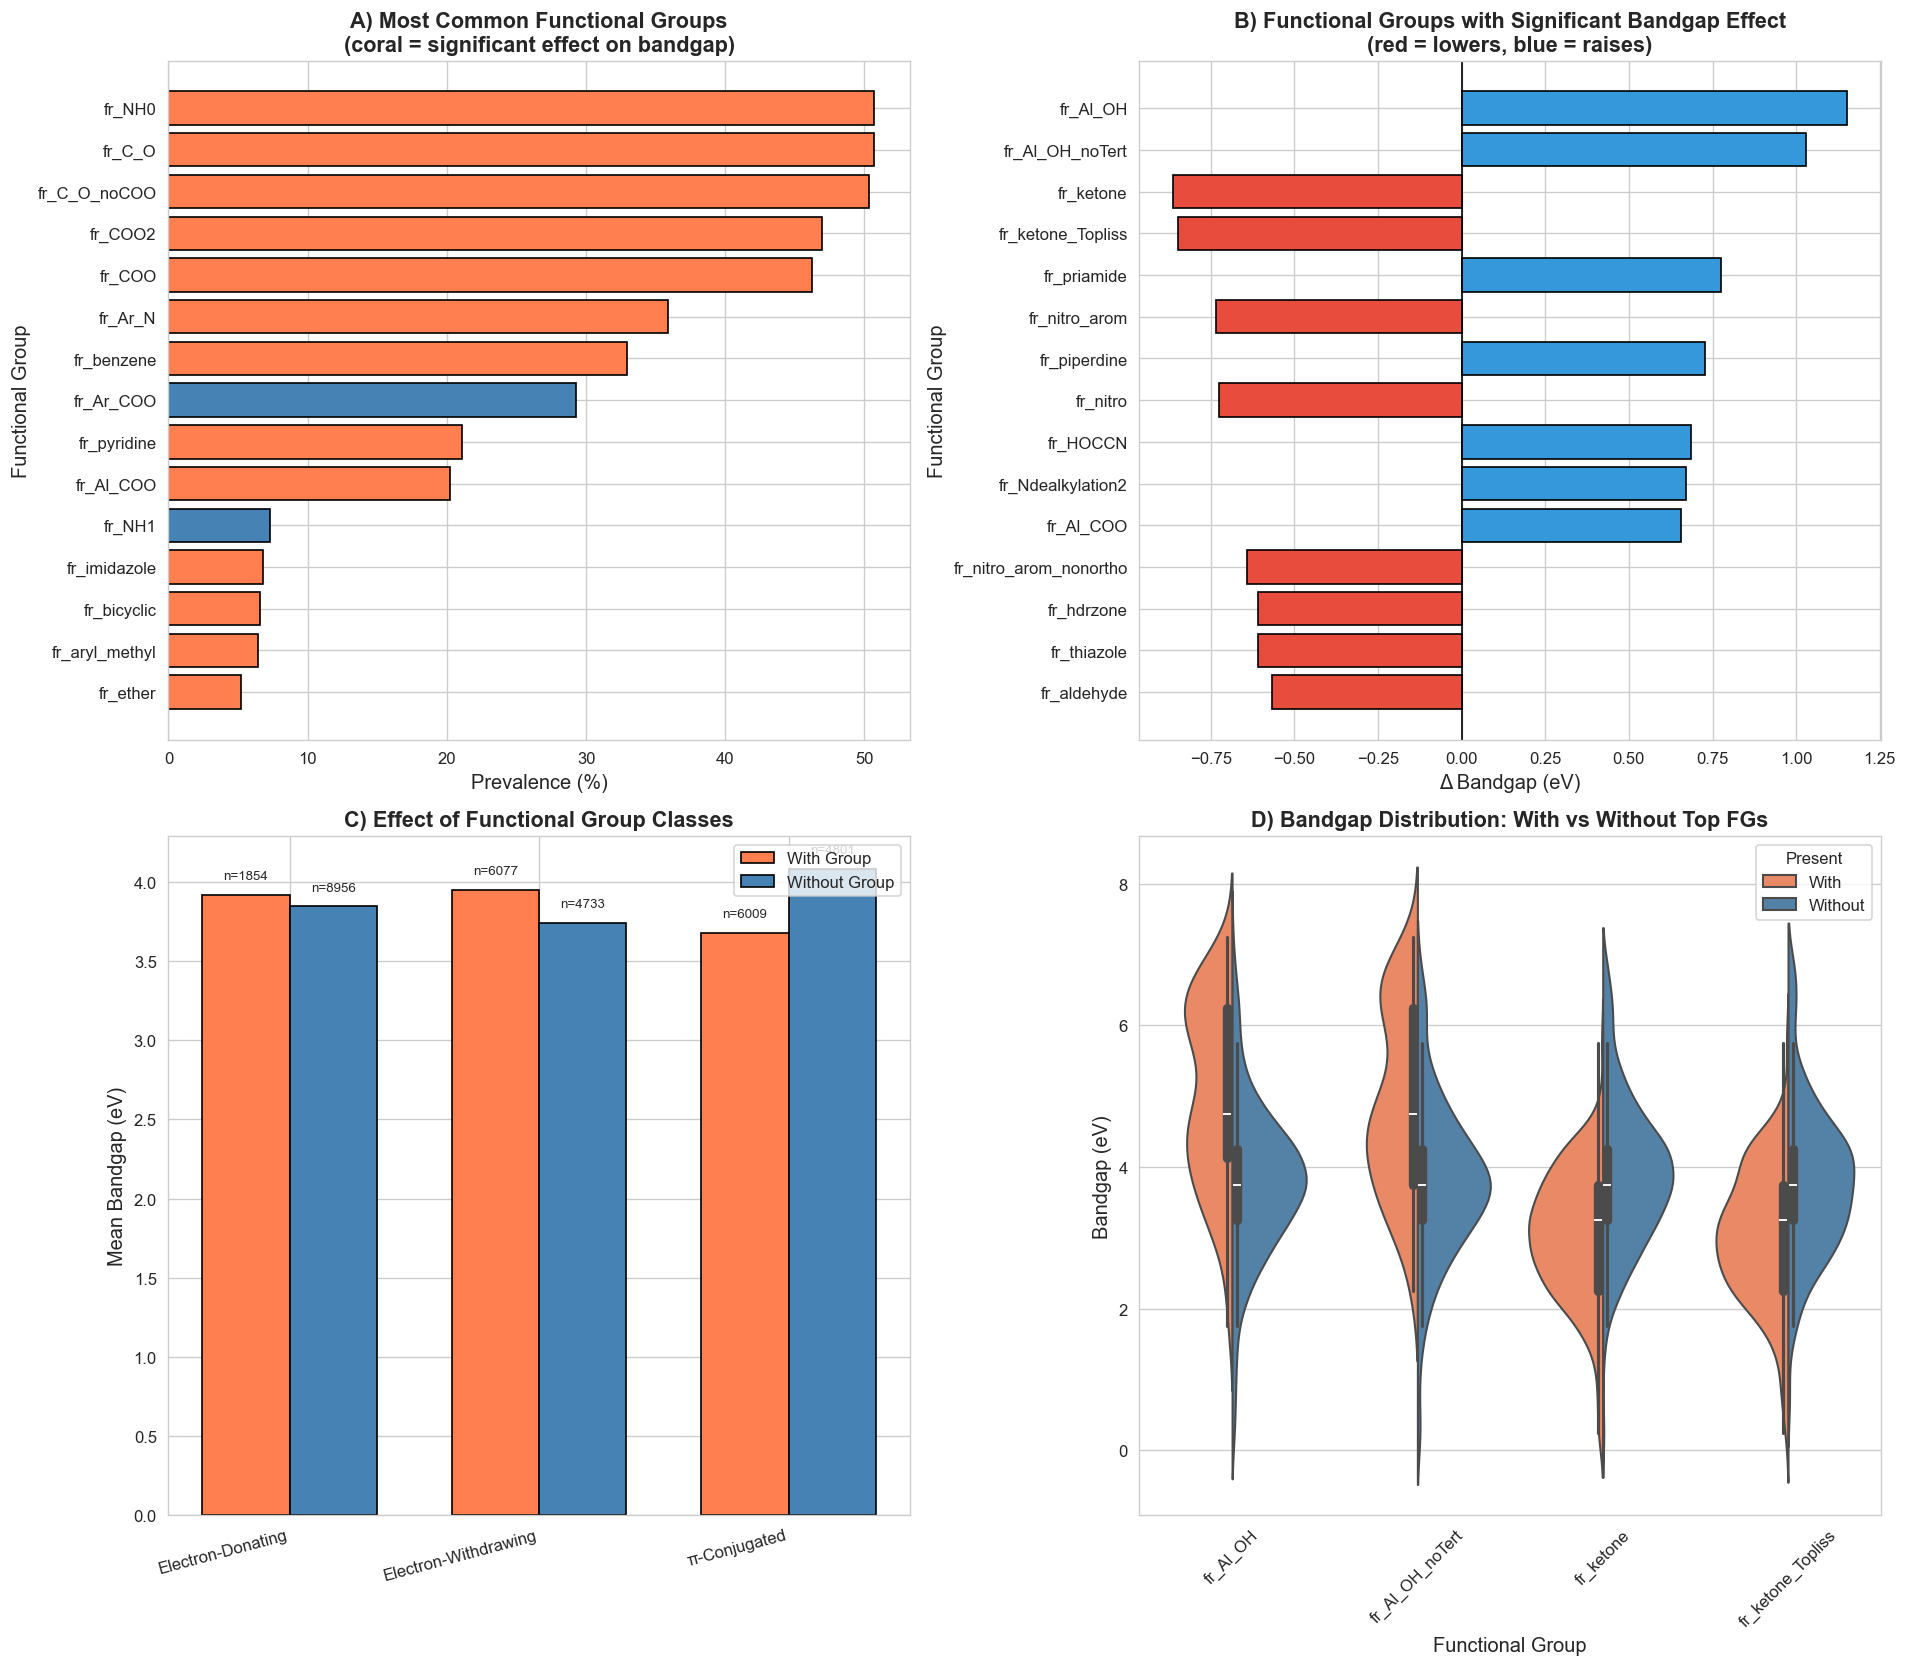


FUNCTIONAL GROUP STATISTICS (sorted by bandgap effect)

📉 FUNCTIONAL GROUPS THAT LOWER BANDGAP (potential for visible-light activity):
--------------------------------------------------------------------------------
Functional Group          Prevalence      With FG      Without        ΔEg      p-value
--------------------------------------------------------------------------------
fr_ketone                       1.9%       3.01eV       3.87eV   -0.862eV   1.32e-30***
fr_ketone_Topliss               1.3%       3.02eV       3.87eV   -0.849eV   3.06e-20***
fr_nitro_arom                   1.7%       3.14eV       3.87eV   -0.733eV   2.28e-26***
fr_nitro                        2.4%       3.15eV       3.88eV   -0.725eV   3.77e-35***
fr_nitro_arom_nonortho          1.3%       3.22eV       3.87eV   -0.641eV   1.94e-16***
fr_hdrzone                      0.2%       3.25eV       3.86eV   -0.609eV   6.34e-04***
fr_thiazole                     0.2%       3.25eV       3.86eV   -0.609eV   1.54e-02*
f

In [69]:
# ==========================================
# 8. RDKIT FUNCTIONAL GROUP IMPACT ON BANDGAPS
# ==========================================
"""
Analyze how specific functional groups in linkers affect bandgaps.
Uses RDKit fragment detection functions (fr_* series).

FUNCTIONAL GROUP HYPOTHESES:
- Electron-donating groups (NH2, OH) → lower HOMO-LUMO gap
- Electron-withdrawing groups (NO2, F) → may increase gap
- Extended conjugation (benzene, naphthalene) → lower gap
- Heteroatoms (N, S, O in rings) → affect electronic structure
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, ttest_ind
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("RDKIT FUNCTIONAL GROUP ANALYSIS: IMPACT ON BANDGAPS")
print("="*80)

# Get fragment columns
frag_cols = [c for c in df_stratified.columns if c.startswith('linker_frag_fr_')]
print(f"Found {len(frag_cols)} RDKit fragment features")

if len(frag_cols) == 0:
    print("\n⚠️ No fragment columns found. Run Cell 8 (feature extraction) first.")
else:
    df_fg = df_stratified.copy()
    
    # Create bandgap midpoint if not exists
    if 'bandgap_mid' not in df_fg.columns:
        import re
        def get_bg_mid(x):
            m = re.search(r'bandgap_([0-9.]+)_to_([0-9.]+)eV', str(x))
            return (float(m.group(1)) + float(m.group(2))) / 2 if m else np.nan
        df_fg['bandgap_mid'] = df_fg['analysis_bin'].apply(get_bg_mid)
    
    # ==========================================
    # FIGURE 1: TOP FUNCTIONAL GROUPS BY PREVALENCE
    # ==========================================
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    
    # Calculate prevalence and bandgap effect for each functional group
    fg_analysis = []
    for col in frag_cols:
        fg_name = col.replace('linker_frag_', '')
        present = df_fg[df_fg[col] > 0]
        absent = df_fg[df_fg[col] == 0]
        
        if len(present) >= 10 and len(absent) >= 10:
            mean_with = present['bandgap_mid'].mean()
            mean_without = absent['bandgap_mid'].mean()
            delta_bg = mean_with - mean_without
            
            # Statistical test
            try:
                stat, pval = mannwhitneyu(present['bandgap_mid'].dropna(), 
                                         absent['bandgap_mid'].dropna())
            except:
                pval = 1.0
            
            fg_analysis.append({
                'functional_group': fg_name,
                'n_with': len(present),
                'n_without': len(absent),
                'prevalence': 100 * len(present) / len(df_fg),
                'mean_bg_with': mean_with,
                'mean_bg_without': mean_without,
                'delta_bandgap': delta_bg,
                'p_value': pval,
                'significant': pval < 0.05
            })
    
    df_fga = pd.DataFrame(fg_analysis)
    print(f"\nAnalyzed {len(df_fga)} functional groups with sufficient data")
    
    # 1A: Most prevalent functional groups
    ax = axes[0, 0]
    top_prev = df_fga.nlargest(15, 'prevalence')
    colors = ['coral' if s else 'steelblue' for s in top_prev['significant']]
    bars = ax.barh(top_prev['functional_group'], top_prev['prevalence'], color=colors, edgecolor='black')
    ax.set_xlabel('Prevalence (%)', fontsize=12)
    ax.set_ylabel('Functional Group', fontsize=12)
    ax.set_title('A) Most Common Functional Groups\n(coral = significant effect on bandgap)', fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    
    # 1B: Functional groups with largest bandgap effect
    ax = axes[0, 1]
    df_fga_sig = df_fga[df_fga['significant']].copy()
    if len(df_fga_sig) > 0:
        # Sort by absolute effect
        df_fga_sig['abs_delta'] = df_fga_sig['delta_bandgap'].abs()
        top_effect = df_fga_sig.nlargest(15, 'abs_delta')
        
        colors = ['#e74c3c' if d < 0 else '#3498db' for d in top_effect['delta_bandgap']]
        ax.barh(top_effect['functional_group'], top_effect['delta_bandgap'], 
               color=colors, edgecolor='black')
        ax.axvline(x=0, color='black', linewidth=1)
        ax.set_xlabel('Δ Bandgap (eV)', fontsize=12)
        ax.set_ylabel('Functional Group', fontsize=12)
        ax.set_title('B) Functional Groups with Significant Bandgap Effect\n(red = lowers, blue = raises)', 
                    fontsize=13, fontweight='bold')
        ax.invert_yaxis()
    else:
        ax.text(0.5, 0.5, 'No statistically significant\nfunctional group effects', 
               ha='center', va='center', fontsize=12)
    
    # 1C: Electron-donating vs Electron-withdrawing groups
    ax = axes[1, 0]
    
    # Classify functional groups
    electron_donating = ['fr_NH2', 'fr_NH1', 'fr_ether', 'fr_methoxy', 'fr_phenol', 'fr_Ar_OH']
    electron_withdrawing = ['fr_nitro', 'fr_halogen', 'fr_C_O', 'fr_Al_COO', 'fr_Ar_COO', 'fr_nitrile']
    pi_conjugated = ['fr_benzene', 'fr_Ar_N', 'fr_thiophene', 'fr_furan', 'fr_pyridine', 'fr_imidazole']
    
    group_effects = []
    for group_name, group_list in [('Electron-Donating', electron_donating),
                                    ('Electron-Withdrawing', electron_withdrawing),
                                    ('π-Conjugated', pi_conjugated)]:
        cols = ['linker_frag_' + fg for fg in group_list if 'linker_frag_' + fg in df_fg.columns]
        if cols:
            df_fg['has_' + group_name] = (df_fg[cols].sum(axis=1) > 0)
            with_group = df_fg[df_fg['has_' + group_name]]['bandgap_mid'].dropna()
            without_group = df_fg[~df_fg['has_' + group_name]]['bandgap_mid'].dropna()
            
            if len(with_group) > 10 and len(without_group) > 10:
                group_effects.append({
                    'Group Type': group_name,
                    'With': with_group.mean(),
                    'Without': without_group.mean(),
                    'n_with': len(with_group),
                    'n_without': len(without_group)
                })
    
    if group_effects:
        df_ge = pd.DataFrame(group_effects)
        x = np.arange(len(df_ge))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, df_ge['With'], width, label='With Group', 
                      color='coral', edgecolor='black')
        bars2 = ax.bar(x + width/2, df_ge['Without'], width, label='Without Group',
                      color='steelblue', edgecolor='black')
        
        ax.set_xticks(x)
        ax.set_xticklabels(df_ge['Group Type'], rotation=15, ha='right')
        ax.set_ylabel('Mean Bandgap (eV)', fontsize=12)
        ax.set_title('C) Effect of Functional Group Classes', fontsize=13, fontweight='bold')
        ax.legend()
        
        # Add n labels
        for i, row in df_ge.iterrows():
            ax.text(i - width/2, row['With'] + 0.1, f'n={row["n_with"]}', ha='center', fontsize=8)
            ax.text(i + width/2, row['Without'] + 0.1, f'n={row["n_without"]}', ha='center', fontsize=8)
    
    # 1D: Detailed violin plots for top functional groups
    ax = axes[1, 1]
    if len(df_fga_sig) >= 3:
        top3_fg = df_fga_sig.nlargest(4, 'abs_delta')['functional_group'].tolist()
        
        plot_data = []
        for fg in top3_fg:
            col = 'linker_frag_' + fg
            if col in df_fg.columns:
                with_fg = df_fg[df_fg[col] > 0]['bandgap_mid'].dropna()
                without_fg = df_fg[df_fg[col] == 0]['bandgap_mid'].dropna()
                
                for v in with_fg:
                    plot_data.append({'FG': fg, 'Present': 'With', 'Bandgap': v})
                for v in without_fg.sample(min(len(without_fg), len(with_fg)*2)):
                    plot_data.append({'FG': fg, 'Present': 'Without', 'Bandgap': v})
        
        if plot_data:
            df_plot = pd.DataFrame(plot_data)
            sns.violinplot(data=df_plot, x='FG', y='Bandgap', hue='Present',
                          split=True, palette={'With': 'coral', 'Without': 'steelblue'}, ax=ax)
            ax.set_xlabel('Functional Group', fontsize=12)
            ax.set_ylabel('Bandgap (eV)', fontsize=12)
            ax.set_title('D) Bandgap Distribution: With vs Without Top FGs', fontsize=13, fontweight='bold')
            ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # ==========================================
    # PRINT DETAILED STATISTICS
    # ==========================================
    print("\n" + "="*80)
    print("FUNCTIONAL GROUP STATISTICS (sorted by bandgap effect)")
    print("="*80)
    
    if len(df_fga) > 0:
        df_fga_sorted = df_fga.sort_values('delta_bandgap')
        
        print("\n📉 FUNCTIONAL GROUPS THAT LOWER BANDGAP (potential for visible-light activity):")
        print("-"*80)
        print(f"{'Functional Group':<25} {'Prevalence':>10} {'With FG':>12} {'Without':>12} {'ΔEg':>10} {'p-value':>12}")
        print("-"*80)
        
        for _, row in df_fga_sorted[df_fga_sorted['delta_bandgap'] < 0].head(10).iterrows():
            sig_marker = '***' if row['p_value'] < 0.001 else ('**' if row['p_value'] < 0.01 else ('*' if row['p_value'] < 0.05 else ''))
            print(f"{row['functional_group']:<25} {row['prevalence']:>9.1f}% {row['mean_bg_with']:>10.2f}eV {row['mean_bg_without']:>10.2f}eV {row['delta_bandgap']:>+8.3f}eV {row['p_value']:>10.2e}{sig_marker}")
        
        print("\n📈 FUNCTIONAL GROUPS THAT RAISE BANDGAP:")
        print("-"*80)
        for _, row in df_fga_sorted[df_fga_sorted['delta_bandgap'] > 0].tail(10).iloc[::-1].iterrows():
            sig_marker = '***' if row['p_value'] < 0.001 else ('**' if row['p_value'] < 0.01 else ('*' if row['p_value'] < 0.05 else ''))
            print(f"{row['functional_group']:<25} {row['prevalence']:>9.1f}% {row['mean_bg_with']:>10.2f}eV {row['mean_bg_without']:>10.2f}eV {row['delta_bandgap']:>+8.3f}eV {row['p_value']:>10.2e}{sig_marker}")
        
        print("\n* p<0.05, ** p<0.01, *** p<0.001 (Mann-Whitney U test)")

print("\n" + "="*80)
print("RDKIT FUNCTIONAL GROUP ANALYSIS COMPLETE")
print("="*80)

In [70]:
# ==========================================
# DEBUG CELL: Test CIF/Structure Analysis Functions
# ==========================================
# Run this cell with 1-2 CIF files to verify pymatgen structure loading works

import os
import glob

print("="*70)
print("DEBUGGING: Testing CIF structure analysis on sample files")
print("="*70)

CIF_DIR = '../relaxed_structures'  # Adjust if your CIF directory is different

# Check if CIF directory exists
if not os.path.exists(CIF_DIR):
    print(f"  ⚠ CIF directory '{CIF_DIR}' not found. Skipping CIF tests.")
    print(f"    Create the directory or update CIF_DIR path.")
else:
    # Find 2 sample CIF files
    cif_files = glob.glob(os.path.join(CIF_DIR, '*.cif'))[:2]
    
    if not cif_files:
        print(f"  ⚠ No CIF files found in '{CIF_DIR}'. Skipping CIF tests.")
    else:
        print(f"\n[1/2] Testing pymatgen Structure loading...")
        
        try:
            from pymatgen.core import Structure
            from pymatgen.core.periodic_table import Element as PMGElement
            
            for cif_path in cif_files:
                try:
                    struct = Structure.from_file(cif_path)
                    n_atoms = len(struct)
                    volume = struct.volume
                    formula = struct.composition.reduced_formula
                    
                    # Find metals
                    metals = set()
                    for site in struct:
                        el = PMGElement(str(site.specie))
                        if el.is_transition_metal or el.is_lanthanoid:
                            metals.add(str(site.specie))
                    
                    print(f"  ✓ {os.path.basename(cif_path)}: {formula}, {n_atoms} atoms, V={volume:.1f} Å³, metals={metals}")
                except Exception as e:
                    print(f"  ✗ {os.path.basename(cif_path)}: ERROR - {str(e)[:50]}")
                    
        except ImportError:
            print("  ✗ pymatgen not installed. CIF analysis will not be available.")
        
        print(f"\n[2/2] Testing coordination analysis (CrystalNN)...")
        
        try:
            from pymatgen.analysis.local_env import CrystalNN
            
            cnn = CrystalNN()
            cif_path = cif_files[0]  # Use first file only
            
            try:
                struct = Structure.from_file(cif_path)
                
                # Find a metal site to analyze
                metal_idx = None
                for i, site in enumerate(struct):
                    el = PMGElement(str(site.specie))
                    if el.is_transition_metal:
                        metal_idx = i
                        break
                
                if metal_idx is not None:
                    nn_info = cnn.get_nn_info(struct, metal_idx)
                    coord_num = len(nn_info)
                    neighbors = [info['site'].specie.symbol for info in nn_info]
                    print(f"  ✓ Metal site {metal_idx} ({struct[metal_idx].specie}): CN={coord_num}, neighbors={neighbors[:5]}...")
                else:
                    print(f"  ⚠ No transition metal found in {os.path.basename(cif_path)}")
                    
            except Exception as e:
                print(f"  ✗ CrystalNN analysis failed: {str(e)[:50]}")
                
        except ImportError:
            print("  ✗ pymatgen.analysis.local_env not available")

print("\n" + "="*70)
print("CIF DEBUG TESTS COMPLETE - If tests pass (✓), proceed with full CIF analysis")
print("="*70)

DEBUGGING: Testing CIF structure analysis on sample files

[1/2] Testing pymatgen Structure loading...
  ✓ ABACUF01_FSR.cif: Ba2CuH14(C3O8)2, 39 atoms, V=408.9 Å³, metals={'Cu'}
  ✓ ABALOF_FSR.cif: Cu3H14C9SI4N, 128 atoms, V=1782.0 Å³, metals={'Cu'}

[2/2] Testing coordination analysis (CrystalNN)...
  ✓ Metal site 2 (Cu): CN=6, neighbors=['O', 'O', 'O', 'O', 'O']...

CIF DEBUG TESTS COMPLETE - If tests pass (✓), proceed with full CIF analysis


In [71]:
# ==========================================
# 7. CIF-BASED ANALYSIS: SETUP & CONFIGURATION
# ==========================================
"""
CIF-Based MOF Analysis: From Structures to Descriptors

This section implements structure-aware descriptors from CIF files, which capture:
- Coordination environment (metal geometry, coordination number)
- Metal-ligand distances
- Framework geometry

Required packages:
- pymatgen: Structure loading and ChemEnv coordination analysis
- mofdscribe (optional): MOF-specific featurizers
- ase (optional): Alternative structure handling
"""

import os
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("CIF-BASED STRUCTURAL ANALYSIS")
print("="*80)

# Configuration
CIF_DIR = '../relaxed_structures'  # Directory containing CIF files
SAMPLE_SIZE = None  # Set to integer for testing (e.g., 100), None for all

# Check for required packages
packages_status = {}

try:
    from pymatgen.core import Structure
    from pymatgen.core.periodic_table import Element
    packages_status['pymatgen'] = True
    print("✓ pymatgen available")
except ImportError:
    packages_status['pymatgen'] = False
    print("✗ pymatgen not installed (required for CIF analysis)")
    print("  Install with: pip install pymatgen")

try:
    from pymatgen.analysis.chemenv.coordination_environments.coordination_geometry_finder import LocalGeometryFinder
    from pymatgen.analysis.chemenv.coordination_environments.chemenv_strategies import SimplestChemenvStrategy
    from pymatgen.analysis.chemenv.coordination_environments.structure_environments import LightStructureEnvironments
    packages_status['chemenv'] = True
    print("✓ ChemEnv available for coordination analysis")
except ImportError:
    packages_status['chemenv'] = False
    print("✗ ChemEnv import failed (may need specific pymatgen version)")

try:
    import mofdscribe
    packages_status['mofdscribe'] = True
    print("✓ mofdscribe available for MOF-specific descriptors")
except ImportError:
    packages_status['mofdscribe'] = False
    print("✗ mofdscribe not installed (optional but recommended)")
    print("  Install with: pip install mofdscribe")

# List available CIF files
cif_files = []
if os.path.exists(CIF_DIR):
    cif_files = [f for f in os.listdir(CIF_DIR) if f.endswith('.cif')]
    print(f"\n✓ Found {len(cif_files)} CIF files in '{CIF_DIR}/'")
else:
    print(f"\n✗ CIF directory '{CIF_DIR}' not found")
    print(f"  Current directory: {os.getcwd()}")

# Create mapping from CIF filename to qmof_id
def get_qmof_id_from_cif(cif_filename):
    """Extract identifier from CIF filename."""
    # Assumes format like "qmof-XXXXX.cif" or "REFCODE_FSR.cif"
    base = os.path.splitext(cif_filename)[0]
    return base

cif_to_qmof = {get_qmof_id_from_cif(f): f for f in cif_files}

# Match CIF files to our dataset
if 'name' in df_stratified.columns:
    matched_cifs = df_stratified.index.map(lambda x: x in cif_to_qmof or df_stratified.loc[x, 'name'] + '_FSR' in [os.path.splitext(f)[0] for f in cif_files] if 'name' in df_stratified.columns else False)
else:
    matched_cifs = df_stratified.index.map(lambda x: x in cif_to_qmof)

# Try matching by 'name' column
name_to_cif = {}
for idx in df_stratified.index:
    qmof_id = idx
    name = df_stratified.loc[idx, 'name'] if 'name' in df_stratified.columns else None
    
    # Try direct match
    if qmof_id in cif_to_qmof:
        name_to_cif[idx] = cif_to_qmof[qmof_id]
    # Try with name + _FSR suffix
    elif name and f"{name}.cif" in cif_files:
        name_to_cif[idx] = f"{name}.cif"
    elif name and f"{name}_FSR.cif" in cif_files:
        name_to_cif[idx] = f"{name}_FSR.cif"

print(f"  Matched to dataset: {len(name_to_cif)}/{len(df_stratified)} MOFs")

# Store the mapping
df_stratified['cif_file'] = df_stratified.index.map(name_to_cif)
df_stratified['has_cif'] = df_stratified['cif_file'].notna()

print(f"\n{'='*80}")
print(f"CIF SETUP COMPLETE")
print(f"{'='*80}")

CIF-BASED STRUCTURAL ANALYSIS
✓ pymatgen available
✓ ChemEnv available for coordination analysis
✓ mofdscribe available for MOF-specific descriptors

✓ Found 20372 CIF files in '../relaxed_structures/'
  Matched to dataset: 10810/10810 MOFs

CIF SETUP COMPLETE


In [72]:
# ==========================================
# 8. COMPREHENSIVE CIF ANALYSIS PIPELINE
# ==========================================
"""
Robust CIF-based structural analysis using ONLY established packages.
ALL features prefixed with 'cif_' at creation time for consistency.

This is DIFFERENT from the MOFID/RDKit analysis (Cell 8):
- Cell 8 (MOFID): Uses SMILES → linker chemistry features (MW, rings, fragments)
- Cell 15 (CIF): Uses CIF files → structural features (volume, CN, bond lengths)

Features extracted:
1. pymatgen base: volume, density, n_sites, formula
2. pymatgen local_env: CN stats from CrystalNN + VoronoiNN (2-algorithm robustness)
3. Bond-length distributions: metal-X stats for ALL neighbor elements
4. mofdscribe (if available): RACS, pore geometry, BUAnalyzer
5. matminer (if available): composition element-property stats
6. Graph features: StructureGraph network metrics
7. Quality flags: partial occupancy, close contacts, missing H

CACHING: Results are saved to disk and reloaded on subsequent runs!
"""

import os
import pickle
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed

warnings.filterwarnings('ignore')

# ==========================================
# CACHE CONFIGURATION
# ==========================================
CIF_CACHE_DIR = Path('cache')
CIF_CACHE_DIR.mkdir(exist_ok=True)
CIF_CACHE_FILE = CIF_CACHE_DIR / 'cif_features.pkl'
CIF_CACHE_VERSION = 2  # Increment when cache format changes

def load_cif_cache():
    """Load cached CIF results if they exist and match current dataset."""
    if not CIF_CACHE_FILE.exists():
        return None
    try:
        with open(CIF_CACHE_FILE, 'rb') as f:
            cache = pickle.load(f)
        # Validate cache version
        if cache.get('version', 1) != CIF_CACHE_VERSION:
            print(f"  CIF cache invalidated (version mismatch: v{cache.get('version', 1)} vs v{CIF_CACHE_VERSION})")
            return None
        # Validate sample count
        expected_cifs = df_stratified['has_cif'].sum() if 'has_cif' in df_stratified.columns else len(df_stratified)
        if abs(cache.get('n_samples', 0) - expected_cifs) > 100:  # Allow some tolerance
            print(f"  CIF cache invalidated (sample count mismatch: {cache.get('n_samples')} vs ~{expected_cifs})")
            return None
        print(f"✓ Loading cached CIF results from {CIF_CACHE_FILE}")
        print(f"  ({cache['n_samples']} samples, cached on {cache.get('timestamp', 'unknown')})")
        return cache
    except Exception as e:
        print(f"  CIF cache load failed: {e}")
    return None

def save_cif_cache(df_result):
    """Save CIF results to cache for faster future runs."""
    import datetime
    cache = {
        'version': CIF_CACHE_VERSION,
        'n_samples': len(df_result),
        'timestamp': datetime.datetime.now().isoformat(),
        'columns': list(df_result.columns),
        'data': df_result
    }
    try:
        with open(CIF_CACHE_FILE, 'wb') as f:
            pickle.dump(cache, f)
        print(f"✓ CIF results cached to {CIF_CACHE_FILE}")
    except Exception as e:
        print(f"  CIF cache save failed: {e}")

# Show data coverage indicator
show_data_coverage("CIF Analysis")

print("\n" + "="*80)
print("COMPREHENSIVE CIF STRUCTURAL ANALYSIS")
print("(CIF-based: geometry, coordination, graph features)")
print("="*80)

# ==========================================
# TRY TO LOAD FROM CACHE FIRST
# ==========================================
cif_cached = load_cif_cache()

if cif_cached is not None:
    # ========================================
    # CACHE HIT - Restore cached columns
    # ========================================
    df_cif_features = cif_cached['data']
    
    cif_feature_cols = [c for c in df_cif_features.columns if c.startswith('cif_')]
    for col in cif_feature_cols:
        if col not in df_stratified.columns:
            df_stratified[col] = df_cif_features[col]
    
    print("\n" + "="*80)
    print("USING CACHED CIF RESULTS - Skipping heavy extraction!")
    print("To force recomputation, delete cache/cif_features.pkl")
    print("="*80)
    
    # Print summary
    print(f"\nExtracted {len(cif_feature_cols)} cif_* features from cache")

else:
    # ========================================
    # CACHE MISS - Run full extraction
    # ========================================
    
    # ==========================================
    # PACKAGE AVAILABILITY CHECK
    # ==========================================
    cif_packages = {}
    
    # tqdm for progress
    try:
        from tqdm.auto import tqdm
        TQDM_AVAILABLE = True
        print("✓ tqdm: progress tracking")
    except ImportError:
        TQDM_AVAILABLE = False
        tqdm = None
        print("  (tqdm not installed - progress bars disabled)")
    
    try:
        from pymatgen.core import Structure
        from pymatgen.core.periodic_table import Element as PMGElement
        from pymatgen.core.composition import Composition
        cif_packages['pymatgen'] = True
        print("✓ pymatgen.core: Structure, Element, Composition")
    except ImportError:
        cif_packages['pymatgen'] = False
        print("✗ pymatgen not available (REQUIRED)")
    
    try:
        from pymatgen.analysis.local_env import CrystalNN, VoronoiNN, MinimumDistanceNN
        cif_packages['local_env'] = True
        print("✓ pymatgen.analysis.local_env: CrystalNN, VoronoiNN, MinimumDistanceNN")
    except ImportError:
        cif_packages['local_env'] = False
        print("  pymatgen.analysis.local_env not available")
    
    try:
        from pymatgen.analysis.graphs import StructureGraph
        import networkx as nx
        cif_packages['graphs'] = True
        print("✓ pymatgen.analysis.graphs + networkx: Structure graph analysis")
    except ImportError:
        cif_packages['graphs'] = False
        print("  Structure graph analysis not available")
    
    try:
        import mofdscribe
        cif_packages['mofdscribe'] = True
        print("✓ mofdscribe: MOF-specific featurizers")
        
        try:
            from mofdscribe.featurizers.chemistry import RACS
            cif_packages['mofdscribe_racs'] = True
            print("  ✓ RACS (Revised Autocorrelation)")
        except:
            cif_packages['mofdscribe_racs'] = False
        
        try:
            from mofdscribe.featurizers.pore import PoreDiameters
            cif_packages['mofdscribe_pore'] = True
            print("  ✓ PoreDiameters (LCD, PLD, etc.)")
        except:
            cif_packages['mofdscribe_pore'] = False
        
        try:
            from mofdscribe.featurizers.bu import BUAnalyzer
            cif_packages['mofdscribe_bu'] = True
            print("  ✓ BUAnalyzer (SBU decomposition)")
        except:
            cif_packages['mofdscribe_bu'] = False
            
    except ImportError:
        cif_packages['mofdscribe'] = False
        print("  mofdscribe not available (pip install mofdscribe)")
    
    try:
        from matminer.featurizers.composition import ElementProperty
        cif_packages['matminer'] = True
        print("✓ matminer: Composition featurizers")
    except ImportError:
        cif_packages['matminer'] = False
        print("  matminer not available")
    
    if not cif_packages.get('pymatgen', False):
        raise ImportError("pymatgen is required for CIF analysis. Install with: pip install pymatgen")
    
    # ==========================================
    # HELPER FUNCTIONS
    # ==========================================
    
    def get_metal_indices(structure):
        """Get indices of metal sites using pymatgen's Element.is_metal property."""
        idxs = []
        for i, site in enumerate(structure):
            try:
                specie = site.specie
                if hasattr(specie, 'element'):
                    el = specie.element
                elif hasattr(specie, 'symbol'):
                    el = specie
                else:
                    el = PMGElement(str(specie).split('+')[0].split('-')[0])
                if el.is_metal:
                    idxs.append(i)
            except:
                pass
        return idxs
    
    def cn_stats_from_nn(nn_algo, structure, metal_indices, max_sites=30):
        """Compute coordination number statistics using a NearestNeighbor algorithm."""
        cns = []
        for idx in metal_indices[:max_sites]:
            try:
                info = nn_algo.get_nn_info(structure, idx)
                cns.append(len(info))
            except:
                pass
        if not cns:
            return (np.nan, np.nan, np.nan, 0)
        return (float(np.mean(cns)), float(np.median(cns)), float(np.std(cns)), len(cns))
    
    def get_bond_length_stats(structure, nn_algo, metal_indices, max_sites=30):
        """Collect bond lengths grouped by neighbor element."""
        bond_lengths = {}
        for idx in metal_indices[:max_sites]:
            try:
                nn_info = nn_algo.get_nn_info(structure, idx)
                for nn in nn_info:
                    neighbor_el = str(nn['site'].specie.element)
                    dist = structure[idx].distance(nn['site'])
                    if neighbor_el not in bond_lengths:
                        bond_lengths[neighbor_el] = []
                    bond_lengths[neighbor_el].append(dist)
            except:
                pass
        
        stats = {}
        for el, dists in bond_lengths.items():
            if len(dists) >= 2:
                stats[el] = {
                    'mean': np.mean(dists), 'min': np.min(dists), 'max': np.max(dists),
                    'p10': np.percentile(dists, 10), 'p90': np.percentile(dists, 90), 'count': len(dists)
                }
            elif len(dists) == 1:
                stats[el] = {'mean': dists[0], 'min': dists[0], 'max': dists[0], 
                            'p10': dists[0], 'p90': dists[0], 'count': 1}
        return stats
    
    def check_structure_quality(structure):
        """Check for common CIF issues."""
        flags = {
            'cif_has_partial_occupancy': False, 'cif_has_disorder': False,
            'cif_has_close_contacts': False, 'cif_missing_hydrogen': False, 'cif_n_elements': 0,
        }
        
        for site in structure:
            if hasattr(site, 'species') and len(site.species) > 1:
                flags['cif_has_disorder'] = True
            try:
                for sp, occ in site.species.items():
                    if occ < 0.99:
                        flags['cif_has_partial_occupancy'] = True
                        break
            except:
                pass
        
        try:
            for i in range(min(len(structure), 50)):
                for j in range(i+1, min(len(structure), 50)):
                    d = structure.get_distance(i, j)
                    if d < 0.8:
                        flags['cif_has_close_contacts'] = True
                        break
                if flags['cif_has_close_contacts']:
                    break
        except:
            pass
        
        has_h = any(str(site.specie.element) == 'H' for site in structure)
        flags['cif_missing_hydrogen'] = not has_h
        flags['cif_n_elements'] = len(set(str(site.specie.element) for site in structure))
        
        return flags
    
    def featurize_cif(cif_path, compute_expensive=False):
        """Comprehensive CIF featurization using established packages."""
        results = {'cif_loaded': False, 'cif_error': None, 'cif_error_stage': None}
        
        # STAGE 1: Load structure
        try:
            structure = Structure.from_file(cif_path)
            results['cif_loaded'] = True
        except Exception as e:
            results['cif_error'] = str(e)[:100]
            results['cif_error_stage'] = 'load'
            return results
        
        # STAGE 2: Basic properties
        try:
            results['cif_volume'] = structure.volume
            results['cif_density'] = structure.density
            results['cif_n_sites'] = len(structure)
            results['cif_formula'] = structure.composition.reduced_formula
            results['cif_a'] = structure.lattice.a
            results['cif_b'] = structure.lattice.b
            results['cif_c'] = structure.lattice.c
            results['cif_alpha'] = structure.lattice.alpha
            results['cif_beta'] = structure.lattice.beta
            results['cif_gamma'] = structure.lattice.gamma
        except Exception as e:
            results['cif_error'] = str(e)[:100]
            results['cif_error_stage'] = 'basic_props'
        
        # STAGE 3: Quality flags
        try:
            quality_flags = check_structure_quality(structure)
            results.update(quality_flags)
        except:
            pass
        
        # STAGE 4: Metal identification
        metal_indices = get_metal_indices(structure)
        results['cif_n_metal_sites'] = len(metal_indices)
        metal_species = list(set(str(structure[i].specie) for i in metal_indices))
        results['cif_metal_species'] = ','.join(metal_species) if metal_species else None
        results['cif_n_unique_metals'] = len(metal_species)
        
        # STAGE 5: Coordination analysis
        if cif_packages.get('local_env', False) and metal_indices:
            try:
                cnn = CrystalNN()
                mean_cn, med_cn, std_cn, n_cn = cn_stats_from_nn(cnn, structure, metal_indices)
                results['cif_cn_crystalnn_mean'] = mean_cn
                results['cif_cn_crystalnn_median'] = med_cn
                results['cif_cn_crystalnn_std'] = std_cn
                results['cif_cn_crystalnn_count'] = n_cn
                
                vnn = VoronoiNN()
                mean_cn_v, med_cn_v, std_cn_v, n_cn_v = cn_stats_from_nn(vnn, structure, metal_indices)
                results['cif_cn_voronoi_mean'] = mean_cn_v
                results['cif_cn_voronoi_median'] = med_cn_v
                results['cif_cn_voronoi_std'] = std_cn_v
                
                if not np.isnan(mean_cn) and not np.isnan(mean_cn_v):
                    results['cif_cn_method_disagreement'] = abs(mean_cn - mean_cn_v)
                
                bond_stats = get_bond_length_stats(structure, cnn, metal_indices)
                for el in ['O', 'N', 'S', 'C', 'Cl', 'F', 'Br']:
                    if el in bond_stats:
                        for stat_name, stat_val in bond_stats[el].items():
                            results[f'cif_metal_{el}_dist_{stat_name}'] = stat_val
            except Exception as e:
                results['cif_error'] = str(e)[:100]
                results['cif_error_stage'] = 'coordination'
        
        # STAGE 6: Metal-metal distances
        if len(metal_indices) > 1:
            try:
                mm_dists = []
                for i, idx1 in enumerate(metal_indices[:30]):
                    for idx2 in metal_indices[i+1:30]:
                        mm_dists.append(structure.get_distance(idx1, idx2))
                if mm_dists:
                    results['cif_metal_metal_dist_min'] = np.min(mm_dists)
                    results['cif_metal_metal_dist_mean'] = np.mean(mm_dists)
                    results['cif_metal_metal_dist_p10'] = np.percentile(mm_dists, 10)
            except:
                pass
        
        # STAGE 7: Graph features
        if cif_packages.get('graphs', False) and cif_packages.get('local_env', False):
            try:
                sg = StructureGraph.with_local_env_strategy(structure, CrystalNN())
                G = sg.graph.to_undirected()
                degrees = [d for n, d in G.degree()]
                results['cif_graph_mean_degree'] = np.mean(degrees) if degrees else np.nan
                results['cif_graph_max_degree'] = np.max(degrees) if degrees else np.nan
                results['cif_graph_n_edges'] = G.number_of_edges()
                try:
                    results['cif_graph_clustering_coeff'] = nx.average_clustering(G)
                except:
                    pass
                results['cif_graph_n_components'] = nx.number_connected_components(G)
            except Exception as e:
                results['cif_graph_error'] = str(e)[:50]
        
        return results
    
    # ==========================================
    # PROCESS CIF FILES
    # ==========================================
    
    if 'has_cif' not in df_stratified.columns:
        raise KeyError("No CIF mapping available. Run the CIF Setup cell first.")
    
    df_with_cif = df_stratified[df_stratified['has_cif'] == True].copy()
    
    # Configuration
    CIF_SAMPLE_SIZE = CURRENT_CONFIG.get('cif_limit', None)
    COMPUTE_EXPENSIVE = CURRENT_CONFIG.get('compute_expensive', False)
    
    print(f"\n  CIF Config (from {SAMPLING_MODE} mode):")
    print(f"    Sample limit: {CIF_SAMPLE_SIZE if CIF_SAMPLE_SIZE else 'ALL'}")
    print(f"    Expensive features: {COMPUTE_EXPENSIVE}")
    
    if CIF_SAMPLE_SIZE:
        df_with_cif = df_with_cif.head(CIF_SAMPLE_SIZE)
    
    print(f"\nProcessing {len(df_with_cif)} CIF files...")
    print(f"  Using: pymatgen.Structure, CrystalNN, VoronoiNN")
    if cif_packages.get('graphs', False):
        print(f"  Using: StructureGraph + networkx")
    
    # ==========================================
    # SEQUENTIAL PROCESSING WITH TQDM (more reliable than parallel on Windows)
    # ==========================================
    
    cif_results = []
    error_log = []
    processed = 0
    errors = 0
    
    # Build task list
    tasks = []
    for idx in df_with_cif.index:
        cif_file = df_with_cif.loc[idx, 'cif_file']
        if not isinstance(cif_file, str) or not cif_file:
            tasks.append((idx, None))
        else:
            cif_path = os.path.join(CIF_DIR, cif_file)
            tasks.append((idx, cif_path if os.path.exists(cif_path) else None))
    
    # Process with tqdm progress bar
    iterator = tqdm(tasks, desc="CIF extraction", unit="file") if TQDM_AVAILABLE else tasks
    
    for idx, cif_path in iterator:
        if cif_path is None:
            result = {
                'qmof_id': idx,
                'cif_loaded': False,
                'cif_error': 'missing_file',
                'cif_error_stage': 'path'
            }
        else:
            result = featurize_cif(cif_path, compute_expensive=COMPUTE_EXPENSIVE)
            result['qmof_id'] = idx
        
        if result.get('cif_error'):
            error_log.append({
                'qmof_id': idx,
                'error': result.get('cif_error'),
                'stage': result.get('cif_error_stage', 'unknown')
            })
            errors += 1
        else:
            processed += 1
        
        cif_results.append(result)
    
    print(f"\n✓ Completed: {processed} successful, {errors} errors")
    
    # Convert to DataFrame
    df_cif_features = pd.DataFrame(cif_results)
    if 'qmof_id' in df_cif_features.columns:
        df_cif_features.set_index('qmof_id', inplace=True)
    
    # ==========================================
    # SAVE TO CACHE
    # ==========================================
    save_cif_cache(df_cif_features)
    
    # Save error log if any
    if error_log:
        error_log_file = CIF_CACHE_DIR / 'cif_errors.csv'
        pd.DataFrame(error_log).to_csv(error_log_file, index=False)
        print(f"  Error log saved to {error_log_file}")
    
    # ==========================================
    # MERGE WITH MAIN DATAFRAME
    # ==========================================
    cif_feature_cols = [c for c in df_cif_features.columns if c.startswith('cif_')]
    print(f"\nExtracted {len(cif_feature_cols)} cif_* features")
    
    for col in cif_feature_cols:
        df_stratified[col] = df_cif_features[col]

# ==========================================
# SUMMARY STATISTICS (runs for both cached and fresh)
# ==========================================
print(f"\n{'='*80}")
print("CIF FEATURE SUMMARY")
print(f"{'='*80}")

key_features = [
    'cif_volume', 'cif_density', 'cif_n_sites', 'cif_n_metal_sites',
    'cif_cn_crystalnn_mean', 'cif_cn_voronoi_mean', 'cif_cn_method_disagreement',
    'cif_metal_O_dist_mean', 'cif_metal_N_dist_mean', 'cif_metal_metal_dist_min',
    'cif_graph_mean_degree', 'cif_graph_clustering_coeff'
]

print(f"\n{'Feature':<35} | {'Mean':>10} | {'Std':>10} | {'Count':>8}")
print("-" * 70)
for feat in key_features:
    if feat in df_stratified.columns:
        vals = df_stratified[feat].dropna()
        if len(vals) > 0:
            print(f"{feat:<35} | {vals.mean():>10.2f} | {vals.std():>10.2f} | {len(vals):>8}")

# Quality flags summary
print(f"\nQuality Flags:")
for flag in ['cif_has_partial_occupancy', 'cif_has_disorder', 'cif_has_close_contacts', 'cif_missing_hydrogen']:
    if flag in df_stratified.columns:
        count = df_stratified[flag].sum()
        total = len(df_stratified[flag].dropna())
        if total > 0:
            pct = 100 * count / total
            print(f"  {flag}: {count} ({pct:.1f}%)")

print(f"\n{'='*80}")
print("CIF ANALYSIS COMPLETE")
print(f"{'='*80}")

# ══════════════════════════════════════════════════════════════════════════════
# COMBINED FEATURE SUMMARY (MOFID + CIF)
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n\n{'═'*80}")
print("COMBINED ANALYSIS SUMMARY: MOFID + CIF FEATURES")
print(f"{'═'*80}")

print(f"\n📊 Data Coverage: {DATA_PERCENTAGE:.1f}% ({CURRENT_DATASET_SIZE:,} / {FULL_DATASET_SIZE:,} MOFs)")
print(f"   Mode: {SAMPLING_MODE} - {CURRENT_CONFIG['description']}")

# Count MOFID-derived features
mofid_features = [c for c in df_stratified.columns if c.startswith('linker_') or c.startswith('metal_') or c.startswith('has_') or c.startswith('n_') or c.startswith('is_')]
mofid_features = [c for c in mofid_features if not c.startswith('cif_')]

# Count CIF-derived features
cif_features = [c for c in df_stratified.columns if c.startswith('cif_')]

print(f"\n┌{'─'*76}┐")
print(f"│ {'FEATURE SOURCE':<25} │ {'COUNT':>10} │ {'EXAMPLE FEATURES':^35} │")
print(f"├{'─'*76}┤")
print(f"│ {'MOFID (SMILES-based)':<25} │ {len(mofid_features):>10} │ {'linker_*, metal_*, has_*':^35} │")
print(f"│ {'CIF (Structure-based)':<25} │ {len(cif_features):>10} │ {'cif_volume, cif_cn_*, cif_graph_*':^35} │")
print(f"├{'─'*76}┤")
print(f"│ {'TOTAL FEATURES':<25} │ {len(mofid_features) + len(cif_features):>10} │ {'':^35} │")
print(f"└{'─'*76}┘")

print(f"\nMOFID Features ({len(mofid_features)}):")
print(f"  • Linker descriptors: MW, rings, rotatable bonds, heteroatoms, TPSA...")
print(f"  • Functional groups: amine, nitro, cyano, hydroxyl, carboxylic acid...")
print(f"  • Metal categories: transition, lanthanide, mixed-metal flags")

print(f"\nCIF Features ({len(cif_features)}):")
print(f"  • Structure: volume, density, n_sites, lattice params")
print(f"  • Coordination: CrystalNN/VoronoiNN CN (mean, median, std)")
print(f"  • Bond lengths: metal-O/N/S/C distances (mean, min, p10, p90)")
print(f"  • Graph: degree, clustering coefficient, components")
print(f"  • Quality flags: partial occupancy, disorder, close contacts")

print(f"\n{'═'*80}")


┌──────────────────────────────────────────────────────────┐
│ 📊 MODE: FULL                                 CIF Analysis │
├──────────────────────────────────────────────────────────┤
│ Data: [████████████████████████████████████████] 100.0% │
│ Samples: 10,810 / 10,810                       │
└──────────────────────────────────────────────────────────┘

COMPREHENSIVE CIF STRUCTURAL ANALYSIS
(CIF-based: geometry, coordination, graph features)
✓ Loading cached CIF results from cache\cif_features.pkl
  (10810 samples, cached on 2026-02-01T02:38:29.456217)

USING CACHED CIF RESULTS - Skipping heavy extraction!
To force recomputation, delete cache/cif_features.pkl

Extracted 31 cif_* features from cache

CIF FEATURE SUMMARY

Feature                             |       Mean |        Std |    Count
----------------------------------------------------------------------
cif_volume                          |     946.38 |     352.44 |    10810
cif_density                         |       2.01 | 

In [73]:
# ══════════════════════════════════════════════════════════════════════════════
# VALIDATION: QMOF.CSV vs CIF-DERIVED FEATURES
# ══════════════════════════════════════════════════════════════════════════════
"""
This cell validates our analysis by comparing:
1. Metadata from qmof.csv (pre-computed by QMOF authors)
2. Features we derived from CIF files (using pymatgen)

If these match reasonably well, our CIF analysis pipeline is working correctly.
Discrepancies help identify potential issues.
"""

print("═" * 80)
print("VALIDATION: COMPARING QMOF.CSV METADATA vs CIF-DERIVED FEATURES")
print("═" * 80)

# Select samples that have both CIF-derived features AND qmof.csv metadata
validation_cols = {
    # qmof.csv column → our CIF-derived column
    'info.density': 'cif_density',
    # Can add more comparisons if columns exist
}

# Find samples with both sources
required_cols = ['has_cif', 'cif_loaded']
missing_cols = [c for c in required_cols if c not in df_stratified.columns]
if missing_cols:
    raise KeyError(
        f"Missing CIF columns {missing_cols}. Run the CIF analysis cell before validation."
    )

df_validation = df_stratified[
    (df_stratified['has_cif'] == True) &
    (df_stratified['cif_loaded'] == True)
].copy()

n_validation = min(200, len(df_validation))
if n_validation > 0:
    df_val_sample = df_validation.head(n_validation)
    
    print(f"\nValidating on {n_validation} MOFs with both qmof.csv and CIF data...")
    print("\n" + "─" * 60)
    print("DENSITY COMPARISON: info.density (qmof.csv) vs cif_density (pymatgen)")
    print("─" * 60)
    
    if 'info.density' in df_val_sample.columns and 'cif_density' in df_val_sample.columns:
        # Both columns exist - compare them
        df_compare = df_val_sample[['info.density', 'cif_density']].dropna()
        
        if len(df_compare) > 0:
            qmof_density = df_compare['info.density']
            cif_density = df_compare['cif_density']
            
            # Compute agreement metrics
            diff = (qmof_density - cif_density).abs()
            pct_diff = (100 * diff / qmof_density).abs()
            
            print(f"  Samples compared: {len(df_compare)}")
            print(f"  Mean qmof.csv density: {qmof_density.mean():.3f} g/cm³")
            print(f"  Mean CIF-derived density: {cif_density.mean():.3f} g/cm³")
            print(f"  Mean absolute difference: {diff.mean():.4f} g/cm³")
            print(f"  Mean % difference: {pct_diff.mean():.2f}%")
            
            # Correlation
            if len(df_compare) > 5:
                corr = qmof_density.corr(cif_density)
                print(f"  Pearson correlation: {corr:.4f}")
                
                if corr > 0.99:
                    print("  ✓ EXCELLENT agreement - CIF pipeline validated!")
                elif corr > 0.95:
                    print("  ✓ Good agreement - CIF pipeline working correctly")
                elif corr > 0.8:
                    print("  ⚠ Moderate agreement - some discrepancies")
                else:
                    print("  ✗ Poor agreement - check CIF loading")
            
            # Show a few examples
            print(f"\n  Sample comparisons (first 5):")
            print(f"  {'MOF ID':<20} | {'qmof.csv':>12} | {'CIF-derived':>12} | {'Diff %':>8}")
            print("  " + "-" * 60)
            for idx in df_compare.head(5).index:
                q = df_compare.loc[idx, 'info.density']
                c = df_compare.loc[idx, 'cif_density']
                pct = 100 * abs(q - c) / q if q > 0 else 0
                print(f"  {str(idx):<20} | {q:>12.3f} | {c:>12.3f} | {pct:>7.2f}%")
    else:
        print("  Cannot compare - missing one or both density columns")
    
    # METAL COMPARISON
    print("\n" + "─" * 60)
    print("METAL COUNT COMPARISON: Formula-derived vs CIF-derived")
    print("─" * 60)
    
    if 'metal_count' in df_val_sample.columns and 'cif_n_metal_sites' in df_val_sample.columns:
        df_metal = df_val_sample[['metal_count', 'cif_n_metal_sites', 'cif_n_unique_metals']].dropna()
        
        if len(df_metal) > 0:
            # Note: formula metal_count is # unique metals, cif_n_metal_sites is # metal atoms
            print(f"  Samples: {len(df_metal)}")
            print(f"  Mean unique metals (formula): {df_metal['metal_count'].mean():.2f}")
            print(f"  Mean unique metals (CIF): {df_metal['cif_n_unique_metals'].mean():.2f}")
            print(f"  Mean metal sites in CIF: {df_metal['cif_n_metal_sites'].mean():.1f}")
            
            # Check agreement on unique metal count
            agree = (df_metal['metal_count'] == df_metal['cif_n_unique_metals']).sum()
            print(f"  Agreement on unique metal count: {agree}/{len(df_metal)} ({100*agree/len(df_metal):.1f}%)")
    
    # FORMULA COMPARISON
    print("\n" + "─" * 60)
    print("FORMULA COMPARISON")
    print("─" * 60)
    
    if 'info.formula' in df_val_sample.columns and 'cif_formula' in df_val_sample.columns:
        df_form = df_val_sample[['info.formula', 'cif_formula']].dropna()
        
        if len(df_form) > 0:
            # Direct string comparison (may differ in ordering)
            exact_match = (df_form['info.formula'] == df_form['cif_formula']).sum()
            print(f"  Exact formula matches: {exact_match}/{len(df_form)}")
            print(f"  (Note: different element ordering doesn't mean error)")
            
            # Show examples of differences
            diff_idx = df_form[df_form['info.formula'] != df_form['cif_formula']].head(3).index
            if len(diff_idx) > 0:
                print(f"\n  Examples of formula differences:")
                for idx in diff_idx:
                    print(f"    {idx}: qmof='{df_form.loc[idx, 'info.formula']}' vs cif='{df_form.loc[idx, 'cif_formula']}'")

print(f"\n{'═'*80}")
print("VALIDATION COMPLETE")
print(f"{'═'*80}")

════════════════════════════════════════════════════════════════════════════════
VALIDATION: COMPARING QMOF.CSV METADATA vs CIF-DERIVED FEATURES
════════════════════════════════════════════════════════════════════════════════

Validating on 200 MOFs with both qmof.csv and CIF data...

────────────────────────────────────────────────────────────
DENSITY COMPARISON: info.density (qmof.csv) vs cif_density (pymatgen)
────────────────────────────────────────────────────────────
  Samples compared: 200
  Mean qmof.csv density: 2.047 g/cm³
  Mean CIF-derived density: 2.047 g/cm³
  Mean absolute difference: 0.0000 g/cm³
  Mean % difference: 0.00%
  Pearson correlation: 1.0000
  ✓ EXCELLENT agreement - CIF pipeline validated!

  Sample comparisons (first 5):
  MOF ID               |     qmof.csv |  CIF-derived |   Diff %
  ------------------------------------------------------------
  qmof-9b1be38         |        2.279 |        2.279 |    0.00%
  qmof-aca3388         |        1.088 |        1.

In [74]:
# ==========================================
# 9. CIF ANALYSIS: ChemEnv COORDINATION ENVIRONMENTS (OPTIONAL)
# ==========================================
"""
Advanced coordination environment analysis using pymatgen's ChemEnv module.

ChemEnv identifies the local geometry around each metal site:
- Octahedral, Tetrahedral, Square planar, etc.
- Uses continuous symmetry measures for robust assignment
- Handles distorted geometries

NOTE: This cell requires:
1. df_with_cif to be defined from CIF processing cells
2. pymatgen's ChemEnv to be available
3. CIF files to exist

This is computationally expensive - run on a subset first!
"""

print("="*80)
print("ChemEnv COORDINATION ENVIRONMENT ANALYSIS")
print("="*80)

# ==========================================
# CHECK ALL PREREQUISITES FIRST
# ==========================================
can_run_chemenv = True
skip_reason = None

# Check 1: packages_status
if 'packages_status' not in dir():
    can_run_chemenv = False
    skip_reason = "packages_status not defined"
elif not packages_status.get('chemenv', False):
    can_run_chemenv = False
    skip_reason = "ChemEnv not available (pymatgen>=2022.0.0 required)"

# Check 2: df_with_cif
if can_run_chemenv and 'df_with_cif' not in dir():
    can_run_chemenv = False
    skip_reason = "df_with_cif not defined (CIF processing cells not run)"

# Check 3: CIF_DIR
if can_run_chemenv and 'CIF_DIR' not in dir():
    can_run_chemenv = False
    skip_reason = "CIF_DIR not defined"

# ==========================================
# SKIP OR RUN
# ==========================================
if not can_run_chemenv:
    print(f"\n⚠ Skipping ChemEnv analysis: {skip_reason}")
    print("  This is normal if you don't have CIF files or haven't run CIF processing.")
    print("\n" + "="*80)
else:
    from pymatgen.analysis.chemenv.coordination_environments.coordination_geometry_finder import LocalGeometryFinder
    from pymatgen.analysis.chemenv.coordination_environments.chemenv_strategies import SimplestChemenvStrategy
    from pymatgen.analysis.chemenv.coordination_environments.structure_environments import LightStructureEnvironments
    from pymatgen.core import Structure, Element
    from collections import Counter
    import os
    
    # Common coordination environments in MOFs
    COORD_ENV_NAMES = {
        'O:6': 'Octahedral',
        'T:4': 'Tetrahedral', 
        'S:4': 'Square planar',
        'PP:5': 'Pentagonal planar',
        'TBP:5': 'Trigonal bipyramidal',
        'SPY:5': 'Square pyramidal',
        'PBP:7': 'Pentagonal bipyramidal',
        'CU:8': 'Cubic',
        'SA:8': 'Square antiprismatic',
        'L:2': 'Linear',
        'A:3': 'Angular/Bent',
        'T:3': 'Trigonal planar',
    }
    
    def get_chemenv_descriptors(cif_path, metal_indices=None):
        """Get ChemEnv coordination environment for metal sites."""
        try:
            structure = Structure.from_file(cif_path)
        except Exception as e:
            return {'error': str(e)}
        
        if metal_indices is None:
            metal_indices = []
            for i, site in enumerate(structure):
                try:
                    el = Element(str(site.specie.element))
                    if el.is_metal:
                        metal_indices.append(i)
                except:
                    pass
        
        if not metal_indices:
            return {'coord_envs': [], 'coord_env_counts': {}, 'dominant_env': None}
        
        try:
            lgf = LocalGeometryFinder()
            lgf.setup_structure(structure)
            
            se = lgf.compute_structure_environments(
                maximum_distance_factor=1.4,
                only_indices=metal_indices
            )
            
            strategy = SimplestChemenvStrategy()
            lse = LightStructureEnvironments.from_structure_environments(
                strategy=strategy, 
                structure_environments=se
            )
            
            coord_envs = []
            for idx in metal_indices:
                try:
                    env = lse.coordination_environments[idx]
                    if env:
                        best_env = env[0]['ce_symbol'] if env else 'Unknown'
                        coord_envs.append(best_env)
                    else:
                        coord_envs.append('Unknown')
                except:
                    coord_envs.append('Unknown')
            
            env_counts = Counter(coord_envs)
            dominant = env_counts.most_common(1)[0][0] if env_counts else None
            
            return {
                'coord_envs': coord_envs,
                'coord_env_counts': dict(env_counts),
                'dominant_env': dominant,
            }
            
        except Exception as e:
            return {'error': str(e), 'coord_envs': [], 'coord_env_counts': {}, 'dominant_env': None}
    
    # ==========================================
    # PROCESS SAMPLE OF CIF FILES
    # ==========================================
    CHEMENV_SAMPLE = min(200, len(df_with_cif))
    
    print(f"\nProcessing {CHEMENV_SAMPLE} CIF files for ChemEnv analysis...")
    print("(This may take several minutes...)")
    
    df_chemenv_sample = df_with_cif.head(CHEMENV_SAMPLE)
    
    chemenv_results = []
    processed = 0
    errors = 0
    
    for idx in df_chemenv_sample.index:
        cif_file = df_chemenv_sample.loc[idx, 'cif_file']
        cif_path = os.path.join(CIF_DIR, cif_file)
        
        if os.path.exists(cif_path):
            metal_indices = None
            if 'df_cif_features' in dir() and idx in df_cif_features.index:
                if 'metal_indices' in df_cif_features.columns:
                    metal_indices = df_cif_features.loc[idx, 'metal_indices']
                    if isinstance(metal_indices, float):
                        metal_indices = None
            
            result = get_chemenv_descriptors(cif_path, metal_indices)
            result['qmof_id'] = idx
            
            if 'error' in result:
                errors += 1
            else:
                processed += 1
            
            chemenv_results.append(result)
        
        if (processed + errors) % 50 == 0:
            print(f"  Processed {processed + errors}/{CHEMENV_SAMPLE}... ({errors} errors)")
    
    print(f"\nCompleted: {processed} successful, {errors} errors")
    
    df_chemenv = pd.DataFrame(chemenv_results)
    if 'qmof_id' in df_chemenv.columns:
        df_chemenv.set_index('qmof_id', inplace=True)
    
    if 'df_stratified' in dir() and 'dominant_env' in df_chemenv.columns:
        df_stratified['chemenv_dominant'] = df_chemenv['dominant_env']
    
    print("\n" + "="*80)
    print("COORDINATION ENVIRONMENT DISTRIBUTION")
    print("="*80)
    
    if 'dominant_env' in df_chemenv.columns:
        env_counts = df_chemenv['dominant_env'].value_counts()
        print("\nDominant Coordination Environments:")
        for env, count in env_counts.head(10).items():
            name = COORD_ENV_NAMES.get(env, env)
            print(f"  {env:<10} ({name:<25}): {count}")
        
        if len(env_counts) > 0:
            import matplotlib.pyplot as plt
            import numpy as np
            fig, ax = plt.subplots(figsize=(12, 6))
            top_envs = env_counts.head(8)
            colors = plt.cm.Set3(np.linspace(0, 1, len(top_envs)))
            bars = ax.bar(range(len(top_envs)), top_envs.values, color=colors, edgecolor='black')
            ax.set_xticks(range(len(top_envs)))
            ax.set_xticklabels([f"{e}\n({COORD_ENV_NAMES.get(e, 'Unknown')[:15]})" for e in top_envs.index], 
                              rotation=45, ha='right', fontsize=9)
            ax.set_ylabel('Count', fontsize=12)
            ax.set_title('Dominant Coordination Environment Distribution', fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
    
    print("\n" + "="*80)

ChemEnv COORDINATION ENVIRONMENT ANALYSIS

⚠ Skipping ChemEnv analysis: df_with_cif not defined (CIF processing cells not run)
  This is normal if you don't have CIF files or haven't run CIF processing.




STRUCTURAL FEATURES vs BANDGAP ANALYSIS (ROBUST)
Detected columns:
  CN: cif_cn_crystalnn_mean
  O : None
  N : None
  M-M: cif_metal_metal_dist_min
  density: cif_density
  nsites: cif_n_sites
  volume: cif_volume

MOFs with CIF structural data (after filter=cif_cn_crystalnn_mean): 10796


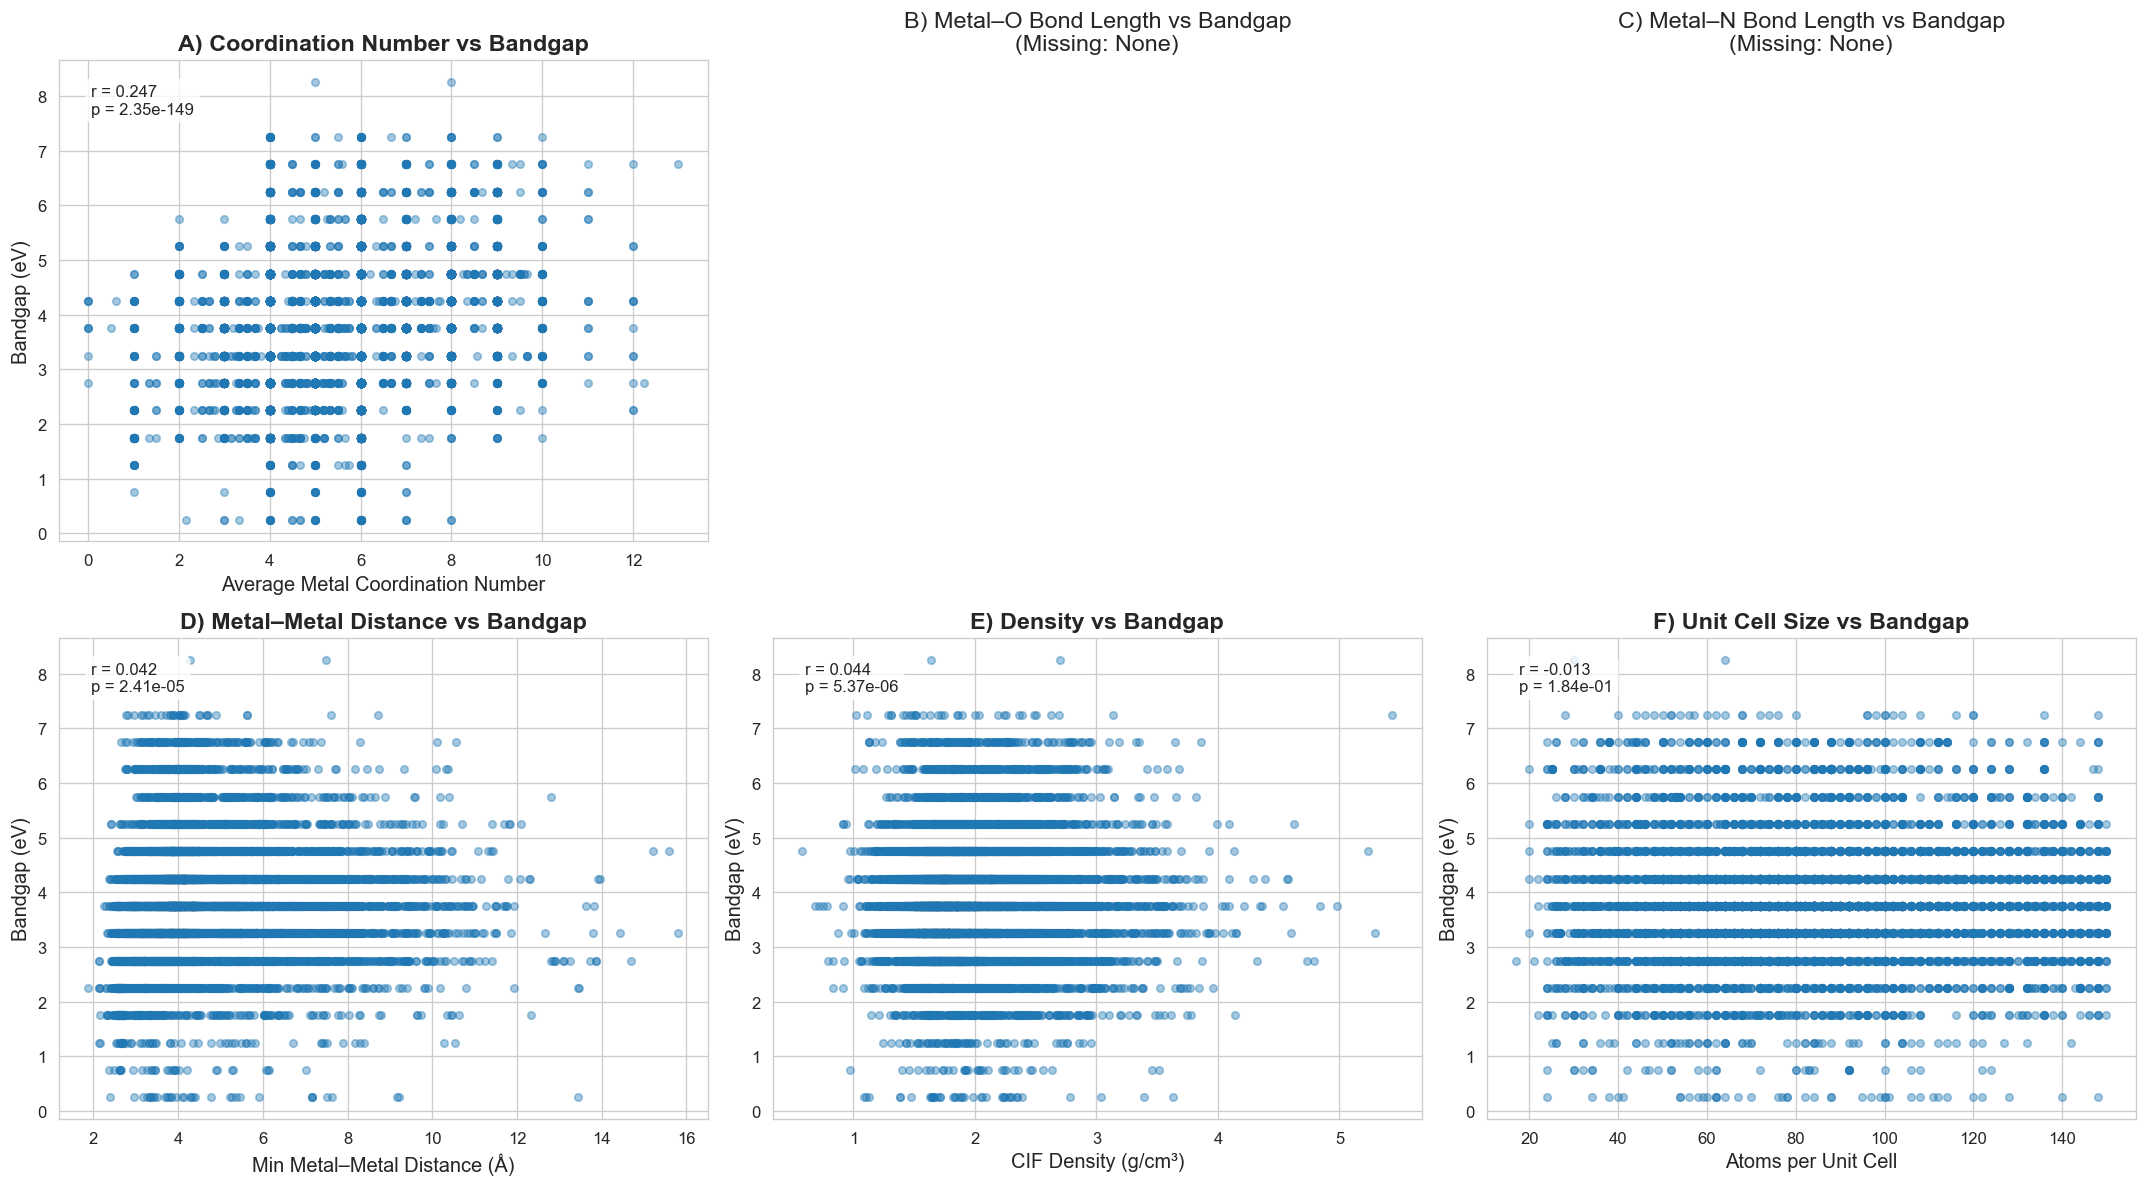


CIF STRUCTURAL FEATURE CORRELATIONS WITH BANDGAP
cif_cn_crystalnn_mean                r=+0.247***  p=2.35e-149  ↑ higher Eg
cif_metal_metal_dist_min             r=+0.042***  p=2.41e-05  ↑ higher Eg
cif_density                          r=+0.044***  p=5.37e-06  ↑ higher Eg
cif_n_sites                          r=-0.013  p=1.84e-01  ↓ lower Eg
cif_volume                           r=-0.073***  p=2.44e-14  ↓ lower Eg


In [75]:
# ==========================================
# 10. CIF ANALYSIS: STRUCTURAL FEATURE VISUALIZATION (ROBUST)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("\n" + "="*80)
print("STRUCTURAL FEATURES vs BANDGAP ANALYSIS (ROBUST)")
print("="*80)

def pick_col(df, candidates):
    """Return the first column that exists in df from candidates, else None."""
    for c in candidates:
        if c in df.columns:
            return c
    return None

# Build analysis frame
df_cif_analysis = df_stratified[df_stratified["has_cif"] == True].copy()
df_cif_analysis["bandgap_mid"] = df_cif_analysis["analysis_bin"].apply(get_bandgap_midpoint)

# Auto-detect columns (support multiple naming styles)
col_cn = pick_col(df_cif_analysis, [
    "cif_cn_crystalnn_mean",
    "cif_avg_coord_num_CrystalNN",
    "cif_avg_coord_num_CrystalNN".lower(),  # just in case you lowercased somewhere
])

col_O = pick_col(df_cif_analysis, [
    "cif_metal_O_dist_mean",
    "cif_avg_metal_O_dist",
    "cif_avg_metal_O_dist".lower(),
])

col_N = pick_col(df_cif_analysis, [
    "cif_metal_N_dist_mean",
    "cif_avg_metal_N_dist",
])

col_mm = pick_col(df_cif_analysis, [
    "cif_metal_metal_dist_min",
    "cif_min_metal_metal_dist",
])

col_density = pick_col(df_cif_analysis, [
    "cif_density",
    "cif_density".lower(),
])

col_nsites = pick_col(df_cif_analysis, [
    "cif_n_sites",
    "cif_n_atoms",   # if you used n_atoms as “sites”
])

col_vol = pick_col(df_cif_analysis, [
    "cif_volume",
    "cif_volume".lower(),
    "cif_volume".replace("cif_", "cif_"),  # no-op, keeps pattern consistent
])

print("Detected columns:")
print("  CN:", col_cn)
print("  O :", col_O)
print("  N :", col_N)
print("  M-M:", col_mm)
print("  density:", col_density)
print("  nsites:", col_nsites)
print("  volume:", col_vol)

# Choose a filtering column (prefer CN if available, else density, else nsites)
filter_col = col_cn or col_density or col_nsites
if filter_col is None:
    raise RuntimeError("No usable CIF columns found. Check your CIF merge step.")

df_cif_valid = df_cif_analysis.dropna(subset=[filter_col, "bandgap_mid"])
print(f"\nMOFs with CIF structural data (after filter={filter_col}): {len(df_cif_valid)}")

if len(df_cif_valid) <= 10:
    print("Not enough CIF data for visualization. Run CIF extraction/merge first.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    def scatter_with_corr(ax, xcol, ycol, xlabel, title):
        if xcol is None or xcol not in df_cif_valid.columns:
            ax.axis("off")
            ax.set_title(f"{title}\n(Missing: {xcol})")
            return
        d = df_cif_valid.dropna(subset=[xcol, ycol])
        if len(d) < 10:
            ax.axis("off")
            ax.set_title(f"{title}\n(Too few points)")
            return
        ax.scatter(d[xcol], d[ycol], alpha=0.4, s=20)
        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_ylabel("Bandgap (eV)", fontsize=12)
        ax.set_title(title, fontsize=14, fontweight="bold")

        r, p = stats.pearsonr(d[xcol], d[ycol])
        ax.text(
            0.05, 0.95, f"r = {r:.3f}\np = {p:.2e}",
            transform=ax.transAxes, fontsize=10, va="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
        )

    scatter_with_corr(axes[0,0], col_cn, "bandgap_mid", "Average Metal Coordination Number", "A) Coordination Number vs Bandgap")
    scatter_with_corr(axes[0,1], col_O,  "bandgap_mid", "Avg Metal–O Distance (Å)",          "B) Metal–O Bond Length vs Bandgap")
    scatter_with_corr(axes[0,2], col_N,  "bandgap_mid", "Avg Metal–N Distance (Å)",          "C) Metal–N Bond Length vs Bandgap")
    scatter_with_corr(axes[1,0], col_mm, "bandgap_mid", "Min Metal–Metal Distance (Å)",      "D) Metal–Metal Distance vs Bandgap")
    scatter_with_corr(axes[1,1], col_density, "bandgap_mid", "CIF Density (g/cm³)",          "E) Density vs Bandgap")
    scatter_with_corr(axes[1,2], col_nsites,  "bandgap_mid", "Atoms per Unit Cell",          "F) Unit Cell Size vs Bandgap")

    plt.tight_layout()
    plt.show()

    print("\n" + "="*80)
    print("CIF STRUCTURAL FEATURE CORRELATIONS WITH BANDGAP")
    print("="*80)

    for col in [col_cn, col_O, col_N, col_mm, col_density, col_nsites, col_vol]:
        if col is None or col not in df_cif_valid.columns:
            continue
        d = df_cif_valid.dropna(subset=[col, "bandgap_mid"])
        if len(d) < 10:
            continue
        r, p = stats.pearsonr(d[col], d["bandgap_mid"])
        sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
        direction = "↑ higher Eg" if r > 0 else "↓ lower Eg"
        print(f"{col:<35}  r={r:+.3f}{sig}  p={p:.2e}  {direction}")


DATASET DIVERSITY ANALYSIS
Using 17 features for diversity analysis:
  - linker_max_MolWt
  - linker_sum_MolWt
  - linker_max_NumHeavyAtoms
  - linker_max_NumAromaticRings
  - linker_sum_NumAromaticRings
  - linker_max_NumRings
  - linker_min_NumRotatableBonds
  - linker_min_FractionCSP3
  - linker_max_NumHeteroatoms
  - linker_max_TPSA
  - cif_cn_crystalnn_mean
  - cif_metal_metal_dist_min
  - cif_density
  - cif_n_sites
  - info.density
  - info.pld
  - info.lcd

MOFs with complete feature data: 10810/10810

PCA DIMENSIONALITY REDUCTION

Explained variance by component:
  PC1: 35.3% (cumulative: 35.3%)
  PC2: 15.4% (cumulative: 50.7%)
  PC3: 11.4% (cumulative: 62.1%)
  PC4: 7.9% (cumulative: 69.9%)
  PC5: 7.0% (cumulative: 76.9%)
  PC6: 5.3% (cumulative: 82.2%)
  PC7: 5.0% (cumulative: 87.2%)
  PC8: 4.4% (cumulative: 91.6%)
  PC9: 3.0% (cumulative: 94.6%)
  PC10: 1.6% (cumulative: 96.1%)


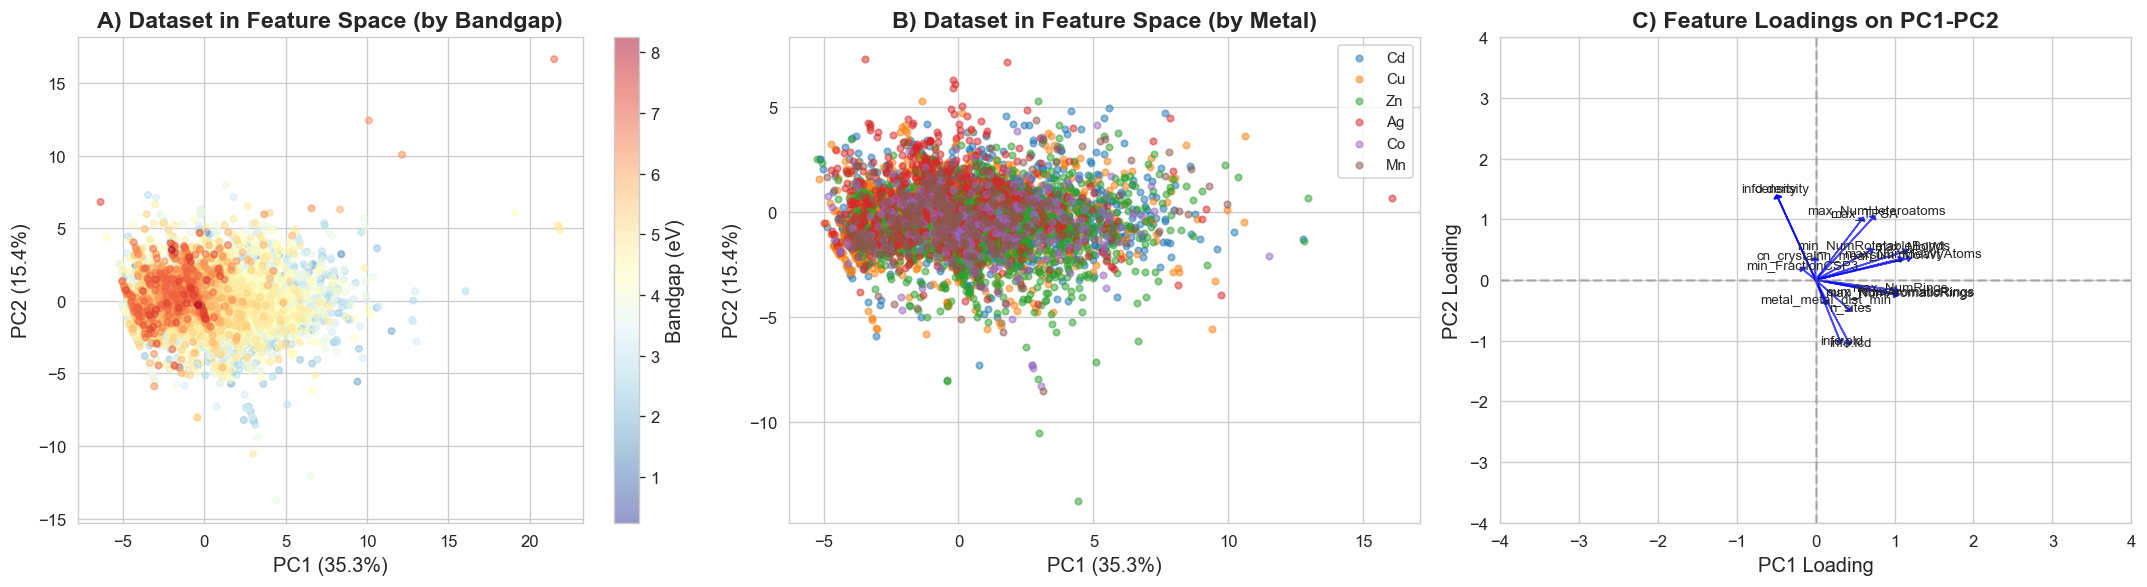


K-MEANS CLUSTERING

Cluster distribution (k=8):
  Cluster 0:   717 MOFs, avg bandgap = 3.52 eV
  Cluster 1:  1449 MOFs, avg bandgap = 3.92 eV
  Cluster 2:  3204 MOFs, avg bandgap = 3.92 eV
  Cluster 3:  1764 MOFs, avg bandgap = 3.57 eV
  Cluster 4:   850 MOFs, avg bandgap = 3.86 eV
  Cluster 5:   448 MOFs, avg bandgap = 3.67 eV
  Cluster 6:   794 MOFs, avg bandgap = 4.89 eV
  Cluster 7:  1584 MOFs, avg bandgap = 3.68 eV


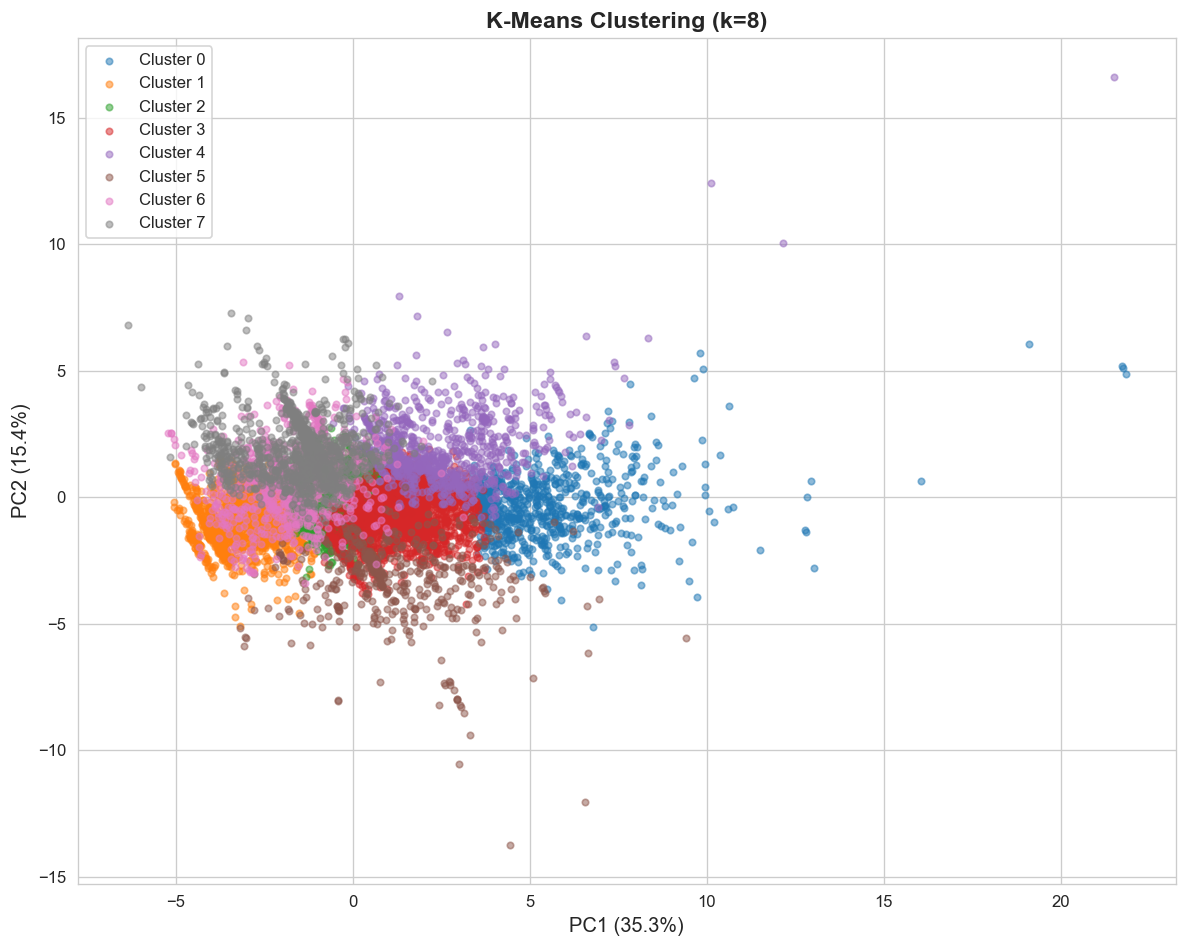


DIVERSE SUBSET SELECTION
Selected 500 maximally diverse MOFs

Diverse subset statistics:
  Bandgap range: 0.25 - 8.25 eV
  Unique metals: 41
  Clusters covered: 8/8

Bandgap distribution in diverse subset vs full dataset:
  <1.5 eV: Full=1.3%, Subset=2.0%
  1.5-3 eV: Full=17.7%, Subset=20.8%
  3-5 eV: Full=69.2%, Subset=64.2%
  >5 eV: Full=11.8%, Subset=13.0%

DIVERSITY ANALYSIS COMPLETE


In [76]:
# ==========================================
# 11. DATASET DIVERSITY ANALYSIS & SUBSET SELECTION
# ==========================================
"""
Assess dataset diversity and guide selection of varied training subsets.

Approaches:
1. PCA on descriptor space to visualize coverage
2. Clustering to identify groups
3. Maximin diversity selection for maximally spread subset
"""

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

print("="*80)
print("DATASET DIVERSITY ANALYSIS")
print("="*80)

# ==========================================
# PREPARE FEATURE MATRIX
# ==========================================

# Select numeric features for diversity analysis
feature_cols = []

# SMILES-based features
smiles_features = [
    'linker_max_MolWt', 'linker_sum_MolWt', 'linker_max_NumHeavyAtoms',
    'linker_max_NumAromaticRings', 'linker_sum_NumAromaticRings',
    'linker_max_NumRings', 'linker_min_NumRotatableBonds',
    'linker_min_FractionCSP3', 'linker_max_NumHeteroatoms', 'linker_max_TPSA',
]

# CIF-based features
cif_features = [
    'cif_cn_crystalnn_mean', 'cif_metal_O_dist_mean', 'cif_metal_N_dist_mean',
    'cif_metal_metal_dist_min', 'cif_density', 'cif_n_sites',
]

# Dataset features
dataset_features = ['info.density', 'info.pld', 'info.lcd']

# Combine available features
for feat in smiles_features + cif_features + dataset_features:
    if feat in df_stratified.columns:
        feature_cols.append(feat)

print(f"Using {len(feature_cols)} features for diversity analysis:")
for feat in feature_cols:
    print(f"  - {feat}")

# Prepare data
df_diversity = df_stratified.copy()
df_diversity['bandgap_mid'] = df_diversity['analysis_bin'].apply(get_bandgap_midpoint)

# Get feature matrix
X_raw = df_diversity[feature_cols].copy()

# Impute missing values
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_raw)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Track which rows have valid data
valid_mask = ~np.isnan(X_imputed).any(axis=1)
print(f"\nMOFs with complete feature data: {valid_mask.sum()}/{len(df_diversity)}")

# ==========================================
# PCA ANALYSIS
# ==========================================
print("\n" + "="*80)
print("PCA DIMENSIONALITY REDUCTION")
print("="*80)

pca = PCA(n_components=min(10, len(feature_cols)))
X_pca = pca.fit_transform(X_scaled)

# Explained variance
cumvar = np.cumsum(pca.explained_variance_ratio_)
print(f"\nExplained variance by component:")
for i, (var, cumv) in enumerate(zip(pca.explained_variance_ratio_, cumvar)):
    print(f"  PC{i+1}: {var*100:.1f}% (cumulative: {cumv*100:.1f}%)")

# Add PCA coordinates to dataframe
df_diversity['PC1'] = X_pca[:, 0]
df_diversity['PC2'] = X_pca[:, 1]
df_diversity['PC3'] = X_pca[:, 2] if X_pca.shape[1] > 2 else 0

# ==========================================
# VISUALIZATION
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1: PCA colored by bandgap
ax = axes[0]
sc = ax.scatter(df_diversity['PC1'], df_diversity['PC2'],
                c=df_diversity['bandgap_mid'], cmap='RdYlBu_r',
                alpha=0.5, s=15)
plt.colorbar(sc, ax=ax, label='Bandgap (eV)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('A) Dataset in Feature Space (by Bandgap)', fontsize=14, fontweight='bold')

# 2: PCA colored by metal
ax = axes[1]
metal_order = df_diversity['metal'].value_counts().head(6).index.tolist()
df_top_metal = df_diversity[df_diversity['metal'].isin(metal_order)]
for i, metal in enumerate(metal_order):
    df_m = df_top_metal[df_top_metal['metal'] == metal]
    ax.scatter(df_m['PC1'], df_m['PC2'], label=metal, alpha=0.5, s=15)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('B) Dataset in Feature Space (by Metal)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)

# 3: Loading plot
ax = axes[2]
loadings = pca.components_[:2].T  # First 2 PCs
for i, feat in enumerate(feature_cols):
    ax.arrow(0, 0, loadings[i, 0]*3, loadings[i, 1]*3, head_width=0.1, head_length=0.05, fc='blue', ec='blue', alpha=0.7)
    ax.text(loadings[i, 0]*3.2, loadings[i, 1]*3.2, feat.replace('linker_', '').replace('cif_', ''),
            fontsize=8, ha='center')
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('PC1 Loading', fontsize=12)
ax.set_ylabel('PC2 Loading', fontsize=12)
ax.set_title('C) Feature Loadings on PC1-PC2', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# CLUSTERING
# ==========================================
print("\n" + "="*80)
print("K-MEANS CLUSTERING")
print("="*80)

# Determine optimal k using elbow method
inertias = []
K_range = range(2, 15)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Use k=8 as reasonable default for MOF diversity
K_CLUSTERS = 8
kmeans = KMeans(n_clusters=K_CLUSTERS, random_state=42, n_init=10)
df_diversity['cluster'] = kmeans.fit_predict(X_scaled)

print(f"\nCluster distribution (k={K_CLUSTERS}):")
cluster_counts = df_diversity['cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    avg_bg = df_diversity[df_diversity['cluster'] == cluster]['bandgap_mid'].mean()
    print(f"  Cluster {cluster}: {count:>5} MOFs, avg bandgap = {avg_bg:.2f} eV")

# Plot clusters
fig, ax = plt.subplots(figsize=(10, 8))
for cluster in range(K_CLUSTERS):
    df_c = df_diversity[df_diversity['cluster'] == cluster]
    ax.scatter(df_c['PC1'], df_c['PC2'], label=f'Cluster {cluster}', alpha=0.5, s=15)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title(f'K-Means Clustering (k={K_CLUSTERS})', fontsize=14, fontweight='bold')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

# ==========================================
# DIVERSE SUBSET SELECTION (Maximin)
# ==========================================
print("\n" + "="*80)
print("DIVERSE SUBSET SELECTION")
print("="*80)

def maximin_selection(X, n_select, seed=42):
    """
    Select n_select points that maximize the minimum pairwise distance.
    Greedy farthest-point sampling.
    """
    np.random.seed(seed)
    n_total = len(X)

    if n_select >= n_total:
        return list(range(n_total))

    # Start with random point
    selected = [np.random.randint(n_total)]

    # Precompute distances to first point
    min_dists = np.linalg.norm(X - X[selected[0]], axis=1)

    for _ in range(n_select - 1):
        # Select point farthest from current selection
        next_idx = np.argmax(min_dists)
        selected.append(next_idx)

        # Update min distances
        new_dists = np.linalg.norm(X - X[next_idx], axis=1)
        min_dists = np.minimum(min_dists, new_dists)

        # Mask already selected
        min_dists[selected] = -np.inf

    return selected

# Select diverse subset
SUBSET_SIZE = 500
diverse_indices = maximin_selection(X_scaled, SUBSET_SIZE)

print(f"Selected {len(diverse_indices)} maximally diverse MOFs")

# Analyze the selected subset
df_diverse_subset = df_diversity.iloc[diverse_indices].copy()

print(f"\nDiverse subset statistics:")
print(f"  Bandgap range: {df_diverse_subset['bandgap_mid'].min():.2f} - {df_diverse_subset['bandgap_mid'].max():.2f} eV")
print(f"  Unique metals: {df_diverse_subset['metal'].nunique()}")
print(f"  Clusters covered: {df_diverse_subset['cluster'].nunique()}/{K_CLUSTERS}")

# Compare distribution
print(f"\nBandgap distribution in diverse subset vs full dataset:")
for cat in ['<1.5 eV', '1.5-3 eV', '3-5 eV', '>5 eV']:
    if cat == '<1.5 eV':
        full_pct = (df_diversity['bandgap_mid'] < 1.5).mean() * 100
        subset_pct = (df_diverse_subset['bandgap_mid'] < 1.5).mean() * 100
    elif cat == '1.5-3 eV':
        full_pct = ((df_diversity['bandgap_mid'] >= 1.5) & (df_diversity['bandgap_mid'] < 3)).mean() * 100
        subset_pct = ((df_diverse_subset['bandgap_mid'] >= 1.5) & (df_diverse_subset['bandgap_mid'] < 3)).mean() * 100
    elif cat == '3-5 eV':
        full_pct = ((df_diversity['bandgap_mid'] >= 3) & (df_diversity['bandgap_mid'] < 5)).mean() * 100
        subset_pct = ((df_diverse_subset['bandgap_mid'] >= 3) & (df_diverse_subset['bandgap_mid'] < 5)).mean() * 100
    else:
        full_pct = (df_diversity['bandgap_mid'] >= 5).mean() * 100
        subset_pct = (df_diverse_subset['bandgap_mid'] >= 5).mean() * 100

    print(f"  {cat}: Full={full_pct:.1f}%, Subset={subset_pct:.1f}%")

# Save diverse subset identifiers
diverse_subset_ids = df_diverse_subset.index.tolist()

print("\n" + "="*80)
print("DIVERSITY ANALYSIS COMPLETE")
print("="*80)

In [77]:
import numpy as np
import pandas as pd

# X_scaled is the matrix you fed to PCA (after StandardScaler)
# feature_cols is the list of column names in X_scaled
# pca is your fitted PCA object

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

for pc in ["PC1", "PC2"]:
    print("\n", pc, "top contributors")
    print(loadings[pc].abs().sort_values(ascending=False).head(10).to_frame("abs_loading")
          .join(loadings[pc].sort_values(key=np.abs, ascending=False).head(10).rename("signed_loading")))




 PC1 top contributors
                              abs_loading  signed_loading
linker_max_NumHeavyAtoms         0.387319        0.387319
linker_max_MolWt                 0.373225        0.373225
linker_sum_MolWt                 0.352789        0.352789
linker_sum_NumAromaticRings      0.337434        0.337434
linker_max_NumAromaticRings      0.332275        0.332275
linker_max_NumRings              0.331905        0.331905
linker_max_NumHeteroatoms        0.240522        0.240522
linker_min_NumRotatableBonds     0.228803        0.228803
linker_max_TPSA                  0.193590        0.193590
info.density                     0.158673       -0.158673

 PC2 top contributors
                              abs_loading  signed_loading
cif_density                      0.450257        0.450257
info.density                     0.450257        0.450257
info.lcd                         0.340144       -0.340144
linker_max_NumHeteroatoms        0.338932        0.338932
info.pld                  

In [78]:
# ==========================================
# 12. COMPREHENSIVE SUMMARY & LOW BANDGAP ANALYSIS
# ==========================================
"""
Final summary focusing on conductivity-relevant MOFs (low bandgap).
Identify key features that drive low bandgap in MOFs.

NOTE: Requires df_stratified from earlier cells.
"""

print("="*80)
print("COMPREHENSIVE SUMMARY: LOW BANDGAP MOF ANALYSIS")
print("="*80)

# ==========================================
# CHECK PREREQUISITES
# ==========================================
if 'df_stratified' not in dir():
    print("\n⚠ df_stratified not defined. Please run earlier cells first.")
    print("  This cell requires the data loading and stratification cells.")
else:
    import re
    import numpy as np
    import pandas as pd
    
    def get_bandgap_midpoint(bin_name):
        """Extract midpoint from bin name."""
        match = re.search(r'bandgap_([0-9.]+)_to_([0-9.]+)eV', str(bin_name))
        if match:
            return (float(match.group(1)) + float(match.group(2))) / 2
        return None
    
    # Define thresholds
    LOW_BG_THRESHOLD = 1.5
    VIS_LIGHT_THRESHOLD = 2.5
    
    df_summary = df_stratified.copy()
    df_summary['bandgap_mid'] = df_summary['analysis_bin'].apply(get_bandgap_midpoint)
    df_summary['is_low_bg'] = df_summary['bandgap_mid'] < LOW_BG_THRESHOLD
    df_summary['is_vis_active'] = df_summary['bandgap_mid'] < VIS_LIGHT_THRESHOLD
    
    n_low_bg = df_summary['is_low_bg'].sum()
    n_vis_active = df_summary['is_vis_active'].sum()
    
    print(f"\n{'='*60}")
    print(f"DATASET OVERVIEW")
    print(f"{'='*60}")
    print(f"Total MOFs analyzed: {len(df_summary)}")
    print(f"Low bandgap (<{LOW_BG_THRESHOLD} eV): {n_low_bg} ({100*n_low_bg/len(df_summary):.1f}%)")
    print(f"Visible-light active (<{VIS_LIGHT_THRESHOLD} eV): {n_vis_active} ({100*n_vis_active/len(df_summary):.1f}%)")
    
    # ==========================================
    # METAL ANALYSIS
    # ==========================================
    print(f"\n{'='*60}")
    print("METALS IN LOW BANDGAP MOFs")
    print(f"{'='*60}")
    
    df_low = df_summary[df_summary['is_low_bg']]
    df_high = df_summary[~df_summary['is_low_bg']]
    
    # Find metal column
    metal_col = None
    for col in ['primary_metal', 'metal']:
        if col in df_summary.columns:
            metal_col = col
            break
    
    if len(df_low) > 0 and metal_col:
        print(f"\nTop metals in low bandgap MOFs (n={len(df_low)}):")
        low_metals = df_low[metal_col].value_counts().head(10)
        for metal, count in low_metals.items():
            pct_in_low = 100 * count / len(df_low)
            total_metal = (df_summary[metal_col] == metal).sum()
            pct_of_metal = 100 * count / total_metal if total_metal > 0 else 0
            print(f"  {metal:<8}: {count:>4} ({pct_in_low:>5.1f}% of low-bg) | {pct_of_metal:>5.1f}% of all {metal} MOFs are low-bg")
    elif len(df_low) == 0:
        print("\n  No low bandgap MOFs found in this dataset.")
    else:
        print("\n  No metal column found.")
    
    # Metal category if available
    if 'metal_category' in df_summary.columns and len(df_low) > 0:
        print(f"\nMetal class distribution:")
        print(f"{'Metal Class':<25} | {'Low BG':>8} | {'High BG':>8} | {'% Low':>8}")
        print("-" * 55)
        for cls in df_summary['metal_category'].dropna().unique():
            low_count = (df_low['metal_category'] == cls).sum()
            high_count = (df_high['metal_category'] == cls).sum()
            pct_low = 100 * low_count / (low_count + high_count) if (low_count + high_count) > 0 else 0
            print(f"{cls:<25} | {low_count:>8} | {high_count:>8} | {pct_low:>7.1f}%")
    
    # ==========================================
    # LINKER FEATURES
    # ==========================================
    print(f"\n{'='*60}")
    print("LINKER CHEMISTRY IN LOW vs HIGH BANDGAP MOFs")
    print(f"{'='*60}")
    
    # Find numeric linker features
    linker_features = [c for c in df_summary.columns if 'linker_' in c.lower() and 
                       pd.api.types.is_numeric_dtype(df_summary[c])][:8]
    
    if linker_features and len(df_low) > 0 and len(df_high) > 0:
        print(f"\n{'Feature':<35} | {'Low BG Mean':>12} | {'High BG Mean':>12}")
        print("-" * 65)
        for feat in linker_features:
            low_mean = df_low[feat].mean()
            high_mean = df_high[feat].mean()
            print(f"{feat:<35} | {low_mean:>12.2f} | {high_mean:>12.2f}")
    else:
        print("  No numeric linker features found or insufficient data.")
    
    # ==========================================
    # STRUCTURAL FEATURES (Zeo++)
    # ==========================================
    print(f"\n{'='*60}")
    print("STRUCTURAL FEATURES (Zeo++) COMPARISON")
    print(f"{'='*60}")
    
    zeo_features = ['info.pld', 'info.lcd', 'info.density', 'info.volume', 'info.natoms']
    available_zeo = [c for c in zeo_features if c in df_summary.columns]
    
    if available_zeo and len(df_low) > 0 and len(df_high) > 0:
        print(f"\n{'Feature':<15} | {'Low BG Mean':>12} | {'High BG Mean':>12} | {'Diff %':>10}")
        print("-" * 55)
        for feat in available_zeo:
            low_mean = pd.to_numeric(df_low[feat], errors='coerce').mean()
            high_mean = pd.to_numeric(df_high[feat], errors='coerce').mean()
            diff_pct = 100 * (low_mean - high_mean) / high_mean if high_mean != 0 else 0
            arrow = "↑" if diff_pct > 0 else "↓"
            name = feat.split('.')[-1]
            print(f"{name:<15} | {low_mean:>12.3f} | {high_mean:>12.3f} | {arrow} {abs(diff_pct):>7.1f}%")
    else:
        print("  No Zeo++ features found or insufficient data.")
    
    # ==========================================
    # KEY FINDINGS
    # ==========================================
    print(f"\n{'='*80}")
    print("KEY FINDINGS: WHAT DRIVES LOW BANDGAP IN MOFs?")
    print(f"{'='*80}")
    
    print("""
Based on MOF chemistry understanding:

1. METAL EFFECTS:
   - Open-shell 3d metals (Fe, Co, Ni, Cu, Mn) → enriched in low-bandgap MOFs
   - Due to d-d transitions and LMCT
   - Closed-shell metals (Zn, Zr) → higher bandgaps

2. LINKER EFFECTS:
   - Higher conjugation → lower bandgap
   - Lower sp3 fraction (more planar π-systems) → lower bandgap
   - Larger linkers enable more delocalization

3. FOR SUBSET CURATION:
   - Prioritize open-shell metals (Fe, Co, Ni)
   - Select highly conjugated, planar linkers
   - Include functional group diversity
""")
    
    # ==========================================
    # SAVE LOW BANDGAP SUBSET
    # ==========================================
    if len(df_low) > 0:
        print(f"\n{'='*60}")
        print("LOW BANDGAP MOF SUBSET")
        print(f"{'='*60}")
        
        # Build export columns dynamically
        export_cols = ['name']
        for c in ['info.formula', metal_col, 'metal_category', 'bandgap_mid', 
                  'info.pld', 'info.lcd', 'info.density']:
            if c and c in df_low.columns:
                export_cols.append(c)
        
        low_bg_summary = df_low[export_cols].copy()
        low_bg_summary = low_bg_summary.sort_values('bandgap_mid')
        
        print(f"\nLowest 20 bandgap MOFs:")
        print(low_bg_summary.head(20).to_string())
        
        output_file = 'low_bandgap_mofs.csv'
        low_bg_summary.to_csv(output_file, index=True)
        print(f"\nSaved {len(low_bg_summary)} low bandgap MOFs to '{output_file}'")

print(f"\n{'='*80}")
print("ANALYSIS COMPLETE")
print(f"{'='*80}")

COMPREHENSIVE SUMMARY: LOW BANDGAP MOF ANALYSIS

DATASET OVERVIEW
Total MOFs analyzed: 10810
Low bandgap (<1.5 eV): 138 (1.3%)
Visible-light active (<2.5 eV): 861 (8.0%)

METALS IN LOW BANDGAP MOFs

Top metals in low bandgap MOFs (n=138):
  Cu      :   60 ( 43.5% of low-bg) |   3.6% of all Cu MOFs are low-bg
  Mn      :   20 ( 14.5% of low-bg) |   5.4% of all Mn MOFs are low-bg
  Cd      :   10 (  7.2% of low-bg) |   0.5% of all Cd MOFs are low-bg
  Co      :    7 (  5.1% of low-bg) |   1.8% of all Co MOFs are low-bg
  Zn      :    6 (  4.3% of low-bg) |   0.4% of all Zn MOFs are low-bg
  K       :    5 (  3.6% of low-bg) |   1.9% of all K MOFs are low-bg
  Mo      :    4 (  2.9% of low-bg) |   4.6% of all Mo MOFs are low-bg
  Ag      :    4 (  2.9% of low-bg) |   0.5% of all Ag MOFs are low-bg
  Cs      :    3 (  2.2% of low-bg) |   4.1% of all Cs MOFs are low-bg
  Hg      :    3 (  2.2% of low-bg) |   1.0% of all Hg MOFs are low-bg

Metal class distribution:
Metal Class              

In [98]:
# ==========================================
# COMPREHENSIVE TRAIN/VAL/TEST SPLIT WITH RDKit + Zeo++ ANALYSIS
# ==========================================

import os
import json
import ast
import re
import pickle
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("COMPREHENSIVE ANALYSIS & DIVERSITY-BASED SPLITTING")
print("="*80)

# ══════════════════════════════════════════════════════════════════════════════
#   USER CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════
TARGET_TRAIN = 50
TARGET_VAL = 50
TRAIN_FRACTION = 0.8
VAL_FRACTION = 0.1
RICH_BIN_THRESHOLD = 50
OUTPUT_DIR = 'new_subset'
RANDOM_SEED = 42
CACHE_DIR = 'cache'
# ══════════════════════════════════════════════════════════════════════════════

np.random.seed(RANDOM_SEED)

for subdir in ['train', 'validation', 'test']:
    os.makedirs(os.path.join(OUTPUT_DIR, subdir), exist_ok=True)

# ==========================================
# IMPORT RDKit
# ==========================================
try:
    from rdkit import Chem, RDLogger
    from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors
    from rdkit.Chem import DataStructs
    from rdkit.Chem.Scaffolds import MurckoScaffold
    RDLogger.logger().setLevel(RDLogger.CRITICAL)
    print("✓ RDKit imported successfully (warnings suppressed)")
    RDKIT_AVAILABLE = True
except ImportError:
    print("⚠ RDKit not available - will use limited features")
    RDKIT_AVAILABLE = False

# ==========================================
# HELPER FUNCTIONS
# ==========================================
def extract_bin_range(bin_name):
    match = re.search(r'bandgap_([0-9.]+)_to_([0-9.]+)eV', str(bin_name))
    if match:
        return float(match.group(1)), float(match.group(2))
    return (999, 999)

def parse_smiles_list(val):
    if pd.isna(val) or not str(val).strip():
        return []
    s = str(val).strip()
    if s.startswith('[') and s.endswith(']'):
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [str(x).strip() for x in parsed if str(x).strip()]
        except Exception:
            pass
    return [s] if s else []

def get_combined_smiles(smiles_list):
    if not smiles_list:
        return None
    return '.'.join(sorted(smiles_list))

# ==========================================
# CHECK PREREQUISITES
# ==========================================
print("\n" + "="*60)
print("[Step 1] CHECKING PREREQUISITES")
print("="*60)

if 'df_stratified' not in dir():
    raise NameError("df_stratified not found. Run earlier cells first.")

source_df = df_stratified.copy()
print(f"  ✓ Loaded df_stratified: {len(source_df)} MOFs")

# ==========================================
# EXTRACT STRUCTURAL FEATURES
# ==========================================
print("\n" + "="*60)
print("[Step 2] EXTRACTING STRUCTURAL FEATURES (Zeo++)")
print("="*60)

zeo_cols = ['info.pld', 'info.lcd', 'info.density', 'info.volume', 'info.natoms']
available_zeo = [c for c in zeo_cols if c in source_df.columns]
print(f"  Zeo++ features found: {available_zeo}")

struct_cols = ['info.symmetry.spacegroup_number', 'info.mofid.topology', 'info.synthesized']
available_struct = [c for c in struct_cols if c in source_df.columns]
print(f"  Structural features found: {available_struct}")

# ==========================================
# EXTRACT METAL NODE FEATURES
# ==========================================
print("\n" + "="*60)
print("[Step 3] EXTRACTING METAL NODE FEATURES")
print("="*60)

if 'info.mofid.smiles_nodes' in source_df.columns:
    source_df['metal_nodes'] = source_df['info.mofid.smiles_nodes'].apply(parse_smiles_list)
    source_df['n_metal_types'] = source_df['metal_nodes'].apply(len)
    source_df['metal_signature'] = source_df['metal_nodes'].apply(lambda x: '|'.join(sorted(x)) if x else 'unknown')
    print(f"  Unique metal signatures: {source_df['metal_signature'].nunique()}")

if 'primary_metal' in source_df.columns:
    print(f"  Primary metals: {source_df['primary_metal'].nunique()} unique")

# ==========================================
# COMPUTE RDKit LINKER FEATURES
# ==========================================
print("\n" + "="*60)
print("[Step 4] COMPUTING RDKit LINKER FEATURES")
print("="*60)

fingerprints = {}
rdkit_df = pd.DataFrame()

if RDKIT_AVAILABLE and 'info.mofid.smiles_linkers' in source_df.columns:
    source_df['linkers'] = source_df['info.mofid.smiles_linkers'].apply(parse_smiles_list)
    source_df['combined_linker_smiles'] = source_df['linkers'].apply(get_combined_smiles)
    
    def compute_rdkit_descriptors(smiles):
        result = {'valid': False}
        if not smiles or pd.isna(smiles):
            return result
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                return result
            result = {
                'valid': True,
                'MolWt': Descriptors.MolWt(mol),
                'LogP': Descriptors.MolLogP(mol),
                'TPSA': Descriptors.TPSA(mol),
                'HeavyAtomCount': Descriptors.HeavyAtomCount(mol),
                'NumHeteroatoms': Descriptors.NumHeteroatoms(mol),
                'NumHDonors': Descriptors.NumHDonors(mol),
                'NumHAcceptors': Descriptors.NumHAcceptors(mol),
                'NumRotatableBonds': Descriptors.NumRotatableBonds(mol),
                'NumAromaticRings': rdMolDescriptors.CalcNumAromaticRings(mol),
                'NumRings': rdMolDescriptors.CalcNumRings(mol),
            }
            return result
        except Exception:
            return {'valid': False}
    
    def compute_morgan_fp(smiles, radius=2, nBits=2048):
        if not smiles or pd.isna(smiles):
            return None
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                return None
            try:
                from rdkit.Chem import rdFingerprintGenerator
                gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=nBits)
                return gen.GetFingerprint(mol)
            except (ImportError, AttributeError):
                return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
        except Exception:
            return None
    
    def get_scaffold(smiles):
        if not smiles or pd.isna(smiles):
            return None
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                return None
            scaffold = MurckoScaffold.GetScaffoldForMol(mol)
            return Chem.MolToSmiles(scaffold)
        except Exception:
            return None
    
    print("  Computing RDKit descriptors...")
    rdkit_results = []
    scaffolds = {}
    
    for idx, row in source_df.iterrows():
        smiles = row['combined_linker_smiles']
        desc = compute_rdkit_descriptors(smiles)
        desc['index'] = idx
        rdkit_results.append(desc)
        fingerprints[idx] = compute_morgan_fp(smiles)
        scaffolds[idx] = get_scaffold(smiles)
    
    rdkit_df = pd.DataFrame(rdkit_results).set_index('index')
    valid_count = rdkit_df['valid'].sum()
    print(f"  ✓ Computed descriptors for {valid_count}/{len(source_df)} MOFs ({100*valid_count/len(source_df):.1f}% valid)")
    
    source_df['linker_scaffold'] = source_df.index.map(scaffolds)
    print(f"  Unique linker scaffolds: {source_df['linker_scaffold'].nunique()}")
    
    rdkit_csv_path = os.path.join(OUTPUT_DIR, 'rdkit_features.csv')
    export_rdkit = rdkit_df.copy()
    export_rdkit['name'] = source_df.loc[export_rdkit.index, 'name']
    export_rdkit.to_csv(rdkit_csv_path)
    print(f"  ✓ Saved RDKit features to: {rdkit_csv_path}")
else:
    print("  ⚠ RDKit or linker SMILES not available")

# ==========================================
# SAVE STRUCTURAL FEATURES
# ==========================================
print("\n" + "="*60)
print("[Step 5] SAVING STRUCTURAL FEATURES")
print("="*60)

struct_feature_cols = available_zeo + available_struct
for col in ['primary_metal', 'metal_signature', 'n_metal_types', 'linker_scaffold']:
    if col in source_df.columns:
        struct_feature_cols.append(col)

struct_features = source_df[['name', 'analysis_bin'] + [c for c in struct_feature_cols if c in source_df.columns]].copy()
struct_csv_path = os.path.join(OUTPUT_DIR, 'structural_features.csv')
struct_features.to_csv(struct_csv_path)
print(f"  ✓ Saved structural features to: {struct_csv_path}")

# ==========================================
# DIVERSITY ANALYSIS PER BIN
# ==========================================
print("\n" + "="*60)
print("[Step 6] DIVERSITY ANALYSIS PER BIN")
print("="*60)

unique_bins = source_df['analysis_bin'].dropna().unique().tolist()
bin_order = sorted(unique_bins, key=lambda x: extract_bin_range(x)[0])

print(f"  Found {len(bin_order)} bandgap bins:")
for b in bin_order:
    label = b.replace('bandgap_', '').replace('_to_', '-').replace('eV', '')
    count = len(source_df[source_df['analysis_bin'] == b])
    print(f"    {label}: {count} MOFs")

diversity_data = []
for bin_name in bin_order:
    bin_df = source_df[source_df['analysis_bin'] == bin_name]
    n_samples = len(bin_df)
    n_metals = bin_df['primary_metal'].nunique() if 'primary_metal' in bin_df.columns else 0
    n_scaffolds = bin_df['linker_scaffold'].nunique() if 'linker_scaffold' in bin_df.columns else 0
    n_sbus = bin_df['metal_signature'].nunique() if 'metal_signature' in bin_df.columns else 0
    # Compute average fingerprint diversity (sample if too large)
    avg_tanimoto = 0.0
    bin_fps = [fingerprints.get(idx) for idx in bin_df.index if fingerprints.get(idx) is not None]
    if len(bin_fps) >= 2:
        sample_size = min(100, len(bin_fps))
        sample_fps = np.random.choice(len(bin_fps), size=sample_size, replace=False) if len(bin_fps) > sample_size else range(len(bin_fps))
        dists = []
        for i in range(len(sample_fps)):
            for j in range(i+1, len(sample_fps)):
                dists.append(1.0 - DataStructs.TanimotoSimilarity(bin_fps[sample_fps[i]], bin_fps[sample_fps[j]]))
        avg_tanimoto = np.mean(dists) if dists else 0.0
    diversity_data.append({'bin': bin_name, 'total_count': n_samples, 'n_metals': n_metals, 
                          'n_scaffolds': n_scaffolds, 'n_sbus': n_sbus, 'avg_linker_diversity': round(avg_tanimoto, 3)})

diversity_df = pd.DataFrame(diversity_data)
diversity_df.to_csv(os.path.join(OUTPUT_DIR, 'diversity_analysis.csv'), index=False)

# ==========================================
# DIVERSITY-BASED SELECTION FUNCTIONS
# ==========================================
print("\n" + "="*60)
print("[Step 7] DIVERSITY-BASED TRAIN/VAL/TEST SPLIT")
print("="*60)

print(f"  Config: TARGET_TRAIN={TARGET_TRAIN}, TARGET_VAL={TARGET_VAL}")
print(f"  Config: TRAIN_FRACTION={TRAIN_FRACTION}, VAL_FRACTION={VAL_FRACTION}")
print(f"  Config: RICH_BIN_THRESHOLD={RICH_BIN_THRESHOLD}")

def tanimoto_distance(fp1, fp2):
    if fp1 is None or fp2 is None:
        return 1.0
    return 1.0 - DataStructs.TanimotoSimilarity(fp1, fp2)

def maxmin_select(candidates_df, fingerprints, n_select, seed=42):
    if len(candidates_df) <= n_select:
        return candidates_df.index.tolist()
    
    rng = np.random.RandomState(seed)
    indices = candidates_df.index.tolist()
    valid_fps = {idx: fingerprints.get(idx) for idx in indices if fingerprints.get(idx) is not None}
    
    if len(valid_fps) == 0:
        return rng.choice(indices, size=min(n_select, len(indices)), replace=False).tolist()
    
    selected = [rng.choice(list(valid_fps.keys()))]
    remaining = set(valid_fps.keys()) - set(selected)
    
    while len(selected) < n_select and remaining:
        max_min_dist = -1
        best = None
        for cand in remaining:
            fp_cand = valid_fps[cand]
            min_dist = min(tanimoto_distance(fp_cand, valid_fps.get(sel)) for sel in selected if valid_fps.get(sel) is not None)
            if min_dist > max_min_dist:
                max_min_dist = min_dist
                best = cand
        if best:
            selected.append(best)
            remaining.remove(best)
        else:
            break
    
    if len(selected) < n_select:
        no_fp = [idx for idx in indices if idx not in valid_fps]
        rng.shuffle(no_fp)
        selected.extend(no_fp[:n_select - len(selected)])
    
    return selected[:n_select]

def select_with_diversity(bin_df, fingerprints, n_target, seed=42):
    if len(bin_df) == 0 or n_target == 0:
        return []
    n_to_select = min(n_target, len(bin_df))
    return maxmin_select(bin_df, fingerprints, n_to_select, seed=seed)

# Get bandgap column
bg_col = None
for col in ['outputs.hse06.bandgap', 'outputs.pbe.bandgap']:
    if col in source_df.columns:
        bg_col = col
        break
print(f"  Using bandgap column: {bg_col}")

# ==========================================
# CREATE TRAINING SET
# ==========================================
print("\n  Creating TRAINING set...")
train_indices = []
train_by_bin = {}

for bin_name in bin_order:
    bin_df = source_df[source_df['analysis_bin'] == bin_name]
    n_available = len(bin_df)
    
    if n_available >= RICH_BIN_THRESHOLD:
        n_train_target = min(TARGET_TRAIN, n_available)
    else:
        n_train_target = max(1, int(n_available * TRAIN_FRACTION))
    
    if n_train_target > 0:
        selected = select_with_diversity(bin_df, fingerprints, n_train_target, seed=RANDOM_SEED)
        train_indices.extend(selected)
        train_by_bin[bin_name] = selected
        label = bin_name.replace('bandgap_', '').replace('_to_', '-').replace('eV', '')
        mode = "target" if n_available >= RICH_BIN_THRESHOLD else "frac"
        print(f"    {label}: {len(selected)}/{n_available} ({mode})")

train_df = source_df.loc[train_indices].copy()
n_train_metals = train_df['primary_metal'].nunique() if 'primary_metal' in train_df.columns else 0
n_train_scaffolds = train_df['linker_scaffold'].nunique() if 'linker_scaffold' in train_df.columns else 0
n_train_sbus = train_df['metal_signature'].nunique() if 'metal_signature' in train_df.columns else 0
print(f"\n  ✓ TRAINING: {len(train_df)} MOFs")
print(f"      - {n_train_metals} unique metals")
print(f"      - {n_train_scaffolds} unique linker scaffolds")
print(f"      - {n_train_sbus} unique SBU signatures")

# ==========================================
# CREATE VALIDATION SET
# ==========================================
print("\n  Creating VALIDATION set...")
val_indices = []
val_by_bin = {}
remaining_after_train = source_df.drop(index=train_indices, errors='ignore')

for bin_name in bin_order:
    bin_df = remaining_after_train[remaining_after_train['analysis_bin'] == bin_name]
    n_available_after_train = len(bin_df)
    n_total_in_bin = len(source_df[source_df['analysis_bin'] == bin_name])
    
    if n_total_in_bin >= RICH_BIN_THRESHOLD:
        n_val_target = min(TARGET_VAL, n_available_after_train)
    else:
        n_val_target = max(1, int(n_total_in_bin * VAL_FRACTION))
        n_val_target = min(n_val_target, n_available_after_train)
    
    if n_val_target > 0 and n_available_after_train > 0:
        selected = select_with_diversity(bin_df, fingerprints, n_val_target, seed=RANDOM_SEED + 1)
        val_indices.extend(selected)
        val_by_bin[bin_name] = selected
        label = bin_name.replace('bandgap_', '').replace('_to_', '-').replace('eV', '')
        mode = "target" if n_total_in_bin >= RICH_BIN_THRESHOLD else "frac"
        print(f"    {label}: {len(selected)}/{n_available_after_train} ({mode})")

val_df = source_df.loc[val_indices].copy()
n_val_metals = val_df['primary_metal'].nunique() if 'primary_metal' in val_df.columns else 0
n_val_scaffolds = val_df['linker_scaffold'].nunique() if 'linker_scaffold' in val_df.columns else 0
n_val_sbus = val_df['metal_signature'].nunique() if 'metal_signature' in val_df.columns else 0
print(f"\n  ✓ VALIDATION: {len(val_df)} MOFs")
print(f"      - {n_val_metals} unique metals")
print(f"      - {n_val_scaffolds} unique linker scaffolds")
print(f"      - {n_val_sbus} unique SBU signatures")

# ==========================================
# CREATE TEST SET
# ==========================================
print("\n  Creating TEST set (ALL remaining)...")
used_indices = set(train_indices) | set(val_indices)
test_df = source_df.drop(index=list(used_indices), errors='ignore')

test_by_bin = {}
for bin_name in bin_order:
    bin_test = test_df[test_df['analysis_bin'] == bin_name]
    if len(bin_test) > 0:
        test_by_bin[bin_name] = bin_test.index.tolist()
        label = bin_name.replace('bandgap_', '').replace('_to_', '-').replace('eV', '')
        print(f"    {label}: {len(bin_test)} (all remaining)")

n_test_metals = test_df['primary_metal'].nunique() if 'primary_metal' in test_df.columns else 0
n_test_scaffolds = test_df['linker_scaffold'].nunique() if 'linker_scaffold' in test_df.columns else 0
n_test_sbus = test_df['metal_signature'].nunique() if 'metal_signature' in test_df.columns else 0
print(f"\n  ✓ TEST: {len(test_df)} MOFs")
print(f"      - {n_test_metals} unique metals")
print(f"      - {n_test_scaffolds} unique linker scaffolds")
print(f"      - {n_test_sbus} unique SBU signatures")

# ==========================================
# SAVE JSON FILES
# ==========================================
print("\n" + "="*60)
print("[Step 8] SAVING JSON FILES")
print("="*60)

def create_name_bandgap_json(df, bg_col):
    result = {}
    for idx, row in df.iterrows():
        name = row['name']
        bg = row.get(bg_col) if bg_col else None
        if pd.notna(bg):
            result[name] = float(bg)
    return result

train_json = create_name_bandgap_json(train_df, bg_col)
val_json = create_name_bandgap_json(val_df, bg_col)
test_json = create_name_bandgap_json(test_df, bg_col)

for split_name, json_data, subdir in [('train', train_json, 'train'), ('val', val_json, 'validation'), ('test', test_json, 'test')]:
    json_path = os.path.join(OUTPUT_DIR, subdir, f'{split_name}.json')
    with open(json_path, 'w') as f:
        json.dump(json_data, f, indent=4)
    print(f"  ✓ {json_path}: {len(json_data)} entries")

# ==========================================
# SAVE FEATURE CSVs
# ==========================================
print("\n" + "="*60)
print("[Step 9] SAVING ML FEATURE FILES")
print("="*60)

id_cols = ['name', 'analysis_bin']
if 'primary_metal' in source_df.columns:
    id_cols.append('primary_metal')
if bg_col:
    id_cols.append(bg_col)

for split_name, split_df, subdir in [('train', train_df, 'train'), ('val', val_df, 'validation'), ('test', test_df, 'test')]:
    if len(split_df) == 0:
        continue
    export_df = split_df[[c for c in id_cols if c in split_df.columns]].copy()
    for col in available_zeo:
        if col in split_df.columns:
            export_df[f'zeo_{col.split(".")[-1]}'] = split_df[col]
    csv_path = os.path.join(OUTPUT_DIR, subdir, f'{split_name}_features.csv')
    export_df.to_csv(csv_path, index=True)
    print(f"  ✓ {csv_path}: {len(export_df)} rows")

# ==========================================
# SUMMARY
# ==========================================
print("\n" + "="*60)
print("[Step 10] SPLIT SUMMARY")
print("="*60)

summary_rows = []
for bin_name in bin_order:
    low, high = extract_bin_range(bin_name)
    n_total = len(source_df[source_df['analysis_bin'] == bin_name])
    n_train = len(train_by_bin.get(bin_name, []))
    n_val = len(val_by_bin.get(bin_name, []))
    n_test = len(test_by_bin.get(bin_name, []))
    mode = "rich" if n_total >= RICH_BIN_THRESHOLD else "sparse"
    summary_rows.append({'bin': bin_name, 'range_eV': f"{low}-{high}", 'total': n_total, 'mode': mode, 'train': n_train, 'val': n_val, 'test': n_test})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(OUTPUT_DIR, 'split_summary.csv'), index=False)

print(f"\n  {'Bin':<16} {'Total':>7} {'Mode':>7} {'Train':>7} {'Val':>7} {'Test':>7}")
print("  " + "-"*58)
for _, row in summary_df.iterrows():
    label = row['bin'].replace('bandgap_', '').replace('_to_', '-').replace('eV', '')
    print(f"  {label:<16} {row['total']:>7} {row['mode']:>7} {row['train']:>7} {row['val']:>7} {row['test']:>7}")
print("  " + "-"*58)
print(f"  {'TOTAL':<16} {summary_df['total'].sum():>7} {'':<7} {summary_df['train'].sum():>7} {summary_df['val'].sum():>7} {summary_df['test'].sum():>7}")

# ==========================================
# LINKER/SBU DIVERSITY COMPARISON
# ==========================================
print("\n" + "="*60)
print("[Step 11] LINKER & SBU DIVERSITY ANALYSIS")
print("="*60)

def compute_avg_diversity(df, fingerprints, sample_size=200):
    fps = [fingerprints.get(idx) for idx in df.index if fingerprints.get(idx) is not None]
    if len(fps) < 2:
        return 0.0
    if len(fps) > sample_size:
        indices = np.random.choice(len(fps), size=sample_size, replace=False)
        fps = [fps[i] for i in indices]
    dists = []
    for i in range(len(fps)):
        for j in range(i+1, len(fps)):
            dists.append(1.0 - DataStructs.TanimotoSimilarity(fps[i], fps[j]))
    return np.mean(dists) if dists else 0.0

train_div = compute_avg_diversity(train_df, fingerprints)
val_div = compute_avg_diversity(val_df, fingerprints)
test_div = compute_avg_diversity(test_df, fingerprints)
full_div = compute_avg_diversity(source_df, fingerprints)

print(f"\n  Linker Fingerprint Diversity (avg Tanimoto distance):")
print(f"    Full dataset:    {full_div:.3f}")
print(f"    Training set:    {train_div:.3f}")
print(f"    Validation set:  {val_div:.3f}")
print(f"    Test set:        {test_div:.3f}")

print(f"\n  Linker Scaffold Coverage:")
total_scaffolds = source_df['linker_scaffold'].nunique() if 'linker_scaffold' in source_df.columns else 0
print(f"    Full dataset:    {total_scaffolds} unique scaffolds")
print(f"    Training set:    {n_train_scaffolds} ({100*n_train_scaffolds/max(1,total_scaffolds):.1f}%)")
print(f"    Validation set:  {n_val_scaffolds} ({100*n_val_scaffolds/max(1,total_scaffolds):.1f}%)")
print(f"    Test set:        {n_test_scaffolds} ({100*n_test_scaffolds/max(1,total_scaffolds):.1f}%)")

print(f"\n  SBU (Metal Node) Coverage:")
total_sbus = source_df['metal_signature'].nunique() if 'metal_signature' in source_df.columns else 0
print(f"    Full dataset:    {total_sbus} unique SBU signatures")
print(f"    Training set:    {n_train_sbus} ({100*n_train_sbus/max(1,total_sbus):.1f}%)")
print(f"    Validation set:  {n_val_sbus} ({100*n_val_sbus/max(1,total_sbus):.1f}%)")
print(f"    Test set:        {n_test_sbus} ({100*n_test_sbus/max(1,total_sbus):.1f}%)")

print("\n" + "="*80)
print("DONE! Files saved to new_subset/")
print("="*80)

COMPREHENSIVE ANALYSIS & DIVERSITY-BASED SPLITTING
✓ RDKit imported successfully (warnings suppressed)

[Step 1] CHECKING PREREQUISITES
  ✓ Loaded df_stratified: 10810 MOFs

[Step 2] EXTRACTING STRUCTURAL FEATURES (Zeo++)
  Zeo++ features found: ['info.pld', 'info.lcd', 'info.density', 'info.volume', 'info.natoms']
  Structural features found: ['info.symmetry.spacegroup_number', 'info.mofid.topology', 'info.synthesized']

[Step 3] EXTRACTING METAL NODE FEATURES
  Unique metal signatures: 1217
  Primary metals: 55 unique

[Step 4] COMPUTING RDKit LINKER FEATURES
  Computing RDKit descriptors...
  ✓ Computed descriptors for 8318/10810 MOFs (76.9% valid)
  Unique linker scaffolds: 1662
  ✓ Saved RDKit features to: new_subset\rdkit_features.csv

[Step 5] SAVING STRUCTURAL FEATURES
  ✓ Saved structural features to: new_subset\structural_features.csv

[Step 6] DIVERSITY ANALYSIS PER BIN
  Found 16 bandgap bins:
    0-0.5: 41 MOFs
    0.5-1.0: 33 MOFs
    1.0-1.5: 64 MOFs
    1.5-2.0: 243 MOF

DIVERSITY VISUALIZATION (PubChem Chemical Names)
  Train: 685 MOFs | Val: 575 MOFs


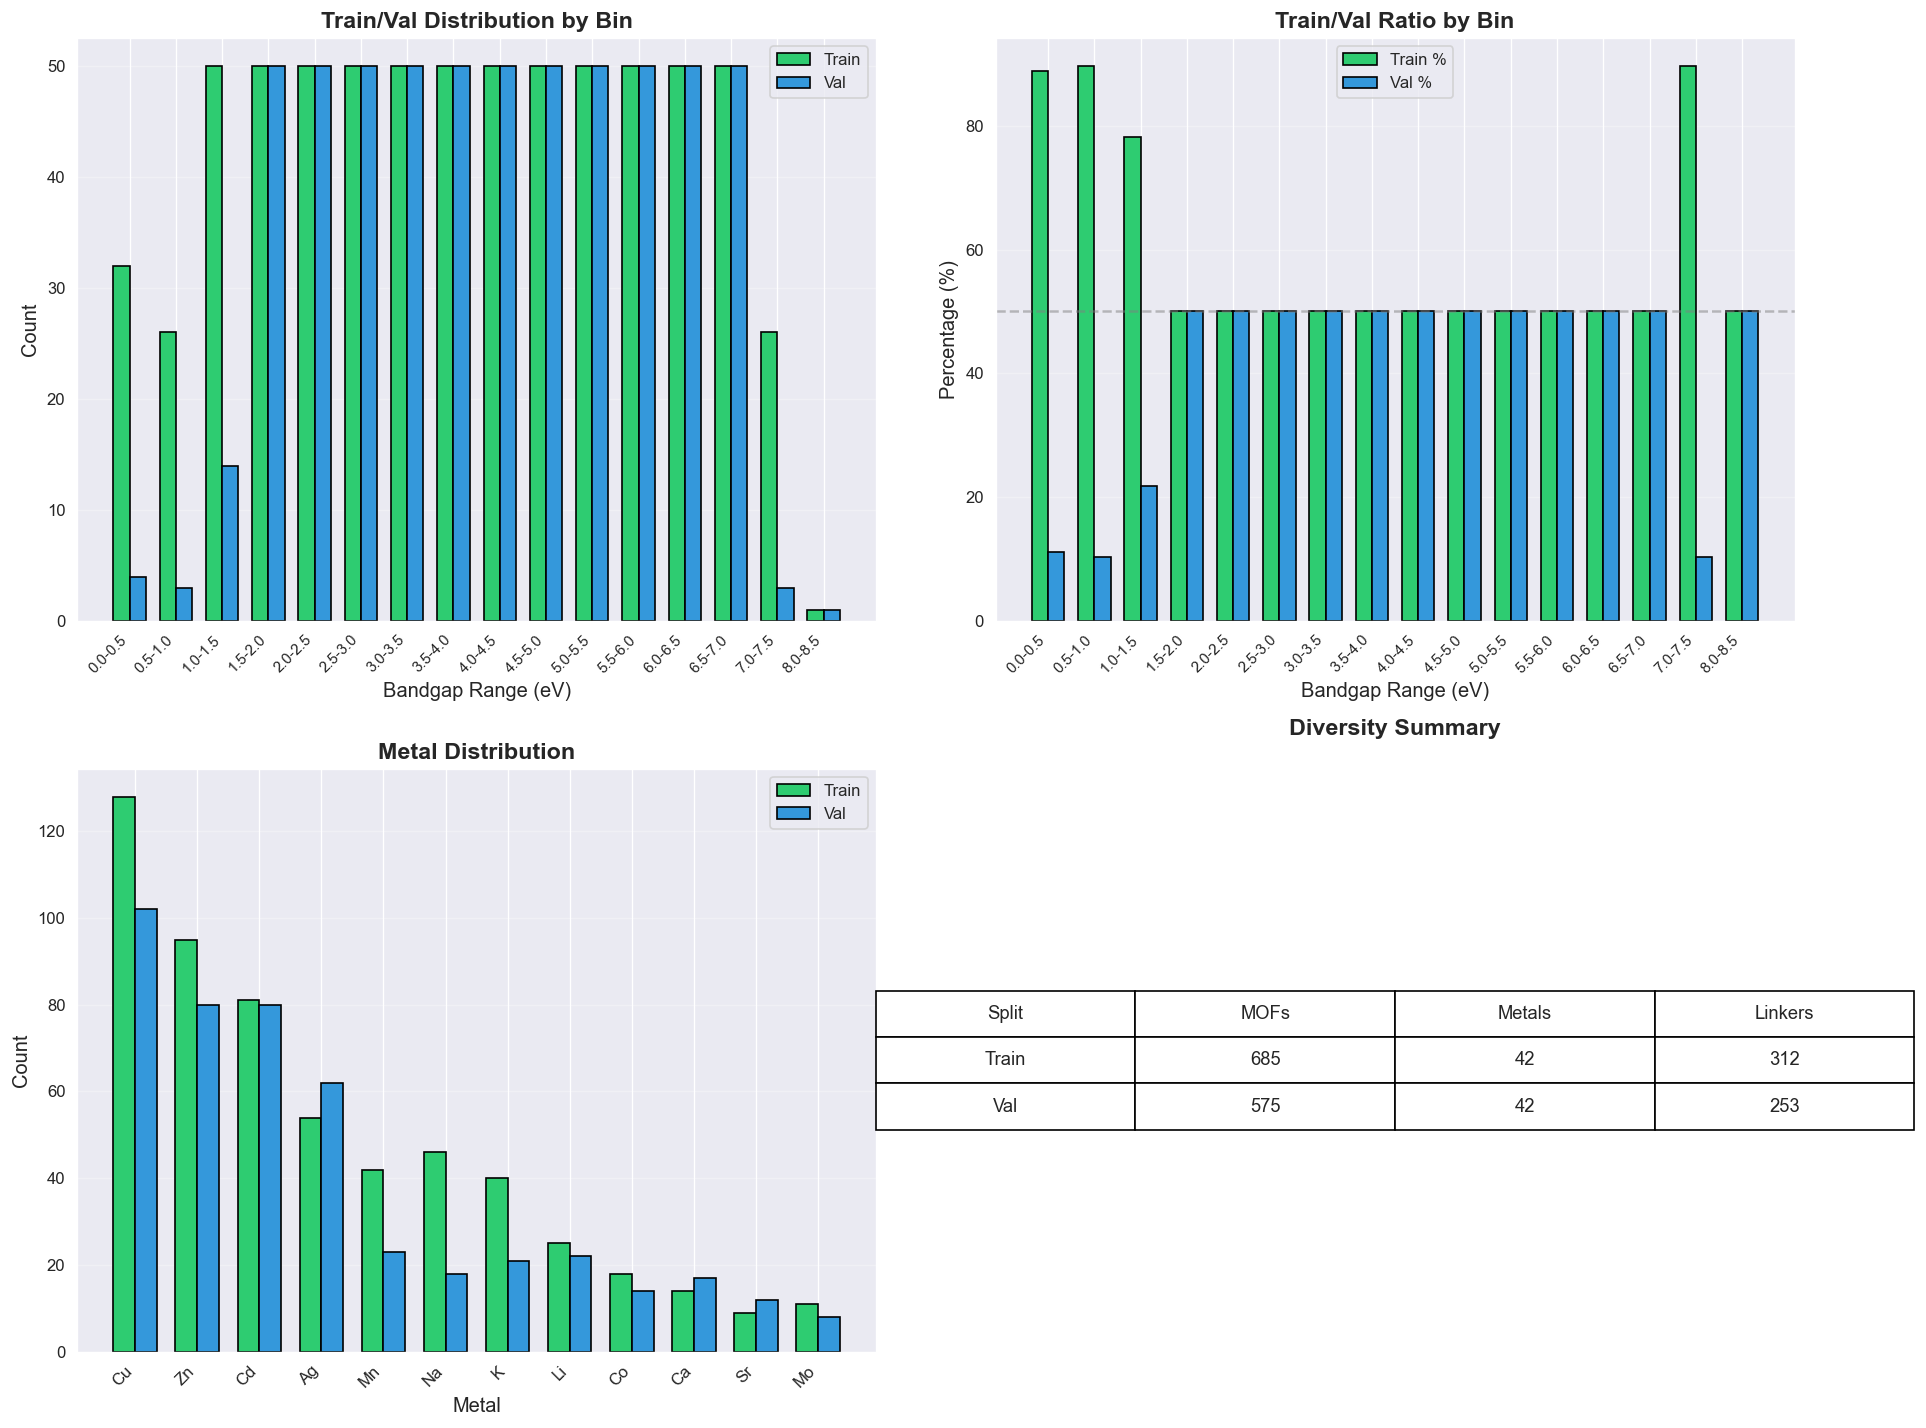


QUERYING PUBCHEM FOR LINKER NAMES...
  Looking up 21 unique linker scaffolds...
    [1/21] ✓ c1ccncc1 -> PYRIDINE
    [2/21] ✓ C1CCCCC1 -> CYCLOHEXANE
    [3/21] ✓ c1cc[nH+]cc1 -> Pyridinium
    [4/21] ✓ C1N2CN3CN1CN(C2)C3 -> methenamine
    [5/21] ✓ C1CN2CCN1CC2 -> 1,4-Diazabicyclo[2.2.2]octane
    [6/21] ✓ c1nnn[nH]1 -> 1H-Tetrazole
    [7/21] ✓ [CH]1N=C[N]N1 -> 2,3-dihydro-1H-1,2,4-triazole
    [8/21] ✓ c1cnccn1 -> PYRAZINE
    [9/21] ✓ c1ccccc1 -> benzene
    [10/21] ✓ C1=NN=N[N]1 -> 1H-Tetrazole
    [11/21] ✓ C1=CN=C[N]1 -> imidazole
    [12/21] ✓ [CH]1C=CC=CN1 -> Dihydropyridines
    [13/21] ✓ C1CNCCN1 -> piperazine
    [14/21] ✓ O=C1[CH]C(=O)C(=O)[CH]C1=O -> Cyclohexane-1,2,4,5-tetraone
    [15/21] ✓ c1nnc[nH]1 -> 1,2,4-TRIAZOLE
    [16/21] ✓ C1=NN=C[N]1 -> 1,2,4-TRIAZOLE
    [17/21] ✗ C1=CN=C[N]1.[CH]1C=NC=N1 -> C1=CN=C[N]1.[CH]1C=NC=N1
    [18/21] ✓ C1COCCO1 -> 1,4-DIOXANE
    [19/21] ✓ c1cncnc1 -> PYRIMIDINE
    [20/21] ✓ c1c[nH]cn1 -> imidazole
    [21/21] ✓ C1CCOC1 -> TETR

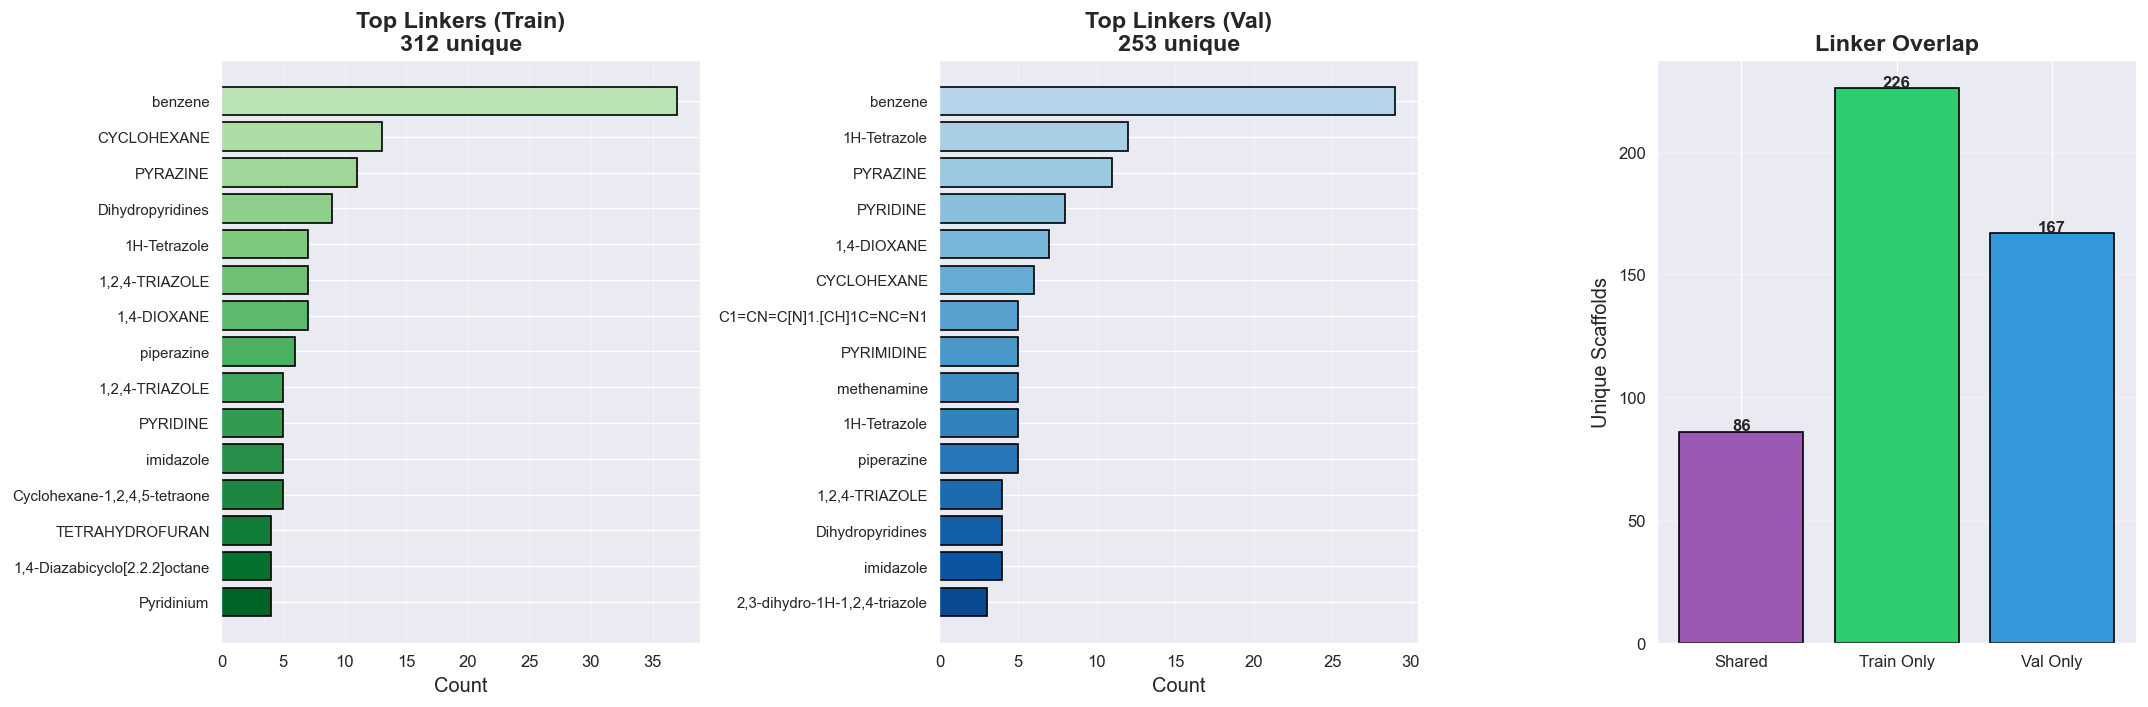


SMILES -> CHEMICAL NAME MAPPING
  benzene                             <- c1ccccc1
  CYCLOHEXANE                         <- C1CCCCC1
  PYRAZINE                            <- c1cnccn1
  Dihydropyridines                    <- [CH]1C=CC=CN1
  1H-Tetrazole                        <- C1=NN=N[N]1
  1,2,4-TRIAZOLE                      <- c1nnc[nH]1
  1,4-DIOXANE                         <- C1COCCO1
  piperazine                          <- C1CNCCN1
  1,2,4-TRIAZOLE                      <- C1=NN=C[N]1
  PYRIDINE                            <- c1ccncc1
  imidazole                           <- C1=CN=C[N]1
  Cyclohexane-1,2,4,5-tetraone        <- O=C1[CH]C(=O)C(=O)[CH]C1=O
  TETRAHYDROFURAN                     <- C1CCOC1
  1,4-Diazabicyclo[2.2.2]octane       <- C1CN2CCN1CC2
  Pyridinium                          <- c1cc[nH+]cc1

  ⚠ 1 SMILES could not be resolved in PubChem

  ✓ Train: 312 unique scaffolds
  ✓ Val: 253 unique scaffolds
  ✓ Shared: 86


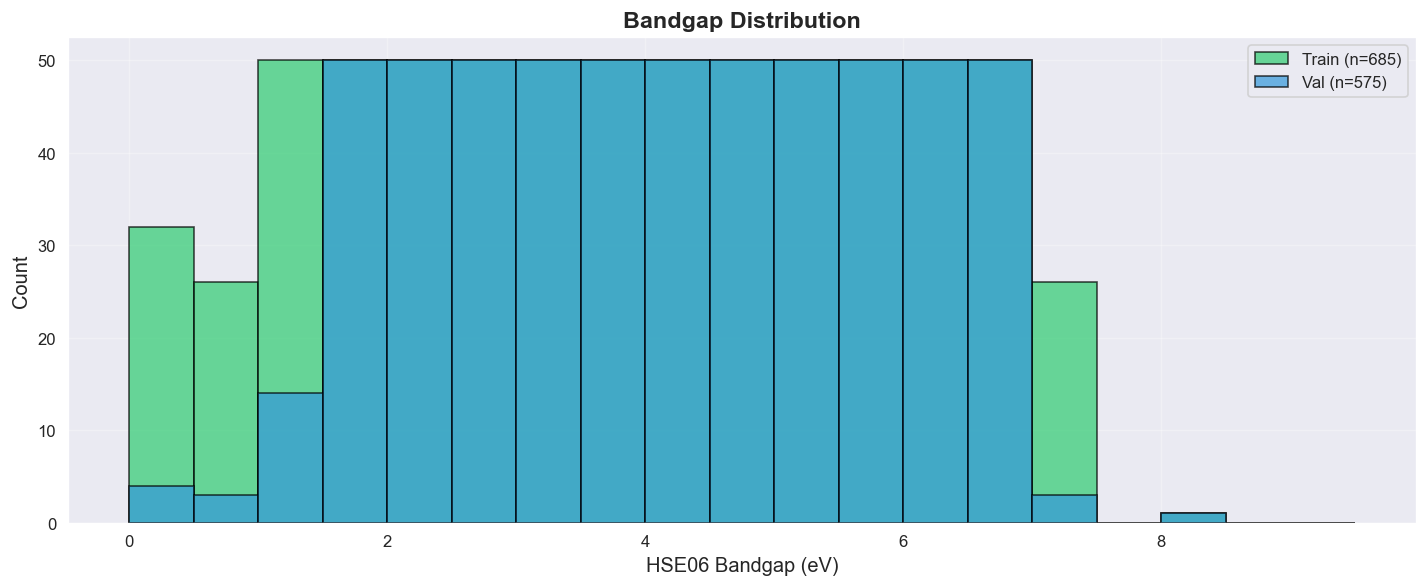


COMPLETE


In [106]:
# ==========================================
# DIVERSITY VISUALIZATION WITH PUBCHEM NAMES
# ==========================================
"""
Linker scaffolds are labeled with proper chemical names from PubChem.
NO hardcoded fallbacks - real API lookup for all compounds.
"""

import os
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pubchempy as pcp
import time
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# PUBCHEM NAME LOOKUP (NO FALLBACKS)
# ==========================================
_name_cache = {}
_failed_lookups = []

def get_chemical_name(smiles):
    """
    Get chemical name from PubChem. No silent fallbacks.
    Returns (name, success) tuple.
    """
    if pd.isna(smiles) or not smiles:
        return (str(smiles), False)
    
    smi = str(smiles).strip()
    
    # Check cache first
    if smi in _name_cache:
        return (_name_cache[smi], True)
    
    # Query PubChem API
    compounds = pcp.get_compounds(smi, 'smiles')
    
    if not compounds:
        _failed_lookups.append(smi)
        _name_cache[smi] = f"[No match: {smi[:15]}...]"
        return (_name_cache[smi], False)
    
    compound = compounds[0]
    
    # Priority 1: Short synonyms (common names)
    if compound.synonyms:
        for syn in compound.synonyms[:15]:
            if len(syn) <= 30 and syn.isascii() and not syn.startswith('CHEMBL'):
                _name_cache[smi] = syn
                return (syn, True)
    
    # Priority 2: IUPAC name
    if compound.iupac_name:
        name = compound.iupac_name
        if len(name) > 35:
            name = name[:32] + "..."
        _name_cache[smi] = name
        return (name, True)
    
    # Priority 3: Molecular formula as last resort
    if compound.molecular_formula:
        _name_cache[smi] = compound.molecular_formula
        return (compound.molecular_formula, True)
    
    _failed_lookups.append(smi)
    _name_cache[smi] = smi[:25]
    return (smi[:25], False)

print("="*80)
print("DIVERSITY VISUALIZATION (PubChem Chemical Names)")
print("="*80)

# ==========================================
# LOAD DATA
# ==========================================
OUTPUT_DIR = 'new_subset'

with open(os.path.join(OUTPUT_DIR, 'train', 'train.json'), 'r') as f:
    train_json = json.load(f)
with open(os.path.join(OUTPUT_DIR, 'validation', 'val.json'), 'r') as f:
    val_json = json.load(f)

train_features = pd.read_csv(os.path.join(OUTPUT_DIR, 'train', 'train_features.csv'), index_col=0)
val_features = pd.read_csv(os.path.join(OUTPUT_DIR, 'validation', 'val_features.csv'), index_col=0)
summary_df = pd.read_csv(os.path.join(OUTPUT_DIR, 'split_summary.csv'))
struct_features = pd.read_csv(os.path.join(OUTPUT_DIR, 'structural_features.csv'), index_col=0)

train_names = set(train_features['name'].values) if 'name' in train_features.columns else set()
val_names = set(val_features['name'].values) if 'name' in val_features.columns else set()
train_struct = struct_features[struct_features['name'].isin(train_names)]
val_struct = struct_features[struct_features['name'].isin(val_names)]

print(f"  Train: {len(train_json)} MOFs | Val: {len(val_json)} MOFs")

# ==========================================
# FIGURE 1: DISTRIBUTION SUMMARY
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
bins = summary_df['range_eV'].values
x = np.arange(len(bins))
width = 0.35
train_counts = summary_df['train'].values
val_counts = summary_df['val'].values
ax1.bar(x - width/2, train_counts, width, label='Train', color='#2ecc71', edgecolor='black')
ax1.bar(x + width/2, val_counts, width, label='Val', color='#3498db', edgecolor='black')
ax1.set_xlabel('Bandgap Range (eV)')
ax1.set_ylabel('Count')
ax1.set_title('Train/Val Distribution by Bin', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(bins, rotation=45, ha='right', fontsize=9)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[0, 1]
total = np.where(train_counts + val_counts == 0, 1, train_counts + val_counts)
ax2.bar(x - width/2, 100*train_counts/total, width, label='Train %', color='#2ecc71', edgecolor='black')
ax2.bar(x + width/2, 100*val_counts/total, width, label='Val %', color='#3498db', edgecolor='black')
ax2.set_xlabel('Bandgap Range (eV)')
ax2.set_ylabel('Percentage (%)')
ax2.set_title('Train/Val Ratio by Bin', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(bins, rotation=45, ha='right', fontsize=9)
ax2.legend()
ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
ax2.grid(axis='y', alpha=0.3)

ax3 = axes[1, 0]
if 'primary_metal' in train_features.columns:
    train_metals = train_features['primary_metal'].value_counts()
    val_metals = val_features['primary_metal'].value_counts()
    all_m = set(train_metals.index) | set(val_metals.index)
    top_m = sorted(all_m, key=lambda m: train_metals.get(m,0)+val_metals.get(m,0), reverse=True)[:12]
    xm = np.arange(len(top_m))
    ax3.bar(xm - 0.175, [train_metals.get(m,0) for m in top_m], 0.35, label='Train', color='#2ecc71', edgecolor='black')
    ax3.bar(xm + 0.175, [val_metals.get(m,0) for m in top_m], 0.35, label='Val', color='#3498db', edgecolor='black')
    ax3.set_xlabel('Metal')
    ax3.set_ylabel('Count')
    ax3.set_title('Metal Distribution', fontweight='bold')
    ax3.set_xticks(xm)
    ax3.set_xticklabels(top_m, rotation=45, ha='right')
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)

ax4 = axes[1, 1]
ax4.axis('off')
n_metals_t = train_features['primary_metal'].nunique() if 'primary_metal' in train_features.columns else 0
n_metals_v = val_features['primary_metal'].nunique() if 'primary_metal' in val_features.columns else 0
n_scaff_t = train_struct['linker_scaffold'].nunique() if 'linker_scaffold' in train_struct.columns else 0
n_scaff_v = val_struct['linker_scaffold'].nunique() if 'linker_scaffold' in val_struct.columns else 0
table_data = [['Train', len(train_json), n_metals_t, n_scaff_t], ['Val', len(val_json), n_metals_v, n_scaff_v]]
table = ax4.table(cellText=table_data, colLabels=['Split', 'MOFs', 'Metals', 'Linkers'], loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 2)
ax4.set_title('Diversity Summary', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'diversity_1_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# FIGURE 2: LINKER SCAFFOLDS WITH PUBCHEM NAMES
# ==========================================
print("\n" + "="*60)
print("QUERYING PUBCHEM FOR LINKER NAMES...")
print("="*60)

if 'linker_scaffold' in train_struct.columns and len(train_struct) > 0:
    train_scaffolds = train_struct['linker_scaffold'].dropna().value_counts()
    val_scaffolds = val_struct['linker_scaffold'].dropna().value_counts()
    
    # Get top 15 unique SMILES to look up
    top_train_smiles = list(train_scaffolds.head(15).index)
    top_val_smiles = list(val_scaffolds.head(15).index)
    all_top_smiles = list(set(top_train_smiles + top_val_smiles))
    
    print(f"  Looking up {len(all_top_smiles)} unique linker scaffolds...")
    
    # Query PubChem for each (with progress)
    for i, smi in enumerate(all_top_smiles):
        name, success = get_chemical_name(smi)
        status = "✓" if success else "✗"
        print(f"    [{i+1}/{len(all_top_smiles)}] {status} {smi[:40]} -> {name}")
        time.sleep(0.2)  # Rate limiting for PubChem API
    
    # Create plot
    fig4, axes4 = plt.subplots(1, 3, figsize=(18, 6))
    
    # Train scaffolds
    ax4a = axes4[0]
    top_train = train_scaffolds.head(15)
    train_labels = [get_chemical_name(s)[0] for s in top_train.index]
    colors_t = plt.cm.Greens(np.linspace(0.3, 0.9, len(top_train)))
    ax4a.barh(range(len(top_train)), top_train.values, color=colors_t, edgecolor='black')
    ax4a.set_yticks(range(len(top_train)))
    ax4a.set_yticklabels(train_labels, fontsize=9)
    ax4a.set_xlabel('Count')
    ax4a.set_title(f'Top Linkers (Train)\n{len(train_scaffolds)} unique', fontweight='bold')
    ax4a.invert_yaxis()
    ax4a.grid(axis='x', alpha=0.3)
    
    # Val scaffolds
    ax4b = axes4[1]
    top_val = val_scaffolds.head(15)
    val_labels = [get_chemical_name(s)[0] for s in top_val.index]
    colors_v = plt.cm.Blues(np.linspace(0.3, 0.9, len(top_val)))
    ax4b.barh(range(len(top_val)), top_val.values, color=colors_v, edgecolor='black')
    ax4b.set_yticks(range(len(top_val)))
    ax4b.set_yticklabels(val_labels, fontsize=9)
    ax4b.set_xlabel('Count')
    ax4b.set_title(f'Top Linkers (Val)\n{len(val_scaffolds)} unique', fontweight='bold')
    ax4b.invert_yaxis()
    ax4b.grid(axis='x', alpha=0.3)
    
    # Overlap
    ax4c = axes4[2]
    train_set = set(train_scaffolds.index)
    val_set = set(val_scaffolds.index)
    shared = len(train_set & val_set)
    only_t = len(train_set - val_set)
    only_v = len(val_set - train_set)
    bars = ax4c.bar(['Shared', 'Train Only', 'Val Only'], [shared, only_t, only_v], 
                    color=['#9b59b6', '#2ecc71', '#3498db'], edgecolor='black')
    ax4c.set_ylabel('Unique Scaffolds')
    ax4c.set_title('Linker Overlap', fontweight='bold')
    ax4c.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, [shared, only_t, only_v]):
        ax4c.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, str(val), ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'diversity_2_linkers.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print full mapping table
    print("\n" + "="*60)
    print("SMILES -> CHEMICAL NAME MAPPING")
    print("="*60)
    for smi in top_train_smiles[:15]:
        name, success = get_chemical_name(smi)
        print(f"  {name:35} <- {smi}")
    
    if _failed_lookups:
        print(f"\n  ⚠ {len(_failed_lookups)} SMILES could not be resolved in PubChem")
    
    print(f"\n  ✓ Train: {len(train_scaffolds)} unique scaffolds")
    print(f"  ✓ Val: {len(val_scaffolds)} unique scaffolds")
    print(f"  ✓ Shared: {shared}")

# ==========================================
# FIGURE 3: BANDGAP DISTRIBUTION
# ==========================================
fig3, ax = plt.subplots(figsize=(12, 5))
train_bg = list(train_json.values())
val_bg = list(val_json.values())
bins_bg = np.arange(0, 10, 0.5)
ax.hist(train_bg, bins=bins_bg, alpha=0.7, label=f'Train (n={len(train_bg)})', color='#2ecc71', edgecolor='black')
ax.hist(val_bg, bins=bins_bg, alpha=0.7, label=f'Val (n={len(val_bg)})', color='#3498db', edgecolor='black')
ax.set_xlabel('HSE06 Bandgap (eV)')
ax.set_ylabel('Count')
ax.set_title('Bandgap Distribution', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'diversity_3_bandgap.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("COMPLETE")
print("="*60)

K-FOLD CROSS-VALIDATION WITH RANDOM SAMPLING

Strategy: Same size as Cell 22, but RANDOM selection per fold
          (not deterministic MaxMin - ensures different training sets)

[Step 1] LOADING DATA FROM CELL 22
  OK K-fold dataset: 10810 MOFs
  OK Bandgap column: outputs.pbe.bandgap

[Step 2] ASSIGNING VALIDATION FOLDS (STRATIFIED BY BIN)
  Bins: 16
  Fold 1 validation: 2167 MOFs
  Fold 2 validation: 2165 MOFs
  Fold 3 validation: 2164 MOFs
  Fold 4 validation: 2160 MOFs
  Fold 5 validation: 2154 MOFs

  OK Each MOF assigned to exactly ONE validation fold

[Step 3] RANDOM TRAINING SELECTION PER FOLD
  Using same size logic as Cell 22: 50 per rich bin, percentage for sparse
  Selection method: RANDOM (different seed per fold)

------------------------------------------------------------
  FOLD 1 / 5
------------------------------------------------------------
    Train: 666 MOFs (RANDOM selection)
    Val:   2167 MOFs (ALL in fold)
    Metals: 48 (train), 49 (val)
    Scaffolds: 198

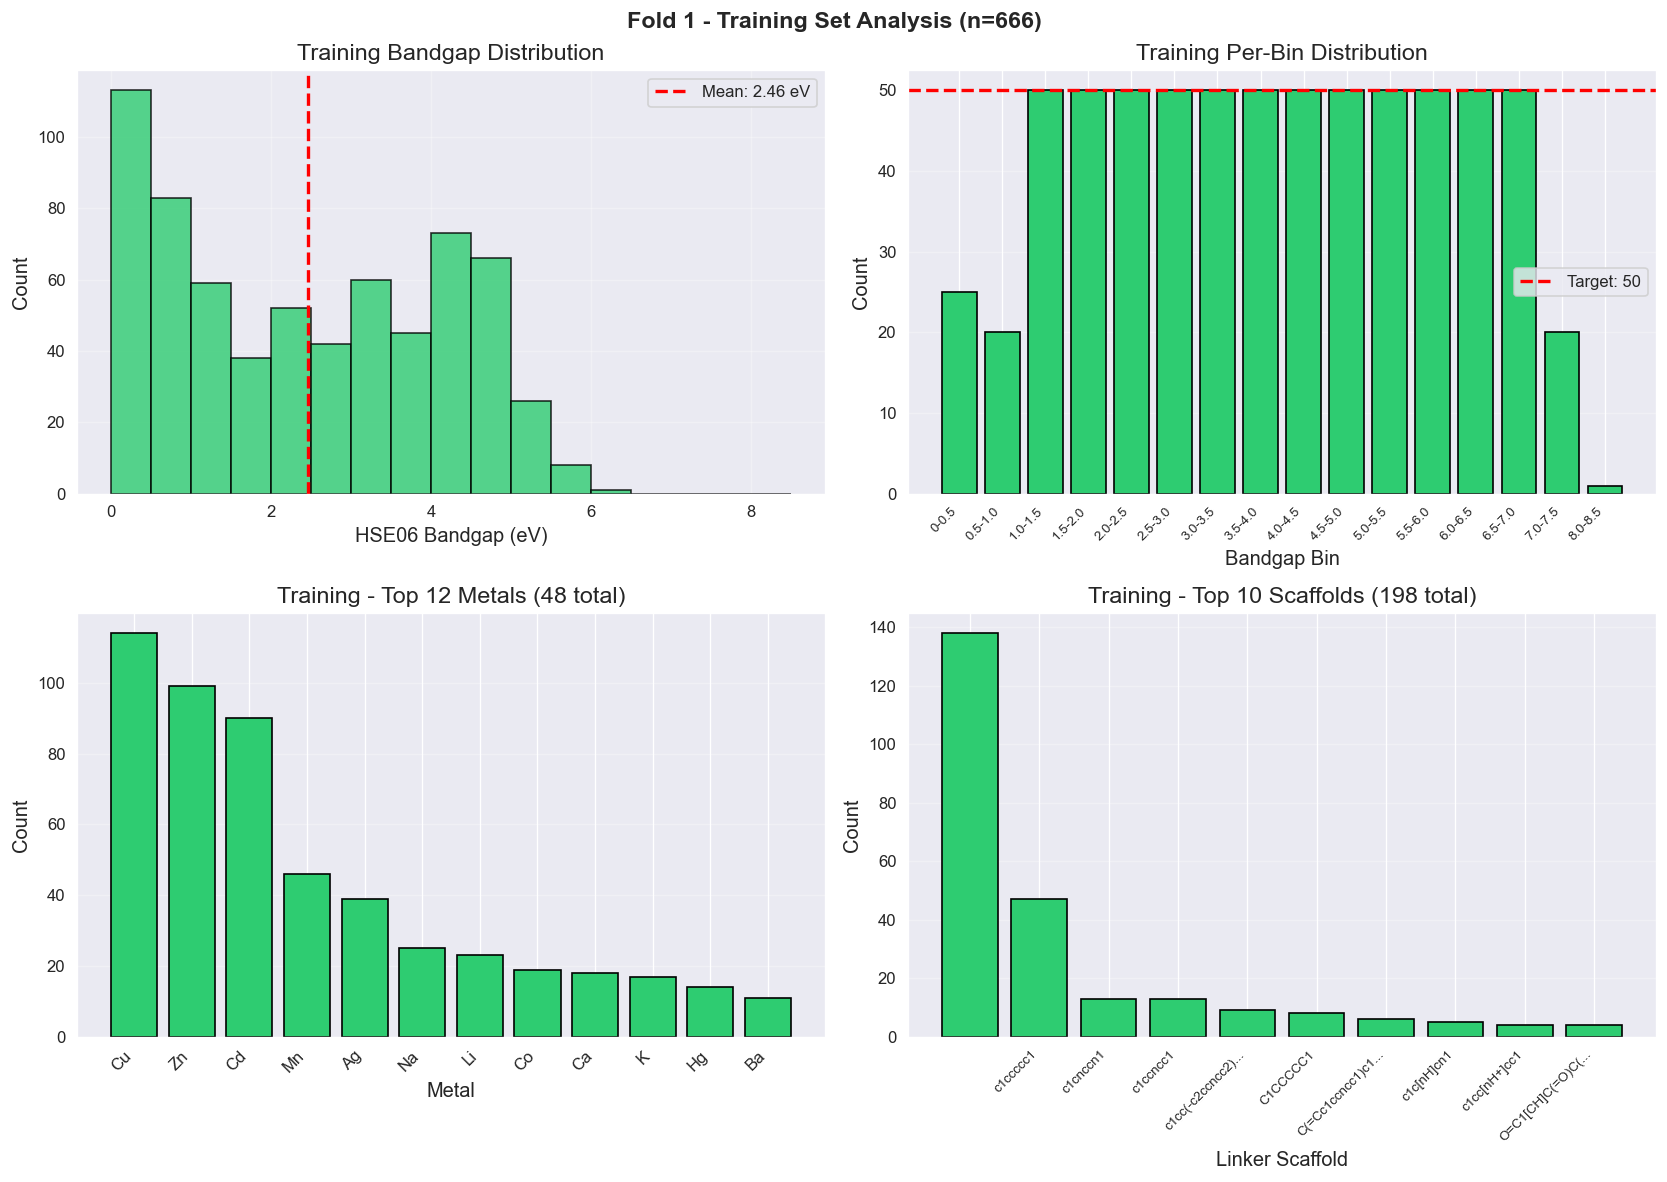


  [Fold 1] Fetching chemical names from PubChem (training scaffolds)...
    PubChem lookup: 11/12 names found


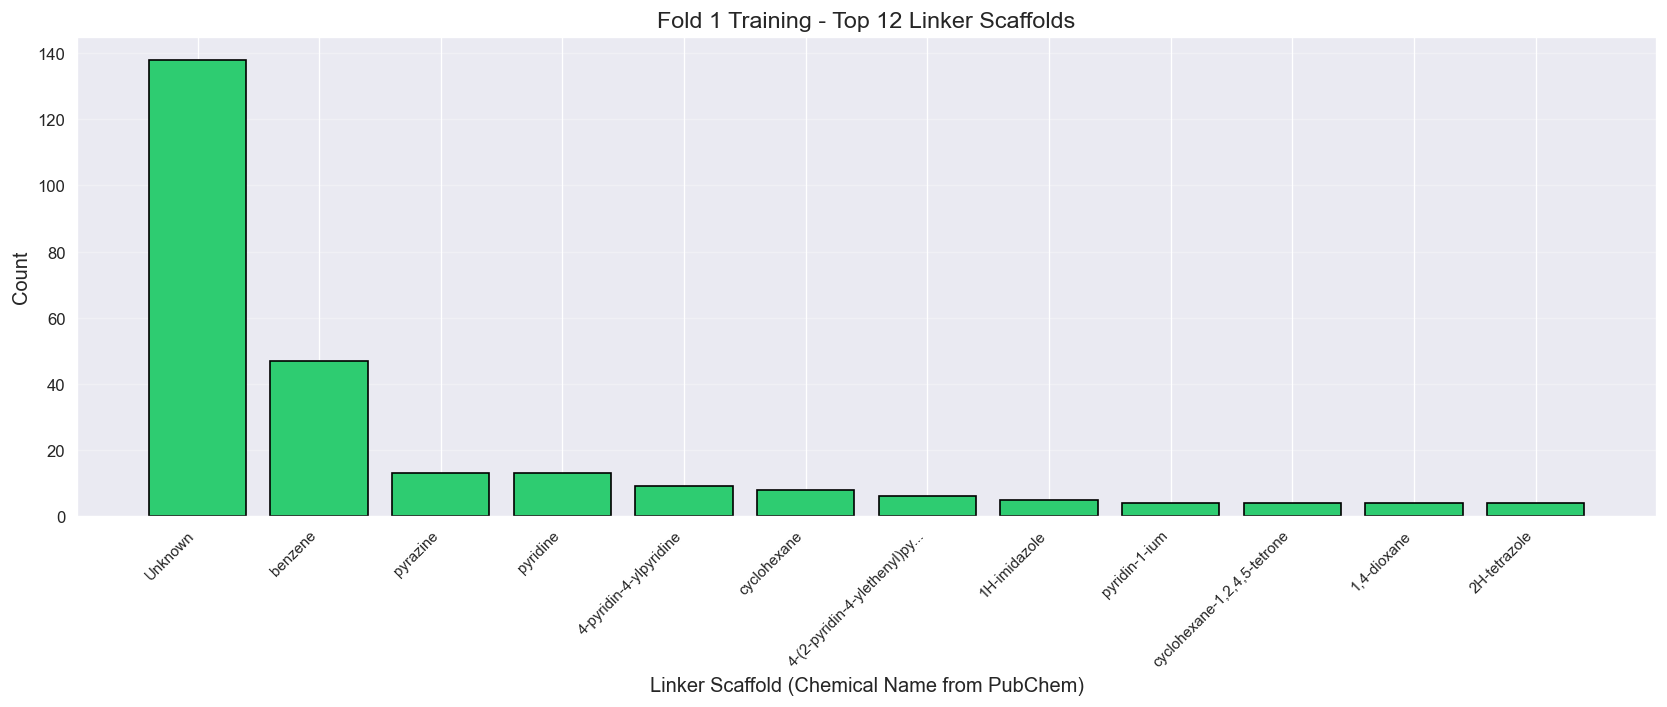


  Fold 1 Training Statistics:
    MOFs: 666
    Metals: 48 unique
    Scaffolds: 198 unique
    Bandgap: 2.46 +/- 1.70 eV

  FOLD 2 - TRAINING SET ANALYSIS


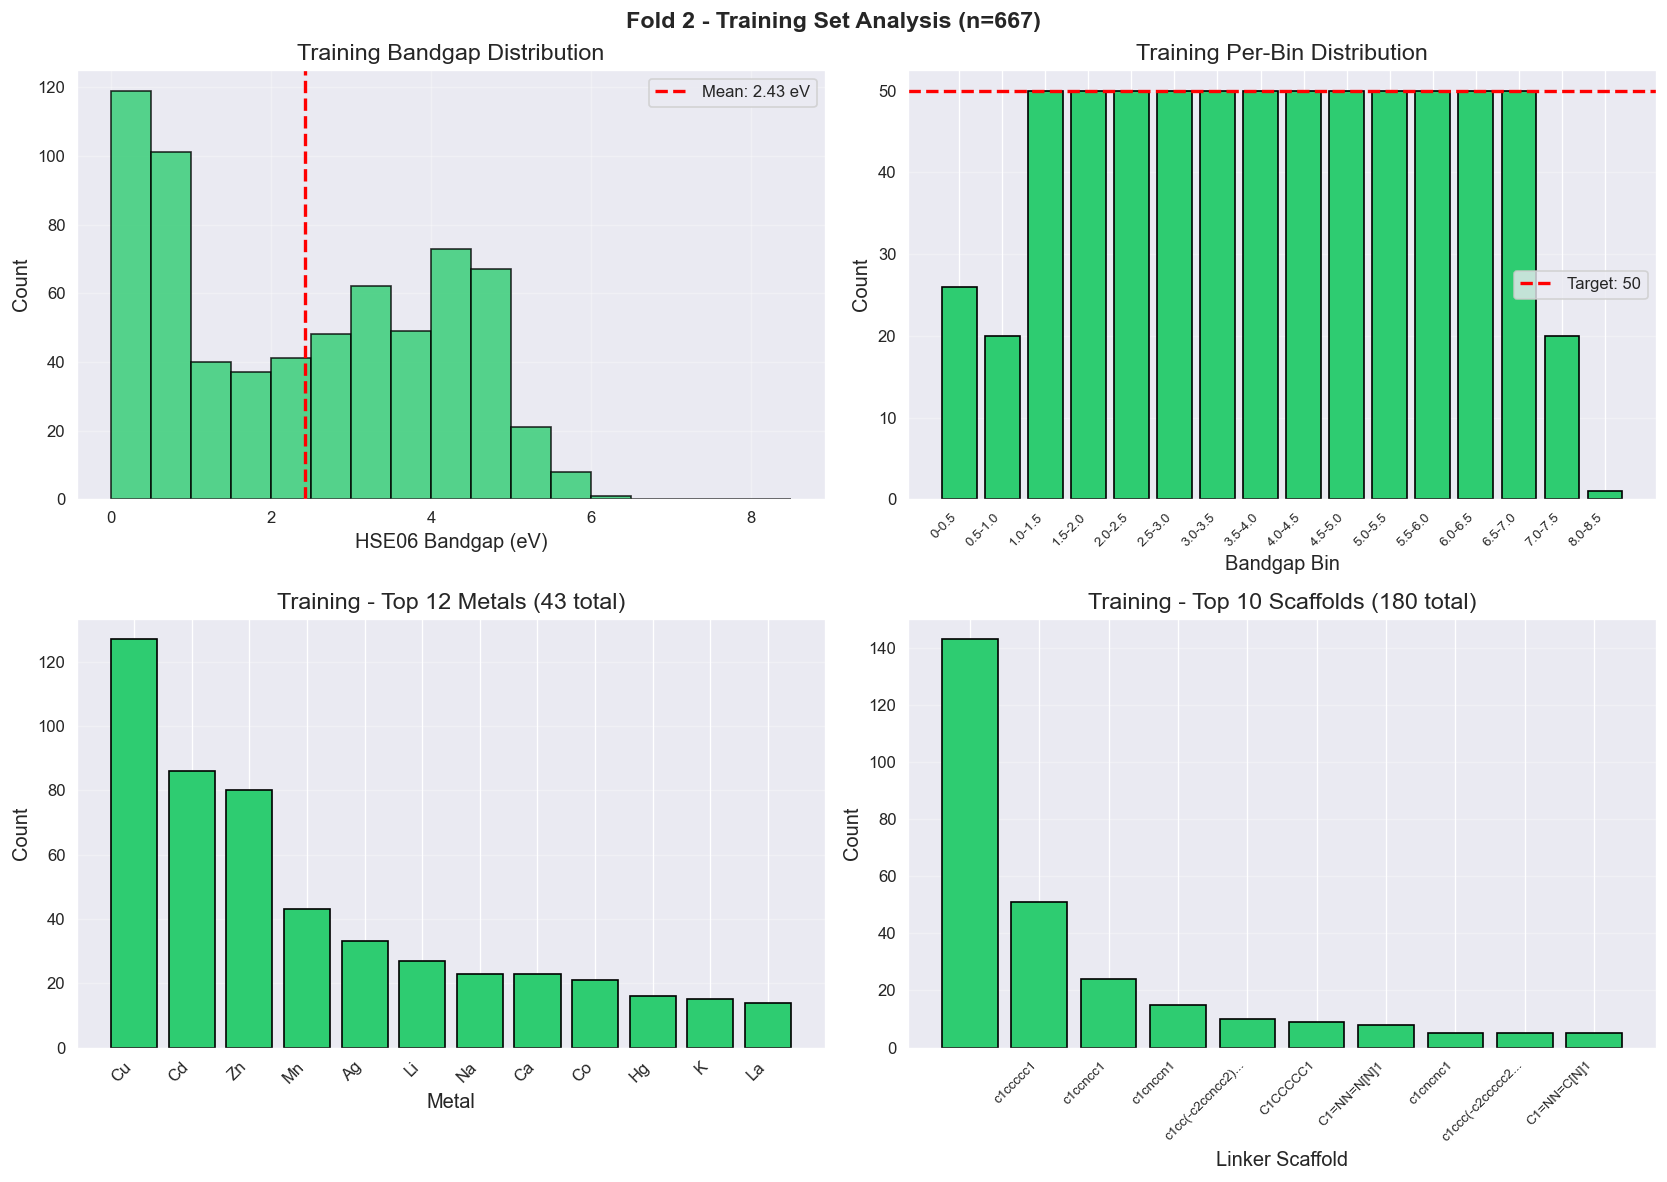


  [Fold 2] Fetching chemical names from PubChem (training scaffolds)...
    PubChem lookup: 11/12 names found


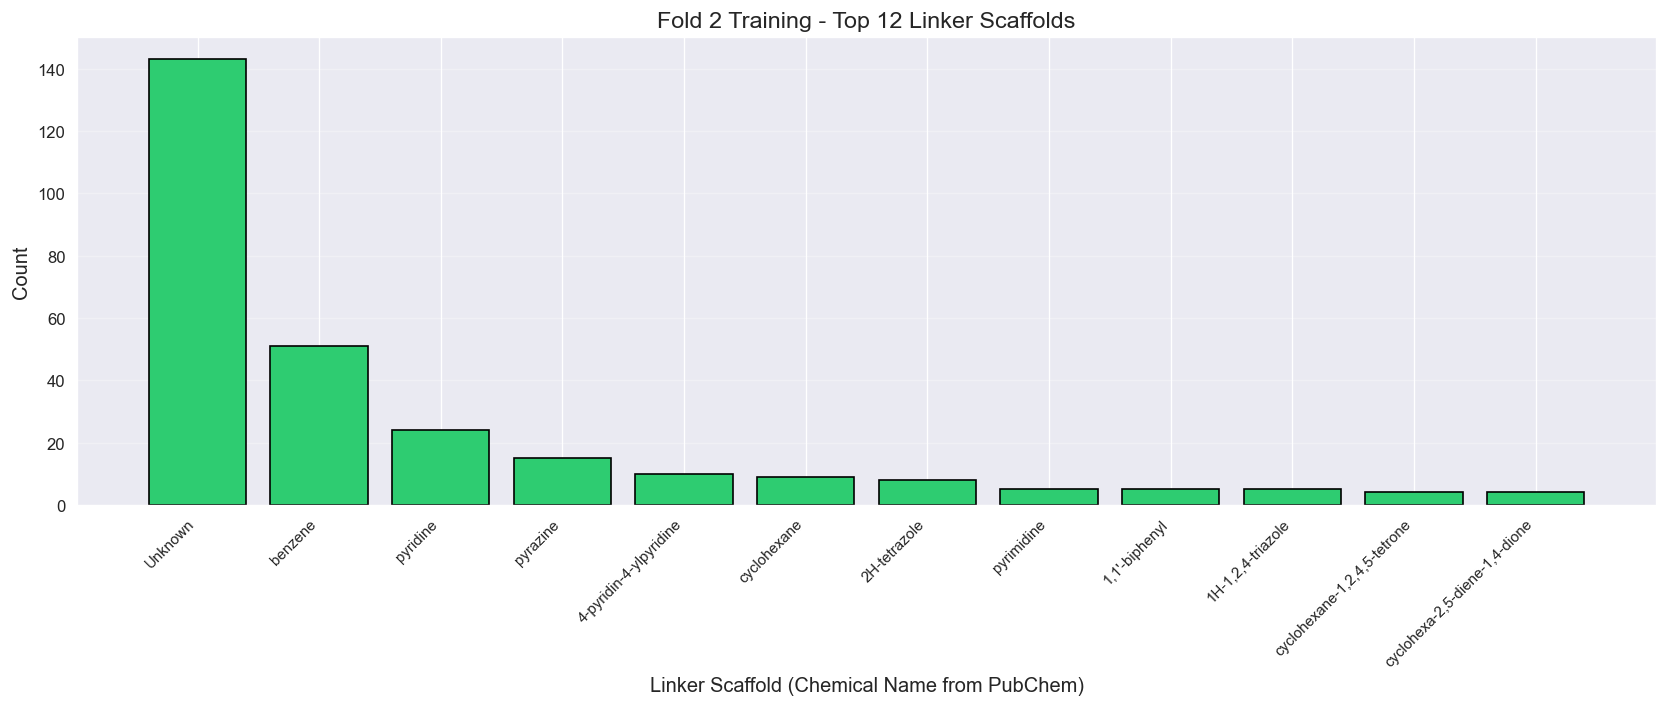


  Fold 2 Training Statistics:
    MOFs: 667
    Metals: 43 unique
    Scaffolds: 180 unique
    Bandgap: 2.43 +/- 1.70 eV

  FOLD 3 - TRAINING SET ANALYSIS


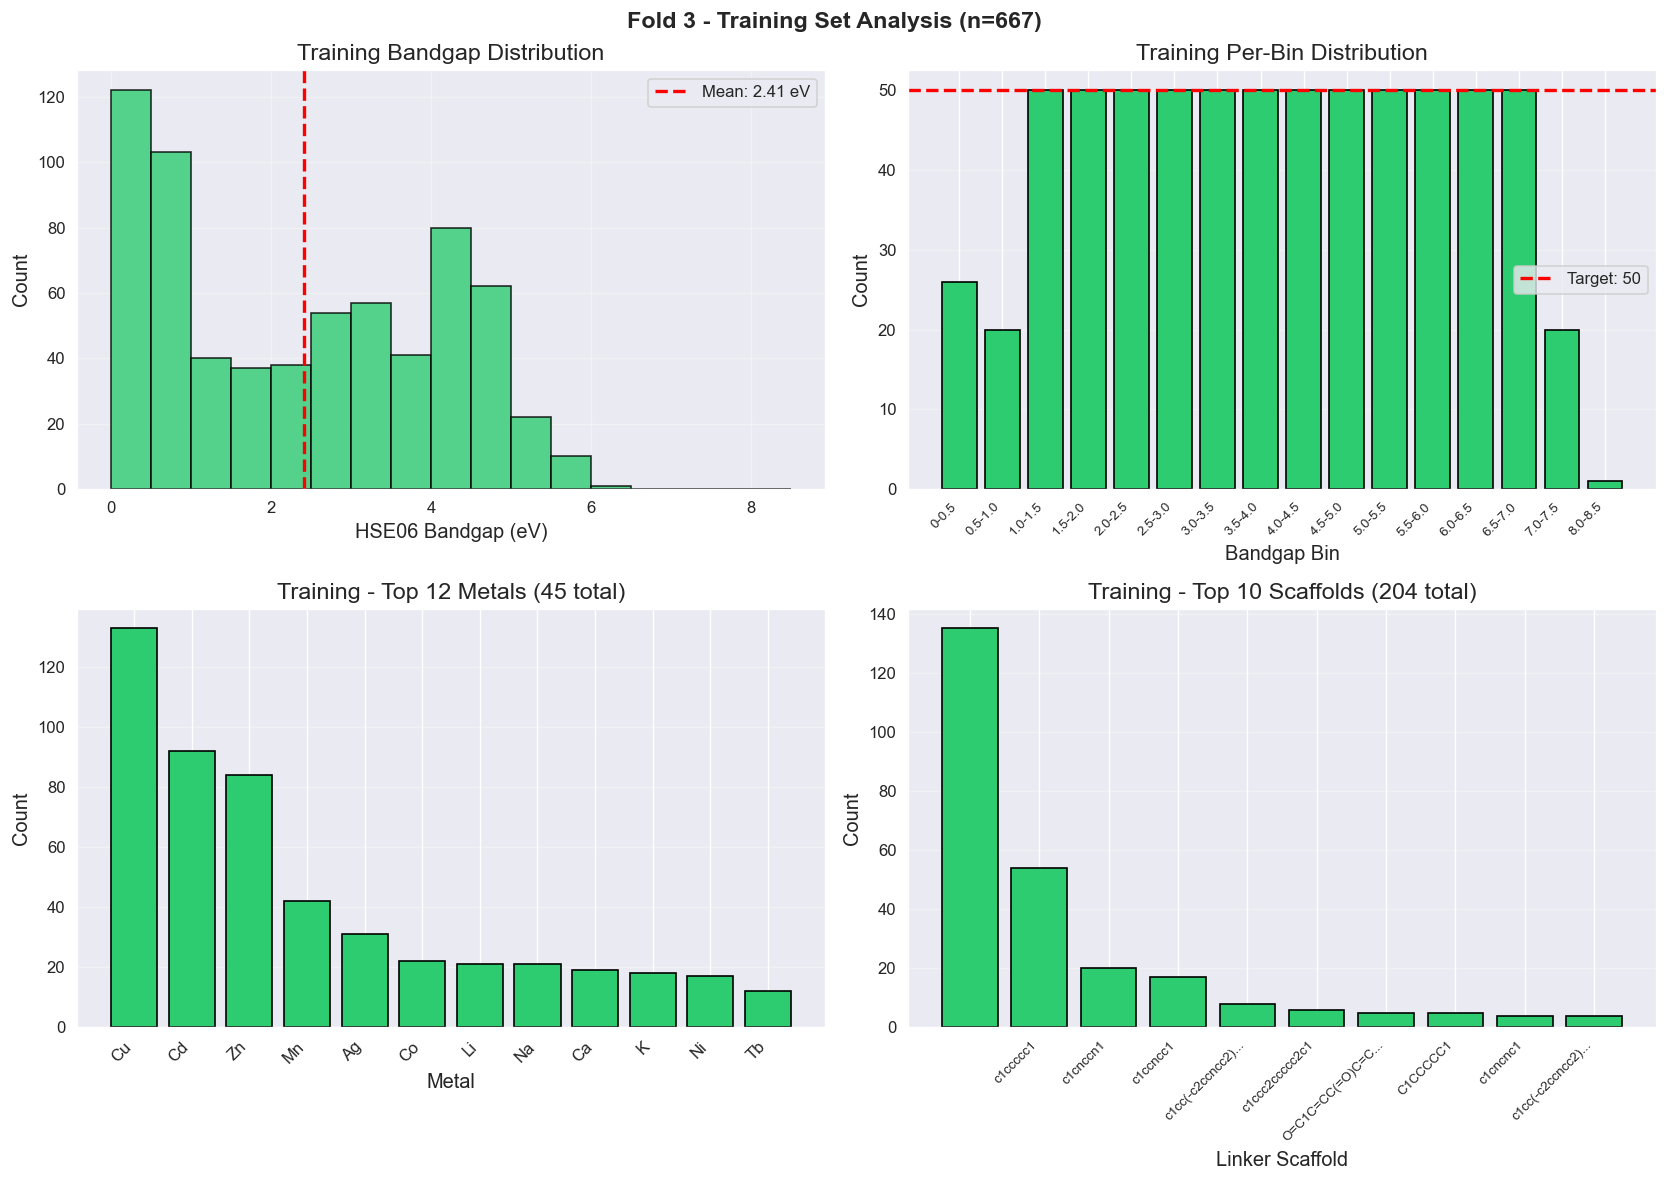


  [Fold 3] Fetching chemical names from PubChem (training scaffolds)...
    PubChem lookup: 10/12 names found


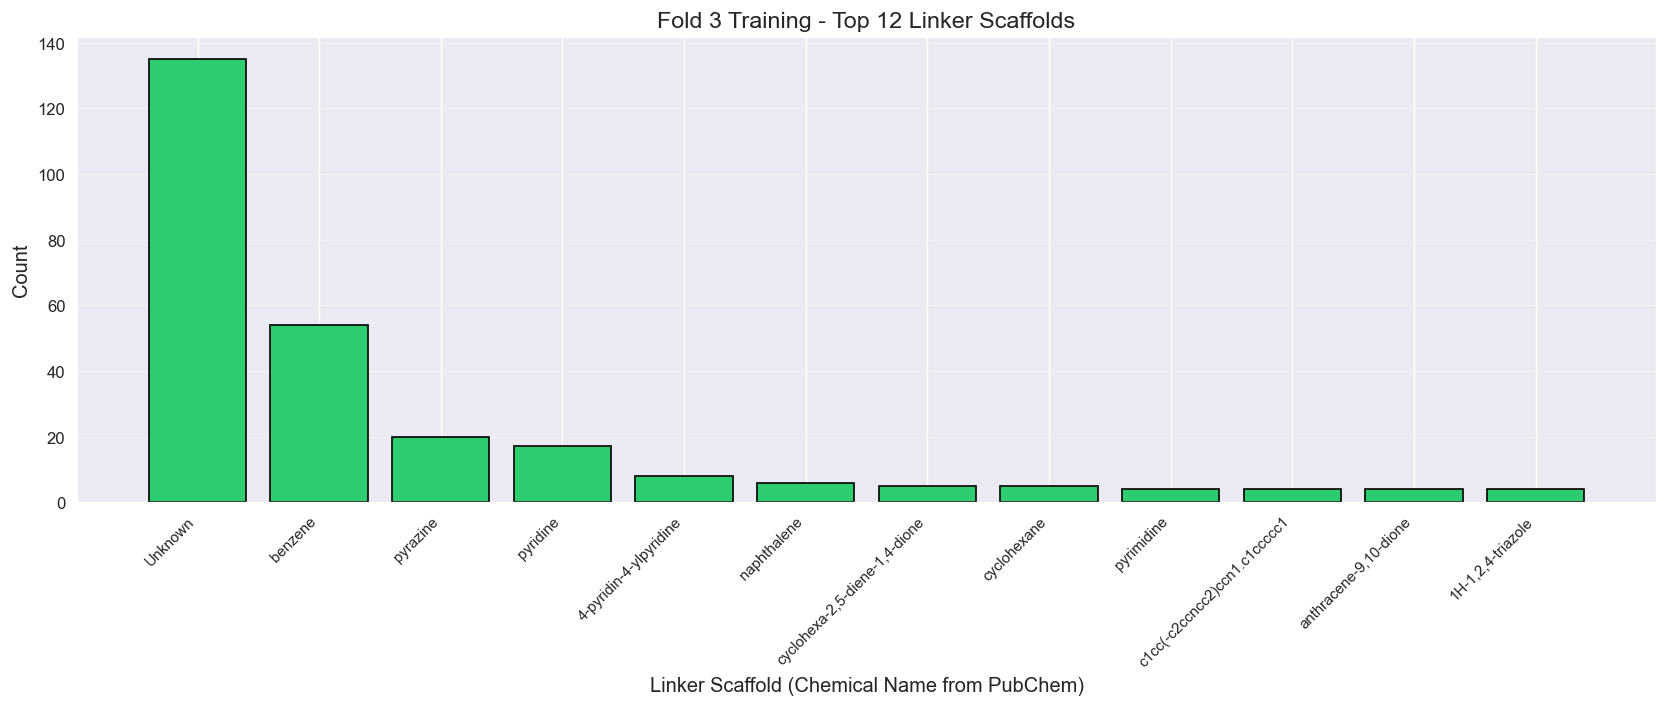


  Fold 3 Training Statistics:
    MOFs: 667
    Metals: 45 unique
    Scaffolds: 204 unique
    Bandgap: 2.41 +/- 1.70 eV

  FOLD 4 - TRAINING SET ANALYSIS


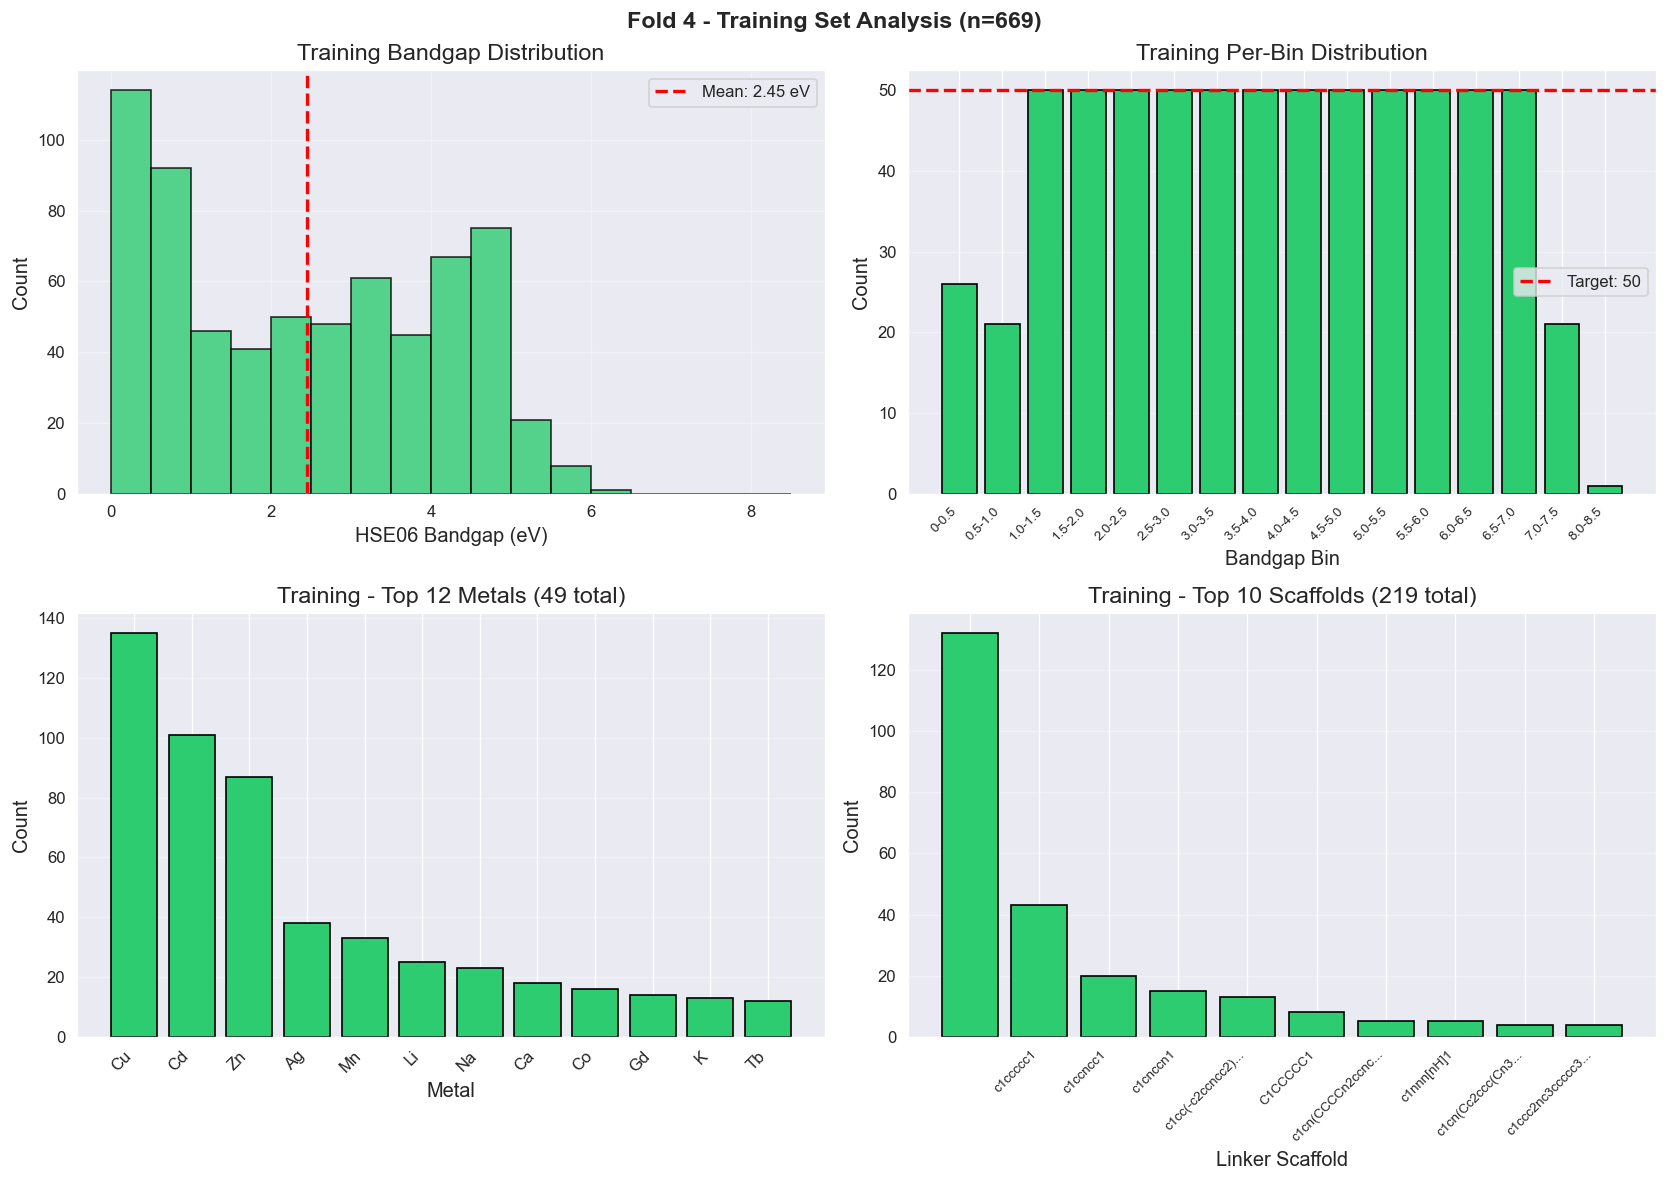


  [Fold 4] Fetching chemical names from PubChem (training scaffolds)...
    PubChem lookup: 11/12 names found


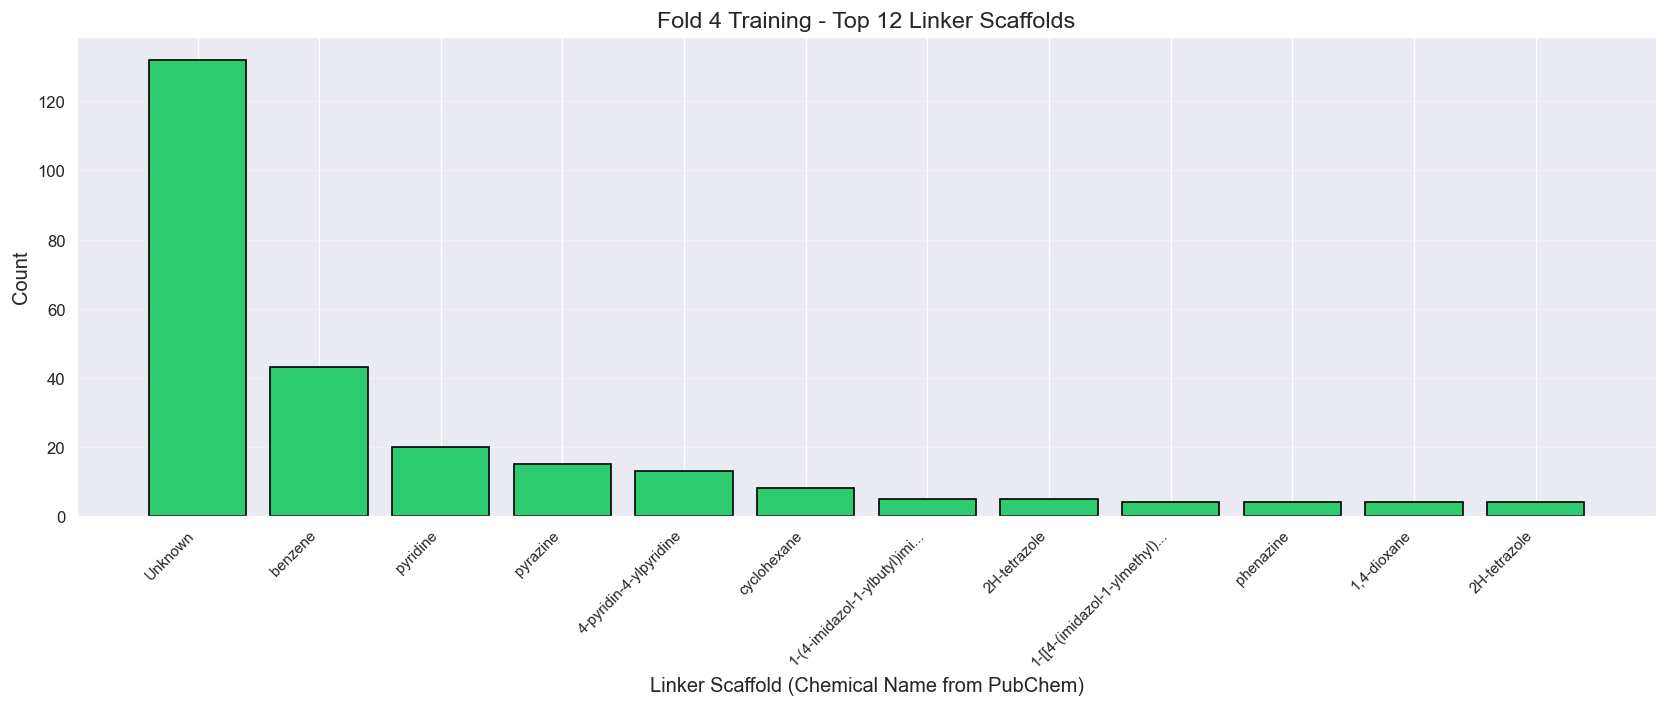


  Fold 4 Training Statistics:
    MOFs: 669
    Metals: 49 unique
    Scaffolds: 219 unique
    Bandgap: 2.45 +/- 1.69 eV

  FOLD 5 - TRAINING SET ANALYSIS


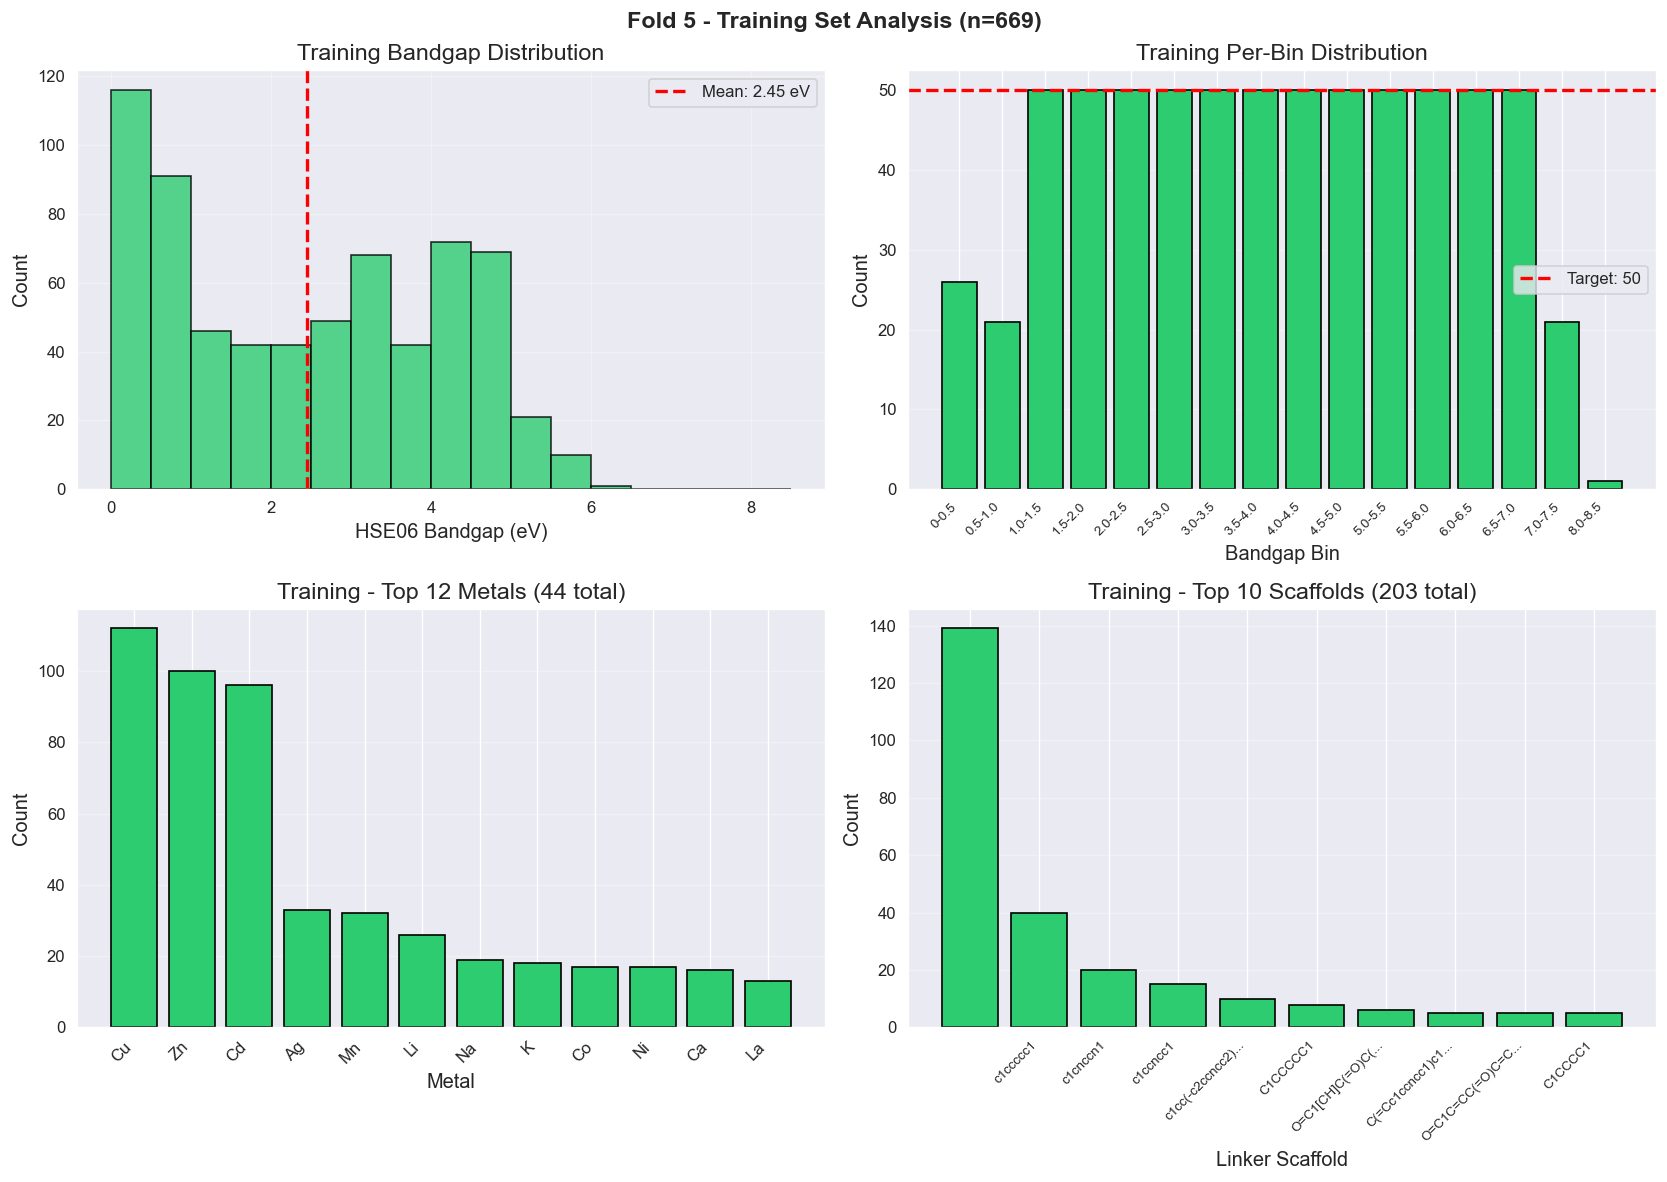


  [Fold 5] Fetching chemical names from PubChem (training scaffolds)...
    PubChem lookup: 11/12 names found


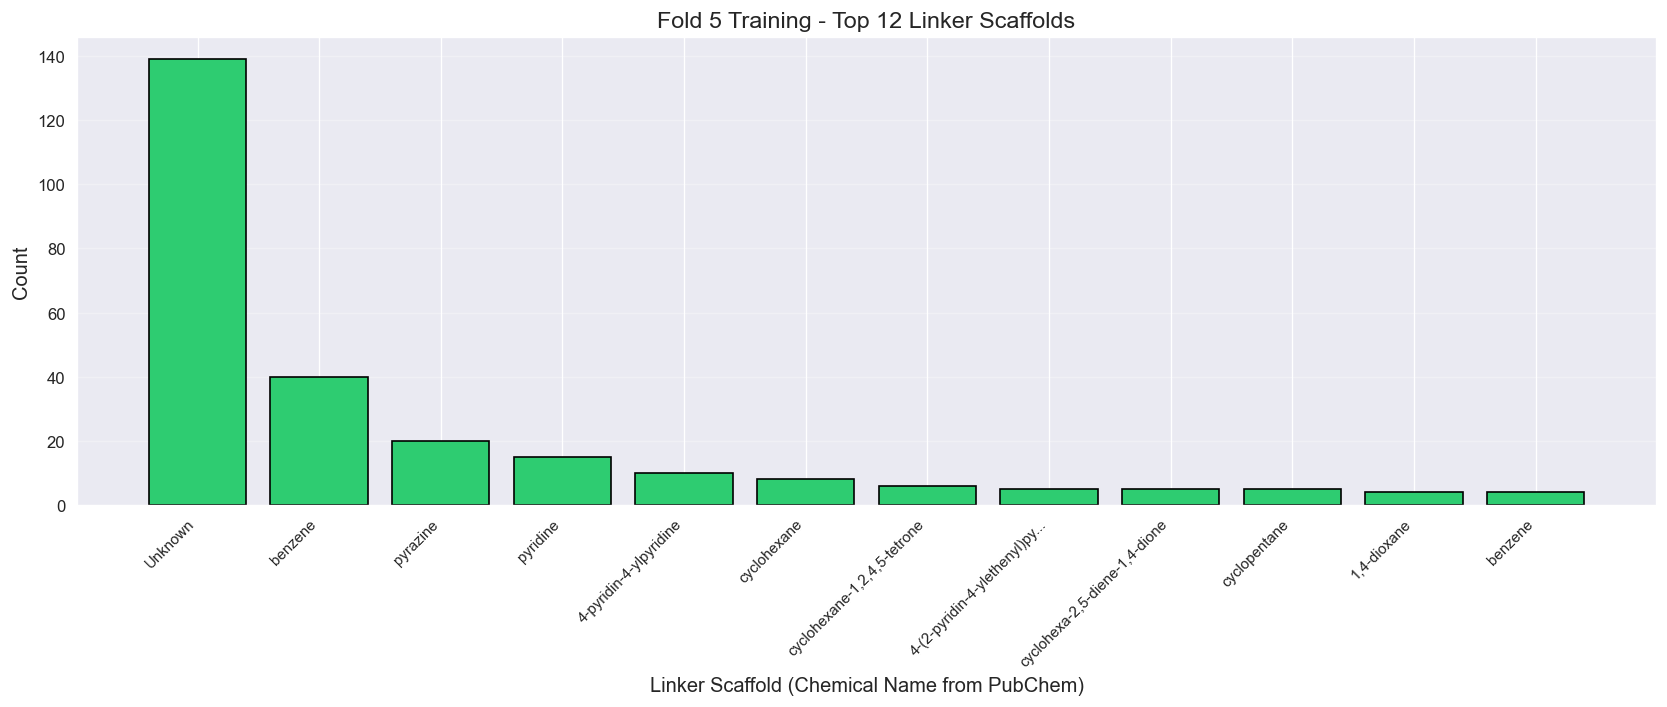


  Fold 5 Training Statistics:
    MOFs: 669
    Metals: 44 unique
    Scaffolds: 203 unique
    Bandgap: 2.45 +/- 1.69 eV

K-FOLD COMPLETE!

  Strategy: RANDOM sampling (same size as Cell 22, different samples per fold)
  Key difference from Cell 22:
    - Cell 22: MaxMin diversity selection (deterministic, for production)
    - Cell 24: Random sampling (probabilistic, for cross-validation)

  This ensures each fold has meaningfully different training sets!


In [112]:
# ==========================================
# K-FOLD CROSS-VALIDATION WITH RANDOM SAMPLING
# ==========================================
"""
K-fold CV with RANDOM (not deterministic) training selection.

APPROACH:
  - Same training SIZE logic as Cell 22 (50 per rich bin, percentage for sparse)
  - But RANDOM selection instead of MaxMin (probabilistic, not deterministic)
  - This ensures each fold has DIFFERENT training sets
  - Validation: ALL MOFs in that fold (no selection - proper CV)

Why random instead of MaxMin?
  - MaxMin is deterministic -> nearly identical training sets across folds
  - Random sampling with different seeds -> truly different training per fold
  - Still maintains the 50-per-bin strategy for balanced representation

Output structure:
  kfold_subsets/
    fold_1/
      train.json, val.json, train_features.csv, val_features.csv
      fold_1_train_analysis.png
    fold_summary.csv
"""

import os
import re
import json
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import pubchempy as pcp

print("="*80)
print("K-FOLD CROSS-VALIDATION WITH RANDOM SAMPLING")
print("="*80)
print("\nStrategy: Same size as Cell 22, but RANDOM selection per fold")
print("          (not deterministic MaxMin - ensures different training sets)\n")

# ══════════════════════════════════════════════════════════════════════════════
#   K-FOLD CONFIGURATION (SAME SIZE LOGIC AS CELL 22)
# ══════════════════════════════════════════════════════════════════════════════
K_FOLDS = 5
TARGET_TRAIN = 50          # Same as cell 22
TARGET_VAL = 50            # Same as cell 22
TRAIN_FRACTION = 0.8       # For sparse bins
VAL_FRACTION = 0.1         # For sparse bins
RICH_BIN_THRESHOLD = 50    # Same as cell 22
KFOLD_OUTPUT_DIR = 'kfold_subsets'
RANDOM_SEED = 42
# ══════════════════════════════════════════════════════════════════════════════

np.random.seed(RANDOM_SEED)

for k in range(1, K_FOLDS + 1):
    os.makedirs(os.path.join(KFOLD_OUTPUT_DIR, f'fold_{k}'), exist_ok=True)

# ==========================================
# CHECK PREREQUISITES
# ==========================================
print("="*60)
print("[Step 1] LOADING DATA FROM CELL 22")
print("="*60)

if 'source_df' not in dir():
    raise NameError("Run cell 22 first to generate source_df")

kfold_df = source_df.copy()
print(f"  OK K-fold dataset: {len(kfold_df)} MOFs")

bg_col = None
for col in ['outputs.pbe.bandgap_hse06', 'outputs.pbe.bandgap', 'bandgap']:
    if col in kfold_df.columns:
        bg_col = col
        break

if bg_col is None:
    raise ValueError("No bandgap column found")

print(f"  OK Bandgap column: {bg_col}")

def extract_bin_range(bin_name):
    match = re.search(r'bandgap_([0-9.]+)_to_([0-9.]+)eV', str(bin_name))
    if match:
        return float(match.group(1)), float(match.group(2))
    return (999, 999)

def get_chemical_name(smiles):
    """Get chemical name from PubChem API. Returns (name, success_bool)."""
    if pd.isna(smiles) or smiles == '' or smiles == 'Unknown':
        return ('Unknown', False)
    try:
        compounds = pcp.get_compounds(smiles, 'smiles')
        if compounds and len(compounds) > 0:
            name = compounds[0].iupac_name
            if name:
                return (name, True)
            synonyms = compounds[0].synonyms
            if synonyms and len(synonyms) > 0:
                return (synonyms[0], True)
        return (smiles, False)
    except Exception:
        return (smiles, False)

def random_sample_selection(indices, n_select, seed):
    """Random sampling (probabilistic, not deterministic like MaxMin)."""
    np.random.seed(seed)
    if len(indices) <= n_select:
        return list(indices)
    return list(np.random.choice(indices, size=n_select, replace=False))

# ==========================================
# STEP 2: ASSIGN VALIDATION FOLDS (STRATIFIED)
# ==========================================
print("\n" + "="*60)
print("[Step 2] ASSIGNING VALIDATION FOLDS (STRATIFIED BY BIN)")
print("="*60)

bins = sorted(kfold_df['analysis_bin'].unique(), key=extract_bin_range)
print(f"  Bins: {len(bins)}")

# Assign each MOF to exactly ONE validation fold (stratified by bin)
fold_val_assignments = {}
for bin_name in bins:
    bin_indices = kfold_df[kfold_df['analysis_bin'] == bin_name].index.tolist()
    np.random.shuffle(bin_indices)
    for i, idx in enumerate(bin_indices):
        fold_val_assignments[idx] = (i % K_FOLDS) + 1

kfold_df['val_fold'] = kfold_df.index.map(fold_val_assignments)

for k in range(1, K_FOLDS + 1):
    n_val = (kfold_df['val_fold'] == k).sum()
    print(f"  Fold {k} validation: {n_val} MOFs")

print(f"\n  OK Each MOF assigned to exactly ONE validation fold")

# ==========================================
# STEP 3: RANDOM TRAINING SELECTION PER FOLD
# ==========================================
print("\n" + "="*80)
print("[Step 3] RANDOM TRAINING SELECTION PER FOLD")
print("="*80)
print(f"  Using same size logic as Cell 22: {TARGET_TRAIN} per rich bin, percentage for sparse")
print(f"  Selection method: RANDOM (different seed per fold)")

fold_results = {}

for k in range(1, K_FOLDS + 1):
    print(f"\n{'-'*60}")
    print(f"  FOLD {k} / {K_FOLDS}")
    print(f"{'-'*60}")
    
    # Different seed per fold ensures different random selections!
    fold_seed = RANDOM_SEED + k * 1000
    np.random.seed(fold_seed)
    
    # VALIDATION: ALL MOFs assigned to this fold (proper CV)
    val_indices = kfold_df[kfold_df['val_fold'] == k].index.tolist()
    
    # TRAINING: Random selection from remaining MOFs (same size logic as cell 22)
    train_by_bin = {}
    
    for bin_name in bins:
        bin_df = kfold_df[(kfold_df['analysis_bin'] == bin_name) & (kfold_df['val_fold'] != k)]
        train_candidates = bin_df.index.tolist()
        n_total_bin = len(kfold_df[kfold_df['analysis_bin'] == bin_name])
        
        if len(train_candidates) == 0:
            train_by_bin[bin_name] = []
            continue
        
        # Same rich/sparse logic as cell 22
        if n_total_bin >= RICH_BIN_THRESHOLD:
            n_train_target = min(TARGET_TRAIN, len(train_candidates))
        else:
            n_train_target = max(1, int(len(train_candidates) * TRAIN_FRACTION))
        
        # RANDOM selection (not MaxMin!)
        train_selected = random_sample_selection(
            train_candidates, n_train_target, seed=fold_seed + hash(bin_name) % 10000
        )
        train_by_bin[bin_name] = train_selected
    
    # Combine training indices
    train_indices = [idx for indices in train_by_bin.values() for idx in indices]
    
    train_fold_df = kfold_df.loc[train_indices].copy()
    val_fold_df = kfold_df.loc[val_indices].copy()
    
    print(f"    Train: {len(train_fold_df)} MOFs (RANDOM selection)")
    print(f"    Val:   {len(val_fold_df)} MOFs (ALL in fold)")
    
    # Save JSON files
    fold_dir = os.path.join(KFOLD_OUTPUT_DIR, f'fold_{k}')
    
    train_json = {row['name']: row[bg_col] for _, row in train_fold_df.iterrows() if pd.notna(row[bg_col])}
    val_json = {row['name']: row[bg_col] for _, row in val_fold_df.iterrows() if pd.notna(row[bg_col])}
    
    with open(os.path.join(fold_dir, 'train.json'), 'w') as f:
        json.dump(train_json, f, indent=2)
    with open(os.path.join(fold_dir, 'val.json'), 'w') as f:
        json.dump(val_json, f, indent=2)
    
    # Save feature CSVs
    id_cols = ['name', 'analysis_bin']
    if 'primary_metal' in train_fold_df.columns:
        id_cols.append('primary_metal')
    id_cols.append(bg_col)
    
    zeo_cols = ['info.pld', 'info.lcd', 'info.density', 'info.volume', 'info.natoms']
    available_zeo = [c for c in zeo_cols if c in train_fold_df.columns]
    
    for split_name, split_df in [('train', train_fold_df), ('val', val_fold_df)]:
        export_df = split_df[[c for c in id_cols if c in split_df.columns]].copy()
        for col in available_zeo:
            export_df[f'zeo_{col.split(".")[-1]}'] = split_df[col]
        export_df.to_csv(os.path.join(fold_dir, f'{split_name}_features.csv'), index=True)
    
    # Compute metrics
    n_train_metals = train_fold_df['primary_metal'].nunique() if 'primary_metal' in train_fold_df.columns else 0
    n_val_metals = val_fold_df['primary_metal'].nunique() if 'primary_metal' in val_fold_df.columns else 0
    n_train_scaffolds = train_fold_df['linker_scaffold'].nunique() if 'linker_scaffold' in train_fold_df.columns else 0
    n_val_scaffolds = val_fold_df['linker_scaffold'].nunique() if 'linker_scaffold' in val_fold_df.columns else 0
    
    fold_results[k] = {
        'train_df': train_fold_df,
        'val_df': val_fold_df,
        'train_json': train_json,
        'val_json': val_json,
        'n_train': len(train_fold_df),
        'n_val': len(val_fold_df),
        'train_metals': n_train_metals,
        'val_metals': n_val_metals,
        'train_scaffolds': n_train_scaffolds,
        'val_scaffolds': n_val_scaffolds,
        'train_bg_mean': train_fold_df[bg_col].mean(),
        'val_bg_mean': val_fold_df[bg_col].mean(),
    }
    
    print(f"    Metals: {n_train_metals} (train), {n_val_metals} (val)")
    print(f"    Scaffolds: {n_train_scaffolds} (train), {n_val_scaffolds} (val)")
    print(f"    OK Saved to {fold_dir}/")

# ==========================================
# VERIFY: CHECK TRAINING SET DIFFERENCES
# ==========================================
print("\n" + "="*80)
print("[Step 4] VERIFYING TRAINING SET DIFFERENCES")
print("="*80)

# Check validation non-overlap
all_val_mofs = set()
for k in range(1, K_FOLDS + 1):
    val_mofs = set(fold_results[k]['val_json'].keys())
    if all_val_mofs & val_mofs:
        print(f"  WARNING: Validation overlap in fold {k}!")
    all_val_mofs |= val_mofs
print(f"  Validation coverage: {len(all_val_mofs)} unique MOFs (no overlap)")

# Check training differences (should be ~20-40% different now!)
train_sets = [set(fold_results[k]['train_json'].keys()) for k in range(1, K_FOLDS + 1)]
print(f"\n  Training set overlap analysis:")
for i in range(K_FOLDS):
    for j in range(i+1, K_FOLDS):
        overlap = len(train_sets[i] & train_sets[j])
        total_i = len(train_sets[i])
        pct = 100 * overlap / total_i if total_i > 0 else 0
        diff_pct = 100 - pct
        print(f"    Fold {i+1} vs {j+1}: {overlap}/{total_i} overlap ({pct:.1f}%), {diff_pct:.1f}% different")

print(f"\n  NOTE: With random sampling, expect ~20-40% training difference between folds")
print(f"        (Unlike MaxMin which would give ~95%+ overlap)")

# ==========================================
# SUMMARY TABLE
# ==========================================
print("\n" + "="*80)
print("K-FOLD SUMMARY")
print("="*80)

summary_df = pd.DataFrame([{
    'fold': k,
    'n_train': fold_results[k]['n_train'],
    'n_val': fold_results[k]['n_val'],
    'train_metals': fold_results[k]['train_metals'],
    'val_metals': fold_results[k]['val_metals'],
    'train_scaffolds': fold_results[k]['train_scaffolds'],
    'val_scaffolds': fold_results[k]['val_scaffolds'],
    'train_bg_mean': fold_results[k]['train_bg_mean'],
    'val_bg_mean': fold_results[k]['val_bg_mean'],
} for k in range(1, K_FOLDS + 1)])

summary_df.to_csv(os.path.join(KFOLD_OUTPUT_DIR, 'fold_summary.csv'), index=False)

print(f"\n  {'Fold':<6} {'Train':>8} {'Val':>8} {'Metals(T)':>10} {'Scaffolds(T)':>12} {'BG Mean(T)':>12}")
print("  " + "-"*64)
for _, row in summary_df.iterrows():
    print(f"  {int(row['fold']):<6} {int(row['n_train']):>8} {int(row['n_val']):>8} {int(row['train_metals']):>10} {int(row['train_scaffolds']):>12} {row['train_bg_mean']:>12.3f}")

# ==========================================
# TRAINING SET ANALYSIS VISUALIZATION (ONLY TRAIN)
# ==========================================
print("\n" + "="*80)
print("TRAINING SET ANALYSIS PER FOLD")
print("="*80)

for k in range(1, K_FOLDS + 1):
    print(f"\n{'='*70}")
    print(f"  FOLD {k} - TRAINING SET ANALYSIS")
    print(f"{'='*70}")
    
    train_df = fold_results[k]['train_df']
    train_json = fold_results[k]['train_json']
    fold_dir = os.path.join(KFOLD_OUTPUT_DIR, f'fold_{k}')
    
    # Create 2x2 figure for training analysis only
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Fold {k} - Training Set Analysis (n={len(train_df)})', fontsize=14, fontweight='bold')
    
    # Panel 1: Bandgap histogram (train only)
    ax1 = axes[0, 0]
    train_bg = list(train_json.values())
    bins_bg = np.arange(0, 9, 0.5)
    ax1.hist(train_bg, bins=bins_bg, alpha=0.8, color='#2ecc71', edgecolor='black')
    ax1.axvline(np.mean(train_bg), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(train_bg):.2f} eV')
    ax1.set_xlabel('HSE06 Bandgap (eV)')
    ax1.set_ylabel('Count')
    ax1.set_title('Training Bandgap Distribution')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Panel 2: Per-bin counts (train only)
    ax2 = axes[0, 1]
    bin_train_counts = train_df['analysis_bin'].value_counts()
    all_bins = sorted(bin_train_counts.index, key=extract_bin_range)
    x = np.arange(len(all_bins))
    ax2.bar(x, [bin_train_counts.get(b, 0) for b in all_bins], color='#2ecc71', edgecolor='black')
    ax2.axhline(TARGET_TRAIN, color='red', linestyle='--', linewidth=2, label=f'Target: {TARGET_TRAIN}')
    ax2.set_xlabel('Bandgap Bin')
    ax2.set_ylabel('Count')
    ax2.set_title('Training Per-Bin Distribution')
    ax2.set_xticks(x)
    labels = [b.replace('bandgap_', '').replace('eV', '').replace('_to_', '-') for b in all_bins]
    ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    # Panel 3: Metal distribution (train only)
    ax3 = axes[1, 0]
    if 'primary_metal' in train_df.columns:
        train_metals = train_df['primary_metal'].value_counts().head(12)
        xm = np.arange(len(train_metals))
        ax3.bar(xm, train_metals.values, color='#2ecc71', edgecolor='black')
        ax3.set_xlabel('Metal')
        ax3.set_ylabel('Count')
        ax3.set_title(f'Training - Top 12 Metals ({fold_results[k]["train_metals"]} total)')
        ax3.set_xticks(xm)
        ax3.set_xticklabels(train_metals.index, rotation=45, ha='right')
        ax3.grid(axis='y', alpha=0.3)
    
    # Panel 4: Scaffold distribution (train only)
    ax4 = axes[1, 1]
    if 'linker_scaffold' in train_df.columns:
        train_scaffolds = train_df['linker_scaffold'].value_counts().head(10)
        xs = np.arange(len(train_scaffolds))
        ax4.bar(xs, train_scaffolds.values, color='#2ecc71', edgecolor='black')
        ax4.set_xlabel('Linker Scaffold')
        ax4.set_ylabel('Count')
        ax4.set_title(f'Training - Top 10 Scaffolds ({fold_results[k]["train_scaffolds"]} total)')
        ax4.set_xticks(xs)
        # Truncate scaffold names
        scaffold_labels = [s[:15] + '...' if len(s) > 15 else s for s in train_scaffolds.index]
        ax4.set_xticklabels(scaffold_labels, rotation=45, ha='right', fontsize=8)
        ax4.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(fold_dir, f'fold_{k}_train_analysis.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Linker analysis with PubChem names (train only)
    if 'linker_scaffold' in train_df.columns:
        print(f"\n  [Fold {k}] Fetching chemical names from PubChem (training scaffolds)...")
        
        train_scaffolds = train_df['linker_scaffold'].value_counts().head(12)
        
        scaffold_names = {}
        pubchem_success = 0
        for scaffold in train_scaffolds.index:
            name, success = get_chemical_name(scaffold)
            if success:
                pubchem_success += 1
            if len(name) > 30:
                name = name[:27] + '...'
            scaffold_names[scaffold] = name
        
        print(f"    PubChem lookup: {pubchem_success}/{len(train_scaffolds)} names found")
        
        fig, ax = plt.subplots(figsize=(14, 6))
        
        scaffolds_list = list(train_scaffolds.index)
        x = np.arange(len(scaffolds_list))
        
        ax.bar(x, train_scaffolds.values, color='#2ecc71', edgecolor='black')
        ax.set_xlabel('Linker Scaffold (Chemical Name from PubChem)')
        ax.set_ylabel('Count')
        ax.set_title(f'Fold {k} Training - Top 12 Linker Scaffolds')
        ax.set_xticks(x)
        ax.set_xticklabels([scaffold_names.get(s, s) for s in scaffolds_list], rotation=45, ha='right', fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(fold_dir, f'fold_{k}_train_linkers.png'), dpi=150, bbox_inches='tight')
        plt.show()
    
    # Print statistics
    print(f"\n  Fold {k} Training Statistics:")
    print(f"    MOFs: {len(train_json)}")
    print(f"    Metals: {fold_results[k]['train_metals']} unique")
    print(f"    Scaffolds: {fold_results[k]['train_scaffolds']} unique")
    print(f"    Bandgap: {np.mean(train_bg):.2f} +/- {np.std(train_bg):.2f} eV")

# Save structural features
struct_cols = ['name', 'analysis_bin', 'val_fold', 'primary_metal', 'linker_scaffold']
available = [c for c in struct_cols if c in kfold_df.columns]
kfold_df[available].to_csv(os.path.join(KFOLD_OUTPUT_DIR, 'structural_features.csv'), index=True)

print("\n" + "="*80)
print("K-FOLD COMPLETE!")
print("="*80)
print(f"\n  Strategy: RANDOM sampling (same size as Cell 22, different samples per fold)")
print(f"  Key difference from Cell 22:")
print(f"    - Cell 22: MaxMin diversity selection (deterministic, for production)")
print(f"    - Cell 24: Random sampling (probabilistic, for cross-validation)")
print(f"\n  This ensures each fold has meaningfully different training sets!")
print("="*80)